In [1]:
library(parallel)
library(dlm)
library(exdqlm)
library(mvtnorm)
library(jmuOutlier)
library(sn)
library(Matrix)
library(future)
library(future.apply)
library(numDeriv)
library(foreach)
library(doParallel)
library(dataRetrieval)
library(dplyr)
library(zoo)
library(tseries)
library(tidyverse)
library(patchwork)
library(rvest)
library(expint)
library(nimble)
library(nloptr)
library(expm)
library(numDeriv)
library(Rcpp)
library(RcppArmadillo)
library(RcppEigen)
library(ks)
library(MASS)
library(FNN)

make_df_mat = function(df,dim.df,n){
  if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
  if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
  dfs = rep(df,dim.df)
  n.dfs = length(dim.df)
  ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
  df.mat = matrix(0,n,n)
  for(j in 1:n.dfs){
    df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]])/dfs[ind.dfs[(j+1)]]
  }
  return(df.mat)
}
#
make_df_mat_k = function(df,dim.df,n,k){
  if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
  if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
  dfs = rep(df,dim.df)
  n.dfs = length(dim.df)
  ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
  df.mat = matrix(0,n,n)
  for(j in 1:n.dfs){
    df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]]^k)/dfs[ind.dfs[(j+1)]]^k
  }
  return(df.mat)
}
#
H_t_k_r <- function(GG, t, k, r){
  n <- dim(GG)[1]
  I <- diag(n)
  for (s in (t+k-r):(t+k)) {
    I <- GG[,,s] %*% I   
  }
  return(I)
}

Loading required package: stats4


Attaching package: ‘sn’


The following object is masked from ‘package:stats’:

    sd



Attaching package: ‘Matrix’


The following object is masked from ‘package:dlm’:

    bdiag


Loading required package: iterators


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘tseries’


The following object is masked from ‘package:future’:

    value


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr 

In [2]:
n.samp <- 2000
cut <- 1

df_t    <- 1
df_s    <-  1
df_s67  <- 1
df.discrep <- 1
df_trans <- 1
df_covs <-  1
lambda <- 0.6
use_covariates = TRUE

parameters_path <- "/home/jaguir26/projects/Project/Input/exAL/parameters/parameters.txt"

# Check if the file exists
if (!file.exists(parameters_path)) {
  stop("The parameters file does not exist at the specified path: ", parameters_path)
}

lines <- readLines(parameters_path)

# Check if the lines variable is empty or not as expected
if (length(lines) == 0) {
  stop("No content found in the parameters file: ", parameters_path)
}

# Process each line and assign variables
for (line in lines) {
  # Remove leading and trailing whitespaces
  line <- trimws(line)
  
  # Skip empty lines and comments
  if (nchar(line) == 0 || grepl("^#", line)) next
  
  # Evaluate and assign
  eval(parse(text = line))
}

# Read and process ELI_lon data
ELI_lon <- read.csv("/home/jaguir26/projects/Project/Input/exAL/covariates/cov_1_ELI.csv")
merged_sst_data <- read.csv("/home/jaguir26/projects/Project/Input/exAL/covariates/cov_2_ONI.csv")
ELI_lon$time <- as.Date(ELI_lon$time)
adjustment_years <- 170
ELI_lon$time <- ELI_lon$time - years(adjustment_years)
#
# Read and process USGS data
data_usgs_r <- readNWISdv(siteNumbers = site_code[1], parameterCd = "00060", statCd = "00003")
San_Lorenzo_Daily_USGS_R <- data_usgs_r %>%
  mutate(timestamp = as.Date(Date),
         data0 = log(X_00060_00003 + 1)) %>%
  filter(timestamp > as.Date("1979-01-01"))
San_Lorenzo_Daily_USGS_R$time <- San_Lorenzo_Daily_USGS_R$timestamp
#
#
# SOIL
csv_file_path <- "/home/jaguir26/project1_ucsc_phd/climate_indices/soil_moisture_daily_avg.csv"
soil_moisture_data <- read.csv(csv_file_path)
soil_moisture_data$time <- as.Date(soil_moisture_data$time)
colnames(soil_moisture_data) <- c('time','soil')
#
# Merge datasets based on 'time'
merged_data <- merge(ELI_lon, merged_sst_data, by = "time")
merged_data <- merge(merged_data, San_Lorenzo_Daily_USGS_R, by = "time")
merged_data <- merged_data[, c(1:6, 10)]
colnames(merged_data) <- c("time", "eli", "nino12", "nino3", "nino34", "nino4", "flow")
merged_data$eli_smooth <- rollmean(merged_data$eli, k = KK, align = "right", fill = NA)
merged_data$oni <- rollmean(merged_data$nino34, k = KK, align = "right", fill = NA)
merged_data$eli_smooth[1:(KK-1)] <- merged_data$eli[1:(KK-1)]#
merged_data$oni[1:(KK-1)] <- merged_data$nino34[1:(KK-1)]
merged_data$flow_log <- log(merged_data$flow + 1)
#
# Adding soil
merged_data <- merge(merged_data, soil_moisture_data, by = "time")
#
# Standardize specified columns
standardize <- function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
}
columns_to_standardize <- c("eli_smooth", "oni", "flow_log", "soil")
merged_data[columns_to_standardize] <- lapply(merged_data[columns_to_standardize], standardize)
#
# Read streamflow data and merge with covariates
data_path <- "/home/jaguir26/project1_ucsc_phd/retros_2022-12-25.csv"
streamflow_data <- read_csv(data_path, show_col_types = FALSE)
timestamps <- as.Date(streamflow_data$Date)
time_series_matrix <- as.matrix(streamflow_data[, c('USGS', 'NWS3.0', 'GloFAS')])
Y_usgs <- data.frame(time = timestamps, time_series_matrix)
#
plot_data <- merge(merged_data, Y_usgs, by = "time")
ppt_data <- read.csv("PPT.csv")
ppt_data$time <- as.Date(ppt_data$time)
plot_data <- merge(plot_data, ppt_data, by = "time")
########################################################
# INDECES
file_path <- "/home/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily_standardized.csv"
combined_indices <- read_csv(file_path, show_col_types = FALSE)
combined_indices['time']  <- as.Date(combined_indices$Date )
plot_data <- merge(plot_data, combined_indices, by = "time")
#
plot_data <- plot_data[cut:nrow(plot_data),]
x_names <- c( 'ppt', 
              'soil',
              'Solar Flux',
              'Niño 1+2',
              'ONI',
              'WHWP',
              'GMT',
              'NOI',
              'AMO',
              'TSA',
              'TNA',
              'SOI')
X <- as.matrix(plot_data[, x_names])
X <- apply(X, 2, standardize)
X <- as.data.frame(X)
########################################################
# Set up Y and X matrices
Y <- t(as.matrix(plot_data[, c('USGS', 'NWS3.0', 'GloFAS')]))
TT <- dim(Y)[2]
J <- dim(Y)[1] - 1
#
timestamps <- plot_data[, 'time']
#
# Model setup without covariates
m_yy <- mean(Y, na.rm = TRUE)
s_yy <- sd(Y, na.rm = TRUE)  
kk <- 0.1 * s_yy
trend.comp <- polytrendMod(1, m0 = m_yy, C0 = kk)
harm <- harmonics
seas.comp <- seasMod(p = 363.5854, h = harm, C0 = 0.5 * kk * diag(2 * length(harm)))
model <- combineMods(trend.comp, seas.comp)
p <- length(model$m0)
#
y <- Y
#
if (is.null(nrow(y))) {
  JJJ <- 1
  y <- array(y, c(JJJ, length(y)))
} else {
  JJJ <- nrow(Y)
  y <- array(y, c(JJJ, ncol(y)))
}
#
gam.init <- array(rep(0, JJJ), c(JJJ, 1))
sig.init <- array(rep(1, JJJ), c(JJJ, 1))
PriorSigma <- array(NA_real_, c(JJJ, 2))
PriorGamma <- array(NA_real_, c(JJJ, 3))
verbose <- TRUE
#
m0 <- c(model$m0, rep(0, J))
C0 <- bdiag(model$C0, 0.5 * kk * diag(J))
#
##########################################
##########################################
#
df_discrep <- rep(df.discrep, J)
#
df = c(df_t, df_s, df_s67); 
dim.df = c(1, 2*length(harm)-2, 2); 
k <- 5
##########################################
df.mat <- make_df_mat(df, dim.df, p)
df.mat.k <- make_df_mat_k(df, dim.df, p, k)
if (J <= 0) {
  ex.df.mat <- df.mat
  ex.df.mat.k <- df.mat.k
} else {
  extra_df.mat <- make_df_mat(c(df.discrep), c(J), J)
  extra_df.mat.k<- make_df_mat_k(c(df.discrep), c(J), J, k)
  ex.df.mat <- bdiag(df.mat, extra_df.mat)
  ex.df.mat.k <- bdiag(df.mat.k, extra_df.mat.k)
}
#
model_simp <- model
df_simp <- df
dim.df_simp <- dim.df
model_simp$GG <- array(model_simp$GG, c(p, p, TT))
model_simp$FF <- array(model_simp$FF, c(p, 1, TT))
model$m0 <- m0
model$C0 <- C0
if (use_covariates) {
  # Adding covariates
  px <- dim(X)[2]
  ppx <- px + 1

  F1 <- matrix(model$FF, p, J + 1)
  F2 <- cbind(rep(0, J), diag(J))
  Fx <- rbind(rep(1, J + 1), matrix(0, nrow = px, ncol = J + 1))
  FF <- array(rbind(F1, F2, Fx), c(p + J + ppx, 1 + J, TT))

  Gx <- as.matrix(bdiag(lambda, diag(px)))
  Gx <- array(rep(Gx, TT), dim = c(ppx, ppx, TT))
  Gx[1, 2:ppx, ] <- as.matrix(t(X))

  GG <- array(bdiag(model$GG, diag(J)), c(p + J, p + J, TT))
  model$GG <- GG
  GG_dim <- dim(model$GG)[1]
  new_dim <- GG_dim + ppx
  GGG <- array(0, dim = c(new_dim, new_dim, TT))
  GGG[1:GG_dim, 1:GG_dim, ] <- model$GG
  GGG[(GG_dim + 1):new_dim, (GG_dim + 1):new_dim, ] <- Gx

  model$FF <- FF
  model$GG <- GGG

  extra_df.mat <- make_df_mat(c(df_trans,df_covs), c(1,px), ppx)
  extra_df.mat.k <- make_df_mat_k(c(df_trans,df_covs), c(1,px), ppx, k)

  ex.df.mat <- bdiag(ex.df.mat, extra_df.mat)
  ex.df.mat.k <- bdiag(ex.df.mat.k, extra_df.mat.k)

  model$m0 <- c(model$m0, rep(0, ppx))
  model$C0 <- bdiag(model$C0, 0.5 * kk * diag(ppx))

} else {
  # Without covariates
  GG <- array(bdiag(model$GG, diag(J)), c(p + J, p + J, TT))
  model$GG <- GG
  F1 <- matrix(model$FF, p, J + 1)
  F2 <- cbind(rep(0, J), diag(J))
  FF <- array(rbind(F1, F2), c(p + J, 1 + J, TT))
  model$FF <- FF
  ppx <- 0
}
#
FF <- model$FF
GG <- model$GG
#



ERROR: Error in eval(expr, envir, enclos): The parameters file does not exist at the specified path: /home/jaguir26/projects/Project/Input/exAL/parameters/parameters.txt


### Loading ExAL, NDLM, SL, NDLM_uni

In [ ]:
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_5_exAL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_50_exAL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_95_exAL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_20_exAL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_35_exAL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_65_exAL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_80_exAL.RData"
load(file_path)

file_path <- "/home/jaguir26/project1_ucsc_phd/variables__NDLM.RData"
load(file_path)

file_path <- "/home/jaguir26/project1_ucsc_phd/variables_50_SL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_5_SL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_95_SL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_20_SL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_35_SL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_65_SL.RData"
load(file_path)
file_path <- "/home/jaguir26/project1_ucsc_phd/variables_80_SL.RData"
load(file_path)

file_path <- "/home/jaguir26/project1_ucsc_phd/variables__NDLM_uni.RData"
load(file_path)


### VB parameters convergence: sigma and gamma | exAL

In [ ]:
# Set up the plotting area for a 6x2 matrix layout
par(mfrow = c(2, 3), mar = c(4, 4, 2, 1), oma = c(0, 0, 3, 0))

# Define the colors for each time series
colors <- c("forestgreen", "darkorange", "darkblue")

# Plot each time series with the specified colors
ts.plot(t(seq.sigma_50_exAL), col = colors, main = "Sigma 50th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_5_exAL), col = colors, main = "Sigma 05th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_95_exAL), col = colors, main = "Sigma 95th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.gamma_50_exAL), col = colors, main = "Gamma 50th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.gamma_5_exAL), col = colors, main = "Gamma 05th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.gamma_95_exAL), col = colors, main = "Gamma 95th", xlab = "Iteration", ylab = "Gamma")

# Add a common legend to the plot
# Placing the legend at the top of the first column (adjust `oma` and `mar` for space)
mtext("Green - USGS, Orange - GLOFAS, Blue - NWS", side = 3, outer = TRUE, line = 0, cex = 0.8)

par(mfrow = c(2, 4), mar = c(4, 4, 2, 1), oma = c(0, 0, 3, 0))
# Plot each time series with the specified colors
ts.plot(t(seq.sigma_20_exAL), col = colors, main = "Sigma 20th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_35_exAL), col = colors, main = "Sigma 35th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_65_exAL), col = colors, main = "Sigma 65th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_80_exAL), col = colors, main = "Sigma 80th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.gamma_20_exAL), col = colors, main = "Gamma 20th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.gamma_35_exAL), col = colors, main = "Gamma 35th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.gamma_65_exAL), col = colors, main = "Gamma 65th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.sigma_80_exAL), col = colors, main = "Sigma 80th", xlab = "Iteration", ylab = "Sigma")

# Add a common legend to the plot
# Placing the legend at the top of the first column (adjust `oma` and `mar` for space)
mtext("Green - USGS, Orange - GLOFAS, Blue - NWS", side = 3, outer = TRUE, line = 0, cex = 0.8)

# Resetting the plotting layout to default
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))




### VB parameters convergence: sigma and gamma | SL 

In [ ]:
# Set up the plotting area for a 6x2 matrix layout
par(mfrow = c(2, 3), mar = c(4, 4, 2, 1), oma = c(0, 0, 3, 0))

# Define the colors for each time series
colors <- c("darkorange")

# Plot each time series with the specified colors
ts.plot(t(seq.sigma_50_SL), col = colors, main = "Sigma 50th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_5_SL), col = colors, main = "Sigma 05th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_95_SL), col = colors, main = "Sigma 95th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.gamma_50_SL), col = colors, main = "Gamma 50th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.gamma_5_SL), col = colors, main = "Gamma 05th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.gamma_95_SL), col = colors, main = "Gamma 95th", xlab = "Iteration", ylab = "Gamma")

# Add a common legend to the plot
# Placing the legend at the top of the first column (adjust `oma` and `mar` for space)
mtext("Gamma/Sigma VB convergence", side = 3, outer = TRUE, line = 0, cex = 0.8)

par(mfrow = c(2, 4), mar = c(4, 4, 2, 1), oma = c(0, 0, 3, 0))
# Plot each time series with the specified colors
ts.plot(t(seq.sigma_20_SL), col = colors, main = "Sigma 20th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_35_SL), col = colors, main = "Sigma 35th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_65_SL), col = colors, main = "Sigma 65th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.sigma_80_SL), col = colors, main = "Sigma 80th", xlab = "Iteration", ylab = "Sigma")
ts.plot(t(seq.gamma_20_SL), col = colors, main = "Gamma 20th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.gamma_35_SL), col = colors, main = "Gamma 35th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.gamma_65_SL), col = colors, main = "Gamma 65th", xlab = "Iteration", ylab = "Gamma")
ts.plot(t(seq.sigma_80_SL), col = colors, main = "Sigma 80th", xlab = "Iteration", ylab = "Sigma")

# Add a common legend to the plot
# Placing the legend at the top of the first column (adjust `oma` and `mar` for space)
mtext("Gamma/Sigma VB convergence", side = 3, outer = TRUE, line = 0, cex = 0.8)

# Resetting the plotting layout to default
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


### VB ELBO convergence: sigma and gamma | exAL, NDLM



In [ ]:
par(mfrow = c(2, 4), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

a <- c(seq.elbo_50_exAL)
a[1:19]=NaN
plot.ts(a, main = "ELBO -exAL50", xlab = "Iteration", ylab = "ELBO")
a <- c(seq.elbo_5_exAL)
a[1:19]=NaN
plot.ts(a, main = "ELBO -exAL05", xlab = "Iteration", ylab = "ELBO")
a <- c(seq.elbo_95_exAL)
a[1:19]=NaN
plot.ts(a, main = "ELBO -exAL95", xlab = "Iteration", ylab = "ELBO")
a <- c(seq.elbo__NDLM)
a[1:3]=NaN
plot.ts(a, main = "ELBO -NDLM", xlab = "Iteration", ylab = "ELBO")

a <- c(seq.elbo_20_exAL)
a[1:19]=NaN
plot.ts(a, main = "ELBO -exAL20", xlab = "Iteration", ylab = "ELBO")
a <- c(seq.elbo_35_exAL)
a[1:19]=NaN
plot.ts(a, main = "ELBO -exAL35", xlab = "Iteration", ylab = "ELBO")
a <- c(seq.elbo_65_exAL)
a[1:19]=NaN
plot.ts(a, main = "ELBO -exAL65", xlab = "Iteration", ylab = "ELBO")
a <- c(seq.elbo_80_exAL)
a[1:19]=NaN
plot.ts(a, main = "ELBO -exAL80", xlab = "Iteration", ylab = "ELBO")

### VB ELBO convergence: sigma and gamma | SL, NDLM_uni

In [ ]:
# Set the file path
# file_path <- "/home/jaguir26/project1_ucsc_phd/ELBO_sequences.png"

# Open the PNG device with higher resolution
# png(filename = file_path, width = 1600, height = 1200, res = 300)

# Set up the plotting area with 2 rows and 4 columns
par(mfrow = c(2, 4), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# Plot each ELBO sequence with proper titles and labels

a <- c(seq.elbo_5_SL)
a[1:19] <- NaN
plot.ts(a, main = "SL-5th", xlab = "Iteration", ylab = "ELBO")

a <- c(seq.elbo_20_SL)
a[1:19] <- NaN
plot.ts(a, main = "SL-20th", xlab = "Iteration", ylab = "ELBO")

a <- c(seq.elbo_35_SL)
a[1:19] <- NaN
plot.ts(a, main = "SL-35th", xlab = "Iteration", ylab = "ELBO")

a <- c(seq.elbo_50_SL)
a[1:19] <- NaN
plot.ts(a, main = "SL-50th", xlab = "Iteration", ylab = "ELBO")

a <- c(seq.elbo_65_SL)
a[1:19] <- NaN
plot.ts(a, main = "SL-65th", xlab = "Iteration", ylab = "ELBO")

a <- c(seq.elbo_80_SL)
a[1:19] <- NaN
plot.ts(a, main = "SL-80th", xlab = "Iteration", ylab = "ELBO")

a <- c(seq.elbo_95_SL)
a[1:19] <- NaN
plot.ts(a, main = "SL-95th", xlab = "Iteration", ylab = "ELBO")

a <- c(seq.elbo__NDLM_uni)
# a[1:3]=NaN
plot.ts(a, main = "NDLM", xlab = "Iteration", ylab = "ELBO")

# Add an overall title
mtext("ELBO Sequences for Different Models", outer = TRUE, cex = 1.5)

# Close the PNG device
# dev.off()


### Computing quantile dynamics | exAL

In [ ]:
compute_xb_corrected <- function(samp_theta, FF) {
  # Determine dimensions
  n_time <- dim(samp_theta)[2]
  n_sim <- dim(samp_theta)[3]
  
  # Allocate space for the result: 3x12009x2000
  xb <- array(NA, dim = c(3, n_time, n_sim))
  
  # Loop over time points
  for (t in 1:n_time) {
    FF_t <- FF[,,t]  # 9x3 matrix for time t
    
    # Extract all simulations for time t across all components: 9x2000 matrix
    theta_t_s <- samp_theta[, t, ]
    
    # Perform matrix multiplication
    xb[, t, ] <- t(FF_t) %*% theta_t_s  # Results in a 3x2000 matrix
  }
  
  return(xb)
}

In [ ]:
xb_50_corrected <- compute_xb_corrected(samp.theta_50_exAL, FF)
xb_05_corrected <- compute_xb_corrected(samp.theta_5_exAL, FF)
xb_95_corrected <- compute_xb_corrected(samp.theta_95_exAL, FF)
quantiles_xb_50_corrected <- apply(xb_50_corrected, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_05_corrected <- apply(xb_05_corrected, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_95_corrected <- apply(xb_95_corrected, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))

xb_20_corrected <- compute_xb_corrected(samp.theta_20_exAL, FF)
xb_35_corrected <- compute_xb_corrected(samp.theta_35_exAL, FF)
xb_65_corrected <- compute_xb_corrected(samp.theta_65_exAL, FF)
xb_80_corrected <- compute_xb_corrected(samp.theta_80_exAL, FF)
quantiles_xb_20_corrected <- apply(xb_20_corrected, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_35_corrected <- apply(xb_35_corrected, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_65_corrected <- apply(xb_65_corrected, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_80_corrected <- apply(xb_80_corrected, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))



### Computing quantile dynamics | SL

In [ ]:
# Harcoding
dim_trend <- 1
dim_seas  <- 2*length(harmonics)
dim_disc  <- J
dim_covs <- ppx

p_trend_seas <- (dim_trend+dim_seas) 
# p_const <- (dim_trend+dim_seas+dim_disc)
idx_no_J <- c(1:p_trend_seas,(p_trend_seas+J+1):dim(FF)[1])

In [ ]:
compute_xb_corrected <- function(samp_theta, FF) {
  n_time <- dim(samp_theta)[2]
  n_sim <- dim(samp_theta)[3]
  xb <- array(NA, dim = c(1, n_time, n_sim))
  
  for (t in 1:n_time) {
    FF_t <- FF[,t]
    theta_t_s <- samp_theta[, t, ]
    xb[, t, ] <- t(FF_t) %*% theta_t_s
  }
  return(xb)
}

xb_50_SL_corrected <- compute_xb_corrected(samp.theta_50_SL, FF[idx_no_J,1,])
xb_05_SL_corrected <- compute_xb_corrected(samp.theta_5_SL, FF[idx_no_J,1,])
xb_95_SL_corrected <- compute_xb_corrected(samp.theta_95_SL, FF[idx_no_J,1,])
xb_20_SL_corrected <- compute_xb_corrected(samp.theta_20_SL, FF[idx_no_J,1,])
xb_35_SL_corrected <- compute_xb_corrected(samp.theta_35_SL, FF[idx_no_J,1,])
xb_65_SL_corrected <- compute_xb_corrected(samp.theta_65_SL, FF[idx_no_J,1,])
xb_80_SL_corrected <- compute_xb_corrected(samp.theta_80_SL, FF[idx_no_J,1,])


In [ ]:
# Compute quantiles
compute_quantiles <- function(xb) {
  apply(xb, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
}

quantiles_xb_SL_50_corrected <- compute_quantiles(xb_50_SL_corrected)
quantiles_xb_SL_05_corrected <- compute_quantiles(xb_05_SL_corrected)
quantiles_xb_SL_95_corrected <- compute_quantiles(xb_95_SL_corrected)
quantiles_xb_SL_20_corrected <- compute_quantiles(xb_20_SL_corrected)
quantiles_xb_SL_35_corrected <- compute_quantiles(xb_35_SL_corrected)
quantiles_xb_SL_65_corrected <- compute_quantiles(xb_65_SL_corrected)
quantiles_xb_SL_80_corrected <- compute_quantiles(xb_80_SL_corrected)

### Posterior Sample Smmary: sigma and gamma | exAL

In [ ]:
# Define a function to calculate quantiles for each dataset
calculate_quantiles <- function(data, variable_name, quantile_name, source_name) {
  quantile_values <- quantile(data, probs = c(0.025, 0.5, 0.975))
  tibble(
    variable = variable_name,
    source = source_name,
    quantile = quantile_name,
    quantile_025 = quantile_values["2.5%"],
    median = quantile_values["50%"],
    quantile_975 = quantile_values["97.5%"]
  )
}

# List of datasets and their metadata
data_sets <- list(
  gamma_50_M = list(data = samp.gamma_50_exAL, quantile = "50th", variable = "Gamma"),
  gamma_95_M = list(data = samp.gamma_95_exAL, quantile = "95th", variable = "Gamma"),
  gamma_05_M = list(data = samp.gamma_5_exAL, quantile = "05th", variable = "Gamma"),
  gamma_20_M = list(data = samp.gamma_20_exAL, quantile = "20th", variable = "Gamma"),
  gamma_35_M = list(data = samp.gamma_35_exAL, quantile = "35th", variable = "Gamma"),
  gamma_65_M = list(data = samp.gamma_65_exAL, quantile = "65th", variable = "Gamma"),
  gamma_80_M = list(data = samp.gamma_80_exAL, quantile = "80th", variable = "Gamma"),
  sigma_50_M = list(data = samp.sigma_50_exAL, quantile = "50th", variable = "Sigma"),
  sigma_95_M = list(data = samp.sigma_95_exAL, quantile = "95th", variable = "Sigma"),
  sigma_05_M = list(data = samp.sigma_5_exAL, quantile = "05th", variable = "Sigma"),
  sigma_20_M = list(data = samp.sigma_20_exAL, quantile = "20th", variable = "Sigma"),
  sigma_35_M = list(data = samp.sigma_35_exAL, quantile = "35th", variable = "Sigma"),
  sigma_65_M = list(data = samp.sigma_65_exAL, quantile = "65th", variable = "Sigma"),
  sigma_80_M = list(data = samp.sigma_80_exAL, quantile = "80th", variable = "Sigma")
)

# Calculate quantiles for each dataset and source
all_quantiles <- bind_rows(
  lapply(data_sets, function(item) {
    bind_rows(
      calculate_quantiles(item$data[, 1], item$variable, item$quantile, "USGS"),
      calculate_quantiles(item$data[, 2], item$variable, item$quantile, "GLOFAS"),
      calculate_quantiles(item$data[, 3], item$variable, item$quantile, "NWS")
    )
  })
)

# Print the complete table of quantiles
print(all_quantiles, n = Inf)


### Posterior Sample Smmary: sigma and gamma | SL

In [ ]:
# Define data list
data_list <- list(
  gamma_5_SL = list(data = samp.gamma_5_SL, quantile = "5th", variable = "Gamma", source = "SL"),
  gamma_20_SL = list(data = samp.gamma_20_SL, quantile = "20th", variable = "Gamma", source = "SL"),
  gamma_35_SL = list(data = samp.gamma_35_SL, quantile = "35th", variable = "Gamma", source = "SL"),
  gamma_50_SL = list(data = samp.gamma_50_SL, quantile = "50th", variable = "Gamma", source = "SL"),
  gamma_65_SL = list(data = samp.gamma_65_SL, quantile = "65th", variable = "Gamma", source = "SL"),
  gamma_80_SL = list(data = samp.gamma_80_SL, quantile = "80th", variable = "Gamma", source = "SL"),
  gamma_95_SL = list(data = samp.gamma_95_SL, quantile = "95th", variable = "Gamma", source = "SL"),
  sigma_5_SL = list(data = samp.sigma_5_SL, quantile = "5th", variable = "Sigma", source = "SL"),
  sigma_20_SL = list(data = samp.sigma_20_SL, quantile = "20th", variable = "Sigma", source = "SL"),
  sigma_35_SL = list(data = samp.sigma_35_SL, quantile = "35th", variable = "Sigma", source = "SL"),
  sigma_50_SL = list(data = samp.sigma_50_SL, quantile = "50th", variable = "Sigma", source = "SL"),
  sigma_65_SL = list(data = samp.sigma_65_SL, quantile = "65th", variable = "Sigma", source = "SL"),
  sigma_80_SL = list(data = samp.sigma_80_SL, quantile = "80th", variable = "Sigma", source = "SL"),
  sigma_95_SL = list(data = samp.sigma_95_SL, quantile = "95th", variable = "Sigma", source = "SL")
)

# Function to calculate quantiles
calculate_quantiles <- function(data, variable_name, quantile_name, source_name) {
  quantile_values <- quantile(data, probs = c(0.025, 0.5, 0.975))
  tibble(
    variable = variable_name,
    source = source_name,
    quantile = quantile_name,
    quantile_025 = quantile_values["2.5%"],
    median = quantile_values["50%"],
    quantile_975 = quantile_values["97.5%"]
  )
}

# Calculate quantiles for each dataset
all_quantiles <- bind_rows(
  lapply(data_list, function(item) {
    calculate_quantiles(item$data, item$variable, item$quantile, item$source)
  })
)

# Print the complete table of quantiles
print(all_quantiles)


### Computing/Plotting component dynamics | exAL

In [ ]:
prepare_quantile_data <- function(v_d) {
  v_d_transposed <- aperm(v_d, c(3, 1, 2))
  q_d_transposed <- apply(v_d_transposed, 2:3, function(x) quantile(x, probs = c(0.975, 0.5, 0.025)))
  q_d <- aperm(q_d_transposed, c(2, 3, 1))
  return(q_d)
}

In [ ]:
q_d_50 <- prepare_quantile_data(samp.theta_50_exAL)
q_d_05 <- prepare_quantile_data(samp.theta_5_exAL)
q_d_95 <- prepare_quantile_data(samp.theta_95_exAL)

q_d_20 <- prepare_quantile_data(samp.theta_20_exAL)
q_d_35 <- prepare_quantile_data(samp.theta_35_exAL)
q_d_65 <- prepare_quantile_data(samp.theta_65_exAL)
q_d_80 <- prepare_quantile_data(samp.theta_80_exAL)


In [ ]:

dates_ts_usgs <- timestamps


In [ ]:
# Function to plot with quantiles and dates on x-axis
plot_quantile_component <- function(q_d_50, q_d_05, q_d_95,q_d_20,q_d_35,q_d_65,q_d_80, Y, idx, component, main_label, num_ticks) {
# plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, Y, idx, component, main_label, num_ticks) {

  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  num_ticks <- 15
  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")


  ylims <- c(-0.5,3)

  if (component>9) {
    if (component<13) {
      plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.5,0.5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
    } else {
      plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.1,0.1), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
     }
  } else {
    if (!main_label %in% c("Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS")) {
    plot(idx, Y[1, idx], type = "l", col = "gray", lwd = 2, ylim = c(-0.5,5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
  } else {
    plot(idx,  -Y[1, idx]+Y[ifelse(main_label == "Discrepancy USGS-GLOFAS", 2, 3), idx], type = "l", col = "gray", lwd = 2,  ylim = c(-1,1), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
  }
  }

  lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
  lines(idx, q_d_50[component, idx, 1], col = "lightgreen", lwd = 0.5, lty = 2)
  lines(idx, q_d_50[component, idx, 3], col = "lightgreen", lwd = 0.5, lty = 2)

  lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
  lines(idx, q_d_05[component, idx, 1], col = "pink", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 3], col = "pink", lwd = 0.5, lty = 2)

  lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
  lines(idx, q_d_95[component, idx, 1], col = "lightblue", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 3], col = "lightblue", lwd = 0.5, lty = 2)
  
  lines(idx, q_d_20[component, idx, 2], col = "gold", lwd = 1)
  lines(idx, q_d_20[component, idx, 1], col = "gold", lwd = 0.5, lty = 2)
  lines(idx, q_d_20[component, idx, 3], col = "gold", lwd = 0.5, lty = 2)

  lines(idx, q_d_35[component, idx, 2], col = "purple", lwd = 1)
  lines(idx, q_d_35[component, idx, 1], col = "purple", lwd = 0.5, lty = 2)
  lines(idx, q_d_35[component, idx, 3], col = "purple", lwd = 0.5, lty = 2)
  
  lines(idx, q_d_65[component, idx, 2], col = "brown", lwd = 1)
  lines(idx, q_d_65[component, idx, 1], col = "brown", lwd = 0.5, lty = 2)
  lines(idx, q_d_65[component, idx, 3], col = "brown", lwd = 0.5, lty = 2)

  lines(idx, q_d_80[component, idx, 2], col = "orange", lwd = 1)
  lines(idx, q_d_80[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
  lines(idx, q_d_80[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)

  abline(h=0, col='black')

  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
}


In [ ]:
# Set up plotting window for a 2x3 matrix layout
par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# Index range and plotting
idx <- ceiling(TT/9):TT
components <- c(1, 2, 4, 6, 8, 9:dim(q_d_50)[1] )
component_labels <- c("Trend Component", "First Harmonic", "Second Harmonic", "(1/6.83) Harmonic", 
                      "Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS", "Trans Param", x_names)

for (i in 1:length(components)) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Reset margins at each iteration
  plot_quantile_component(q_d_50, q_d_05, q_d_95,q_d_20,q_d_35,q_d_65,q_d_80, Y, idx, components[i], component_labels[i], num_ticks = 8)

}

# Add a common legend or note at the bottom
mtext("Legend: Forest Green - 50_M, Dark Red - 05_M, Dark Blue - 95_M", side = 1, outer = TRUE, line = 2, cex = 0.8)

# Reset plotting layout to default
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


### Computing/Plotting component dynamics | NDLM

In [ ]:
prepare_quantile_data <- function(v_d) {
  v_d_transposed <- aperm(v_d, c(3, 1, 2))
  q_d_transposed <- apply(v_d_transposed, 2:3, function(x) quantile(x, probs = c(0.975, 0.5, 0.025)))
  q_d <- aperm(q_d_transposed, c(2, 3, 1))
  return(q_d)
}

# Apply the function to each dataset
q_d_NDLM <- prepare_quantile_data(samp.theta__NDLM)


In [ ]:
# Function to plot with quantiles and dates on x-axis
plot_quantile_component_NDLM <- function(q_d, Y, idx, component, main_label, num_ticks) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  # Ensure that there are exactly num_ticks ticks evenly distributed
  num_ticks <- 10
  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  # Adjust if pretty() provides more ticks than needed
  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")

  ylims <- range(c(q_d[component, idx, ])) * 3
  ylims[2] <- min(2, ylims[2])
  ylims[2] <- max(0.5, ylims[2])
  ylims[1] <- max(-1.5, ylims[1])
  ylims[1] <- min(-0.5, ylims[1])

  if (!main_label %in% c("Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS")) {
    plot(idx, Y[1, idx], type = "l", col = "gray", lwd = 2, ylim = ylims, xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
  } else {
    plot(idx,  -Y[1, idx]+Y[ifelse(main_label == "Discrepancy USGS-GLOFAS", 2, 3), idx], type = "l", col = "gray", lwd = 2, ylim = ylims, xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
  }

 # Adding NDLM quantiles
  lines(idx, q_d[component, idx, 1], col = "darkorange", lwd = 0.5, lty=2)  # Lower bound
  lines(idx, q_d[component, idx, 3], col = "darkorange", lwd = 0.5, lty=2)  # Upper bound
  lines(idx, q_d[component, idx, 2], col = "darkorange", lwd = 1)            # Median line

  abline(h=0, col='black')

  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.1 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
}


In [ ]:
# Set up plotting window for a 2x3 matrix layout
par(mfrow = c(2, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# Index range and plotting
idx <- 1:TT
components <- c(1, 2, 4, 6, 8, 9:dim(q_d_50)[1] )
component_labels <- c("Trend Component", "First Harmonic", "Second Harmonic", "(1/6.83) Harmonic", 
                      "Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS", "Trans Param", x_names)

for (i in 1:length(components)) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Reset margins at each iteration
  plot_quantile_component_NDLM (q_d_NDLM, Y, idx, components[i], component_labels[i], num_ticks = 8)
}

# Reset plotting layout to default
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


### Computing/Plotting component dynamics | SL (0.05, 0.5, 0.95)

In [ ]:
prepare_quantile_data <- function(v_d) {
  v_d_transposed <- aperm(v_d, c(3, 1, 2))
  q_d_transposed <- apply(v_d_transposed, 2:3, function(x) quantile(x, probs = c(0.975, 0.5, 0.025)))
  q_d <- aperm(q_d_transposed, c(2, 3, 1))
  return(q_d)
}

q_d_50_SL <- prepare_quantile_data(samp.theta_50_SL)
q_d_05_SL <- prepare_quantile_data(samp.theta_5_SL)
q_d_95_SL <- prepare_quantile_data(samp.theta_95_SL)

In [ ]:

# Function to plot with quantiles and dates on x-axis
plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, Y, idx, component, main_label, num_ticks) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  # Ensure that there are exactly num_ticks ticks evenly distributed
  num_ticks <- 10
  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  # Adjust if pretty() provides more ticks than needed
  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")

  ylims <- c(-0.5,3)

  if (component>8 || main_label %in% c("Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS")) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.3,0.3), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")

  } else {
    if (!main_label %in% c("Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS")) {
    plot(idx, Y[1, idx], type = "l", col = "gray", lwd = 2, ylim = ylims, xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
  } else {
    plot(idx,  -Y[1, idx]+Y[ifelse(main_label == "Discrepancy USGS-GLOFAS", 2, 3), idx], type = "l", col = "gray", lwd = 2, ylim = ylims, xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
  }

  }


  lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
  lines(idx, q_d_50[component, idx, 1], col = "forestgreen", lwd = 0.5, lty = 2)
  lines(idx, q_d_50[component, idx, 3], col = "forestgreen", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
  lines(idx, q_d_05[component, idx, 1], col = "darkred", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 3], col = "darkred", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
  lines(idx, q_d_95[component, idx, 1], col = "darkblue", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 3], col = "darkblue", lwd = 0.5, lty = 2)

  abline(h=0, col='black')

  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.1 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
}


In [ ]:
# Set up plotting window for a 2x3 matrix layout
par(mfrow = c(2, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# Index range and plotting
idx <- 1:TT
components <- c(1, 2, 4, 6, 8:(dim(FF)[1]-J) )
component_labels <- c("SL - Trend Component", "SL - First Harmonic", "SL - Second Harmonic", "SL - (1/6.83) Harmonic", "Trans SL", x_names)
for (i in 1:length(components)) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Reset margins at each iteration
  plot_quantile_component(q_d_50_SL,q_d_05_SL, q_d_95_SL, Y, idx, components[i], component_labels[i], num_ticks = 8)
}
# Add a common legend or note at the bottom
mtext("Legend: Forest Green - 50th, Dark Red - 05th, Dark Blue - 95th", side = 1, outer = TRUE, line = 2, cex = 0.8)

# Reset plotting layout to default
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


### Plotting Component Dynamics for exAL (0.05, 0.5, 0.95) and NDLM together

In [ ]:
# Function to plot with quantiles and dates on x-axis
plot_quantile_component_all <- function(q_d, q_d_50, q_d_05, q_d_95, Y, idx, component, main_label, num_ticks) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  # Ensure that there are exactly num_ticks ticks evenly distributed
  num_ticks <- 10
  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  # Adjust if pretty() provides more ticks than needed
  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")

  ylims <- range(c(q_d[component, idx, ], q_d_50[component, idx, ], q_d_05[component, idx, ], q_d_95[component, idx, ])) * 2
  ylims[2] <- min(1.3, ylims[2])
  ylims[2] <- max(0.5, ylims[2])
  ylims[1] <- max(-1.3, ylims[1])
  ylims[1] <- min(-0.5, ylims[1])

  if (!main_label %in% c("Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS")) {
    plot(idx, Y[1, idx], type = "l", col = "gray", lwd = 2, ylim = ylims, xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
  } else {
    plot(idx,  -Y[1, idx]+Y[ifelse(main_label == "Discrepancy USGS-GLOFAS", 2, 3), idx], type = "l", col = "gray", lwd = 2, ylim = ylims, xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
  }

  lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
  lines(idx, q_d_50[component, idx, 1], col = "forestgreen", lwd = 0.5, lty = 2)
  lines(idx, q_d_50[component, idx, 3], col = "forestgreen", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
  lines(idx, q_d_05[component, idx, 1], col = "darkred", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 3], col = "darkred", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
  lines(idx, q_d_95[component, idx, 1], col = "darkblue", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 3], col = "darkblue", lwd = 0.5, lty = 2)
  lines(idx, q_d[component, idx, 1], col = "darkorange", lwd = 0.5, lty=2)  # Lower bound
  lines(idx, q_d[component, idx, 3], col = "darkorange", lwd = 0.5, lty=2)  # Upper bound
  lines(idx, q_d[component, idx, 2], col = "darkorange", lwd = 1)            # Median line

  abline(h=0, col='black')

  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.1 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
}


In [ ]:
# Set up plotting window for a 2x3 matrix layout
par(mfrow = c(2, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# Index range and plotting
idx <- 1:TT
components <- c(1, 2, 4, 6, 8, 9:dim(q_d_50)[1] )
component_labels <- c("Trend Component", "First Harmonic", "Second Harmonic", "(1/6.83) Harmonic", 
                      "Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS", "Trans Param", x_names)

for (i in 1:length(components)) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Reset margins at each iteration
  plot_quantile_component_all(q_d_NDLM, q_d_50, q_d_05, q_d_95, Y, idx, components[i], component_labels[i], num_ticks = 8)
}

# Add a common legend or note at the bottom
mtext("Legend: Orange: Mean (NDLM), Forest Green - 50_M, Dark Red - 05_M, Dark Blue - 95_M", side = 1, outer = TRUE, line = 2, cex = 0.8)

# Reset plotting layout to default
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


### Computing quantile dynamics | NDLM

In [ ]:
compute_xb_corrected <- function(samp_theta, FF, sig.samp, pp) {
  # Determine dimensions
  n_time <- dim(samp_theta)[2]
  n_sim <- dim(samp_theta)[3]
  
  # Allocate space for the result: 3x12009x2000
  xb <- array(NA, dim = c(3, n_time, n_sim))
  
  # Loop over time points
  for (t in 1:n_time) {
    FF_t <- FF[,,t]  # 9x3 matrix for time t
    
    # Extract all simulations for time t across all components: 9x2000 matrix
    theta_t_s <- samp_theta[, t, ]
    
    # Perform matrix multiplication
    xb[, t, ] <- t(FF_t) %*% theta_t_s + t(sqrt(sig.samp))*qnorm(pp) 
  }
  
  return(xb)
}

In [ ]:
# Apply the corrected function to each samp.theta matrix
xb_M_50 <- compute_xb_corrected(samp.theta__NDLM, FF, samp.sigma__NDLM, 0.5)
xb_M_05 <- compute_xb_corrected(samp.theta__NDLM, FF, samp.sigma__NDLM, 0.05)
xb_M_95 <- compute_xb_corrected(samp.theta__NDLM, FF, samp.sigma__NDLM, 0.95)

# Compute quantiles for xb_50 as an example (apply this logic to xb_05 and xb_95 as needed)
quantiles_xb_M_50 <- apply(xb_M_50, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_M_05 <- apply(xb_M_05, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_M_95 <- apply(xb_M_95, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))


# Apply the corrected function to each samp.theta matrix
xb_M_20 <- compute_xb_corrected(samp.theta__NDLM, FF, samp.sigma__NDLM, 0.2)
xb_M_35 <- compute_xb_corrected(samp.theta__NDLM, FF, samp.sigma__NDLM, 0.35)
xb_M_65 <- compute_xb_corrected(samp.theta__NDLM, FF, samp.sigma__NDLM, 0.65)
xb_M_80 <- compute_xb_corrected(samp.theta__NDLM, FF, samp.sigma__NDLM, 0.80)

# Compute quantiles for xb_50 as an example (apply this logic to xb_05 and xb_95 as needed)
quantiles_xb_M_20 <- apply(xb_M_20, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_M_35 <- apply(xb_M_35, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_M_65 <- apply(xb_M_65, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_M_80 <- apply(xb_M_80, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))


### Comparing quantile Dynamic | exAL vs NDLM

In [ ]:
idx <- (TT-500):TT

# Function to create nice date labels
create_date_labels <- function(idx, num_labels = 10) {
    selected_dates <- dates_ts_usgs[idx]  # assuming dates_ts_usgs is an array of dates corresponding to idx
    tick_positions <- pretty(idx, num_labels)
    tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
    return(list(tick_positions = tick_positions, tick_labels = tick_labels))
}

# Setting up the plotting window
par(mfrow = c(2, 1), mar = c(3.2, 4, 2, 1) + 0.1, oma = c(4, 0, 0, 0))

# Calculate date labels outside of the plotting function for consistency
date_info <- create_date_labels(idx)

# First plot
plot(idx, Y[1, idx], type="l", col="gray", lwd=2, 
     ylim=range(c(-2,5)), xlab=" ", ylab="log-flow", main="NDLM", xaxt="n")

lines(idx, quantiles_xb_M_50[2, 1, idx], col="lightgreen", lwd=1) 
lines(idx, quantiles_xb_M_50[3, 1, idx], col="lightgreen", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_M_50[1, 1, idx], col="lightgreen", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_M_05[2, 1, idx], col="pink", lwd=1) 
lines(idx, quantiles_xb_M_05[3, 1, idx], col="pink", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_M_05[1, 1, idx], col="pink", lwd=0.5, lty=2)
lines(idx, quantiles_xb_M_95[2, 1, idx], col="lightblue", lwd=1) 
lines(idx, quantiles_xb_M_95[3, 1, idx], col="lightblue", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_M_95[1, 1, idx], col="lightblue", lwd=0.5, lty=2) 
axis(1, at = date_info$tick_positions, labels = FALSE)

# Adding rotated text labels
text(x = date_info$tick_positions, y = min(par("usr")[3], -1.5), labels = date_info$tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

# Second plot
plot(idx, Y[1, idx], type="l", col="gray", lwd=2, 
     ylim=range(c(-2,5)), xlab=" ", ylab="log-flow", main="exAL", xaxt="n")

lines(idx, quantiles_xb_50_corrected[2, 1, idx], col="forestgreen", lwd=1) 
lines(idx, quantiles_xb_50_corrected[1, 1, idx], col="forestgreen", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_50_corrected[3, 1, idx], col="forestgreen", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_05_corrected[2, 1, idx], col="darkred", lwd=1) 
lines(idx, quantiles_xb_05_corrected[1, 1, idx], col="darkred", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_05_corrected[3, 1, idx], col="darkred", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_95_corrected[2, 1, idx], col="darkblue", lwd=1) 
lines(idx, quantiles_xb_95_corrected[1, 1, idx], col="darkblue", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_95_corrected[3, 1, idx], col="darkblue", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_20_corrected[2, 1, idx], col="purple", lwd=0.5) 
lines(idx, quantiles_xb_35_corrected[2, 1, idx], col="purple", lwd=0.5) 
lines(idx, quantiles_xb_65_corrected[2, 1, idx], col="purple", lwd=0.5) 
lines(idx, quantiles_xb_80_corrected[2, 1, idx], col="purple", lwd=0.5) 

axis(1, at = date_info$tick_positions, labels = FALSE)

# Adding rotated text labels for the second plot
text(x = date_info$tick_positions, y = min(par("usr")[3], -1.5), labels = date_info$tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

# Reset the plotting parameters to default after plotting is done
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


In [ ]:
idx <- (TT-1000):TT
# Function to create nice date labels
create_date_labels <- function(idx, num_labels = 8) {
    selected_dates <- dates_ts_usgs[idx]  # assuming dates_ts_usgs is an array of dates corresponding to idx
    tick_positions <- pretty(idx, num_labels)
    tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
    return(list(tick_positions = tick_positions, tick_labels = tick_labels))
}

par(mfrow = c(3, 1), mar = c(3.2, 4, 2, 1) + 0.1, oma = c(4, 0, 0, 0))
date_info <- create_date_labels(idx)

plot(idx, Y[1, idx], type="l", col="gray", lwd=2, 
     ylim=range(c(0,5)), xlab=" ", ylab="log-flow", main="NDLM vs exAL: 95th", xaxt="n")

lines(idx, quantiles_xb_M_95[2, 1, idx], col="lightblue", lwd=1) 
lines(idx, quantiles_xb_M_95[3, 1, idx], col="lightblue", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_M_95[1, 1, idx], col="lightblue", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_95_corrected[2, 1, idx], col="darkblue", lwd=1) 
lines(idx, quantiles_xb_95_corrected[1, 1, idx], col="darkblue", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_95_corrected[3, 1, idx], col="darkblue", lwd=0.5, lty=2) 

axis(1, at = date_info$tick_positions, labels = FALSE)
text(x = date_info$tick_positions, y = min(par("usr")[3], -2.8), labels = date_info$tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

plot(idx, Y[1, idx], type="l", col="gray", lwd=2, 
     ylim=range(c(0,5)), xlab=" ", ylab="log-flow", main="NDLM vs exAL: 05th", xaxt="n")

lines(idx, quantiles_xb_M_05[2, 1, idx], col="pink", lwd=1) 
lines(idx, quantiles_xb_M_05[3, 1, idx], col="pink", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_M_05[1, 1, idx], col="pink", lwd=0.5, lty=2)
lines(idx, quantiles_xb_05_corrected[2, 1, idx], col="darkred", lwd=1) 
lines(idx, quantiles_xb_05_corrected[1, 1, idx], col="darkred", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_05_corrected[3, 1, idx], col="darkred", lwd=0.5, lty=2) 

axis(1, at = date_info$tick_positions, labels = FALSE)
text(x = date_info$tick_positions, y = min(par("usr")[3], -2.8), labels = date_info$tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)


plot(idx, Y[1, idx], type="l", col="gray", lwd=2, 
     ylim=range(c(0,5)), xlab=" ", ylab="log-flow", main="NDLM vs exA: 50th", xaxt="n")

lines(idx, quantiles_xb_M_50[2, 1, idx], col="lightgreen", lwd=1) 
lines(idx, quantiles_xb_M_50[3, 1, idx], col="lightgreen", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_M_50[1, 1, idx], col="lightgreen", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_50_corrected[2, 1, idx], col="forestgreen", lwd=1) 
lines(idx, quantiles_xb_50_corrected[1, 1, idx], col="forestgreen", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_50_corrected[3, 1, idx], col="forestgreen", lwd=0.5, lty=2) 

axis(1, at = date_info$tick_positions, labels = FALSE)
text(x = date_info$tick_positions, y = min(par("usr")[3], -2.8), labels = date_info$tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

# Reset the plotting parameters to default after plotting is done
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


### Comparing quantile Dynamic | SL vs -

In [ ]:
# Setting up the plotting window
par(mfrow = c(2, 1), mar = c(3.2, 4, 2, 1) + 0.1, oma = c(4, 0, 0, 0))

# Calculate date labels outside of the plotting function for consistency
date_info <- create_date_labels(idx)

# Second plot
plot(idx, Y[1, idx], type="l", col="gray", lwd=2, 
     ylim=range(c(0,5)), xlab=" ", ylab="log-flow", main="SL", xaxt="n")

lines(idx, quantiles_xb_SL_50_corrected[2, 1, idx], col="darkgreen", lwd=1) 
lines(idx, quantiles_xb_SL_50_corrected[3, 1, idx], col="darkgreen", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_SL_50_corrected[1, 1, idx], col="darkgreen", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_SL_05_corrected[2, 1, idx], col="darkred", lwd=1) 
lines(idx, quantiles_xb_SL_05_corrected[3, 1, idx], col="darkred", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_SL_05_corrected[1, 1, idx], col="darkred", lwd=0.5, lty=2)
lines(idx, quantiles_xb_SL_95_corrected[2, 1, idx], col="darkblue", lwd=1) 
lines(idx, quantiles_xb_SL_95_corrected[3, 1, idx], col="darkblue", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_SL_95_corrected[1, 1, idx], col="darkblue", lwd=0.5, lty=2) 
axis(1, at = date_info$tick_positions, labels = FALSE)

# Adding rotated text labels for the second plot
text(x = date_info$tick_positions, y = min(par("usr")[3], -2.8), labels = date_info$tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)



In [ ]:

date_info <- create_date_labels(idx)

plot(idx, Y[1, idx], type="l", col="gray", lwd=2, 
     ylim=range(c(-2,5)), xlab=" ", ylab="log-flow", main="AV vs SL: 95th", xaxt="n")

# lines(idx, quantiles_xb_AV_95_corrected[2, 1, idx], col="lightblue", lwd=1) 
# lines(idx, quantiles_xb_AV_95_corrected[3, 1, idx], col="lightblue", lwd=0.5, lty=2)  
# lines(idx, quantiles_xb_AV_95_corrected[1, 1, idx], col="lightblue", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_SL_95_corrected[2, 1, idx], col="darkblue", lwd=1) 
lines(idx, quantiles_xb_SL_95_corrected[3, 1, idx], col="darkblue", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_SL_95_corrected[1, 1, idx], col="darkblue", lwd=0.5, lty=2) 

axis(1, at = date_info$tick_positions, labels = FALSE)
text(x = date_info$tick_positions, y = min(par("usr")[3], -2.8), labels = date_info$tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)


plot(idx, Y[1, idx], type="l", col="gray", lwd=2, 
     ylim=range(c(-2,5)), xlab=" ", ylab="log-flow", main="AV vs SL: 05th", xaxt="n")

# lines(idx, quantiles_xb_AV_05_corrected[2, 1, idx], col="pink", lwd=1) 
# lines(idx, quantiles_xb_AV_05_corrected[3, 1, idx], col="pink", lwd=0.5, lty=2)  
# lines(idx, quantiles_xb_AV_05_corrected[1, 1, idx], col="pink", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_SL_05_corrected[2, 1, idx], col="darkred", lwd=1) 
lines(idx, quantiles_xb_SL_05_corrected[3, 1, idx], col="darkred", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_SL_05_corrected[1, 1, idx], col="darkred", lwd=0.5, lty=2) 

axis(1, at = date_info$tick_positions, labels = FALSE)
text(x = date_info$tick_positions, y = min(par("usr")[3], -2.8), labels = date_info$tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)


plot(idx, Y[1, idx], type="l", col="gray", lwd=2, 
     ylim=range(c(-2,5)), xlab=" ", ylab="log-flow", main="AV vs SL: 50th", xaxt="n")

# lines(idx, quantiles_xb_AV_50_corrected[2, 1, idx], col="lightgreen", lwd=1) 
# lines(idx, quantiles_xb_AV_50_corrected[3, 1, idx], col="lightgreen", lwd=0.5, lty=2)  
# lines(idx, quantiles_xb_AV_50_corrected[1, 1, idx], col="lightgreen", lwd=0.5, lty=2) 
lines(idx, quantiles_xb_SL_50_corrected[2, 1, idx], col="darkgreen", lwd=1) 
lines(idx, quantiles_xb_SL_50_corrected[3, 1, idx], col="darkgreen", lwd=0.5, lty=2)  
lines(idx, quantiles_xb_SL_50_corrected[1, 1, idx], col="darkgreen", lwd=0.5, lty=2) 

axis(1, at = date_info$tick_positions, labels = FALSE)
text(x = date_info$tick_positions, y = min(par("usr")[3], -2.8), labels = date_info$tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

# Reset the plotting parameters to default after plotting is done
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))



## GOF Metrics | exAL and NDLM

### I. ELBO 
#### $\text{ELBO}(\theta, \phi) = \mathbb{E}_{q_\phi(z)}[\log p_\theta(x, z) - \log q_\phi(z)]$

In [ ]:
elbo_values <- data.frame(
  Model = c("NDLM", "exAL-0.05", "exAL-0.20", "exAL-0.35", "exAL-0.5", "exAL-0.65", "exAL-0.80", "exAL-0.95"),
  ELBO = c(seq.elbo__NDLM_uni[length(seq.elbo__NDLM_uni)],
          seq.elbo_5_SL[dim(seq.elbo_5_SL)[2]],
          seq.elbo_20_SL[dim(seq.elbo_20_SL)[2]],
          seq.elbo_35_SL[dim(seq.elbo_35_SL)[2]],
          seq.elbo_50_SL[dim(seq.elbo_50_SL)[2]],
          seq.elbo_65_SL[dim(seq.elbo_65_SL)[2]],
          seq.elbo_80_SL[dim(seq.elbo_80_SL)[2]],
          seq.elbo_95_SL[dim(seq.elbo_95_SL)[2]])
)

print(elbo_values)


In [ ]:
post_mean_50_exAL <- apply(samp.post.pred_50_exAL, c(1, 2), mean)
post_mean_5_exAL <- apply(samp.post.pred_5_exAL, c(1, 2), mean)
post_mean_95_exAL <- apply(samp.post.pred_95_exAL, c(1, 2), mean)

In [ ]:
check_loss <- function(y, mu, tau) {
  if (!is.numeric(tau) || tau < 0 || tau > 1) {
    stop("tau must be a numeric value between 0 and 1.")
  }
  errors <- y - mu
  loss <- ifelse(errors >= 0, 
                 tau * errors,    
                 (1 - tau) * -errors)  
return(loss)
}

y_post_mean_ndlm <- apply(samp.post.pred__NDLM, c(1, 2), mean)
y_post_qs_ndlm <- apply(samp.post.pred__NDLM, c(1, 2), function(x) quantile(x, probs = c(0.05, 0.5, 0.95)))

y_post_qs_ndlm_95  <- y_post_mean_ndlm[1,] + mean(sqrt(samp.sigma__NDLM[1,]))*pnorm(0.95)
y_post_qs_ndlm_50  <- y_post_mean_ndlm[1,] + mean(sqrt(samp.sigma__NDLM[1,]))*pnorm(0)
y_post_qs_ndlm_05  <- y_post_mean_ndlm[1,] + mean(sqrt(samp.sigma__NDLM[1,]))*pnorm(0.05)

### II. Generalized PPLC 
####  $\sum_{t=1}^T \rho_{p_0}(y_{t}^{\text{usgs}} - \mathbb{E}_{q_\phi(z)}[y_{t, \text{new}}^{\text{usgs}}])$


In [ ]:
library(knitr)

# Data preparation and rolling mean calculation
data_50_M <- data.frame(Time = 1:length(Y[1,]), Loss = check_loss(Y[1,], post_mean_50_exAL[1,], 0.50))
data_05_M <- data.frame(Time = 1:length(Y[1,]), Loss = check_loss(Y[1,], post_mean_5_exAL[1,], 0.05))
data_95_M <- data.frame(Time = 1:length(Y[1,]), Loss = check_loss(Y[1,], post_mean_95_exAL[1,], 0.95))
data_ndlm <- data.frame(Time = 1:length(Y[1,]), Loss = check_loss(Y[1,], y_post_mean_ndlm[1,], 0.50))

data_50_M$RollingMean <- rollapply(data_50_M$Loss, 360, mean, partial = TRUE, fill = NA, align = "right")
data_05_M$RollingMean <- rollapply(data_05_M$Loss, 360, mean, partial = TRUE, fill = NA, align = "right")
data_95_M$RollingMean <- rollapply(data_95_M$Loss, 360, mean, partial = TRUE, fill = NA, align = "right")
data_ndlm$RollingMean <- rollapply(data_ndlm$Loss, 360, mean, partial = TRUE, fill = NA, align = "right")

data_50_M$model <- "exAL-0.5"
data_05_M$model <- "exAL-0.05"
data_95_M$model <- "exAL-0.95"
data_ndlm$model <- "NDLM"

# Combine all data into one data frame
all_data <- rbind(data_ndlm, data_50_M, data_05_M, data_95_M)

# Plotting with improved colors and cleaned x-axis
p <- ggplot(all_data, aes(x = Time)) +
  geom_line(aes(y = Loss, colour = "Actual Loss"), linewidth = 1.2) +
  geom_line(aes(y = RollingMean, colour = "Rolling Mean (360)"), linewidth = 0.8) +
  facet_wrap(~ model, nrow = 1, scales = "free_x") +  # One row of plots with free scales
  labs(title = "Check Loss Function Across Models",
       x = "",
       y = "Loss",
       colour = "Legend") +
  theme_minimal() +
  theme(
    axis.text.x = element_blank(),  # Hide x-axis text
    axis.ticks.x = element_blank()  # Hide x-axis ticks
  ) +
  scale_colour_manual(values = c("Actual Loss" = "#1f77b4", "Rolling Mean (360)" = "#ff7f0e"))

# Display the plot
print(p)


mean_losses <- data.frame(
  Model = c("NDLM", "exAL-0.5", "exAL-0.05", "exAL-0.95"),
  MeanLoss = c(mean(data_ndlm$Loss), mean(data_50_M$Loss), mean(data_05_M$Loss), mean(data_95_M$Loss))
)

# Format the mean losses into a clean table
kable(mean_losses, format = "markdown", caption = "Mean Check Losses Across Models")

In [ ]:
score <- subset(all_data, model==unique(all_data[,4])[1])[,2]
plot.ts(cumsum(score)/TT, col='darkorange', ylim = c(0,0.35))
score <- subset(all_data, model==unique(all_data[,4])[2])[,2]
lines(cumsum(score)/TT, col='darkgreen')
score <- subset(all_data, model==unique(all_data[,4])[3])[,2]
lines(cumsum(score)/TT, col='darkred')
score <- subset(all_data, model==unique(all_data[,4])[4])[,2]
lines(cumsum(score)/TT, col='darkblue')

### III. Generalized MSE
####  $\sum_{t=1}^T \mathbb{E}_{q_\phi(z)}[\rho_{p_0}(y_{t}^{\text{usgs}} - y_{t, \text{new}}^{\text{usgs}})]$

In [ ]:
# Function to process each model's predictive performance
process_model <- function(y_vector, post_pred, tau, model_name) {
  n_samples <- dim(post_pred)[3]  # Number of samples from the third dimension
  y_matrix <- matrix(rep(y_vector, each = n_samples), nrow = length(y_vector), ncol = n_samples)
  
  # Compute differences and apply loss function
  diff_matrix <- y_matrix - post_pred[1, , ]
  loss_matrix <- ifelse(diff_matrix >= 0, tau * diff_matrix, (1 - tau) * -diff_matrix)
  mean_per_t <- rowMeans(loss_matrix)
  
  data_frame <- data.frame(
    Time = 1:length(mean_per_t),
    Loss = mean_per_t,
    RollingMean = rollapply(mean_per_t, 360, mean, partial = TRUE, fill = NA, align = "right"),
    Model = model_name
  )
  
  overall_mean_loss = mean(mean_per_t)
  return(list(data_frame = data_frame, mean_loss = overall_mean_loss))
}

# List of models with parameters and specific names
models <- list(
  list(post_pred = samp.post.pred__NDLM, tau = 0.50, name = "NDLM"),
  list(post_pred = samp.post.pred_50_exAL, tau = 0.5, name = "exAL-0.5"),
  list(post_pred = samp.post.pred_5_exAL, tau = 0.05, name = "exAL-0.05"),
  list(post_pred = samp.post.pred_95_exAL, tau = 0.95, name = "exAL-0.95")
)

results <- lapply(models, function(m) process_model(Y[1, ], m$post_pred, m$tau, m$name))

# Combine results into a single data frame for plotting
all_data <- do.call(rbind, lapply(results, `[[`, "data_frame"))

# Plotting using ggplot2 with the specific formatting as requested
p <- ggplot(all_data, aes(x = Time)) +
  geom_line(aes(y = Loss, colour = "Actual Loss"), linewidth = 1.2) +
  geom_line(aes(y = RollingMean, colour = "Rolling Mean (360)"), linewidth = 0.8) +
  facet_wrap(~ Model, nrow = 1, scales = "free_x") +
  labs(title = "Predictive Performance Across Models",
       x = "",
       y = "Loss",
       colour = "Legend") +
  theme_minimal() +
  theme(
    axis.text.x = element_blank(),  # Hide x-axis text
    axis.ticks.x = element_blank()  # Hide x-axis ticks
  ) +
  scale_colour_manual(values = c("Actual Loss" = "#1f77b4", "Rolling Mean (360)" = "#ff7f0e"))

# Display the plot
print(p)

# Displaying the table of mean losses
# Assuming results are generated as follows:
results <- lapply(models, function(m) process_model(Y[1, ], m$post_pred, m$tau, m$name))
# Extracting mean losses to a data frame
mean_losses <- do.call(rbind, lapply(results, function(x) {
  data.frame(Model = x$data_frame$Model[1], MeanLoss = x$mean_loss, stringsAsFactors = FALSE)
}))
# Formatting and printing the table using knitr::kable
kable(mean_losses, format = "markdown", caption = "Mean Losses Across Models")


In [ ]:
score <- subset(all_data, Model==unique(all_data[,4])[1])[,2]
plot.ts(cumsum(score)/TT, col='darkorange', ylim = c(0,0.6))
score <- subset(all_data, Model==unique(all_data[,4])[2])[,2]
lines(cumsum(score)/TT, col='darkgreen')
score <- subset(all_data, Model==unique(all_data[,4])[3])[,2]
lines(cumsum(score)/TT, col='darkred')
score <- subset(all_data, Model==unique(all_data[,4])[4])[,2]
lines(cumsum(score)/TT, col='darkblue')

### IV. KL divergence
#### $KL(h, \phi) = \int_{-\infty}^{\infty} h(x) \log \left(\frac{h(x)}{\phi(x)}\right) dx$


where:
- $ h(x) $ "standardize" one-step-ahead forecast.
- $ \phi(x) $ is the standard normal density.




In [ ]:
# Function to process and plot KL Divergence and forecast errors
process_errors <- function(errors, model_name) {
  s <-0
  n <- 100
  for(k in 1:n){
  T_e <- length(errors)
  ref <- stats::rnorm(T_e)  # Reference normal distribution
  kl_divergence <- mean(FNN::KL.divergence(ref, errors))
  s <- s + kl_divergence/n
  }
  # Creating a dataframe for ggplot
  data_frame <- data.frame(
    Time = 1:T_e,
    NormalizedErrors = stats::pnorm(errors),
    RollingMean = rollapply(stats::pnorm(errors), 90, mean, partial = TRUE, fill = NA, align = "right"),
    Model = model_name
  )

  return(list(data_frame = data_frame, kl_divergence = kl_divergence))
}

# List of models with parameters and specific names
models <- list(
  list(errors = new.theta.out__NDLM$standard_forecast_errors[1,], name = "NDLM Errors"),
  list(errors = new.theta.out_50_exAL$standard_forecast_errors[1,], name = "exAL-0.5 errors"),
  list(errors = new.theta.out_5_exAL$standard_forecast_errors[1,], name = "exAL-0.05 errors"),
  list(errors = new.theta.out_95_exAL$standard_forecast_errors[1,], name = "exAL-0.95 errors")
)


results <- lapply(models, function(m) process_errors(m$errors, m$name))

# Combine results into a single data frame for plotting
all_data <- do.call(rbind, lapply(results, `[[`, "data_frame"))

# Plotting using ggplot2 with the specific formatting as requested
p <- ggplot(all_data, aes(x = Time)) +
  geom_line(aes(y = NormalizedErrors, colour = "Actual Errors"), linewidth = 1.2) +
  geom_line(aes(y = RollingMean, colour = "Rolling Mean (90)"), linewidth = 0.8) +
  facet_wrap(~ Model, nrow = 1, scales = "free_x") +
  labs(title = "KL Divergence and Forecast Errors Across Models",
       x = "",
       y = "Normalized Errors",
       colour = "Legend") +
  theme_minimal() +
  theme(
    axis.text.x = element_blank(),  # Hide x-axis text
    axis.ticks.x = element_blank()  # Hide x-axis ticks
  ) +
  scale_colour_manual(values = c("Actual Errors" = "#1f77b4", "Rolling Mean (90)" = "#ff7f0e"))

# Display the plot
print(p)

# Displaying KL Divergences

# Assuming results were generated as follows:
results <- lapply(models, function(m) process_errors(m$errors, m$name))
kl_divergences <- do.call(rbind, lapply(results, function(x) data.frame(Model = x$data_frame$Model[1], KL_Divergence = x$kl_divergence)))

# Format the KL Divergence data into a clean table
kable(kl_divergences, format = "markdown", caption = "Standardize Forecast Error Models")


In [ ]:
score <- subset(all_data, Model==unique(all_data[,4])[1])[,2]
plot.ts(cumsum(score)/TT, col='darkorange', ylim = c(0,0.6))
score <- subset(all_data, Model==unique(all_data[,4])[2])[,2]
lines(cumsum(score)/TT, col='darkgreen')
score <- subset(all_data, Model==unique(all_data[,4])[3])[,2]
lines(cumsum(score)/TT, col='darkred')
score <- subset(all_data, Model==unique(all_data[,4])[4])[,2]
lines(cumsum(score)/TT, col='darkblue')

### V. Quantile Check: 
#### $\frac{1}{T} \sum_{t=1}^{T}I(y^{usgs}_t \leq F_t'\theta^*_t) \approx p_0$


In [ ]:
# Define a function to process each model and calculate statistics
process_model_stats <- function(v, y, target_prob) {
  boolean_array <- sweep(v[1, , ], MARGIN = 1, STATS = y, FUN = ">")
  boolean_means <- apply(boolean_array, 2, mean)
  c(SD = sd(boolean_means), MAD = mean(abs(boolean_means - target_prob)))
}

# Assume 'xb_50_corrected', 'xb_05_corrected', 'xb_95_corrected',
# 'xb_M_50', 'xb_M_05', 'xb_M_95' are loaded and available

# Apply the function to each model
stats_50_corrected <- process_model_stats(xb_50_corrected, Y[1,], 0.5)
stats_05_corrected <- process_model_stats(xb_05_corrected, Y[1,], 0.05)
stats_95_corrected <- process_model_stats(xb_95_corrected, Y[1,], 0.95)

stats_M_50 <- process_model_stats(xb_M_50, Y[1,], 0.5)
stats_M_05 <- process_model_stats(xb_M_05, Y[1,], 0.05)
stats_M_95 <- process_model_stats(xb_M_95, Y[1,], 0.95)

# Combine all stats into a data frame, arranging to compare similar models
results <- data.frame(
  Model = c("exAL-0.5", "NDLM-0.5", "exAL-0.05", "NDLM-0.05",
            "exAL-0.95", "NDLM-0.95"),
  SD = c(stats_50_corrected["SD"], stats_M_50["SD"], stats_05_corrected["SD"], stats_M_05["SD"],
         stats_95_corrected["SD"], stats_M_95["SD"]),
  MAD = c(stats_50_corrected["MAD"], stats_M_50["MAD"], stats_05_corrected["MAD"], stats_M_05["MAD"],
          stats_95_corrected["MAD"], stats_M_95["MAD"])
)


# Print the table using kable
kable(results, format = "markdown", caption = "Statistical Measures for exAL and NDLM Models, Paired for Comparison")



In [ ]:
# Function to analyze and plot histograms with better visibility and aesthetics
analyze_and_plot <- function(v, dataset_name) {
  # Perform the boolean comparison with the global Y[1,]
  boolean_array <- sweep(v[1,,], MARGIN = 1, STATS = Y[1,], FUN = ">")
  boolean_means <- apply(boolean_array, 2, mean)
  
  # Plotting histogram with adjusted breaks and color
  hist(boolean_means, 
       main = paste("", dataset_name), 
       xlab = "Proportion", 
       breaks = 30, 
       col = rgb(0.1, 0.2, 0.5, 0.8),  # Adjusted alpha for better visibility
       border = "darkblue", 
       las = 1,
       ylim = c(0, max(table(cut(boolean_means, breaks = 50))) + 5))  # Adjusted ylim for clarity
  
  # Calculating percentiles
  p2.5 <- quantile(boolean_means, 0.025)
  p97.5 <- quantile(boolean_means, 0.975)

  # Adding vertical lines for percentiles
  abline(v = p2.5, col = "darkred", lwd = 0.5, lty = 2)
  abline(v = p97.5, col = "darkred", lwd = 0.5, lty = 2)
  
  # Adding annotations for percentiles
  text(x = p2.5, y = par("usr")[4] * 0.95, labels = paste("", round(p2.5, 4)), 
       srt = 0, col = "darkred", cex = 0.8, adj = 1)
  text(x = p97.5, y = par("usr")[4] * 0.95, labels = paste("", round(p97.5, 4)), 
       srt = 0, col = "darkred", cex = 0.8, adj = 1)
}

# Assuming Y and datasets are properly defined and loaded
# Setup the plot layout
par(mfrow = c(2, 3), mar = c(4, 4, 2, 1))  # Adjusted layout to accommodate 6 plots

# Analyze and plot for each dataset
analyze_and_plot(xb_05_corrected, "exAL-0.05")
analyze_and_plot(xb_50_corrected, "exAL-0.5")
analyze_and_plot(xb_95_corrected, "exAL-0.95")
analyze_and_plot(xb_M_05, "NDLM-0.05")
analyze_and_plot(xb_M_50, "NDLM-0.5")
analyze_and_plot(xb_M_95, "NDLM-0.95")


In [ ]:
# Function to analyze and plot rolling statistics with enhanced aesthetics
analyze_and_plot_rolling <- function(v, dataset_name, roll_m, y_limits, h_line) {
  # Perform the boolean comparison with the global Y[1,]
  boolean_array <- sweep(v[1,,], MARGIN = 1, STATS = Y[1,], FUN = ">")
  
  # Convert boolean results to a time series object
  ts_data <- zoo(apply(boolean_array, 2, mean), order.by = 1:dim(boolean_array)[2])
  
  # Calculate rolling statistics
  roll_mean <- rollapply(ts_data, roll_m, mean, fill = NA, align = "right")
  roll_p2.5 <- rollapply(ts_data, roll_m, quantile, probs = 0.025, fill = NA, align = "right")
  roll_p97.5 <- rollapply(ts_data, roll_m, quantile, probs = 0.975, fill = NA, align = "right")
  
  # Plotting the time series with refined aesthetics
  plot(roll_mean, type = "l", col = "darkblue", xlab = "Time", ylab = "Probability", main = paste("Rolling Mean -", dataset_name),
       ylim = y_limits, lwd = 2)
  lines(roll_p2.5, col = "darkred", lty = 1, lwd = 1)
  lines(roll_p97.5, col = "darkred", lty = 1, lwd = 1)
  
  # Add horizontal line at the specified position
  abline(h = h_line, col = "darkorange", lwd = 2, lty = 2)
  
  # Legend for clarity
  legend("topright", legend = c("Mean", "95% Bands"), 
         col = c("darkblue", "darkred"), lty = 1, lwd = 2, cex = 0.8)
}

# Adjust layout to accommodate 6 plots
par(mfrow = c(2, 3), mar = c(4, 4, 2, 1), oma = c(0, 0, 2, 0))  # Adjust outer margin for overall plot titles or notes

# Analyze and plot for each dataset with updated aesthetic settings
analyze_and_plot_rolling(xb_95_corrected, "xb_95_corrected", 90, c(0.9, 1), 0.95)
analyze_and_plot_rolling(xb_50_corrected, "xb_50_corrected", 90, c(0.4, 0.6), 0.5)
analyze_and_plot_rolling(xb_05_corrected, "xb_05_corrected", 90, c(0.0, 1), 0.05)

analyze_and_plot_rolling(xb_M_95, "xb_95_ndlm", 90, c(0.9, 1), 0.95)
analyze_and_plot_rolling(xb_M_50, "xb_50_ndlm", 90, c(0.4, 0.6), 0.5)
analyze_and_plot_rolling(xb_M_05, "xb_05_ndlm", 90, c(0.0, 0.1), 0.05)


### VI. Posterior Predictive Quantile Check: 
#### $\frac{1}{T} \sum_{t=1}^T I(y_{t}^* \leq F_t'\theta^*_t) \approx p_0$ 
#### $ \mathbb{E}[I(y_{t}^{new} \leq F_t'\theta_t) | y^{usgs}_{1:T}] \approx p_0$ 


In [ ]:
# Define a function to process each model comparison and calculate statistics
process_comparison_stats <- function(predicted, corrected, target_prob) {
  # Compute the difference and the boolean array where differences are less than zero
  boolean_array <- (predicted - corrected) < 0
  boolean_means <- apply(boolean_array, 2, mean) - target_prob
  
  # Calculate SD and MAD
  SD = sd(boolean_means)
  MAD = mean(abs(boolean_means))
  
  return(c(SD = SD, MAD = MAD))
}

# Assume 'samp.post.pred_xx_M', 'xb_xx_corrected', 'y_M_post', 'xb_M_xx' are loaded and available

# Apply the function to each model and compute required statistics
stats_50_corr <- process_comparison_stats(samp.post.pred_50_exAL[1,,], xb_50_corrected[1,,], 0.5)
stats_05_corr <- process_comparison_stats(samp.post.pred_5_exAL[1,,], xb_05_corrected[1,,], 0.05)
stats_95_corr <- process_comparison_stats(samp.post.pred_95_exAL[1,,], xb_95_corrected[1,,], 0.95)

stats_M_50 <- process_comparison_stats(samp.post.pred__NDLM[1,,], xb_M_50[1,,], 0.5)
stats_M_05 <- process_comparison_stats(samp.post.pred__NDLM[1,,], xb_M_05[1,,], 0.05)
stats_M_95 <- process_comparison_stats(samp.post.pred__NDLM[1,,], xb_M_95[1,,], 0.95)

# Combine all stats into a data frame
results <- data.frame(
  Model = c("exAL-0.5", "NDLM-0.5", "exAL-0.05", "NDLM-0.05", "exAL-0.95", "NDLM-0.95"),
  SD = c(stats_50_corr["SD"], stats_M_50["SD"], stats_05_corr["SD"], stats_M_05["SD"], stats_95_corr["SD"], stats_M_95["SD"]),
  MAD = c(stats_50_corr["MAD"], stats_M_50["MAD"], stats_05_corr["MAD"], stats_M_05["MAD"], stats_95_corr["MAD"], stats_M_95["MAD"])
)

kable(results, format = "markdown", caption = "Statistical Measures for Predicted vs. Corrected Models")


In [ ]:
# Function to analyze and plot histograms using posterior predictive samples
analyze_and_plot <- function(post_pred, corrected, dataset_name) {
  # Perform the boolean comparison directly with the posterior predictive samples
  boolean_array <- (post_pred[1,,] - corrected[1,,]) < 0
  boolean_means <- apply(boolean_array, 2, mean)
  
  # Plotting histogram with adjusted aesthetics
  hist(boolean_means,
       main = paste("", dataset_name),
       xlab = "Proportion",
       breaks = 30,
       col = rgb(0.1, 0.2, 0.5, 0.8),
       border = "darkblue",
       las = 1,
       ylim = c(0, max(table(cut(boolean_means, breaks = 50))) + 5))
  
  # Calculating percentiles
  p2.5 <- quantile(boolean_means, 0.025)
  p97.5 <- quantile(boolean_means, 0.975)

  # Adding vertical lines for percentiles
  abline(v = p2.5, col = "darkred", lwd = 0.5, lty = 2)
  abline(v = p97.5, col = "darkred", lwd = 0.5, lty = 2)
  
  # Adding annotations for percentiles
  text(x = p2.5, y = par("usr")[4] * 0.95, labels = paste(round(p2.5, 4)), 
       srt = 0, col = "darkred", cex = 0.8, adj = 1)
  text(x = p97.5, y = par("usr")[4] * 0.95, labels = paste(round(p97.5, 4)), 
       srt = 0, col = "darkred", cex = 0.8, adj = 1)
}

# Setup the plot layout
par(mfrow = c(2, 3), mar = c(4, 4, 2, 1))  # Adjusted layout to accommodate 6 plots

# Assuming that post_pred and corrected datasets are properly defined and loaded
# Analyze and plot for each dataset
analyze_and_plot(samp.post.pred_5_exAL, xb_05_corrected, "exAL-0.05")
analyze_and_plot(samp.post.pred_50_exAL, xb_50_corrected, "exAL-0.50")
analyze_and_plot(samp.post.pred_95_exAL, xb_95_corrected, "exAL-0.95")
analyze_and_plot(samp.post.pred__NDLM, xb_M_05, "NDLM-0.05")
analyze_and_plot(samp.post.pred__NDLM, xb_M_50, "NDLM-0.5")
analyze_and_plot(samp.post.pred__NDLM, xb_M_95, "NDLM-0.95")

In [ ]:
# Function to analyze and plot rolling statistics using posterior predictive samples
analyze_and_plot_rolling <- function(post_pred, corrected, dataset_name, roll_m, y_limits, h_line) {
  # Perform the boolean comparison directly with the posterior predictive samples
  boolean_array <- (post_pred[1,,] - corrected[1,,]) < 0
  
  # Convert boolean results to a time series object
  ts_data <- zoo(apply(boolean_array, 2, mean), order.by = 1:dim(boolean_array)[2])
  
  # Calculate rolling statistics
  roll_mean <- rollapply(ts_data, roll_m, mean, fill = NA, align = "right")
  roll_p2.5 <- rollapply(ts_data, roll_m, quantile, probs = 0.025, fill = NA, align = "right")
  roll_p97.5 <- rollapply(ts_data, roll_m, quantile, probs = 0.975, fill = NA, align = "right")
  
  # Plotting the time series with refined aesthetics
  plot(roll_mean, type = "l", col = "darkblue", xlab = "Time", ylab = "Probability", 
       main = paste("Rolling Mean -", dataset_name), ylim = y_limits, lwd = 2)
  lines(roll_p2.5, col = "darkred", lty = 1, lwd = 1)
  lines(roll_p97.5, col = "darkred", lty = 1, lwd = 1)
  
  # Add horizontal line at the specified position
  abline(h = h_line, col = "darkorange", lwd = 2, lty = 2)
  
  # Legend for clarity
  legend("topright", legend = c("Mean", "95% Band"), 
         col = c("darkblue", "darkred"), lty = 1, lwd = 1, cex = 0.8)
}

# Adjust layout to accommodate 6 plots
par(mfrow = c(2, 3), mar = c(4, 4, 2, 1), oma = c(0, 0, 2, 0))

# Analyze and plot for each dataset with updated aesthetic settings
analyze_and_plot_rolling(samp.post.pred_50_exAL, xb_50_corrected, "exAL-0.5", 90, c(0.45, 0.55), 0.5)
analyze_and_plot_rolling(samp.post.pred_5_exAL, xb_05_corrected, "exAL-0.05", 90, c(0, 0.1), 0.05)
analyze_and_plot_rolling(samp.post.pred_95_exAL, xb_95_corrected, "exAL-0.95", 90, c(0.9, 1), 0.95)

analyze_and_plot_rolling(samp.post.pred__NDLM, xb_M_50, "NDLM-0.5", 90, c(0.45, 0.55), 0.5)
analyze_and_plot_rolling(samp.post.pred__NDLM, xb_M_05, "NDLM-0.05", 90, c(0, 0.1), 0.05)
analyze_and_plot_rolling(samp.post.pred__NDLM, xb_M_95, "NDLM-0.95", 90, c(0.9, 1), 0.95)


## Forecasting

In [ ]:
csv_file_path = '/home/jaguir26/project1_ucsc_phd/usgs_daily_avg.csv'
usgs_daily_avg <- read.csv(csv_file_path)

csv_file_path = '/home/jaguir26/project1_ucsc_phd/nws_daily_avg.csv'
nws_daily_avg <- read.csv(csv_file_path)

csv_file_path = '/home/jaguir26/project1_ucsc_phd/glofas_daily_avg.csv'
glofas_daily_avg <- read.csv(csv_file_path)

##################################################################################

usgs_daily_avg$Date <- as.Date(usgs_daily_avg$Date)
nws_daily_avg$Date <- as.Date(nws_daily_avg$Date)
glofas_daily_avg$Date <- as.Date(glofas_daily_avg$Date)

##################################################################################

usgs_daily_avg$Source <- 'USGS'
nws_daily_avg$Source <- 'NWS'
glofas_daily_avg$Source <- 'GLOFAS'

##################################################################################

usgs_daily_avg <- usgs_daily_avg %>%
    mutate(Ensemble_Number = "USGS", Value = Daily_Avg_Log_Streamflow) %>%
    dplyr::select(Date, Ensemble_Number, Value, Source)

nws_daily_avg <- nws_daily_avg %>%
    mutate(Ensemble_Number = "NWS", Value = Daily_Avg_Log_Streamflow) %>%
    dplyr::select(Date, Ensemble_Number, Value, Source)

glofas_daily_avg <- glofas_daily_avg %>%
    mutate(Ensemble_Number = "GLOFAS", Value = Daily_Avg_Log_Streamflow) %>%
    dplyr::select(Date, Ensemble_Number, Value, Source)

##################################################################################

start_date <- as.Date('2022-12-26')
end_date <- as.Date('2023-1-26')

true_usgs_filtered <- usgs_daily_avg %>%
    filter(Date >= start_date & Date <= end_date)

true_nws_filtered <- nws_daily_avg %>%
    filter(Date >= start_date & Date <= end_date)

true_glofas_filtered <- glofas_daily_avg %>%
    filter(Date >= start_date & Date <= end_date)

In [ ]:
# Define parameters and initialize variables
tot_forecast <- 31


CFSToCMS_CONVERSION_FACTOR = 0.0283168466

initf <- 1
# initf <- -100

# Load and process data
init <- TT-60
idx_f <- (TT + initf):(TT + tot_forecast)
working_Y <- c(as.matrix(Y[1,]))
yy <- c(working_Y[init:TT], rep(NA_real_, tot_forecast))
idx <- init:(TT + tot_forecast)

# data_path <- "/home/jaguir26/project1_ucsc_phd/retros_2023-06-01.csv"
# all_streamflow_data <- read_csv(data_path, show_col_types = FALSE)
# all_streamflow_data <- all_streamflow_data %>% filter(Date >= timestamps[1])
# truth <- all_streamflow_data[(TT + initf):(TT + tot_forecast), 2]
# truth <- c(as.matrix(truth))

truth <- c(as.matrix(true_usgs_filtered$Value))                                           
idx_truth <- (TT+1):(TT+length(truth))


### Quantile Dynamic Forecasting | SL (0.05, 0.5, 0.95)

In [ ]:

# Harcoding
dim_trend <- 1
dim_seas  <- 6
dim_disc  <- 0 # For SL 
dim_covs <- ppx

p_trend_seas <- (dim_trend+dim_seas) 
p_const <- (dim_trend+dim_seas+dim_disc)
GG_t_s <- GG[1:p_trend_seas,1:p_trend_seas,1]
GG_const <- GG[1:p_const,1:p_const,1]

# Initialize forecast arrays
forecast_50_SL <- array(NA_real_, c(p_const, tot_forecast, n.samp))
forecast_05_SL <- array(NA_real_, c(p_const, tot_forecast, n.samp))
forecast_95_SL <- array(NA_real_, c(p_const, tot_forecast, n.samp))

forecast_quantile <- function(new_theta_out, samp_theta, forecast_array) {

  for (k in 1:tot_forecast) {
    P <- GG_const %*% new_theta_out$sC[1:p_const,1:p_const,TT] %*% t(GG_const)
    W_sqrt <- sqrtm(P)
    for (i in 1:n.samp) {
      e <- matrix(rnorm(p_const), p_const, 1)
      if (k == 1) {
        Q <- GG_const %*% samp_theta[1:p_const,TT,i]
      } else {
        Q <- GG_const %*% forecast_array[,k - 1,i]
      }
      forecast_array[,k,i] <- Q + W_sqrt %*% e
    }
  }
  
  return(forecast_array)
}

forecast_50_SL <- forecast_quantile(new.theta.out_50_SL, samp.theta_50_SL, forecast_50_SL)
forecast_05_SL <- forecast_quantile(new.theta.out_5_SL, samp.theta_5_SL, forecast_05_SL)
forecast_95_SL <- forecast_quantile(new.theta.out_95_SL, samp.theta_95_SL, forecast_95_SL)

# Compute xb forecast
compute_xb_forecast <- function(samp_theta, F) {
  # Determine dimensions
  n_time <- dim(samp_theta)[2]
  n_sim <- dim(samp_theta)[3]
  
  xb <- array(NA, dim = c(dim_disc + 1, n_time, n_sim))
  
  for (t in 1:n_time) {
    theta_t_s <- samp_theta[1:p_const, t, ]
    xb[, t, ] <- t(F) %*% theta_t_s  # Results in a 3x2000 matrix
  }
  
  return(xb)
}

# Compute xb forecast for each quantile for both models
xb_50_SL_forecast <- compute_xb_forecast(forecast_50_SL, FF[1:p_const,1,TT])
xb_95_SL_forecast <- compute_xb_forecast(forecast_95_SL, FF[1:p_const,1,TT])
xb_05_SL_forecast <- compute_xb_forecast(forecast_05_SL, FF[1:p_const,1,TT])

# Calculate quantiles of the forecasted values
quantiles_xb_SL_50_forecast <- apply(xb_50_SL_forecast, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_SL_95_forecast <- apply(xb_95_SL_forecast, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_SL_05_forecast <- apply(xb_05_SL_forecast, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))

In [ ]:
# Plotting function
plot_forecast <- function(idx_truth, idx, yy, init, TT, new_theta_out_50, new_theta_out_05, new_theta_out_95, idx_f, quantiles_50, quantiles_05, quantiles_95, truth, title) {
  plot(idx, yy, lwd = '--', main = title, ylab = "Value", xlab = "Time", col = 'black', ylim = c(0,6))
  
  # Add lines for historical data
  lines(init:TT, new_theta_out_50$exps[1, init:TT], col = 'forestgreen')
  lines(init:TT, new_theta_out_05$exps[1, init:TT], col = 'darkred')
  lines(init:TT, new_theta_out_95$exps[1, init:TT], col = 'darkblue')
  
  # Add lines for forecast data
  lines(idx_f, quantiles_50[1,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_50[2,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_50[3,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_05[1,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_05[2,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_05[3,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_95[1,1,], col = 'lightblue', lty = 2)
  lines(idx_f, quantiles_95[2,1,], col = 'lightblue', lty = 2)
  lines(idx_f, quantiles_95[3,1,], col = 'lightblue', lty = 2)
  
  # Add points for truth data
  points(idx_truth, truth, col = 'orange')
  
  # Add legend
  legend("topleft", legend = c("Observed", "Truth", "50th qntl", "5th qntl", "95th qntl", "Frcst 50th qntl", "Frcst 5th qntl", "Frcst 95th qntl"),
         col = c("black", "orange", "forestgreen", "darkred", "darkblue", "lightgreen", "pink", "lightblue"),
         lty = c(NA, NA, 1, 1, 1, 2, 2, 2), pch = c(1, 1, NA, NA, NA, NA, NA, NA), bty = "n")
}

# Plot forecasts for SL model
plot_forecast(idx_truth, idx, yy, init, TT, new.theta.out_50_SL, new.theta.out_5_SL, new.theta.out_95_SL, 
              idx_f, quantiles_xb_SL_50_forecast, quantiles_xb_SL_05_forecast, quantiles_xb_SL_95_forecast, truth, "SL Model Forecast")


### Quantile Dynamic Forecasting | exAL (0.05, 0.5, 0.95)

In [ ]:
# Harcoding
dim_trend <- 1
dim_seas  <- 6
dim_disc  <- 2 # exAL
dim_covs <- ppx

p_trend_seas <- (dim_trend+dim_seas) 
p_const <- (dim_trend+dim_seas+dim_disc)
GG_t_s <- GG[1:p_trend_seas,1:p_trend_seas,1]
GG_const <- GG[1:p_const,1:p_const,1]

forecast_50_exAL <- array(NA_real_, c(p_const, tot_forecast, n.samp))
forecast_05_exAL <- array(NA_real_, c(p_const, tot_forecast, n.samp))
forecast_95_exAL <- array(NA_real_, c(p_const, tot_forecast, n.samp))

forecast_quantile <- function(new_theta_out, samp_theta, forecast_array) {

  for (k in 1:tot_forecast) {
    P <- GG_const %*% new_theta_out$sC[1:p_const,1:p_const,TT] %*% t(GG_const)
    W_sqrt <- sqrtm(P)
    for (i in 1:n.samp) {
      e <- matrix(rnorm(p_const), p_const, 1)
      if (k == 1) {
        Q <- GG_const %*% samp_theta[1:p_const,TT,i]
      } else {
        Q <- GG_const %*% forecast_array[,k - 1,i]
      }
      forecast_array[,k,i] <- Q + W_sqrt %*% e
    }
  }
  
  return(forecast_array)
}


forecast_50_exAL <- forecast_quantile(new.theta.out_50_exAL, samp.theta_50_exAL, forecast_50_exAL)
forecast_05_exAL <- forecast_quantile(new.theta.out_5_exAL, samp.theta_5_exAL, forecast_05_exAL)
forecast_95_exAL <- forecast_quantile(new.theta.out_95_exAL, samp.theta_95_exAL, forecast_95_exAL)

compute_xb_forecast <- function(samp_theta, F) {

  n_time <- dim(samp_theta)[2]
  n_sim <- dim(samp_theta)[3]
  
  xb <- array(NA, dim = c(dim_disc + 1, n_time, n_sim))
  
  for (t in 1:n_time) {
    theta_t_s <- samp_theta[1:p_const, t, ]
    xb[, t, ] <- t(F) %*% theta_t_s  # Results in a 3x2000 matrix
  }
  
  return(xb)
}


# Compute xb forecast for each quantile for both models
xb_50_exAL_forecast <- compute_xb_forecast(forecast_50_exAL, FF[1:p_const,,TT])
xb_95_exAL_forecast <- compute_xb_forecast(forecast_95_exAL, FF[1:p_const,,TT])
xb_05_exAL_forecast <- compute_xb_forecast(forecast_05_exAL, FF[1:p_const,,TT])

# Calculate quantiles of the forecasted values
quantiles_xb_exAL_50_forecast <- apply(xb_50_exAL_forecast, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_exAL_95_forecast <- apply(xb_95_exAL_forecast, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_exAL_05_forecast <- apply(xb_05_exAL_forecast, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))

In [ ]:
# Plotting function
plot_forecast <- function(idx_truth, idx, yy, init, TT, new_theta_out_50, new_theta_out_05, new_theta_out_95, idx_f, quantiles_50, quantiles_05, quantiles_95, truth, title) {
  plot(idx, yy, lwd = '--', main = title, ylab = "Value", xlab = "Time", col = 'black', ylim = c(0,6))
  
  # Add lines for historical data
  lines(init:TT, new_theta_out_50$exps[1, init:TT], col = 'forestgreen')
  lines(init:TT, new_theta_out_05$exps[1, init:TT], col = 'darkred')
  lines(init:TT, new_theta_out_95$exps[1, init:TT], col = 'darkblue')
  
  # Add lines for forecast data
  lines(idx_f, quantiles_50[1,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_50[2,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_50[3,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_05[1,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_05[2,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_05[3,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_95[1,1,], col = 'lightblue', lty = 2)
  lines(idx_f, quantiles_95[2,1,], col = 'lightblue', lty = 2)
  lines(idx_f, quantiles_95[3,1,], col = 'lightblue', lty = 2)
  
  # Add points for truth data
  points(idx_truth, truth, col = 'orange')
  
  # Add legend
  legend("topleft", legend = c("Observed", "Truth", "50th qntl", "5th qntl", "95th qntl", "Frcst 50th qntl", "Frcst 5th qntl", "Frcst 95th qntl"),
         col = c("black", "orange", "forestgreen", "darkred", "darkblue", "lightgreen", "pink", "lightblue"),
         lty = c(NA, NA, 1, 1, 1, 2, 2, 2), pch = c(1, 1, NA, NA, NA, NA, NA, NA), bty = "n")
}

# Plot forecasts for the exAL model
plot_forecast(idx_truth, idx, yy, init, TT, 
              new.theta.out_50_exAL, new.theta.out_5_exAL, new.theta.out_95_exAL, 
              idx_f, 
              quantiles_xb_exAL_50_forecast, quantiles_xb_exAL_05_forecast, quantiles_xb_exAL_95_forecast, 
              truth, "exAL Model Forecast")


### Quantile Dynamic Forecasting | NDLM

In [ ]:
forecast_quantile_ndlm <- function(new_theta_out, samp_theta, forecast_array, sig_samp, pp) {

  for (k in 1:tot_forecast) {
    P <- GG_const %*% new_theta_out$sC[1:p_const,1:p_const,TT] %*% t(GG_const)
    W_sqrt <- sqrtm(P)
    for (i in 1:n.samp) {
      e <- matrix(rnorm(p_const), p_const, 1)
      if (k == 1) {
        Q <- GG_const %*% samp_theta[1:p_const,TT,i]
      } else {
        Q <- GG_const %*% forecast_array[,k - 1,i]
      }
      forecast_array[,k,i] <- Q + W_sqrt %*% e
    }
  }
  return(forecast_array)
}

# Initialize forecast arrays for NDLM
forecast_50_NDLM <- array(NA_real_, c(p_const, tot_forecast, n.samp))
xb_05_NDLM_forecast <- array(NA_real_, c(1, tot_forecast, n.samp))
xb_95_NDLM_forecast <- array(NA_real_, c(1, tot_forecast, n.samp))

forecast_50_NDLM <- forecast_quantile_ndlm(new.theta.out__NDLM, samp.theta__NDLM, forecast_50_NDLM, samp.sigma_M, 0.5)
xb_50_NDLM_forecast <- compute_xb_forecast(forecast_50_NDLM, FF[1:p_const,,TT])

for (i in 1:n.samp) {
  xb_05_NDLM_forecast[,,i] <- xb_50_NDLM_forecast[1,,i] + sqrt(samp.sigma__NDLM[i,1]) * qnorm(0.05)
  xb_95_NDLM_forecast[,,i] <- xb_50_NDLM_forecast[1,,i] + sqrt(samp.sigma__NDLM[i,1]) * qnorm(0.95)
}

quantiles_xb_NDLM_50_forecast <- apply(xb_50_NDLM_forecast, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_NDLM_05_forecast <- apply(xb_05_NDLM_forecast, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
quantiles_xb_NDLM_95_forecast <- apply(xb_95_NDLM_forecast, c(1, 2), function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))

In [ ]:

# Plotting function
plot_forecast_ndlm <- function(idx_truth, idx, yy, init, TT, xb_50, xb_05, xb_95, idx_f, quantiles_50, quantiles_05, quantiles_95, truth, title) {
  plot(idx, yy, lwd = '--', main = title, ylab = "Value", xlab = "Time", col = 'black', ylim = c(0,6))
  
  # Add lines for historical data
  lines(init:TT, rowMeans(xb_50[1,,])[init:TT], col = 'forestgreen')
  lines(init:TT, rowMeans(xb_05[1,,])[init:TT], col = 'darkred')
  lines(init:TT, rowMeans(xb_95[1,,])[init:TT], col = 'darkblue')
  
  # Add lines for forecast data
  lines(idx_f, quantiles_50[1,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_50[2,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_50[3,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_05[1,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_05[2,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_05[3,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_95[1,1,], col = 'lightblue', lty = 2)
  lines(idx_f, quantiles_95[2,1,], col = 'lightblue', lty = 2)
  lines(idx_f, quantiles_95[3,1,], col = 'lightblue', lty = 2)
  
  # Add points for truth data
  points(idx_truth, truth, col = 'orange')
  
  # Add legend
  legend("topleft", legend = c("Observed", "Truth", "50th qntl", "5th qntl", "95th qntl", "Frcst 50th qntl", "Frcst 5th qntl", "Frcst 95th qntl"),
         col = c("black", "orange", "forestgreen", "darkred", "darkblue", "lightgreen", "pink", "lightblue"),
         lty = c(NA, NA, 1, 1, 1, 2, 2, 2), pch = c(1, 1, NA, NA, NA, NA, NA, NA), bty = "n")
}
# Plot forecasts for the NDLM model
plot_forecast_ndlm(idx_truth, idx, yy, init, TT, xb_M_50, xb_M_05, xb_M_95, 
              idx_f, quantiles_xb_NDLM_50_forecast, quantiles_xb_NDLM_05_forecast, quantiles_xb_NDLM_95_forecast, truth, "NDLM Model Forecast")

## Scores

In [ ]:
CheckLossFn = function(p0,diff){diff*p0 - diff*as.numeric(diff<0)}

a_CRPS <- function(y,q1,q2,q3,ps){
    d1 <- y-q1; d2 <- y-q2; d3 <- y-q3;
    score <- CheckLossFn(ps[1],d1)+CheckLossFn(ps[2],d2)+CheckLossFn(ps[3],d3)
    return(score)
}

IS_a <- function(l,u,a,y){
    score <- (u-l)+2/a*(l-y)*ifelse(y<l,1,0)+2/a*(y-u)*ifelse(y>=u,1,0)
    return(score)
}

WIS_a <- function(K,m,L,U,A,y){
    score <- 0.5*abs(y-m)
    for(k in 1:K){
        score <- score +  A[k]/2*IS_a(L,U,A[k],y)
    }
    score <- score/(K+0.5)
    return(score)
}

Disp_a <- function(l,u,a){
    score <- a/2*(u-l)
    return(score)
}

IC_a <- function(y,l,u,a){
    score <- (ifelse(l<y,1,0)*ifelse(y<u,1,0))
    return(score)
}

CD_a <- function(y,l,u,a){
    score <- 1-a - IC_a(y,l,u,a)
    return(score)
}

QS_a <- function(l,u){
    score <- (u-l)
    return(score)
}

QS_a <- function(l,u){
    score <- (u-l)
    return(score)
}


### Scoring - In Sample | exAL, NDLM, SL

- Could add all quantiles
- Could add rolling means for each

In [ ]:
IS_SL <- array(NA_real_, c(1,TT) )
IS_NDLM <- array(NA_real_, c(1,TT) )
IS_exAL <- array(NA_real_, c(1,TT) )

a_CRPS_SL <- array(NA_real_, c(1,TT) )
a_CRPS_NDLM <- array(NA_real_, c(1,TT) )
a_CRPS_exAL <- array(NA_real_, c(1,TT) )

WIS_SL <- array(NA_real_, c(1,TT) )
WIS_NDLM <- array(NA_real_, c(1,TT) )
WIS_exAL <- array(NA_real_, c(1,TT) )

DISP_SL <- array(NA_real_, c(1,TT) )
DISP_NDLM <- array(NA_real_, c(1,TT) )
DISP_exAL <- array(NA_real_, c(1,TT) )

IC_SL <- array(NA_real_, c(1,TT) )
IC_NDLM <- array(NA_real_, c(1,TT) )
IC_exAL <- array(NA_real_, c(1,TT) )

CD_SL <- array(NA_real_, c(1,TT) )
CD_NDLM <- array(NA_real_, c(1,TT) )
CD_exAL <- array(NA_real_, c(1,TT) )

QS_SL <- array(NA_real_, c(1,TT) )
QS_NDLM <- array(NA_real_, c(1,TT) )
QS_exAL <- array(NA_real_, c(1,TT) )

for(t in 1:TT){
    yt <- Y[1,t]
    a <- 0.1 
    A <- c(a)


    Ut <- xb_95_SL_corrected[1,t,]
    Lt <- xb_05_SL_corrected[1,t,]
    Mt <- xb_50_SL_corrected[1,t,]

    IS_SL[t] <- mean(IS_a(Lt,Ut,a,yt))
    a_CRPS_SL[t]<- mean(a_CRPS(yt,Lt,Mt,Ut,c(0.05,0.5,0.95)))
    WIS_SL[t] <- mean(WIS_a(1,Mt,Lt,Ut,A,yt))
    DISP_SL[t] <- mean(Disp_a(Lt,Ut,a))
    IC_SL[t] <- mean(IC_a(yt,Lt,Ut,a))
    CD_SL[t] <- mean(CD_a(yt,Lt,Ut,a))
    QS_SL[t] <- mean(QS_a(Lt,Ut))

    Ut <- xb_M_95[1,t,]
    Lt <- xb_M_05[1,t,]
    Mt <- xb_M_50[1,t,]

    IS_NDLM[t] <- mean(IS_a(Lt,Ut,a,yt))
    a_CRPS_NDLM[t]<- mean(a_CRPS(yt,Lt,Mt,Ut,c(0.05,0.5,0.95)))
    WIS_NDLM[t] <- mean(WIS_a(1,Mt,Lt,Ut,A,yt))
    DISP_NDLM[t] <- mean(Disp_a(Lt,Ut,a))
    IC_NDLM[t] <- mean(IC_a(yt,Lt,Ut,a))
    CD_NDLM[t] <- mean(CD_a(yt,Lt,Ut,a))
    QS_NDLM[t] <- mean(QS_a(Lt,Ut))

    Ut <- xb_95_corrected[1,t,]
    Lt <- xb_05_corrected[1,t,]
    Mt <- xb_50_corrected[1,t,]

    IS_exAL[t] <- mean(IS_a(Lt,Ut,a,yt))
    a_CRPS_exAL[t]<- mean(a_CRPS(yt,Lt,Mt,Ut,c(0.05,0.5,0.95)))
    WIS_exAL[t] <- mean(WIS_a(1,Mt,Lt,Ut,A,yt))
    DISP_exAL[t] <- mean(Disp_a(Lt,Ut,a))
    IC_exAL[t] <- mean(IC_a(yt,Lt,Ut,a))
    CD_exAL[t] <- mean(CD_a(yt,Lt,Ut,a))
    QS_exAL[t] <- mean(QS_a(Lt,Ut))

}

In [ ]:
mean(IS_SL[1,])
mean(IS_NDLM[1,])
mean(IS_exAL[1,])

plot.ts(cumsum(IS_SL[1,])/TT, col='darkred')
lines(cumsum(IS_NDLM[1,])/TT, col='darkgreen')
lines(cumsum(IS_exAL[1,])/TT, col='purple')

In [ ]:
mean(a_CRPS_SL[1,])
mean(a_CRPS_NDLM[1,])
mean(a_CRPS_exAL[1,])

plot.ts(cumsum(a_CRPS_SL[1,])/TT, col='darkred')
lines(cumsum(a_CRPS_NDLM[1,])/TT, col='darkgreen')
lines(cumsum(a_CRPS_exAL[1,])/TT, col='purple')

In [ ]:
mean(WIS_SL[1,])
mean(WIS_NDLM[1,])
mean(WIS_exAL[1,])

plot.ts(cumsum(WIS_SL[1,])/TT, col='darkred')
lines(cumsum(WIS_NDLM[1,])/TT, col='darkgreen')
lines(cumsum(WIS_exAL[1,])/TT, col='purple')

In [ ]:
mean(DISP_SL[1,])
mean(DISP_NDLM[1,])
mean(DISP_exAL[1,])

plot.ts(cumsum(DISP_SL[1,])/TT, col='darkred')
lines(cumsum(DISP_NDLM[1,])/TT, col='darkgreen')
lines(cumsum(DISP_exAL[1,])/TT, col='purple')

In [ ]:
mean(IC_SL[1,])
mean(IC_NDLM[1,])
mean(IC_exAL[1,])

plot.ts(cumsum(IC_SL[1,])/TT, col='darkred')
lines(cumsum(IC_NDLM[1,])/TT, col='darkgreen')
lines(cumsum(IC_exAL[1,])/TT, col='purple')
abline(h=0.9, col='orange')

In [ ]:
mean(CD_SL[1,])
mean(CD_NDLM[1,])
mean(CD_exAL[1,])

plot.ts(cumsum(CD_SL[1,])/TT, col='darkred',ylim = c(-0.05,0.05))
lines(cumsum(CD_NDLM[1,])/TT, col='darkgreen')
lines(cumsum(CD_exAL[1,])/TT, col='purple')
abline(h=0, col='orange')

In [ ]:
mean(QS_SL[1,])
mean(QS_NDLM[1,])
mean(QS_exAL[1,])

plot.ts(cumsum(QS_SL[1,])/TT, col='darkred')
lines(cumsum(QS_NDLM[1,])/TT, col='darkgreen')
lines(cumsum(QS_exAL[1,])/TT, col='purple')

In [ ]:

# Check Loss Function
CheckLossFn <- function(p0, diff) {
  diff * p0 - diff * as.numeric(diff < 0)
}

# Approximated CRPS
a_CRPS <- function(y, quantiles, ps) {
  score <- 0
  for (i in 1:length(ps)) {
    diff <- y - quantiles[i]
    score <- score + CheckLossFn(ps[i], diff)
  }
  return(2 / length(ps) * score)
}

# Interval Score
IS_a <- function(l, u, a, y) {
  score <- (u - l) + 2/a * (l - y) * ifelse(y < l, 1, 0) + 2/a * (y - u) * ifelse(y >= u, 1, 0)
  return(score)
}

# Weighted Interval Score
WIS_a <- function(m, quantiles, ps, y, coverages) {
  K <- length(coverages)
  score <- 0.5 * abs(y - m)
  for (k in 1:K) {
    alpha <- 1 - coverages[k]
    L_index <- which.min(abs(ps - alpha/2))
    U_index <- which.min(abs(ps - (1 - alpha/2)))
    L <- quantiles[L_index]
    U <- quantiles[U_index]
    score <- score + alpha/2 * IS_a(L, U, alpha, y)
  }
  score <- score / (K + 0.5)
  return(score)
}

# Dispersion of WIS
Disp_a <- function(quantiles, ps, coverages) {
  K <- length(coverages)
  score <- 0
  for (k in 1:K) {
    alpha <- 1 - coverages[k]
    L_index <- which.min(abs(ps - alpha/2))
    U_index <- which.min(abs(ps - (1 - alpha/2)))
    l <- quantiles[L_index]
    u <- quantiles[U_index]
    score <- score + alpha/2 * (u - l)
  }
  return(score)
}

# Interval Coverage
IC_a <- function(y, quantiles, ps, coverages) {
  K <- length(coverages)
  scores <- numeric(K)
  for (k in 1:K) {
    alpha <- 1 - coverages[k]
    L_index <- which.min(abs(ps - alpha/2))
    U_index <- which.min(abs(ps - (1 - alpha/2)))
    l <- quantiles[L_index]
    u <- quantiles[U_index]
    scores[k] <- ifelse(l < y, 1, 0) * ifelse(y < u, 1, 0)
  }
  return(scores)
}

# Coverage Deviation
CD_a <- function(y, quantiles, ps, coverages) {
  K <- length(coverages)
  scores <- numeric(K)
  for (k in 1:K) {
    alpha <- 1 - coverages[k]
    L_index <- which.min(abs(ps - alpha/2))
    U_index <- which.min(abs(ps - (1 - alpha/2)))
    l <- quantiles[L_index]
    u <- quantiles[U_index]
    IC_k <- ifelse(l < y, 1, 0) * ifelse(y < u, 1, 0)
    scores[k] <- 1 - alpha - IC_k
  }
  return(scores)
}

# Quantile Sharpness
QS_a <- function(quantiles, ps, coverages) {
  K <- length(coverages)
  scores <- numeric(K)
  for (k in 1:K) {
    alpha <- 1 - coverages[k]
    L_index <- which.min(abs(ps - alpha/2))
    U_index <- which.min(abs(ps - (1 - alpha/2)))
    l <- quantiles[L_index]
    u <- quantiles[U_index]
    scores[k] <- (u - l)
  }
  return(mean(scores))
}


In [ ]:
# Main function to compute all scores
compute_scores_general <- function(median_samples, quantile_samples, coverages, observed) {
  # Create the ps vector based on the provided quantile samples
  ps <- c(0.50)  # Always include the median
  for (i in 1:length(coverages)) {
    ps <- c(ps, (1 - coverages[i])/2, 1 - (1 - coverages[i])/2)
  }
  ps <- sort(unique(ps))
  
  n_times <- length(observed)
  n_samples <- dim(median_samples)[2]
  n_quantiles <- length(ps)
  
  quantiles_array <- array(NA, dim = c(n_quantiles, n_times, n_samples))
  quantiles_array[which.min(abs(ps - 0.50)), , ] <- median_samples  # Assuming median is at 0.50
  
  for (i in 1:length(coverages)) {
    quantiles_array[which.min(abs(ps - (1 - coverages[i])/2)), , ] <- quantile_samples[[2 * i - 1]]
    quantiles_array[which.min(abs(ps - (1 - (1 - coverages[i])/2))), , ] <- quantile_samples[[2 * i]]
  }
  
  # Initialize results data frame with dynamic columns based on coverages
  result_columns <- c("t", "CRPS", "WIS", "Dispersion", paste0("IC_", coverages * 100), paste0("CD_", coverages * 100), "QS")
  results <- data.frame(matrix(ncol = length(result_columns), nrow = n_times))
  colnames(results) <- result_columns
  results$t <- 1:n_times
  
  # Function to compute all scores
  compute_scores <- function(y, quantiles, ps, coverages) {
    list(
      CRPS = a_CRPS(y, quantiles, ps),
      WIS = WIS_a(quantiles[which.min(abs(ps - 0.50))], quantiles, ps, y, coverages),
      Dispersion = Disp_a(quantiles, ps, coverages),
      IC = IC_a(y, quantiles, ps, coverages),
      CD = CD_a(y, quantiles, ps, coverages),
      QS = QS_a(quantiles, ps, coverages)
    )
  }
  
  # Loop through all time points
  for (t in 1:n_times) {
    quantile_values <- quantiles_array[, t, 1]  # Use the first sample for simplicity
    scores <- compute_scores(observed[t], quantile_values, ps, coverages)
    
    results$CRPS[t] <- scores$CRPS
    results$WIS[t] <- scores$WIS
    results$Dispersion[t] <- scores$Dispersion
    for (i in 1:length(coverages)) {
      results[t, paste0("IC_", coverages[i] * 100)] <- scores$IC[i]
      results[t, paste0("CD_", coverages[i] * 100)] <- scores$CD[i]
    }
    results$QS[t] <- scores$QS
  }
  
  overall_means <- colMeans(results[, -1], na.rm = TRUE)
  return(list(results = results, overall_means = overall_means))
}

# Function to compute rolling mean, cumulative mean, and cumulative sum
compute_metrics <- function(series, window_size = 360) {
  roll_mean <- rollmean(series, window_size, fill = NA)
  cum_mean <- cumsum(series) / seq_along(series)
  cum_sum <- cumsum(series) / length(series)
  list(roll_mean = roll_mean, cum_mean = cum_mean, cum_sum = cum_sum)
}

In [ ]:
# Set up the plotting area with 1 row and 2 columns
par(mfrow = c(1, 2)) 

# Function to plot cumulative metrics
plot_cumulative_metrics <- function(metrics_list, metric_name, models) {
  colors <- c("darkred", "darkblue")  # Define colors for the models (exAL first, then NDLM)
  legends <- models  # Define legends for the models

  # Plot the cumulative mean
  plot(metrics_list[[1]]$cum_mean, type = "l", col = colors[1], 
       main = paste("Cumulative Mean of", metric_name), ylab = metric_name, xlab = "Time", lwd = 2, 
       ylim = range(sapply(metrics_list, function(x) x$cum_mean), na.rm = TRUE) * 1.1)
  
  for (i in 2:length(metrics_list)) {
    lines(metrics_list[[i]]$cum_mean, col = colors[i], lwd = 2)
  }
  legend("topleft", legend = legends, col = colors, lty = 1, lwd = 2, cex = 0.8)
  
  # Plot the cumulative sum
  plot(metrics_list[[1]]$cum_sum, type = "l", col = colors[1], 
       main = paste("Cumulative Sum of", metric_name), ylab = metric_name, xlab = "Time", lwd = 2, 
       ylim = range(sapply(metrics_list, function(x) x$cum_sum), na.rm = TRUE) * 1.1)
  
  for (i in 2:length(metrics_list)) {
    lines(metrics_list[[i]]$cum_sum, col = colors[i], lwd = 2)
  }
  legend("topleft", legend = legends, col = colors, lty = 1, lwd = 2, cex = 0.8)
}

# Function to compute and plot results for all models
compute_and_plot_all_models <- function() {
  models <- list(
    list(
      name = "exAL Model",
      median_samples = xb_50_SL_corrected[1, , ],
      quantile_samples = list(xb_05_SL_corrected[1, , ], xb_95_SL_corrected[1, , ], 
                              xb_20_SL_corrected[1, , ], xb_80_SL_corrected[1, , ], 
                              xb_35_SL_corrected[1, , ], xb_65_SL_corrected[1, , ]),
      coverages = c(0.9, 0.6, 0.3)
    ),
    list(
      name = "NDLM Model",
      median_samples = xb_M_50[1, , ],
      quantile_samples = list(xb_M_05[1, , ], xb_M_95[1, , ],
                              xb_M_20[1, , ], xb_M_80[1, , ],
                              xb_M_35[1, , ], xb_M_65[1, , ]),
      coverages = c(0.9, 0.6, 0.3)
    )
  )
  
  observed <- Y[1, ]
  all_results <- list()
  overall_means_table <- data.frame()
  
  for (model in models) {
    cat("Processing", model$name, "\n")
    results <- compute_scores_general(model$median_samples, model$quantile_samples, model$coverages, observed)
    all_results[[model$name]] <- results
    overall_means_table <- rbind(overall_means_table, c(model$name, results$overall_means))
  }
  
  colnames(overall_means_table) <- c("Model", names(results$overall_means))
  print(overall_means_table)
  
  # Plot cumulative means and sums for each score
  scores <- c("CRPS", "WIS", "Dispersion", "QS")
  for (score in scores) {
    metrics_list <- lapply(all_results, function(res) compute_metrics(res$results[[score]]))
    plot_cumulative_metrics(metrics_list, score, c("exAL", "NDLM"))
  }
  
  coverages <- unique(unlist(lapply(models, function(model) model$coverages)))
  for (coverage in coverages) {
    ic_metrics_list <- lapply(all_results, function(res) compute_metrics(res$results[[paste0("IC_", coverage * 100)]]))
    plot_cumulative_metrics(ic_metrics_list, paste0("IC_", coverage * 100), c("exAL", "NDLM"))
    
    cd_metrics_list <- lapply(all_results, function(res) compute_metrics(res$results[[paste0("CD_", coverage * 100)]]))
    plot_cumulative_metrics(cd_metrics_list, paste0("CD_", coverage * 100), c("exAL", "NDLM"))
  }
}

# Run the computation and plotting for all models
compute_and_plot_all_models()


### Scoring - Out Of Sample | 

## Ensemble Forecasts

In [ ]:
csv_file_path = '/home/jaguir26/project1_ucsc_phd/nws_daily_avg_forecast.csv'
nws_daily_avg_forecast <- read.csv(csv_file_path)

csv_file_path = '/home/jaguir26/project1_ucsc_phd/nws_daily_avg_forecast_dif_w.csv'
nws_daily_avg_forecast_dif_w <- read.csv(csv_file_path)

# csv_file_path = '/home/jaguir26/project1_ucsc_phd/glofas_daily_avg_forecast.csv'
# glofas_daily_avg_forecast <- read.csv(csv_file_path)
# Read the CSV file into an R data frame
file_path <- "/home/jaguir26/project1_ucsc_phd/weighted_time_series.csv"
glofas_daily_avg_forecast_w <- read.csv(file_path)
colnames(glofas_daily_avg_forecast_w)[1] <- "Date"
glofas_daily_avg_forecast_w$Date <- as.Date(glofas_daily_avg_forecast_w$Date)
ensemble_cols <- colnames(glofas_daily_avg_forecast_w)[-1]
new_ensemble_cols <- paste0("Ensemble_Member_", seq_along(ensemble_cols))
colnames(glofas_daily_avg_forecast_w)[-1] <- new_ensemble_cols
glofas_daily_avg_forecast <- glofas_daily_avg_forecast_w 

nws_daily_avg_forecast$Date <- as.Date(nws_daily_avg_forecast$Date)
nws_daily_avg_forecast_dif_w$Date <- as.Date(nws_daily_avg_forecast_dif_w$Date)
glofas_daily_avg_forecast$Date <- as.Date(glofas_daily_avg_forecast$Date)

# Convert Ensemble_Number columns to character type
nws_daily_avg_forecast$Ensemble_Number <- as.character(nws_daily_avg_forecast$Ensemble_Number)
nws_daily_avg_forecast_dif_w$Ensemble_Number <- as.character(nws_daily_avg_forecast_dif_w$Ensemble_Number)

# Reshape glofas_daily_avg_forecast to long format
glofas_daily_avg_forecast_long <- glofas_daily_avg_forecast %>%
    gather(key = "Ensemble_Number", value = "Value", -Date) %>%
    mutate(Ensemble_Number = as.character(Ensemble_Number))

nws_daily_avg_forecast$Source <- 'NWS Forecast'
nws_daily_avg_forecast_dif_w$Source <- 'NWS Forecast Diff W'
glofas_daily_avg_forecast_long$Source <- 'GLOFAS Forecast'

nws_daily_avg_forecast <- nws_daily_avg_forecast %>%
    rename(Value = Daily_Avg_Transformed_Value) %>%
    dplyr::select(Date, Ensemble_Number, Value, Source)

nws_daily_avg_forecast_dif_w <- nws_daily_avg_forecast_dif_w %>%
    rename(Value = Daily_Avg_Transformed_Value) %>%
    dplyr::select(Date, Ensemble_Number, Value, Source)


In [ ]:
# Filter data between December 2022 and February 2023
start_date <- as.Date('2022-12-26')
end_date <- as.Date('2023-01-04')

usgs_filtered <- usgs_daily_avg %>%
    filter(Date >= start_date & Date <= end_date)

nws_filtered <- nws_daily_avg %>%
    filter(Date >= start_date & Date <= end_date)

glofas_filtered <- glofas_daily_avg %>%
    filter(Date >= start_date & Date <= end_date)

nws_forecast_filtered <- nws_daily_avg_forecast %>%
    filter(Date >= start_date & Date <= end_date)

nws_forecast_dif_w_filtered <- nws_daily_avg_forecast_dif_w %>%
    filter(Date >= start_date & Date <= end_date)

glofas_forecast_filtered <- glofas_daily_avg_forecast_long %>%
    filter(Date >= start_date & Date <= end_date)

# Plot USGS data in each plot
plot_usgs <- ggplot(usgs_filtered, aes(x = Date, y = Value)) +
    geom_line(color = 'darkgreen') +
    labs(title = 'USGS Data (Dec 2022 - Feb 2023)',
         x = 'Date',
         y = 'Value') +
    theme_minimal()

print(plot_usgs)

# Plot NWS data
plot_nws <- ggplot() +
    geom_line(data = usgs_filtered, aes(x = Date, y = Value), color = 'darkgreen') +
    geom_line(data = nws_filtered, aes(x = Date, y = Value), color = 'lightgreen') +
    labs(title = 'NWS Data (Dec 2022 - Feb 2023)',
         x = 'Date',
         y = 'Value') +
    theme_minimal()

print(plot_nws)

# Plot GLOFAS data
plot_glofas <- ggplot() +
    geom_line(data = usgs_filtered, aes(x = Date, y = Value), color = 'darkgreen') +
    geom_line(data = glofas_filtered, aes(x = Date, y = Value), color = 'lightcoral') +
    labs(title = 'GLOFAS Data (Dec 2022 - Feb 2023)',
         x = 'Date',
         y = 'Value') +
    theme_minimal()

print(plot_glofas)

# Plot NWS Forecast ensembles
plot_nws_forecast <- ggplot() +
    geom_line(data = usgs_filtered, aes(x = Date, y = Value), color = 'darkgreen') +
    geom_line(data = nws_forecast_filtered, aes(x = Date, y = Value, group = Ensemble_Number), color = 'lightblue') +
    geom_line(data = nws_filtered, aes(x = Date, y = Value), color = 'darkred') +
    labs(title = 'NWS Forecast Ensembles (Dec 2022 - Feb 2023)',
         x = 'Date',
         y = 'Value') +
    theme_minimal() +
    theme(legend.position = "bottom")

print(plot_nws_forecast)

# Plot NWS Forecast Diff W ensembles
plot_nws_forecast_dif_w <- ggplot() +
    geom_line(data = usgs_filtered, aes(x = Date, y = Value), color = 'darkgreen') +
    geom_line(data = nws_forecast_dif_w_filtered, aes(x = Date, y = Value, group = Ensemble_Number), color = 'lightblue') +
    geom_line(data = nws_filtered, aes(x = Date, y = Value), color = 'darkred') +
    labs(title = 'NWS Forecast Diff W Ensembles (Dec 2022 - Feb 2023)',
         x = 'Date',
         y = 'Value') +
    theme_minimal() +
    theme(legend.position = "bottom")

print(plot_nws_forecast_dif_w)

# Plot GLOFAS Forecast ensembles
plot_glofas_forecast <- ggplot() +
    geom_line(data = usgs_filtered, aes(x = Date, y = Value), color = 'darkgreen') +
    geom_line(data = glofas_forecast_filtered, aes(x = Date, y = Value, group = Ensemble_Number), color = 'lightblue') +
    geom_line(data = glofas_filtered, aes(x = Date, y = Value), color = 'darkorange') +
    labs(title = 'GLOFAS Forecast Ensembles (Dec 2022 - Feb 2023)',
         x = 'Date',
         y = 'Value') +
    theme_minimal() +
    theme(legend.position = "bottom")

print(plot_glofas_forecast)


In [ ]:
glofas_wide <- glofas_forecast_filtered %>%
    dplyr::select(Date, Ensemble_Number, Value) %>%  # Ensure correct select function is used
    spread(key = Ensemble_Number, value = Value)  # Spread the data to wide format

idx_glofas <- (TT+1):(TT+dim(glofas_wide)[1])


In [ ]:
# Rearrange the data for NWS Forecast Diff W
nws_forecast_dif_w_wide <- nws_forecast_dif_w_filtered %>%
    dplyr::select(Date, Ensemble_Number, Value) %>%  # Ensure correct select function is used
    spread(key = Ensemble_Number, value = Value)  # Spread the data to wide format
idx_nws <- (TT+1):(TT+dim(nws_forecast_dif_w_wide)[1])

In [ ]:
# Plotting function
plot_forecast <- function(idx_truth, idx, yy, init, TT, new_theta_out_50, new_theta_out_05, new_theta_out_95, idx_f, quantiles_50, quantiles_05, quantiles_95, truth, title) {
  plot(idx, yy, lwd = '--', main = title, ylab = "Value", xlab = "Time", col = 'black', ylim = c(0,6))
  
  # Add lines for historical data
  lines(init:TT, new_theta_out_50$exps[1, init:TT], col = 'forestgreen')
  lines(init:TT, new_theta_out_05$exps[1, init:TT], col = 'darkred')
  lines(init:TT, new_theta_out_95$exps[1, init:TT], col = 'darkblue')
  
  # Add lines for forecast data
  lines(idx_f, quantiles_50[1,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_50[2,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_50[3,1,], col = 'lightgreen', lty = 2)
  lines(idx_f, quantiles_05[1,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_05[2,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_05[3,1,], col = 'pink', lty = 2)
  lines(idx_f, quantiles_95[1,1,], col = 'lightblue', lty = 2)
  lines(idx_f, quantiles_95[2,1,], col = 'lightblue', lty = 2)
  lines(idx_f, quantiles_95[3,1,], col = 'lightblue', lty = 2)
  
  # Add points for truth data
  points(idx_truth, truth, col = 'orange')

  mean_glofas <- rowMeans(glofas_wide[,-1])
  mean_nws <-rowMeans(nws_forecast_dif_w_wide[,-1])

  for(k in 1:(dim(glofas_wide)[2]-1)){
    lines(idx_glofas,glofas_wide[,k+1]-new.theta.out_95_exAL$sm[9,TT], col = 'darkblue', lwd = 0.1)
  }
  
  lines(idx_glofas,mean_glofas-new.theta.out_95_exAL$sm[9,TT], col = 'darkblue', lwd = 1)
  
  for(k in 1:(dim(glofas_wide)[2]-1)){
    lines(idx_glofas,glofas_wide[,k+1]-new.theta.out_5_exAL$sm[9,TT], col = 'darkred', lwd = 0.1)
  }
  
  lines(idx_glofas,mean_glofas-new.theta.out_5_exAL$sm[9,TT], col = 'darkred', lwd = 1)
  
  for(k in 1:(dim(nws_forecast_dif_w_wide)[2]-1)){
    lines(idx_nws,nws_forecast_dif_w_wide[,k+1]-new.theta.out_95_exAL$sm[8,TT], col = 'darkblue', lwd = 0.1)
  }
  
  lines(idx_nws,mean_nws-new.theta.out_95_exAL$sm[8,TT], col = 'darkblue', lwd = 1)
  
  for(k in 1:(dim(nws_forecast_dif_w_wide)[2]-1)){
    lines(idx_nws,nws_forecast_dif_w_wide[,k+1]-new.theta.out_5_exAL$sm[8,TT], col = 'darkred', lwd = 0.1)
  }
  
  lines(idx_nws,mean_nws-new.theta.out_5_exAL$sm[8,TT], col = 'darkred', lwd = 1)

  # q95 <- 0.1*(mean_glofas-new.theta.out_95_exAL$sm[9,TT]) + 0.9*(mean_nws-new.theta.out_95_exAL$sm[8,TT])
  # q5 <- 0.1*(mean_glofas-new.theta.out_5_exAL$sm[9,TT]) + 0.9*(mean_nws-new.theta.out_5_exAL$sm[8,TT])
  
  # lines(idx_nws,q95, col = 'darkblue', lwd = 2)
  # lines(idx_nws,q5, col = 'darkred', lwd = 2)


  # Add legend
  legend("topleft", legend = c("Observed", "Truth", "50th qntl", "5th qntl", "95th qntl", "Frcst 50th qntl", "Frcst 5th qntl", "Frcst 95th qntl"),
         col = c("black", "orange", "forestgreen", "darkred", "darkblue", "lightgreen", "pink", "lightblue"),
         lty = c(NA, NA, 1, 1, 1, 2, 2, 2), pch = c(1, 1, NA, NA, NA, NA, NA, NA), bty = "n")
}

# Plot forecasts for the exAL model
plot_forecast(idx_truth, idx, yy, init, TT, 
              new.theta.out_50_exAL, new.theta.out_5_exAL, new.theta.out_95_exAL, 
              idx_f, 
              quantiles_xb_exAL_50_forecast, quantiles_xb_exAL_05_forecast, quantiles_xb_exAL_95_forecast, 
              truth, "exAL Model Forecast")


In [ ]:
start_date <- as.Date('1987-06-07')
end_date <- as.Date('2023-01-05')

nws_retro <- nws_daily_avg %>%
    filter(Date >= start_date & Date <= end_date)

glofas_retro <- glofas_daily_avg %>%
    filter(Date >= start_date & Date <= end_date)

usgs_retro <- usgs_daily_avg %>%
filter(Date >= start_date & Date <= end_date)


In [ ]:
# Plotting function
plot_forecast <- function(idx_truth, idx, yy, init, TT, new_theta_out_50, new_theta_out_05, new_theta_out_95, idx_f, quantiles_50, quantiles_05, quantiles_95, truth, title) {
  plot(idx, yy, lwd = '--', main = title, ylab = "Value", xlab = "Time", col = 'black', ylim = c(0,6))
  
  # Add lines for historical data
  lines(init:TT, new_theta_out_50$exps[1, init:TT], col = 'forestgreen')
  lines(init:TT, new_theta_out_05$exps[1, init:TT], col = 'darkred')
  lines(init:TT, new_theta_out_95$exps[1, init:TT], col = 'darkblue')
  

  # lines(idx_f, quantiles_05[2,1,], col = 'pink', lty = 2)
  # lines(idx_f, quantiles_95[2,1,], col = 'lightblue', lty = 2)

  
  # Add points for truth data
  points(idx_truth, truth, col = 'gold')

  mean_glofas <- rowMeans(glofas_wide[,-1])
  mean_nws <- rowMeans(nws_forecast_dif_w_wide[,-1])

  # Ensure the lengths of mean_glofas and mean_nws are the same
  common_length <- min(length(mean_glofas), length(mean_nws), length(quantiles_95[2,1,]))
  mean_glofas <- mean_glofas[1:common_length]
  mean_nws <- mean_nws[1:common_length]
  idx_nws <- idx_nws[1:common_length]
  
  q_95 <- quantiles_95[2,1,1:common_length] 
  q_05 <- quantiles_05[2,1,1:common_length] 

  idxxx <- ceiling(TT-90):TT 

  x <- sum(-CheckLossFn(0.95, Y[1,idxxx]-new.theta.out_95_exAL$exps[1,idxxx]))
  a <- sum(-CheckLossFn(0.95, Y[2,idxxx]-new.theta.out_95_exAL$exps[2,idxxx]))
  b <- sum(-CheckLossFn(0.95, Y[3,idxxx]-new.theta.out_95_exAL$exps[3,idxxx]))
  p95_1 <- 1/(1+exp(a-x)+exp(b-x))
  p95_2 <- 1/(1+exp(x-a)+exp(b-a))
  p95_3 <- 1/(1+exp(x-b)+exp(a-b))

  q95 <- p95_2*(mean_glofas-new.theta.out_95_exAL$sm[9,TT]) + p95_3*(mean_nws-new.theta.out_95_exAL$sm[8,TT]) + p95_1*q_95


  x <- sum(-CheckLossFn(0.05, Y[1,idxxx]-new.theta.out_5_exAL$exps[1,idxxx]))
  a <- sum(-CheckLossFn(0.05, Y[2,idxxx]-new.theta.out_5_exAL$exps[2,idxxx]))
  b <- sum(-CheckLossFn(0.05, Y[3,idxxx]-new.theta.out_5_exAL$exps[3,idxxx]))
  p05_1 <- 1/(1+exp(a-x)+exp(b-x))
  p05_2 <- 1/(1+exp(x-a)+exp(b-a))
  p05_3 <- 1/(1+exp(x-b)+exp(a-b))

  q05 <- p05_2*(mean_glofas-new.theta.out_5_exAL$sm[9,TT]) + p05_3*(mean_nws-new.theta.out_5_exAL$sm[8,TT])+p05_1*q_05

  
  # Add shaded area between q05 and q95
  polygon(c(idx_nws, rev(idx_nws)), c(q95, rev(q05)), col = rgb(0, 0, 1, 0.2), border = NA)

  # Add lines on top of the shaded area
  lines(idx_nws, q95, col = 'darkblue', lwd = 2)
  lines(idx_nws, q05, col = 'darkred', lwd = 2)
}

# Plot forecasts for the exAL model
plot_forecast(idx_truth, idx, yy, init, TT, 
              new.theta.out_50_exAL, new.theta.out_5_exAL, new.theta.out_95_exAL, 
              idx_f, 
              quantiles_xb_exAL_50_forecast, quantiles_xb_exAL_05_forecast, quantiles_xb_exAL_95_forecast, 
              truth, "exAL Model Forecast")


think what if nws is the best of all but not calibrated, what would be the consquence? 

how to use the discrepancies? do we vene need them??

In [ ]:
# Plotting function
plot_forecast <- function(idx_truth, idx, yy, init, TT, new_theta_out_50, new_theta_out_05, new_theta_out_95, idx_f, quantiles_50, quantiles_05, quantiles_95, truth, title) {
  plot(idx, yy, lwd = '--', main = title, ylab = "Value", xlab = "Time", col = 'black', ylim = c(0,6))
  
  # Add lines for historical data
  lines(init:TT, new_theta_out_50$exps[1, init:TT], col = 'forestgreen')
  lines(init:TT, new_theta_out_05$exps[1, init:TT], col = 'darkred')
  lines(init:TT, new_theta_out_95$exps[1, init:TT], col = 'darkblue')
  
  # # Add lines for forecast data
  # lines(idx_f, quantiles_50[1,1,], col = 'lightgreen', lty = 2)
  # lines(idx_f, quantiles_50[2,1,], col = 'lightgreen', lty = 2)
  # lines(idx_f, quantiles_50[3,1,], col = 'lightgreen', lty = 2)
  # lines(idx_f, quantiles_05[1,1,], col = 'pink', lty = 2)
  # lines(idx_f, quantiles_05[2,1,], col = 'pink', lty = 2)
  # lines(idx_f, quantiles_05[3,1,], col = 'pink', lty = 2)
  # lines(idx_f, quantiles_95[1,1,], col = 'lightblue', lty = 2)
  # lines(idx_f, quantiles_95[2,1,], col = 'lightblue', lty = 2)
  # lines(idx_f, quantiles_95[3,1,], col = 'lightblue', lty = 2)
  
  # Add points for truth data
  points(idx_truth, truth, col = 'gold')

  mean_glofas <- rowMeans(glofas_wide[,-1])
  mean_nws <- rowMeans(nws_forecast_dif_w_wide[,-1])

  # Ensure the lengths of mean_glofas and mean_nws are the same
  common_length <- min(length(mean_glofas), length(mean_nws))
  mean_glofas <- mean_glofas[1:common_length]
  mean_nws <- mean_nws[1:common_length]
  idx_nws <- idx_nws[1:common_length]

  idxxx <- ceiling(TT-90):TT 
  
  a <- sum(-CheckLossFn(0.95, Y[2,idxxx]-new.theta.out_95_exAL$exps[2,idxxx]))
  b <- sum(-CheckLossFn(0.95, Y[3,idxxx]-new.theta.out_95_exAL$exps[3,idxxx]))
  p <- 1/(1+exp(b-a))
  print(p)
  q95 <- (1-p)*(mean_glofas-mean_glofas[1]+new_theta_out_95$exps[1, TT]) + p*(mean_nws-mean_nws[1]+new_theta_out_95$exps[1, TT])


  a <- sum(-CheckLossFn(0.05, Y[2,idxxx]-new.theta.out_5_exAL$exps[2,idxxx]))
  b <- sum(-CheckLossFn(0.05, Y[3,idxxx]-new.theta.out_5_exAL$exps[3,idxxx]))
  p <- 1/(1+exp(b-a))
  print(p)
  q05 <- (1-p)*(mean_glofas-mean_glofas[1]+new_theta_out_05$exps[1, TT]) + p*(mean_nws-mean_nws[1]+new_theta_out_05$exps[1, TT])

  
  # Add shaded area between q05 and q95
  polygon(c(idx_nws, rev(idx_nws)), c(q95, rev(q05)), col = rgb(0, 0, 1, 0.2), border = NA)

  # Add lines on top of the shaded area
  lines(idx_nws, q95, col = 'darkblue', lwd = 2)
  lines(idx_nws, q05, col = 'darkred', lwd = 2)
}

# Plot forecasts for the exAL model
plot_forecast(idx_truth, idx, yy, init, TT, 
              new.theta.out_50_exAL, new.theta.out_5_exAL, new.theta.out_95_exAL, 
              idx_f, 
              quantiles_xb_exAL_50_forecast, quantiles_xb_exAL_05_forecast, quantiles_xb_exAL_95_forecast, 
              truth, "exAL Model Forecast")


In [ ]:
# Assuming your arrays are named as follows:
# new.theta.out_50_exAL$exps
# new.theta.out_5_exAL$exps
# new.theta.out_95_exAL$exps
# new.theta.out_50_exAL$sm
# new.theta.out_5_exAL$sm
# new.theta.out_95_exAL$sm
# And the timestamps vector is named 'timestamps'

# Create data frames for each array
df_exps_50 <- as.data.frame(t(new.theta.out_50_exAL$exps))
df_exps_5 <- as.data.frame(t(new.theta.out_5_exAL$exps))
df_exps_95 <- as.data.frame(t(new.theta.out_95_exAL$exps))
df_sm_50 <- as.data.frame(t(new.theta.out_50_exAL$sm))
df_sm_5 <- as.data.frame(t(new.theta.out_5_exAL$sm))
df_sm_95 <- as.data.frame(t(new.theta.out_95_exAL$sm))

# Assign column names based on their respective dimensions
colnames(df_exps_50) <- paste0("V", 1:ncol(df_exps_50))
colnames(df_exps_5) <- paste0("V", 1:ncol(df_exps_5))
colnames(df_exps_95) <- paste0("V", 1:ncol(df_exps_95))
colnames(df_sm_50) <- paste0("V", 1:ncol(df_sm_50))
colnames(df_sm_5) <- paste0("V", 1:ncol(df_sm_5))
colnames(df_sm_95) <- paste0("V", 1:ncol(df_sm_95))

# Add timestamps to each data frame
df_exps_50 <- cbind(Date = timestamps, df_exps_50)
df_exps_5 <- cbind(Date = timestamps, df_exps_5)
df_exps_95 <- cbind(Date = timestamps, df_exps_95)
df_sm_50 <- cbind(Date = timestamps, df_sm_50)
df_sm_5 <- cbind(Date = timestamps, df_sm_5)
df_sm_95 <- cbind(Date = timestamps, df_sm_95)

# Write each data frame to a CSV file
write.csv(df_exps_50, "/home/jaguir26/project1_ucsc_phd/exps_50.csv", row.names = FALSE)
write.csv(df_exps_5, "/home/jaguir26/project1_ucsc_phd/exps_5.csv", row.names = FALSE)
write.csv(df_exps_95, "/home/jaguir26/project1_ucsc_phd/exps_95.csv", row.names = FALSE)
write.csv(df_sm_50, "/home/jaguir26/project1_ucsc_phd/sm_50.csv", row.names = FALSE)
write.csv(df_sm_5, "/home/jaguir26/project1_ucsc_phd/sm_5.csv", row.names = FALSE)
write.csv(df_sm_95, "/home/jaguir26/project1_ucsc_phd/sm_95.csv", row.names = FALSE)
write.csv(data.frame(Date = timestamps), "/home/jaguir26/project1_ucsc_phd/timestamps.csv", row.names = FALSE)


## Do it know with multiv NDLM!

### Todo: 
1. Plot all data in order. USGS + Retros.
2. Add all forecasts NWS and GloFAS. 
3. Substitute them with weighted forecasts 
4. Check if retros and weighted forecasts are calibrated (old NWS seem to be better calibrated)
+ Our discrepancies do not correct for this (Use NDLM discrep to correct this?)
+ Our discrepancies do not correct observations, but quantiles.

Weights to specify:
- To create weighted forecasts. Im using $\frac{1}{{leadtime}^\alpha}$
- Weights for all coupled ensembles members NWS-GloFAS 

For short range forecasts, 
- Low df could actually help!!!


## Building Forecast datasets

In [ ]:
library(parallel)
library(dlm)
library(exdqlm)
library(mvtnorm)
library(jmuOutlier)
library(sn)
library(Matrix)
library(future)
library(future.apply)
library(numDeriv)
library(foreach)
library(doParallel)
library(dataRetrieval)
library(dplyr)
library(zoo)
library(tseries)
library(tidyverse)
library(patchwork)
library(rvest)
library(expint)
library(nimble)
library(nloptr)
library(expm)
library(numDeriv)
library(Rcpp)
library(RcppArmadillo)
library(RcppEigen)
library(ks)
library(MASS)
library(FNN)

In [ ]:
## Reading Ensembles Forecasts
# NWS
csv_file_path = '/home/jaguir26/project1_ucsc_phd/nws_daily_avg_forecast.csv'
nws_daily_avg_forecast <- read.csv(csv_file_path)
# GloFAS
file_path <- "/home/jaguir26/project1_ucsc_phd/weighted_time_series.csv"
glofas_daily_avg_forecast_w <- read.csv(file_path)
########
colnames(glofas_daily_avg_forecast_w)[1] <- "Date"
glofas_daily_avg_forecast_w$Date <- as.Date(glofas_daily_avg_forecast_w$Date)
ensemble_cols <- colnames(glofas_daily_avg_forecast_w)[-1]
new_ensemble_cols <- paste0("Ensemble_Member_", seq_along(ensemble_cols))
colnames(glofas_daily_avg_forecast_w)[-1] <- new_ensemble_cols
glofas_daily_avg_forecast <- glofas_daily_avg_forecast_w 
########
nws_daily_avg_forecast$Date <- as.Date(nws_daily_avg_forecast$Date)
glofas_daily_avg_forecast$Date <- as.Date(glofas_daily_avg_forecast$Date)
########
nws_daily_avg_forecast$Ensemble_Number <- as.character(nws_daily_avg_forecast$Ensemble_Number)
########
glofas_daily_avg_forecast_long <- glofas_daily_avg_forecast %>%
    gather(key = "Ensemble_Number", value = "Value", -Date) %>%
    mutate(Ensemble_Number = as.character(Ensemble_Number))
########
nws_daily_avg_forecast$Source <- 'NWS Forecast'
glofas_daily_avg_forecast_long$Source <- 'GLOFAS Forecast'
########
nws_daily_avg_forecast <- nws_daily_avg_forecast %>%
    rename(Value = Daily_Avg_Transformed_Value) %>%
    dplyr::select(Date, Ensemble_Number, Value, Source)
########
nws_forecast <- nws_daily_avg_forecast %>%
  pivot_wider(names_from = Ensemble_Number, values_from = Value, names_prefix = "Ensemble_Member_")
nws_forecast <- nws_forecast[,-c(2)]


In [ ]:
start_date <- as.Date('2022-12-26')
end_date <- as.Date('2023-01-04')

nws_forecast <- nws_forecast %>%
    filter(Date >= start_date & Date <= end_date)

glofas_forecast <- glofas_daily_avg_forecast %>%
    filter(Date >= start_date & Date <= end_date)

In [ ]:
write.csv(nws_forecast, "nws_forecast.csv", row.names = FALSE)
write.csv(glofas_forecast, "glofas_forecast.csv", row.names = FALSE)

# Forecast Synthesis Model

In [ ]:
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/variables_5_exAL_synth.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/variables_50_exAL_synth.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/variables_95_exAL_synth.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/variables_20_exAL_synth.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/variables_35_exAL_synth.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/variables_65_exAL_synth.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/variables_80_exAL_synth.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/variables_50_NDLM_synth.RData" 
load(file_path)

In [ ]:
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/PCA_variables_5_exAL_synth_PCA.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/PCA_variables_50_exAL_synth_PCA.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/PCA_variables_95_exAL_synth_PCA.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/PCA_variables_20_exAL_synth_PCA.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/PCA_variables_35_exAL_synth_PCA.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/PCA_variables_65_exAL_synth_PCA.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/PCA_variables_80_exAL_synth_PCA.RData"
load(file_path)
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/PCA_variables_50_NDLM_synth_PCA.RData"
load(file_path)

In [ ]:
# #!/usr/bin/env Rscript
# library(parallel)
# library(dlm)
# library(exdqlm)
# library(mvtnorm)
# library(jmuOutlier)
# library(sn)
# library(Matrix)
# library(future)
# library(future.apply)
# library(numDeriv)
# library(foreach)
# library(doParallel)
# library(dataRetrieval)
# library(dplyr)
# library(zoo)
# library(tseries)
# library(tidyverse)
# library(patchwork)
# library(rvest)
# library(expint)
# library(nimble)
# library(nloptr)
# library(expm)
# library(numDeriv)
# library(Rcpp)
# library(RcppArmadillo)
# library(RcppEigen)
# library(ks)
# library(MASS)
# library(FNN)
# # library(prism)

# n.samp <- 2000
# cut <- 1
# m <- 2
# lam <- 0.4
# n.samp < 2000

# p0 <-  0.95
# harmonics = c(1, 2, 1/6.8333333)    


# use_covariates = TRUE
# delta = c(0.9993, 0.99, 0.9993, 0.94, 0.9993, 0.9993, 0.6)

# df_t    <- delta[1] 
# df_s    <-  delta[2]
# df_s67  <- delta[3]
# df.discrep <- delta[4]
# df_trans <- delta[5]
# df_covs <-  delta[6]
# lambda <- delta[7]

# # Function to check if a matrix is positive definite
# is.positive.definite <- function(x) {
#   eigenvalues <- eigen(x)$values
#   return(all(eigenvalues > 0))
# }

# # Function to compute inverse or square root of inverse using Cholesky Decomposition
# compute_cholesky <- function(q, compute_sqrt_inverse = FALSE) {
#   if (!is.positive.definite(q)) {
#     stop("The matrix is not positive definite.")
#   }
  
#   # Compute Cholesky decomposition
#   chol_decomp <- chol(as.matrix(q))
  
#   # Convert to Matrix class to use with chol2inv
#   U <- Matrix(chol_decomp, sparse = TRUE)
  
#   # Compute inverse using Cholesky decomposition
#   inv_q <- chol2inv(U)
  
#   if (!compute_sqrt_inverse) {
#     return(list(inverse = inv_q))
#   } else {
#     # Compute square root of the inverse
#     # The square root of the inverse in this context is the inverse of the upper triangular matrix U
#     sqrt_inv_q <- solve(U)
    
#     # Check if the square root of the inverse times itself results in the inverse
#     sqrt_inv_q_product <- sqrt_inv_q %*% t(sqrt_inv_q)
#     is_correct <- all.equal(sqrt_inv_q_product, inv_q, tolerance = 1e-10)
    
#     return(list(inverse = inv_q, sqrt_inverse = sqrt_inv_q, check = is_correct))
#   }
# }
# #
# log.g<-function(gam){	log(2)+stats::pnorm(-abs(gam),log=T)+0.5*gam^2 }
# L.fn<-function(p0){ stats::uniroot(function(gam) exp(log.g(gam))-(1-p0), c(-1000,0))$root }
# U.fn<-function(p0){ stats::uniroot(function(gam) exp(log.g(gam))-p0, c(0,1000))$root }
# p.fn<-function(p0,gam){ (p0-as.numeric(gam<0))/exp(log.g(gam))+as.numeric(gam<0)}
# A.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((1-2*temp.p)/(temp.p*(1-temp.p))) }
# B.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((2)/(temp.p*(1-temp.p))) }
# C.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((as.numeric(gam>0)-temp.p)^(-1)) }
# #
# CheckLossFn = function(p0,diff){diff*p0 - diff*as.numeric(diff<0)}
# #
# dlm_df = function(y, model, df, dim.df, s.priors = list(l0=1,S0=10), just.lik=FALSE){
#   ### Gets the Time Series Length / Replicate number
#   y = check_ts(y)
#   TT = nrow(y)
#   ### Gets the State Parameter dimension and Prior Distribution Parameters
#   m0 = model$m0
#   C0 = model$C0
#   l0 = s.priors$l0
#   S0 = s.priors$S0
#   n = length(m0)
#   ### Constructs F and G
#   FF = model$FF
#   GG = model$GG
#   ### Variable Saving
#   ### Posterior Distribution
#   m = matrix(0,TT,n)
#   C = array(0,c(TT,n,n))
#   ### Predictive State Distribution
#   a = matrix(0,TT,n)
#   R = array(0,dim = c(TT,n,n))
#   P = array(0,dim = c(TT,n,n))
#   W = array(0,dim = c(TT,n,n))
#   ### One-Step Ahead Forecast
#   f = matrix(0,TT,1)
#   Q = array(0,c(TT,1,1))
#   inv.Q = array(0,c(TT,1,1))
#   ### Regression Variables
#   e = matrix(0,TT,1)
#   A = array(0,c(TT,n,1))
#   ### Sample Variance
#   S = vector("numeric",TT)
#   l = vector("numeric",TT)

#   # Prior Dim Check
#   m0 = matrix(m0,n,1)
#   C0 = matrix(C0,n,n)
#   ### Discount Factor Blocking
#   df.mat = make_df_mat(df,dim.df,n)

#   ### First Update
#   ### One-step state forecast
#   a[1,]  = GG[,,1] %*% m0
#   P[1,,] = GG[,,1] %*% C0 %*% t(GG[,,1])
#   W[1,,] = df.mat * P[1,,]
#   R[1,,] = P[1,,] + W[1,,]
#   ### One-step ahead forecast
#   f[1,] = t(FF[,1]) %*% a[1,]
#   Q[1,,] = as.matrix(1 + t(FF[,1]) %*% R[1,,] %*% FF[,1],1,1)
#   inv.Q[1,,] = chol2inv(chol(Q[1,,]))
#   ### Auxilary Variables
#   e[1,]  = as.matrix(y[1,] - f[1,],1,1)
#   A[1,,] = R[1,,] %*% FF[,1] %*% inv.Q[1,,]
#   ### Variance update
#   l[1] = l0 + 1
#   S[1] = l0 * S0 / l[1] + (t(e[1,]) %*% inv.Q[1,,] %*% e[1,] / l[1])
#   ### Posterior Distribution
#   m[1,]  = a[1,] + as.matrix(A[1,,],n,1) %*% e[1,]
#   C[1,,] = R[1,,] - as.matrix(A[1,,],n,1) %*% Q[1,,] %*% t(A[1,,])
#   C[1,,] = (C[1,,] + t(C[1,,]))/2

#   for(i in 2:TT){
#     ### One-step state forecast
#     a[i,]  = GG[,,i] %*% m[i-1,]
#     P[i,,] = GG[,,i] %*% C[i-1,,] %*% t(GG[,,i])
#     W[i,,] = df.mat * P[i,,]
#     R[i,,] = P[i,,] + W[i,,]
#     ### One-step ahead forecast
#     f[i,] = t(FF[,i]) %*% a[i,]
#     Q[i,,] = matrix(1 + t(FF[,i])%*% R[i,,]%*% FF[,i],1,1)
#     inv.Q[i,,] = chol2inv(chol(Q[i,,]))
#     ### Auxilary Variables
#     e[i,]  = as.matrix(y[i,] - f[i,],1,1)
#     A[i,,] = as.matrix(R[i,,] %*% FF[,i] %*% inv.Q[i,,],n,1)
#     ### Variance update
#     l[i] = l[i-1] + 1
#     S[i] = l[i-1] * S[i-1] / l[i] + (t(e[i,]) %*% inv.Q[i,,] %*% e[i,] / l[i])
#     ### Posterior Distribution
#     m[i,]  = a[i,] + as.matrix(A[i,,],n,1) %*% e[i,]
#     C[i,,] = R[i,,] - as.matrix(A[i,,],n,1) %*% Q[i,,] %*% t(as.matrix(A[i,,],n,1))
#     C[i,,] = (C[i,,] + t(C[i,,]))/2
#   }

#   ### Adjust By Variance
#   R[1,,] = S0 * R[1,,]
#   Q[1,,]   = S0 * Q[1,,]
#   C[1,,]   = S[1] * C[1,,]
#   for(i in 2:TT){
#     R[i,,] = S[i-1] * R[i,,]
#     Q[i,,]   = S[i-1] * Q[i,,]
#     C[i,,]   = S[i] * C[i,,]
#   }

#   # Calculate Log-Likelihood
#   det.Q = log(abs(Q[1,,])) ; llik = lgamma((l0+1)/2)-lgamma(l0/2)-log(pi*l0)/2-det.Q/2-(l0+1)*log(1+t(e[1,])%*%inv.Q[1,,]%*%e[1,]/l0)/2
#   for(t in 2:TT){
#     det.Q = log(abs(Q[t,,]))
#     llik = llik + lgamma((l[t-1]+1)/2)-lgamma(l[t-1]/2)-log(pi*l[t-1])/2-det.Q/2-(l[t-1]+1)*log(1+t(e[t,])%*%inv.Q[t,,]%*%e[t,]/l[t-1])/2
#   }
#   if(just.lik){
#     return(list(llik = llik))
#   }

#   ## SMOOTHING
#   ### Initializes recursive relations
#   sa = matrix(0,TT,n)
#   sR = array(0, dim = c(TT,n,n))
#   ### Runs the recursive equations
#   sa[TT,]  = m[TT,]
#   sR[TT,,] = C[TT,,]
#   for(k in 1:(TT-1)){
#   ### Computes the Auxilary recursion Variable B
#     B = C[TT-k,,] %*% t(GG[,,i]) %*% solve(R[TT-k+1,,])
#     sa[TT-k,] = m[TT-k,] + B %*% (sa[TT-k+1,] - a[TT-k+1,])
#     sR[TT-k,,] = C[TT-k,,] + B %*% (sR[TT-k+1,,] - R[TT-k+1,,]) %*% t(B)
#   }
#   ### Adjusts the variance update
#   for(k in 1:TT){
#     sR[TT-k,,] = S[TT] * sR[TT-k,,] / S[TT-k]
#   }
#   return(list(fm = m, fC = C, m = sa, C = sR,model = model, s = S, n = l))
# }
# #
# make_df_mat = function(df,dim.df,n){
#   if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
#   if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
#   dfs = rep(df,dim.df)
#   n.dfs = length(dim.df)
#   ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
#   df.mat = matrix(0,n,n)
#   for(j in 1:n.dfs){
#     df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]])/dfs[ind.dfs[(j+1)]]
#   }
#   return(df.mat)
# }
# #
# check_mod = function(model){
#   if(dlm::is.dlm(model)){
#     model = dlmMod(model)
#   }
#   if(!is.vector(model$m0)){
#     if(ncol(model$m0) != 1){
#       stop("m0 must be a vector or a matrix with 1 column")
#       }
#     }
#   p = length(model$m0)
#   model$C0 = as.matrix(model$C0)
#   if(p != dim(model$C0)[1] & p != dim(model$C0)[2]){
#     stop("C0 must be a square matrix matching the dimension of m0")
#     }
#   if(!all.equal(model$C0, t(model$C0)) | !all(eigen(model$C0)$values >= 0)){
#     stop("C0 must be a covariance matrix")
#   }
#   if(!is.vector(model$FF)){
#     if(nrow(model$FF) != p){
#       stop("FF must be a vector of length matching the dimension of m0, or a matrix with number of rows matching the dimension of m0")
#     }
#   }else{
#     if(length(model$FF) != p){
#       stop("FF must be a vector of length matching the dimension of m0, or a matrix with number of rows matching the dimension of m0")
#     }
#   }
#   if(is.null(dim(model$GG)[3])){
#     model$GG = as.matrix(model$GG)
#   }else{
#     if(is.na(dim(model$GG)[3])){
#       model$GG = as.matrix(model$GG)
#     }else{
#       model$GG = as.array(model$GG)
#     }
#   }
#   if(p != dim(model$GG)[1] & p != dim(model$GG)[2]){
#     stop("GG must be a square matrix matching the dimension of m0, or an array with first two dimensions matching the dimension of m0")
#   }
#   model$m0 = as.matrix(model$m0)
#   model$FF = as.matrix(model$FF)
#   return(model)
# }
# #
# check_logics = function(gam.init,sig.init,fix.gamma,fix.sigma,dqlm.ind){
#   retval <- NULL
#   retval$gam.init = gam.init
#   retval$fix.gamma = fix.gamma
#   retval$dqlm.ind = dqlm.ind
#   if(dqlm.ind){
#     if(gam.init!=0 | !fix.gamma){
#       retval$gam.init <- gam.init <- 0
#       retval$fix.gamma <- fix.gamma <- TRUE
#     }
#   }else{
#     if(gam.init==0 && fix.gamma==TRUE){
#       retval$dqlm.ind = TRUE
#     }
#   }
#   if(fix.gamma & is.na(gam.init)){ stop("when fix.gamma = TRUE, gam.init must be specified") }
#   if(fix.sigma & is.na(sig.init)){ stop("when fix.sigma = TRUE, sig.init must be specified") }
#   return(retval)
# }
# #
# check_ts = function(dat){
#   dat = as.matrix(dat)
#   if(all(dim(dat)>1)){
#     stop("data must be univariate time-series")
#   }
#   if(dim(dat)[1]<dim(dat)[2]){
#     dat = t(dat)
#   }
#   return(invisible(dat))
# }
# #
# is.exdqlm = function(m){ return(inherits(m,"exdqlm")) }

# parameters_path <- "/data/muscat_data/jaguir26/projects/Project/Input/exAL/parameters/parameters.txt"

# # Check if the file exists
# if (!file.exists(parameters_path)) {
#   stop("The parameters file does not exist at the specified path: ", parameters_path)
# }

# lines <- readLines(parameters_path)

# # Check if the lines variable is empty or not as expected
# if (length(lines) == 0) {
#   stop("No content found in the parameters file: ", parameters_path)
# }

# # Process each line and assign variables
# for (line in lines) {
#   # Remove leading and trailing whitespaces
#   line <- trimws(line)
  
#   # Skip empty lines and comments
#   if (nchar(line) == 0 || grepl("^#", line)) next
  
#   # Evaluate and assign
#   eval(parse(text = line))
# }
# #
# dlm_df = function(y, model, df, dim.df, s.priors = list(l0=1,S0=10), just.lik=FALSE){
  
#   ### Gets the Time Series Length / Replicate number
#   TT = length(y)
#   ### Gets the State Parameter dimension and Prior Distribution Parameters
#   m0 = model$m0
#   C0 = model$C0
#   l0 = s.priors$l0
#   S0 = s.priors$S0
#   n = length(m0)
#   ### Constructs F and G
#   FF = model$FF
#   GG = model$GG
#   ### Variable Saving
#   ### Posterior Distribution
#   m = matrix(0,TT,n)
#   C = array(0,c(TT,n,n))
#   ### Predictive State Distribution
#   a = matrix(0,TT,n)
#   R = array(0,dim = c(TT,n,n))
#   P = array(0,dim = c(TT,n,n))
#   W = array(0,dim = c(TT,n,n))
#   ### One-Step Ahead Forecast
#   f = matrix(0,TT,1)
#   Q = array(0,c(TT,1,1))
#   inv.Q = array(0,c(TT,1,1))
#   ### Regression Variables
#   e = matrix(0,TT,1)
#   A = array(0,c(TT,n,1))
#   ### Sample Variance
#   S = vector("numeric",TT)
#   l = vector("numeric",TT)
  
#   # Prior Dim Check
#   m0 = matrix(m0,n,1)
#   C0 = matrix(C0,n,n)
#   ### Discount Factor Blocking
#   df.mat = make_df_mat(df,dim.df,n)
  
#   ### First Update
#   ### One-step state forecast
#   a[1,]  = GG[,,1] %*% m0
#   P[1,,] = GG[,,1] %*% C0 %*% t(GG[,,1])
#   W[1,,] = df.mat * P[1,,]
#   R[1,,] = P[1,,] + W[1,,]
#   ### One-step ahead forecast
#   f[1,] = t(FF[,,1]) %*% a[1,]
#   Q[1,,] = as.matrix(1 + t(FF[,,1]) %*% R[1,,] %*% FF[,,1],1,1)
#   inv.Q[1,,] = chol2inv(chol(Q[1,,]))
#   ### Auxilary Variables
#   e[1,]  = as.matrix(y[1] - f[1,],1,1)
#   A[1,,] = R[1,,] %*% FF[,,1] %*% inv.Q[1,,]
#   ### Variance update
#   l[1] = l0 + 1
#   S[1] = l0 * S0 / l[1] + (t(e[1,]) %*% inv.Q[1,,] %*% e[1,] / l[1])
#   ### Posterior Distribution
#   m[1,]  = a[1,] + as.matrix(A[1,,],n,1) %*% e[1,]
#   C[1,,] = R[1,,] - as.matrix(A[1,,],n,1) %*% Q[1,,] %*% t(A[1,,])
#   C[1,,] = (C[1,,] + t(C[1,,]))/2
  
#   for(i in 2:TT){
#     ### One-step state forecast
#     a[i,]  = GG[,,i] %*% m[i-1,]
#     P[i,,] = GG[,,i] %*% C[i-1,,] %*% t(GG[,,i])
#     W[i,,] = df.mat * P[i,,]
#     R[i,,] = P[i,,] + W[i,,]
#     ### One-step ahead forecast
#     f[i,] = t(FF[,,i]) %*% a[i,]
#     Q[i,,] = matrix(1 + t(FF[,,i])%*% R[i,,]%*% FF[,,i],1,1)
#     inv.Q[i,,] = chol2inv(chol(Q[i,,]))
#     ### Auxilary Variables
#     e[i,]  = as.matrix(y[i] - f[i,],1,1)
#     A[i,,] = as.matrix(R[i,,] %*% FF[,,i] %*% inv.Q[i,,],n,1)
#     ### Variance update
#     l[i] = l[i-1] + 1
#     S[i] = l[i-1] * S[i-1] / l[i] + (t(e[i,]) %*% inv.Q[i,,] %*% e[i,] / l[i])
#     ### Posterior Distribution
#     m[i,]  = a[i,] + as.matrix(A[i,,],n,1) %*% e[i,]
#     C[i,,] = R[i,,] - as.matrix(A[i,,],n,1) %*% Q[i,,] %*% t(as.matrix(A[i,,],n,1))
#     C[i,,] = (C[i,,] + t(C[i,,]))/2
#   }
  
#   ### Adjust By Variance
#   R[1,,] = S0 * R[1,,]
#   Q[1,,]   = S0 * Q[1,,]
#   C[1,,]   = S[1] * C[1,,]
#   for(i in 2:TT){
#     R[i,,] = S[i-1] * R[i,,]
#     Q[i,,]   = S[i-1] * Q[i,,]
#     C[i,,]   = S[i] * C[i,,]
#   }
  
#   # Calculate Log-Likelihood
#   det.Q = log(abs(Q[1,,])) ; llik = lgamma((l0+1)/2)-lgamma(l0/2)-log(pi*l0)/2-det.Q/2-(l0+1)*log(1+t(e[1,])%*%inv.Q[1,,]%*%e[1,]/l0)/2
#   for(t in 2:TT){
#     det.Q = log(abs(Q[t,,]))
#     llik = llik + lgamma((l[t-1]+1)/2)-lgamma(l[t-1]/2)-log(pi*l[t-1])/2-det.Q/2-(l[t-1]+1)*log(1+t(e[t,])%*%inv.Q[t,,]%*%e[t,]/l[t-1])/2
#   }
#   if(just.lik){
#     return(list(llik = llik))
#   }
  
#   ## SMOOTHING
#   ### Initializes recursive relations
#   sa = matrix(0,TT,n)
#   sR = array(0, dim = c(TT,n,n))
#   ### Runs the recursive equations
#   sa[TT,]  = m[TT,]
#   sR[TT,,] = C[TT,,]
#   for(k in 1:(TT-1)){
#     ### Computes the Auxilary recursion Variable B
#     B = C[TT-k,,] %*% t(GG[,,i]) %*% solve(R[TT-k+1,,])
#     sa[TT-k,] = m[TT-k,] + B %*% (sa[TT-k+1,] - a[TT-k+1,])
#     sR[TT-k,,] = C[TT-k,,] + B %*% (sR[TT-k+1,,] - R[TT-k+1,,]) %*% t(B)
#   }
#   ### Adjusts the variance update
#   for(k in 1:TT){
#     sR[TT-k,,] = S[TT] * sR[TT-k,,] / S[TT-k]
#   }
#   return(list(fm = m, fC = C, m = sa, C = sR,model = model, s = S, n = l))
# }
# #
# make_df_mat = function(df,dim.df,n){
#   if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
#   if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
#   dfs = rep(df,dim.df)
#   n.dfs = length(dim.df)
#   ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
#   df.mat = matrix(0,n,n)
#   for(j in 1:n.dfs){
#     df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]])/dfs[ind.dfs[(j+1)]]
#   }
#   return(df.mat)
# }
# #
# make_df_mat_k = function(df,dim.df,n,k){
#   if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
#   if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
#   dfs = rep(df,dim.df)
#   n.dfs = length(dim.df)
#   ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
#   df.mat = matrix(0,n,n)
#   for(j in 1:n.dfs){
#     df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]]^k)/dfs[ind.dfs[(j+1)]]^k
#   }
#   return(df.mat)
# }
# #
# H_t_k_r <- function(GG, t, k, r){
#   n <- dim(GG)[1]
#   I <- diag(n)
#   for (s in (t+k-r):(t+k)) {
#     I <- GG[,,s] %*% I   
#   }
#   return(I)
# }
# #
# # Function to estimate log density using KDE for univariate data
# estimate_log_density_kde_univariate <- function(data, points) {
#   kde_result <- kde(data)
#   density_estimates <- predict(kde_result, x = points)
#   log_density <- log(density_estimates + .Machine$double.eps*100)  # Add small value to avoid log(0)
#   return(log_density)
# }
# #
# # Function to estimate the expectation term for univariate data
# estimate_expectation_term_univariate <- function(sample_from_p, sample_size) {
#   # Generate a sample from the standard normal distribution
#   sample_from_normal <- rnorm(sample_size)
  
#   # Estimate log density of p at points sampled from the standard normal distribution
#   log_density_estimates <- estimate_log_density_kde_univariate(sample_from_p, sample_from_normal)
  
#   # Compute the Monte Carlo estimate of the expectation
#   expectation_estimate <- mean(log_density_estimates)
  
#   return(expectation_estimate)
# }
# #
# # Function to estimate the KL divergence D_KL(N(0, 1) || p) for univariate data
# estimate_kl_divergence_univariate_normal_to_p <- function(sample_from_p, sample_size) {
#   # Estimate the expectation term
#   expectation_term <- estimate_expectation_term_univariate(sample_from_p, sample_size)
  
#   # Compute the KL divergence
#   kl_divergence <- -0.5 * log(2 * pi) - 0.5 - expectation_term
  
#   return(kl_divergence)
# }
# #
# # Function to estimate KL divergence using k-NN with entropy package for multivariate data
# estimate_kl_divergence_knn_entropy <- function(sample_from_p, sample_size, k = 200) {
#   # Generate a sample from the multivariate standard normal distribution
#   sample_from_normal <- matrix(rnorm(sample_size * ncol(sample_from_p)), ncol = ncol(sample_from_p))
  
#   # Estimate KL divergence using entropy package's KL.div function
#   kl_divergence <- KL.divergence(sample_from_p, sample_from_normal, k = 5)
  
#   # Return only the final estimate
#   return(tail(kl_divergence, n = 1))
# }
# #
# # Unified function to estimate KL divergence based on the input sample
# estimate_kl_divergence <- function(sample, sample_size = 10000) {
#   # Check if the sample is univariate or multivariate
#   if (is.vector(sample) || ncol(sample) == 1) {
#     # Univariate case
#     if (is.vector(sample)) {
#       sample_from_p <- sample
#     } else {
#       sample_from_p <- sample[, 1]
#     }
    
#     # Estimate the KL divergence using the KDE-based method
#     estimated_kl_divergence <- estimate_kl_divergence_univariate_normal_to_p(sample_from_p, sample_size)
    
#   } else {
#     # Multivariate case
#     sample_from_p <- sample
    
#     # Estimate the KL divergence using the k-NN based method with entropy package
#     estimated_kl_divergence <- estimate_kl_divergence_knn_entropy(sample_from_p, sample_size, k = 5 )
#   }
  
#   # Return the estimate
#   return(estimated_kl_divergence)
# }
# #
# # Function to estimate differential entropy using KDE for univariate data
# estimate_differential_entropy_kde_univariate <- function(data) {
#   kde_result <- kde(data)
#   estimates <- kde_result$estimate
#   estimates[estimates <= 0] <- .Machine$double.eps*100 # Prevent log(0) issues
#   log_estimates <- log(estimates)
#   log_estimates[!is.finite(log_estimates)] <- 0 # Handle non-finite values
#   entropy_estimate <- -sum(estimates * log_estimates) * diff(kde_result$eval.points)[1]
#   return(entropy_estimate)
# }
# #
# # Function to estimate differential entropy using KDE for multivariate data
# estimate_differential_entropy_kde_multivariate <- function(data) {
#   kde_result <- kde(data)
#   estimates <- kde_result$estimate
#   estimates[estimates <= 0] <- .Machine$double.eps*100 # Prevent log(0) issues
#   log_estimates <- log(estimates)
#   log_estimates[!is.finite(log_estimates)] <- 0 # Handle non-finite values
#   entropy_estimate <- -sum(estimates * log_estimates) * prod(diff(kde_result$eval.points[[1]]))
#   return(entropy_estimate)
# }
# #
# # Function to estimate the KL divergence D_KL(p || N(0, I)) for univariate data
# estimate_kl_divergence_univariate <- function(data) {
#   # Estimate the differential entropy H(p)
#   H_p <- estimate_differential_entropy_kde_univariate(data)
  
#   # Compute the expected value of the squared norm of the vectors
#   E_p_x2 <- mean(data^2)
  
#   # Dimensionality is 1 for univariate data
#   k <- 1
  
#   # Compute the KL divergence
#   kl_divergence <- -H_p + (k / 2) * log(2 * pi) + (1 / 2) * E_p_x2
  
#   return(kl_divergence)
# }
# #
# # Function to estimate the KL divergence D_KL(p || N(0, I)) for multivariate data
# estimate_kl_divergence_multivariate <- function(data) {
#   # Estimate the differential entropy H(p)
#   H_p <- estimate_differential_entropy_kde_multivariate(data)
  
#   # Dimensionality of the vectors
#   k <- ncol(data)
  
#   # Compute the expected value of the squared norm of the vectors
#   E_p_xTx <- mean(rowSums(data^2))
  
#   # Compute the KL divergence
#   kl_divergence <- -H_p + (k / 2) * log(2 * pi) + (1 / 2) * E_p_xTx
  
#   return(kl_divergence)
# }
# #

# # Wrapper function for any sample
# compute_kl_divergence <- function(sample) {
#   # Ensure the input sample is a matrix
#   sample <- as.matrix(sample)
  
#   # Determine if the sample is univariate or multivariate
#   if (ncol(sample) == 1) {
#     kl_divergence <- estimate_kl_divergence_univariate(sample)
#   } else {
#     kl_divergence <- estimate_kl_divergence_multivariate(sample)
#   }
  
#   return(kl_divergence)
# }


# # Wrapper function for any sample
# compute_kl_divergence <- function(sample) {
#   # Ensure the input sample is a matrix
#   sample <- as.matrix(sample)
  
#   # Determine if the sample is univariate or multivariate
#   if (ncol(sample) == 1) {
#     kl_divergence <- estimate_kl_divergence_univariate(sample)
#   } else {
#     kl_divergence <- estimate_kl_divergence_multivariate(sample)
#   }
  
#   return(kl_divergence)
# }

# #
# concatenate_matrix_columns <- function(matrix_input) {
#   # Concatenate the columns of the matrix
#   concatenated_vector <- c(matrix_input)
#   return(concatenated_vector)
# }
# #
# preallocate_matrix_list <- function(column_counts, num_rows) {
#   # Initialize an empty list
#   matrix_list <- vector("list", length(column_counts))
  
#   # Loop through the column counts and create matrices
#   for (i in seq_along(column_counts)) {
#     num_cols <- column_counts[i]
#     matrix_list[[i]] <- matrix(NA, nrow = num_rows[i], ncol = num_cols)
#   }
  
#   return(matrix_list)
# }


Loading required package: stats4


Attaching package: ‘sn’


The following object is masked from ‘package:stats’:

    sd



Attaching package: ‘Matrix’


The following object is masked from ‘package:dlm’:

    bdiag


Loading required package: iterators


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘tseries’


The following object is masked from ‘package:future’:

    value


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr 

[1] FALSE

In [3]:
#!/usr/bin/env Rscript
library(parallel)
library(dlm)
library(exdqlm)
library(mvtnorm)
library(jmuOutlier)
library(sn)
library(Matrix)
library(future)
library(future.apply)
library(numDeriv)
library(foreach)
library(doParallel)
library(dataRetrieval)
library(dplyr)
library(zoo)
library(tseries)
library(tidyverse)
library(patchwork)
library(rvest)
library(expint)
library(nimble)
library(nloptr)
library(expm)
library(numDeriv)
library(Rcpp)
library(RcppArmadillo)
library(RcppEigen)
library(ks)
library(MASS)
library(FNN)
# library(prism)

n.samp <- 2000
cut <- 1
m <- 2
lam <- 0.4
n.samp < 2000

p0 <-  0.95
harmonics = c(1, 2, 1/6.8333333)    


use_covariates = TRUE
delta = c(0.9993, 0.99, 0.9993, 0.94, 0.9993, 0.9993, 0.6)

df_t    <- delta[1] 
df_s    <-  delta[2]
df_s67  <- delta[3]
df.discrep <- delta[4]
df_trans <- delta[5]
df_covs <-  delta[6]
lambda <- delta[7]

# Function to check if a matrix is positive definite
is.positive.definite <- function(x) {
  eigenvalues <- eigen(x)$values
  return(all(eigenvalues > 0))
}

# Function to compute inverse or square root of inverse using Cholesky Decomposition
compute_cholesky <- function(q, compute_sqrt_inverse = FALSE) {
  if (!is.positive.definite(q)) {
    stop("The matrix is not positive definite.")
  }
  
  # Compute Cholesky decomposition
  chol_decomp <- chol(as.matrix(q))
  
  # Convert to Matrix class to use with chol2inv
  U <- Matrix(chol_decomp, sparse = TRUE)
  
  # Compute inverse using Cholesky decomposition
  inv_q <- chol2inv(U)
  
  if (!compute_sqrt_inverse) {
    return(list(inverse = inv_q))
  } else {
    # Compute square root of the inverse
    # The square root of the inverse in this context is the inverse of the upper triangular matrix U
    sqrt_inv_q <- solve(U)
    
    # Check if the square root of the inverse times itself results in the inverse
    sqrt_inv_q_product <- sqrt_inv_q %*% t(sqrt_inv_q)
    is_correct <- all.equal(sqrt_inv_q_product, inv_q, tolerance = 1e-10)
    
    return(list(inverse = inv_q, sqrt_inverse = sqrt_inv_q, check = is_correct))
  }
}
#
log.g<-function(gam){	log(2)+stats::pnorm(-abs(gam),log=T)+0.5*gam^2 }
L.fn<-function(p0){ stats::uniroot(function(gam) exp(log.g(gam))-(1-p0), c(-1000,0))$root }
U.fn<-function(p0){ stats::uniroot(function(gam) exp(log.g(gam))-p0, c(0,1000))$root }
p.fn<-function(p0,gam){ (p0-as.numeric(gam<0))/exp(log.g(gam))+as.numeric(gam<0)}
A.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((1-2*temp.p)/(temp.p*(1-temp.p))) }
B.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((2)/(temp.p*(1-temp.p))) }
C.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((as.numeric(gam>0)-temp.p)^(-1)) }
#
CheckLossFn = function(p0,diff){diff*p0 - diff*as.numeric(diff<0)}
#
dlm_df = function(y, model, df, dim.df, s.priors = list(l0=1,S0=10), just.lik=FALSE){
  ### Gets the Time Series Length / Replicate number
  y = check_ts(y)
  TT = nrow(y)
  ### Gets the State Parameter dimension and Prior Distribution Parameters
  m0 = model$m0
  C0 = model$C0
  l0 = s.priors$l0
  S0 = s.priors$S0
  n = length(m0)
  ### Constructs F and G
  FF = model$FF
  GG = model$GG
  ### Variable Saving
  ### Posterior Distribution
  m = matrix(0,TT,n)
  C = array(0,c(TT,n,n))
  ### Predictive State Distribution
  a = matrix(0,TT,n)
  R = array(0,dim = c(TT,n,n))
  P = array(0,dim = c(TT,n,n))
  W = array(0,dim = c(TT,n,n))
  ### One-Step Ahead Forecast
  f = matrix(0,TT,1)
  Q = array(0,c(TT,1,1))
  inv.Q = array(0,c(TT,1,1))
  ### Regression Variables
  e = matrix(0,TT,1)
  A = array(0,c(TT,n,1))
  ### Sample Variance
  S = vector("numeric",TT)
  l = vector("numeric",TT)

  # Prior Dim Check
  m0 = matrix(m0,n,1)
  C0 = matrix(C0,n,n)
  ### Discount Factor Blocking
  df.mat = make_df_mat(df,dim.df,n)

  ### First Update
  ### One-step state forecast
  a[1,]  = GG[,,1] %*% m0
  P[1,,] = GG[,,1] %*% C0 %*% t(GG[,,1])
  W[1,,] = df.mat * P[1,,]
  R[1,,] = P[1,,] + W[1,,]
  ### One-step ahead forecast
  f[1,] = t(FF[,1]) %*% a[1,]
  Q[1,,] = as.matrix(1 + t(FF[,1]) %*% R[1,,] %*% FF[,1],1,1)
  inv.Q[1,,] = chol2inv(chol(Q[1,,]))
  ### Auxilary Variables
  e[1,]  = as.matrix(y[1,] - f[1,],1,1)
  A[1,,] = R[1,,] %*% FF[,1] %*% inv.Q[1,,]
  ### Variance update
  l[1] = l0 + 1
  S[1] = l0 * S0 / l[1] + (t(e[1,]) %*% inv.Q[1,,] %*% e[1,] / l[1])
  ### Posterior Distribution
  m[1,]  = a[1,] + as.matrix(A[1,,],n,1) %*% e[1,]
  C[1,,] = R[1,,] - as.matrix(A[1,,],n,1) %*% Q[1,,] %*% t(A[1,,])
  C[1,,] = (C[1,,] + t(C[1,,]))/2

  for(i in 2:TT){
    ### One-step state forecast
    a[i,]  = GG[,,i] %*% m[i-1,]
    P[i,,] = GG[,,i] %*% C[i-1,,] %*% t(GG[,,i])
    W[i,,] = df.mat * P[i,,]
    R[i,,] = P[i,,] + W[i,,]
    ### One-step ahead forecast
    f[i,] = t(FF[,i]) %*% a[i,]
    Q[i,,] = matrix(1 + t(FF[,i])%*% R[i,,]%*% FF[,i],1,1)
    inv.Q[i,,] = chol2inv(chol(Q[i,,]))
    ### Auxilary Variables
    e[i,]  = as.matrix(y[i,] - f[i,],1,1)
    A[i,,] = as.matrix(R[i,,] %*% FF[,i] %*% inv.Q[i,,],n,1)
    ### Variance update
    l[i] = l[i-1] + 1
    S[i] = l[i-1] * S[i-1] / l[i] + (t(e[i,]) %*% inv.Q[i,,] %*% e[i,] / l[i])
    ### Posterior Distribution
    m[i,]  = a[i,] + as.matrix(A[i,,],n,1) %*% e[i,]
    C[i,,] = R[i,,] - as.matrix(A[i,,],n,1) %*% Q[i,,] %*% t(as.matrix(A[i,,],n,1))
    C[i,,] = (C[i,,] + t(C[i,,]))/2
  }

  ### Adjust By Variance
  R[1,,] = S0 * R[1,,]
  Q[1,,]   = S0 * Q[1,,]
  C[1,,]   = S[1] * C[1,,]
  for(i in 2:TT){
    R[i,,] = S[i-1] * R[i,,]
    Q[i,,]   = S[i-1] * Q[i,,]
    C[i,,]   = S[i] * C[i,,]
  }

  # Calculate Log-Likelihood
  det.Q = log(abs(Q[1,,])) ; llik = lgamma((l0+1)/2)-lgamma(l0/2)-log(pi*l0)/2-det.Q/2-(l0+1)*log(1+t(e[1,])%*%inv.Q[1,,]%*%e[1,]/l0)/2
  for(t in 2:TT){
    det.Q = log(abs(Q[t,,]))
    llik = llik + lgamma((l[t-1]+1)/2)-lgamma(l[t-1]/2)-log(pi*l[t-1])/2-det.Q/2-(l[t-1]+1)*log(1+t(e[t,])%*%inv.Q[t,,]%*%e[t,]/l[t-1])/2
  }
  if(just.lik){
    return(list(llik = llik))
  }

  ## SMOOTHING
  ### Initializes recursive relations
  sa = matrix(0,TT,n)
  sR = array(0, dim = c(TT,n,n))
  ### Runs the recursive equations
  sa[TT,]  = m[TT,]
  sR[TT,,] = C[TT,,]
  for(k in 1:(TT-1)){
  ### Computes the Auxilary recursion Variable B
    B = C[TT-k,,] %*% t(GG[,,i]) %*% solve(R[TT-k+1,,])
    sa[TT-k,] = m[TT-k,] + B %*% (sa[TT-k+1,] - a[TT-k+1,])
    sR[TT-k,,] = C[TT-k,,] + B %*% (sR[TT-k+1,,] - R[TT-k+1,,]) %*% t(B)
  }
  ### Adjusts the variance update
  for(k in 1:TT){
    sR[TT-k,,] = S[TT] * sR[TT-k,,] / S[TT-k]
  }
  return(list(fm = m, fC = C, m = sa, C = sR,model = model, s = S, n = l))
}
#
make_df_mat = function(df,dim.df,n){
  if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
  if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
  dfs = rep(df,dim.df)
  n.dfs = length(dim.df)
  ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
  df.mat = matrix(0,n,n)
  for(j in 1:n.dfs){
    df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]])/dfs[ind.dfs[(j+1)]]
  }
  return(df.mat)
}
#
check_mod = function(model){
  if(dlm::is.dlm(model)){
    model = dlmMod(model)
  }
  if(!is.vector(model$m0)){
    if(ncol(model$m0) != 1){
      stop("m0 must be a vector or a matrix with 1 column")
      }
    }
  p = length(model$m0)
  model$C0 = as.matrix(model$C0)
  if(p != dim(model$C0)[1] & p != dim(model$C0)[2]){
    stop("C0 must be a square matrix matching the dimension of m0")
    }
  if(!all.equal(model$C0, t(model$C0)) | !all(eigen(model$C0)$values >= 0)){
    stop("C0 must be a covariance matrix")
  }
  if(!is.vector(model$FF)){
    if(nrow(model$FF) != p){
      stop("FF must be a vector of length matching the dimension of m0, or a matrix with number of rows matching the dimension of m0")
    }
  }else{
    if(length(model$FF) != p){
      stop("FF must be a vector of length matching the dimension of m0, or a matrix with number of rows matching the dimension of m0")
    }
  }
  if(is.null(dim(model$GG)[3])){
    model$GG = as.matrix(model$GG)
  }else{
    if(is.na(dim(model$GG)[3])){
      model$GG = as.matrix(model$GG)
    }else{
      model$GG = as.array(model$GG)
    }
  }
  if(p != dim(model$GG)[1] & p != dim(model$GG)[2]){
    stop("GG must be a square matrix matching the dimension of m0, or an array with first two dimensions matching the dimension of m0")
  }
  model$m0 = as.matrix(model$m0)
  model$FF = as.matrix(model$FF)
  return(model)
}
#
check_logics = function(gam.init,sig.init,fix.gamma,fix.sigma,dqlm.ind){
  retval <- NULL
  retval$gam.init = gam.init
  retval$fix.gamma = fix.gamma
  retval$dqlm.ind = dqlm.ind
  if(dqlm.ind){
    if(gam.init!=0 | !fix.gamma){
      retval$gam.init <- gam.init <- 0
      retval$fix.gamma <- fix.gamma <- TRUE
    }
  }else{
    if(gam.init==0 && fix.gamma==TRUE){
      retval$dqlm.ind = TRUE
    }
  }
  if(fix.gamma & is.na(gam.init)){ stop("when fix.gamma = TRUE, gam.init must be specified") }
  if(fix.sigma & is.na(sig.init)){ stop("when fix.sigma = TRUE, sig.init must be specified") }
  return(retval)
}
#
check_ts = function(dat){
  dat = as.matrix(dat)
  if(all(dim(dat)>1)){
    stop("data must be univariate time-series")
  }
  if(dim(dat)[1]<dim(dat)[2]){
    dat = t(dat)
  }
  return(invisible(dat))
}
#
is.exdqlm = function(m){ return(inherits(m,"exdqlm")) }

parameters_path <- "/data/muscat_data/jaguir26/projects/Project/Input/exAL/parameters/parameters.txt"

# Check if the file exists
if (!file.exists(parameters_path)) {
  stop("The parameters file does not exist at the specified path: ", parameters_path)
}

lines <- readLines(parameters_path)

# Check if the lines variable is empty or not as expected
if (length(lines) == 0) {
  stop("No content found in the parameters file: ", parameters_path)
}

# Process each line and assign variables
for (line in lines) {
  # Remove leading and trailing whitespaces
  line <- trimws(line)
  
  # Skip empty lines and comments
  if (nchar(line) == 0 || grepl("^#", line)) next
  
  # Evaluate and assign
  eval(parse(text = line))
}
#
dlm_df = function(y, model, df, dim.df, s.priors = list(l0=1,S0=10), just.lik=FALSE){
  
  ### Gets the Time Series Length / Replicate number
  TT = length(y)
  ### Gets the State Parameter dimension and Prior Distribution Parameters
  m0 = model$m0
  C0 = model$C0
  l0 = s.priors$l0
  S0 = s.priors$S0
  n = length(m0)
  ### Constructs F and G
  FF = model$FF
  GG = model$GG
  ### Variable Saving
  ### Posterior Distribution
  m = matrix(0,TT,n)
  C = array(0,c(TT,n,n))
  ### Predictive State Distribution
  a = matrix(0,TT,n)
  R = array(0,dim = c(TT,n,n))
  P = array(0,dim = c(TT,n,n))
  W = array(0,dim = c(TT,n,n))
  ### One-Step Ahead Forecast
  f = matrix(0,TT,1)
  Q = array(0,c(TT,1,1))
  inv.Q = array(0,c(TT,1,1))
  ### Regression Variables
  e = matrix(0,TT,1)
  A = array(0,c(TT,n,1))
  ### Sample Variance
  S = vector("numeric",TT)
  l = vector("numeric",TT)
  
  # Prior Dim Check
  m0 = matrix(m0,n,1)
  C0 = matrix(C0,n,n)
  ### Discount Factor Blocking
  df.mat = make_df_mat(df,dim.df,n)
  
  ### First Update
  ### One-step state forecast
  a[1,]  = GG[,,1] %*% m0
  P[1,,] = GG[,,1] %*% C0 %*% t(GG[,,1])
  W[1,,] = df.mat * P[1,,]
  R[1,,] = P[1,,] + W[1,,]
  ### One-step ahead forecast
  f[1,] = t(FF[,,1]) %*% a[1,]
  Q[1,,] = as.matrix(1 + t(FF[,,1]) %*% R[1,,] %*% FF[,,1],1,1)
  inv.Q[1,,] = chol2inv(chol(Q[1,,]))
  ### Auxilary Variables
  e[1,]  = as.matrix(y[1] - f[1,],1,1)
  A[1,,] = R[1,,] %*% FF[,,1] %*% inv.Q[1,,]
  ### Variance update
  l[1] = l0 + 1
  S[1] = l0 * S0 / l[1] + (t(e[1,]) %*% inv.Q[1,,] %*% e[1,] / l[1])
  ### Posterior Distribution
  m[1,]  = a[1,] + as.matrix(A[1,,],n,1) %*% e[1,]
  C[1,,] = R[1,,] - as.matrix(A[1,,],n,1) %*% Q[1,,] %*% t(A[1,,])
  C[1,,] = (C[1,,] + t(C[1,,]))/2
  
  for(i in 2:TT){
    ### One-step state forecast
    a[i,]  = GG[,,i] %*% m[i-1,]
    P[i,,] = GG[,,i] %*% C[i-1,,] %*% t(GG[,,i])
    W[i,,] = df.mat * P[i,,]
    R[i,,] = P[i,,] + W[i,,]
    ### One-step ahead forecast
    f[i,] = t(FF[,,i]) %*% a[i,]
    Q[i,,] = matrix(1 + t(FF[,,i])%*% R[i,,]%*% FF[,,i],1,1)
    inv.Q[i,,] = chol2inv(chol(Q[i,,]))
    ### Auxilary Variables
    e[i,]  = as.matrix(y[i] - f[i,],1,1)
    A[i,,] = as.matrix(R[i,,] %*% FF[,,i] %*% inv.Q[i,,],n,1)
    ### Variance update
    l[i] = l[i-1] + 1
    S[i] = l[i-1] * S[i-1] / l[i] + (t(e[i,]) %*% inv.Q[i,,] %*% e[i,] / l[i])
    ### Posterior Distribution
    m[i,]  = a[i,] + as.matrix(A[i,,],n,1) %*% e[i,]
    C[i,,] = R[i,,] - as.matrix(A[i,,],n,1) %*% Q[i,,] %*% t(as.matrix(A[i,,],n,1))
    C[i,,] = (C[i,,] + t(C[i,,]))/2
  }
  
  ### Adjust By Variance
  R[1,,] = S0 * R[1,,]
  Q[1,,]   = S0 * Q[1,,]
  C[1,,]   = S[1] * C[1,,]
  for(i in 2:TT){
    R[i,,] = S[i-1] * R[i,,]
    Q[i,,]   = S[i-1] * Q[i,,]
    C[i,,]   = S[i] * C[i,,]
  }
  
  # Calculate Log-Likelihood
  det.Q = log(abs(Q[1,,])) ; llik = lgamma((l0+1)/2)-lgamma(l0/2)-log(pi*l0)/2-det.Q/2-(l0+1)*log(1+t(e[1,])%*%inv.Q[1,,]%*%e[1,]/l0)/2
  for(t in 2:TT){
    det.Q = log(abs(Q[t,,]))
    llik = llik + lgamma((l[t-1]+1)/2)-lgamma(l[t-1]/2)-log(pi*l[t-1])/2-det.Q/2-(l[t-1]+1)*log(1+t(e[t,])%*%inv.Q[t,,]%*%e[t,]/l[t-1])/2
  }
  if(just.lik){
    return(list(llik = llik))
  }
  
  ## SMOOTHING
  ### Initializes recursive relations
  sa = matrix(0,TT,n)
  sR = array(0, dim = c(TT,n,n))
  ### Runs the recursive equations
  sa[TT,]  = m[TT,]
  sR[TT,,] = C[TT,,]
  for(k in 1:(TT-1)){
    ### Computes the Auxilary recursion Variable B
    B = C[TT-k,,] %*% t(GG[,,i]) %*% solve(R[TT-k+1,,])
    sa[TT-k,] = m[TT-k,] + B %*% (sa[TT-k+1,] - a[TT-k+1,])
    sR[TT-k,,] = C[TT-k,,] + B %*% (sR[TT-k+1,,] - R[TT-k+1,,]) %*% t(B)
  }
  ### Adjusts the variance update
  for(k in 1:TT){
    sR[TT-k,,] = S[TT] * sR[TT-k,,] / S[TT-k]
  }
  return(list(fm = m, fC = C, m = sa, C = sR,model = model, s = S, n = l))
}
#
make_df_mat = function(df,dim.df,n){
  if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
  if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
  dfs = rep(df,dim.df)
  n.dfs = length(dim.df)
  ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
  df.mat = matrix(0,n,n)
  for(j in 1:n.dfs){
    df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]])/dfs[ind.dfs[(j+1)]]
  }
  return(df.mat)
}
#
make_df_mat_k = function(df,dim.df,n,k){
  if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
  if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
  dfs = rep(df,dim.df)
  n.dfs = length(dim.df)
  ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
  df.mat = matrix(0,n,n)
  for(j in 1:n.dfs){
    df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]]^k)/dfs[ind.dfs[(j+1)]]^k
  }
  return(df.mat)
}
#
H_t_k_r <- function(GG, t, k, r){
  n <- dim(GG)[1]
  I <- diag(n)
  for (s in (t+k-r):(t+k)) {
    I <- GG[,,s] %*% I   
  }
  return(I)
}
#
# Function to estimate log density using KDE for univariate data
estimate_log_density_kde_univariate <- function(data, points) {
  kde_result <- kde(data)
  density_estimates <- predict(kde_result, x = points)
  log_density <- log(density_estimates + .Machine$double.eps*100)  # Add small value to avoid log(0)
  return(log_density)
}
#
# Function to estimate the expectation term for univariate data
estimate_expectation_term_univariate <- function(sample_from_p, sample_size) {
  # Generate a sample from the standard normal distribution
  sample_from_normal <- rnorm(sample_size)
  
  # Estimate log density of p at points sampled from the standard normal distribution
  log_density_estimates <- estimate_log_density_kde_univariate(sample_from_p, sample_from_normal)
  
  # Compute the Monte Carlo estimate of the expectation
  expectation_estimate <- mean(log_density_estimates)
  
  return(expectation_estimate)
}
#
# Function to estimate the KL divergence D_KL(N(0, 1) || p) for univariate data
estimate_kl_divergence_univariate_normal_to_p <- function(sample_from_p, sample_size) {
  # Estimate the expectation term
  expectation_term <- estimate_expectation_term_univariate(sample_from_p, sample_size)
  
  # Compute the KL divergence
  kl_divergence <- -0.5 * log(2 * pi) - 0.5 - expectation_term
  
  return(kl_divergence)
}
#
# Function to estimate KL divergence using k-NN with entropy package for multivariate data
estimate_kl_divergence_knn_entropy <- function(sample_from_p, sample_size, k = 200) {
  # Generate a sample from the multivariate standard normal distribution
  sample_from_normal <- matrix(rnorm(sample_size * ncol(sample_from_p)), ncol = ncol(sample_from_p))
  
  # Estimate KL divergence using entropy package's KL.div function
  kl_divergence <- KL.divergence(sample_from_p, sample_from_normal, k = 5)
  
  # Return only the final estimate
  return(tail(kl_divergence, n = 1))
}
#
# Unified function to estimate KL divergence based on the input sample
estimate_kl_divergence <- function(sample, sample_size = 10000) {
  # Check if the sample is univariate or multivariate
  if (is.vector(sample) || ncol(sample) == 1) {
    # Univariate case
    if (is.vector(sample)) {
      sample_from_p <- sample
    } else {
      sample_from_p <- sample[, 1]
    }
    
    # Estimate the KL divergence using the KDE-based method
    estimated_kl_divergence <- estimate_kl_divergence_univariate_normal_to_p(sample_from_p, sample_size)
    
  } else {
    # Multivariate case
    sample_from_p <- sample
    
    # Estimate the KL divergence using the k-NN based method with entropy package
    estimated_kl_divergence <- estimate_kl_divergence_knn_entropy(sample_from_p, sample_size, k = 5 )
  }
  
  # Return the estimate
  return(estimated_kl_divergence)
}
#
# Function to estimate differential entropy using KDE for univariate data
estimate_differential_entropy_kde_univariate <- function(data) {
  kde_result <- kde(data)
  estimates <- kde_result$estimate
  estimates[estimates <= 0] <- .Machine$double.eps*100 # Prevent log(0) issues
  log_estimates <- log(estimates)
  log_estimates[!is.finite(log_estimates)] <- 0 # Handle non-finite values
  entropy_estimate <- -sum(estimates * log_estimates) * diff(kde_result$eval.points)[1]
  return(entropy_estimate)
}
#
# Function to estimate differential entropy using KDE for multivariate data
estimate_differential_entropy_kde_multivariate <- function(data) {
  kde_result <- kde(data)
  estimates <- kde_result$estimate
  estimates[estimates <= 0] <- .Machine$double.eps*100 # Prevent log(0) issues
  log_estimates <- log(estimates)
  log_estimates[!is.finite(log_estimates)] <- 0 # Handle non-finite values
  entropy_estimate <- -sum(estimates * log_estimates) * prod(diff(kde_result$eval.points[[1]]))
  return(entropy_estimate)
}
#
# Function to estimate the KL divergence D_KL(p || N(0, I)) for univariate data
estimate_kl_divergence_univariate <- function(data) {
  # Estimate the differential entropy H(p)
  H_p <- estimate_differential_entropy_kde_univariate(data)
  
  # Compute the expected value of the squared norm of the vectors
  E_p_x2 <- mean(data^2)
  
  # Dimensionality is 1 for univariate data
  k <- 1
  
  # Compute the KL divergence
  kl_divergence <- -H_p + (k / 2) * log(2 * pi) + (1 / 2) * E_p_x2
  
  return(kl_divergence)
}
#
# Function to estimate the KL divergence D_KL(p || N(0, I)) for multivariate data
estimate_kl_divergence_multivariate <- function(data) {
  # Estimate the differential entropy H(p)
  H_p <- estimate_differential_entropy_kde_multivariate(data)
  
  # Dimensionality of the vectors
  k <- ncol(data)
  
  # Compute the expected value of the squared norm of the vectors
  E_p_xTx <- mean(rowSums(data^2))
  
  # Compute the KL divergence
  kl_divergence <- -H_p + (k / 2) * log(2 * pi) + (1 / 2) * E_p_xTx
  
  return(kl_divergence)
}
#

# Wrapper function for any sample
compute_kl_divergence <- function(sample) {
  # Ensure the input sample is a matrix
  sample <- as.matrix(sample)
  
  # Determine if the sample is univariate or multivariate
  if (ncol(sample) == 1) {
    kl_divergence <- estimate_kl_divergence_univariate(sample)
  } else {
    kl_divergence <- estimate_kl_divergence_multivariate(sample)
  }
  
  return(kl_divergence)
}


# Wrapper function for any sample
compute_kl_divergence <- function(sample) {
  # Ensure the input sample is a matrix
  sample <- as.matrix(sample)
  
  # Determine if the sample is univariate or multivariate
  if (ncol(sample) == 1) {
    kl_divergence <- estimate_kl_divergence_univariate(sample)
  } else {
    kl_divergence <- estimate_kl_divergence_multivariate(sample)
  }
  
  return(kl_divergence)
}

#
concatenate_matrix_columns <- function(matrix_input) {
  # Concatenate the columns of the matrix
  concatenated_vector <- c(matrix_input)
  return(concatenated_vector)
}
#
preallocate_matrix_list <- function(column_counts, num_rows) {
  # Initialize an empty list
  matrix_list <- vector("list", length(column_counts))
  
  # Loop through the column counts and create matrices
  for (i in seq_along(column_counts)) {
    num_cols <- column_counts[i]
    matrix_list[[i]] <- matrix(NA, nrow = num_rows[i], ncol = num_cols)
  }
  
  return(matrix_list)
}


# Read and process ELI_lon data
ELI_lon <- read.csv("/data/muscat_data/jaguir26/projects/Project/Input/exAL/covariates/cov_1_ELI.csv")
merged_sst_data <- read.csv("/data/muscat_data/jaguir26/projects/Project/Input/exAL/covariates/cov_2_ONI.csv")
ELI_lon$time <- as.Date(ELI_lon$time)
adjustment_years <- 170
ELI_lon$time <- ELI_lon$time - years(adjustment_years)
#
CFSToCMS_CONVERSION_FACTOR = 0.0283168466
# Read and process USGS data
data_usgs_r <- readNWISdv(siteNumbers = site_code[1], parameterCd = "00060", statCd = "00003")
San_Lorenzo_Daily_USGS_R <- data_usgs_r %>%
  mutate(timestamp = as.Date(Date),
         data0 = log(X_00060_00003*CFSToCMS_CONVERSION_FACTOR + 1)) %>%
  filter(timestamp > as.Date("1979-01-01"))
San_Lorenzo_Daily_USGS_R$time <- San_Lorenzo_Daily_USGS_R$timestamp
#
# SOIL
csv_file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/soil_moisture_daily_avg.csv"
soil_moisture_data <- read.csv(csv_file_path)
soil_moisture_data$time <- as.Date(soil_moisture_data$time)
colnames(soil_moisture_data) <- c('time','soil')
#
# Merge datasets based on 'time'
merged_data <- merge(ELI_lon, merged_sst_data, by = "time")
merged_data <- merge(merged_data, San_Lorenzo_Daily_USGS_R, by = "time")
merged_data <- merged_data[, c(1:6, 10)]
colnames(merged_data) <- c("time", "eli", "nino12", "nino3", "nino34", "nino4", "flow")
merged_data$eli_smooth <- rollmean(merged_data$eli, k = KK, align = "right", fill = NA)
merged_data$oni <- rollmean(merged_data$nino34, k = KK, align = "right", fill = NA)
merged_data$eli_smooth[1:(KK-1)] <- merged_data$eli[1:(KK-1)]#
merged_data$oni[1:(KK-1)] <- merged_data$nino34[1:(KK-1)]
merged_data$flow_log <- log(merged_data$flow + 1)
#
# Adding soil
merged_data <- merge(merged_data, soil_moisture_data, by = "time")
#
# Standardize specified columns
standardize <- function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
}
columns_to_standardize <- c("eli_smooth", "oni", "flow_log", "soil")
merged_data[columns_to_standardize] <- lapply(merged_data[columns_to_standardize], standardize)
#
# Read streamflow data and merge with covariates
data_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/retros_2022-12-25.csv"
streamflow_data <- read_csv(data_path, show_col_types = FALSE)
timestamps <- as.Date(streamflow_data$Date)
time_series_matrix <- as.matrix(streamflow_data[, c('USGS', 'GloFAS', 'NWS3.0')])
Y_usgs <- data.frame(time = timestamps, time_series_matrix)
#
plot_data <- merge(merged_data, Y_usgs, by = "time")
ppt_data <- read.csv("PPT.csv")
ppt_data$time <- as.Date(ppt_data$time)
plot_data <- merge(plot_data, ppt_data, by = "time")
########################################################
# INDECES
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily_standardized.csv"
combined_indices <- read_csv(file_path, show_col_types = FALSE)
combined_indices['time']  <- as.Date(combined_indices$Date )
plot_data <- merge(plot_data, combined_indices, by = "time")
#
plot_data <- plot_data[cut:nrow(plot_data),]



###########################################
###########################################


covs <- c('ppt', 
          'soil')

indices <- c('Solar Flux',
              'ONI',
              'WHWP',
              'GMT',
              'AMO',
              'TSA',
              'TNA',
              'SOI')

# X <- as.matrix(plot_data[, indices])
# X <- apply(X, 2, standardize)
# X <- as.data.frame(X)
# for(i in 1:dim(X)[2] ){
#     X[,i] <- X[,i]-min(X[,i])+1
# }
# #LOG###########################################
# X <- log(log(X)+1)
# X <- apply(X, 2, standardize)
# #
# pick_components <- function(pca_result, variance_threshold = 0.90) {
#   explained_variance <- pca_result$sdev^2
#   explained_variance_ratio <- explained_variance / sum(explained_variance)
#   cumulative_explained_variance <- cumsum(explained_variance_ratio)
#   n_components <- which(cumulative_explained_variance >= variance_threshold)[1]
#   print(cumulative_explained_variance)
#   return(n_components)
# }
# pca_result <- prcomp(X, center = FALSE, scale. = FALSE)
# n_components <- pick_components(pca_result, variance_threshold = 0.999)
# X_reduced <- pca_result$x[, 1:n_components]
#

components_file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/standardized_principal_components.csv"
principal_components_df <- read_csv(components_file_path)
principal_components_df$Date <- as.Date(principal_components_df$Date)
plot_data$time <- as.Date(plot_data$time)
merged_data <- merge(plot_data, principal_components_df, by.x = "time", by.y = "Date", all.x = TRUE)

# components_file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/dynamic_components_with_timestamps.csv"
# principal_components_df <- read_csv(components_file_path, show_col_types = FALSE)
# principal_components_df$Date <- as.Date(principal_components_df$Date)
# plot_data$time <- as.Date(plot_data$time)
# merged_data <- merge(plot_data, principal_components_df, by.x = "time", by.y = "Date", all.x = TRUE)

covariates <- plot_data[, covs]
covariates <- apply(covariates, 2, standardize)
for(i in 1:dim(covariates)[2] ){
    covariates[,i] <- covariates[,i]-min(covariates[,i])+1
}
#LOG###########################################
covariates <- log(log(covariates+1))

# X <- cbind(covariates, merged_data[,'Component_1']) 
X <- cbind(covariates, merged_data[,'Static_PCA']) 
X <- apply(X, 2, standardize)

#LOG#######################################################
# Set up Y and X matrices
Y <- t(as.matrix(plot_data[, c('USGS', 'GloFAS', 'NWS3.0')]))
Y <- log(Y)
TT <- dim(Y)[2]
J <- dim(Y)[1] - 1
#
timestamps <- plot_data[, 'time']


[1] FALSE

Rows: 15706 Columns: 6
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl  (5): GDPC_Lag1, GDPC_Lag5, GDPC_Lag10, GDPC_Lag365, Static_PCA
date (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [2]:
num_mem

ERROR: Error in eval(expr, envir, enclos): object 'num_mem' not found


In [ ]:
n.samp <- 2000

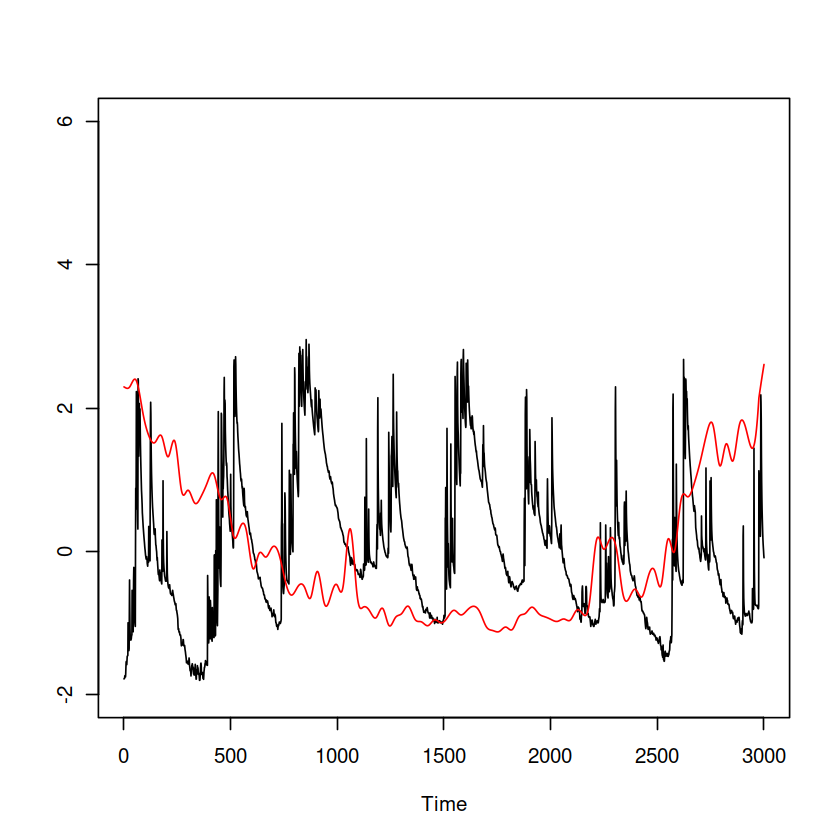

In [ ]:
idx <- (TT-3000):(TT-0)
plot.ts(scale(Y[1,idx]), ylab="", ylim=c(-2,6))
lines(scale((log(plot_data[, indices[1]][idx]-min(plot_data[, indices[1]][idx])+1))),  col = 'red')
# lines(diff(X[idx,1]), col = 'blue')
# lines(diff(Y[1,idx]), ylab="", ylim=c(-0.1,0.1))

In [ ]:
###########################################################################################
####################################### Forecasts ######################################### 
###########################################################################################
nws_forecast <- read.csv('/data/muscat_data/jaguir26/project1_ucsc_phd/nws_forecast.csv')
nws_forecast[,-1] <- log(nws_forecast[,-1])
num_ens_nws <- dim(nws_forecast)[2]-1

glofas_forecast <- read.csv('/data/muscat_data/jaguir26/project1_ucsc_phd/weighted_time_series.csv')
glofas_forecast$target_date <- as.Date(glofas_forecast$target_date)
specific_date <- as.Date("2022-12-26")
glofas_forecast <- glofas_forecast[glofas_forecast$target_date >= specific_date, ]
glofas_forecast[,-1] <- log(glofas_forecast[,-1])

num_ens_glofas <- dim(glofas_forecast)[2]-1

ensembles <- list(glofas_forecast[,-c(1)], nws_forecast[,-c(1)])
J <- length(ensembles)
num_mem <- rep(NA_real_, J)
ranges <- rep(NA_real_, J)
for(j in 1:J){
  num_mem[j] <- dim(ensembles[[j]])[2]
  ranges[j] <- dim(ensembles[[j]])[1]
}
###########################################################################################
###########################################################################################

In [ ]:
row_means_list <- vector("list", J + 1)

row_means_list[[1]] <- rep(NA_real_, ranges[1])

for (j in 1:J) {
  row_means_list[[j + 1]] <- rep(NA_real_, ranges[1])
  row_means_list[[j + 1]][1:ranges[j]] <- rowMeans(ensembles[[j]])
}

mean_forecast <- do.call(rbind, row_means_list)

In [ ]:
# Model setup without covariates
m_yy <- mean(Y, na.rm = TRUE)
s_yy <- sd(Y, na.rm = TRUE)  
kk <- 0.1 * s_yy
trend.comp <- polytrendMod(1, m0 = m_yy, C0 = kk)
harm <- harmonics
seas.comp <- seasMod(p = 363.5854, h = harm, C0 = 0.2 * kk * diag(2 * length(harm)))
model <- combineMods(trend.comp, seas.comp)
p <- length(model$m0)
#
idx <- 1:TT
y <- Y[,idx]
TT_sub <- length(idx)
#
if (is.null(nrow(y))) {
  JJJ <- 1
  y <- array(y, c(JJJ, length(y)))
} else {
  JJJ <- nrow(Y)
  y <- array(y, c(JJJ, ncol(y)))
}
#
gam.init <- array(rep(0, JJJ), c(JJJ, 1))
sig.init <- array(rep(1, JJJ), c(JJJ, 1))
PriorSigma <- array(NA_real_, c(JJJ, 2))
PriorGamma <- array(NA_real_, c(JJJ, 3))
verbose <- TRUE
#
m0 <- c(model$m0, rep(0, J))
C0 <- bdiag(model$C0, 0.2 * kk * diag(J))
#
##########################################
##########################################
#
df_discrep <- rep(df.discrep, J)
#
df = c(df_t, df_s, df_s67); 
dim.df = c(1, 2*length(harm)-2, 2); 
k <- 10
##########################################
##########################################

df.mat <- make_df_mat(df, dim.df, p)
df.mat.k <- make_df_mat_k(df, dim.df, p, k)

df.mat_f <- make_df_mat(c(df[1:2]*lam, df[3]), dim.df, p)
df.mat.k_f <- make_df_mat_k(c(df[1:2]*lam, df[3]), dim.df, p, k)

if (J <= 0) {
  ex.df.mat <- df.mat
  ex.df.mat.k <- df.mat.k
} else {
  extra_df.mat <- make_df_mat(c(df.discrep), c(J), J)
  extra_df.mat.k<- make_df_mat_k(c(df.discrep), c(J), J, k)
  
  ex.df.mat <- bdiag(df.mat, extra_df.mat)
  ex.df.mat.k <- bdiag(df.mat.k, extra_df.mat.k)

  ex.df.mat_f_T <- bdiag(df.mat_f, extra_df.mat)
  ex.df.mat_f_T <- as.matrix(ex.df.mat_f_T)
  ex.df.mat.k_f_T <- bdiag(df.mat.k_f, extra_df.mat.k)
  ex.df.mat.k_f_T <- as.matrix(ex.df.mat.k_f_T)

  ex.df.mat_f <- ex.df.mat
  ex.df.mat_f <- as.matrix(ex.df.mat_f)
  ex.df.mat.k_f <- ex.df.mat.k
  ex.df.mat.k_f <- as.matrix(ex.df.mat.k_f)

    # Get the dimensions of the input matrices
  n <- nrow(ex.df.mat_f)
  m <- ncol(ex.df.mat_f)
  DF.MAT <- array(0, dim = c(n, m, 2))
  DF.MAT[,,1] <- ex.df.mat_f_T
  # DF.MAT[,,2] <- ex.df.mat_f
  DF.MAT[,,2] <- ex.df.mat_f_T
  DF.MAT_k <- array(0, dim = c(n, m, 2))
  DF.MAT_k[,,1] <- ex.df.mat.k_f_T
  DF.MAT_k[,,2] <- ex.df.mat.k_f

}

##########################################
##########################################
model_simp <- model
df_simp <- df
dim.df_simp <- dim.df
model_simp$GG <- array(model_simp$GG, c(p, p, TT))
model_simp$FF <- array(model_simp$FF, c(p, 1, TT))
model$m0 <- m0
model$C0 <- C0

In [ ]:
FF_list <- vector("list", J)
GG_list <- vector("list", J)

######################
  # Without covariates
  model_trend_seas_discrep <- model
  
  for (j in 1:J) {
    jj <- J-j+1
    GG_tsc <- array(bdiag(model_trend_seas_discrep$GG, diag(jj)), c(p + jj, p + jj))
    # model_trend_seas_discrep$GG <- GG_tsc
    GG_list[[j]] <- GG_tsc
    F1_tsc <- matrix(model_trend_seas_discrep$FF, p, jj)
    F2_tsc <- diag(jj)
    FF_tsc <- array(rbind(F1_tsc, F2_tsc), c(p + jj, jj))
    # model_trend_seas_discrep$FF <- FF_tsc  
    FF_list[[j]] <- FF_tsc  
  }
  
 ppx <- 0
######################

In [ ]:
if (use_covariates) {
  # Adding covariates
  px <- dim(X)[2]
  ppx <- px + 1

  F1 <- matrix(model$FF, p, J + 1)
  F2 <- cbind(rep(0, J), diag(J))
  Fx <- rbind(rep(1, J + 1), matrix(0, nrow = px, ncol = J + 1))
  FF <- array(rbind(F1, F2, Fx), c(p + J + ppx, 1 + J, TT))

  Gx <- as.matrix(bdiag(lambda, diag(px)))
  Gx <- array(rep(Gx, TT), dim = c(ppx, ppx, TT))
  Gx[1, 2:ppx, ] <- as.matrix(t(X))

  GG <- array(bdiag(model$GG, diag(J)), c(p + J, p + J, TT))
  model$GG <- GG
  GG_dim <- dim(model$GG)[1]
  new_dim <- GG_dim + ppx
  GGG <- array(0, dim = c(new_dim, new_dim, TT))
  GGG[1:GG_dim, 1:GG_dim, ] <- model$GG
  GGG[(GG_dim + 1):new_dim, (GG_dim + 1):new_dim, ] <- Gx

  model$FF <- FF
  model$GG <- GGG

  extra_df.mat <- make_df_mat(c(df_trans,df_covs), c(1,px), ppx)
  extra_df.mat.k <- make_df_mat_k(c(df_trans,df_covs), c(1,px), ppx, k)

  ex.df.mat <- bdiag(ex.df.mat, extra_df.mat)
  ex.df.mat.k <- bdiag(ex.df.mat.k, extra_df.mat.k)

  model$m0 <- c(model$m0, rep(0, ppx))
  model$C0 <- bdiag(model$C0, 0.2 * kk * diag(ppx))

} else {
  # Without covariates
  GG <- array(bdiag(model$GG, diag(J)), c(p + J, p + J, TT))
  model$GG <- GG
  F1 <- matrix(model$FF, p, J + 1)
  F2 <- cbind(rep(0, J), diag(J))
  FF <- array(rbind(F1, F2), c(p + J, 1 + J, TT))
  model$FF <- FF
  ppx <- 0
}
#
FF <- model$FF
GG <- model$GG

L = L.fn(p0)
U = U.fn(p0)

In [ ]:
dates_ts_usgs <- timestamps

In [ ]:
# covs <- c( 'Solar Flux',
#             'ppt', 
#             'soil')

# indices <- c(
#             'ONI',
#             'WHWP',
#             'GMT',
#             'AMO',
#             'TSA',
#             'TNA',
#             'SOI')

# X <- as.matrix(plot_data[, indices])
# X <- apply(X, 2, standardize)
# X <- as.data.frame(X)
# for(i in 1:dim(X)[2] ){
#     X[,i] <- X[,i]-min(X[,i])+1
# }
# X <- log(X)
# X <- apply(X, 2, standardize)

# plot.ts(X)

### VB parameters convergence: sigma and gamma | exAL_Synth

In [ ]:
png("All_ELBOS_PCA.png", width = 6000, height = 4000, res = 600)
par(mfrow = c(1, 8), mar = c(2, 2, 2, 1), oma = c(0, 0, 3, 0))

a <- c(seq.elbo_50_NDLM_synth_PCA)
a[1:1]=NaN
plot.ts(a, main = "NDLM", xlab = "Iteration", ylab = "ELBO", lwd=2, ylim = c(-51,-37))
a <- c(seq.elbo_5_exAL_synth_PCA)
a[1:1]=NaN
plot.ts(a, main = "exAL05", xlab = "Iteration", ylab = "ELBO", lwd=2, ylim = c(-51,-37))
a <- c(seq.elbo_20_exAL_synth_PCA)
a[1:1]=NaN
plot.ts(a, main = "exAL20", xlab = "Iteration", ylab = "ELBO", lwd=2, ylim = c(-51,-37))
a <- c(seq.elbo_35_exAL_synth_PCA)
a[1:1]=NaN
plot.ts(a, main = "exAL35", xlab = "Iteration", ylab = "ELBO", lwd=2, ylim = c(-51,-37))
a <- c(seq.elbo_50_exAL_synth_PCA)
a[1:1]=NaN
plot.ts(a, main = "exAL50", xlab = "Iteration", ylab = "ELBO", lwd=2, ylim = c(-51,-37))
a <- c(seq.elbo_65_exAL_synth_PCA)
a[1:1]=NaN
plot.ts(a, main = "exAL65", xlab = "Iteration", ylab = "ELBO", lwd=2, ylim = c(-51,-37))
a <- c(seq.elbo_80_exAL_synth_PCA)
a[1:1]=NaN
plot.ts(a, main = "exAL80", xlab = "Iteration", ylab = "ELBO", lwd=2, ylim = c(-51,-37))
a <- c(seq.elbo_95_exAL_synth_PCA)
a[1:1]=NaN
plot.ts(a, main = "exAL95", xlab = "Iteration", ylab = "ELBO", lwd=2, ylim = c(-49,-37))
mtext("ELBO traces", side = 3, outer = TRUE, line = 0, cex = 0.8)

dev.off()

png 
  2

In [ ]:
ks <- -diff(c(ranges,0))
xbs <- array(NA_real_, c(7,ranges[1],n.samp))
xbs_ndlm <- array(NA_real_, c(1,ranges[1],n.samp))

idx <- c(0)
for(j in 1:(J-1)){
    idx <- 1:ks[J-j+1] + idx[length(idx)]
    for(s in 1:n.samp){
        FF_s <- FF_list[[j]]
        theta_s <- samp.theta_ens_5_exAL_synth_PCA[[j]]$samp_theta
        if(j==J){theta_s <- aperm(theta_s, c(1,3,2))}
        xb <- t(FF_s[1:p,])%*%theta_s[1:p,,s]
        xbs[1,idx,s] <- xb[1,]

        theta_s <- samp.theta_ens_20_exAL_synth_PCA[[j]]$samp_theta
        if(j==J){theta_s <- aperm(theta_s, c(1,3,2))}
        xb <- t(FF_s[1:p,])%*%theta_s[1:p,,s]
        xbs[2,idx,s] <- xb[1,]

        theta_s <- samp.theta_ens_35_exAL_synth_PCA[[j]]$samp_theta
        if(j==J){theta_s <- aperm(theta_s, c(1,3,2))}
        xb <- t(FF_s[1:p,])%*%theta_s[1:p,,s]
        xbs[3,idx,s] <- xb[1,]

        theta_s <- samp.theta_ens_50_exAL_synth_PCA[[j]]$samp_theta
        if(j==J){theta_s <- aperm(theta_s, c(1,3,2))}
        xb <- t(FF_s[1:p,])%*%theta_s[1:p,,s]
        xbs[4,idx,s] <- xb[1,]

        theta_s <- samp.theta_ens_65_exAL_synth_PCA[[j]]$samp_theta
        if(j==J){theta_s <- aperm(theta_s, c(1,3,2))}
        xb <- t(FF_s[1:p,])%*%theta_s[1:p,,s]
        xbs[5,idx,s] <- xb[1,]

        theta_s <- samp.theta_ens_80_exAL_synth_PCA[[j]]$samp_theta
        if(j==J){theta_s <- aperm(theta_s, c(1,3,2))}
        xb <- t(FF_s[1:p,])%*%theta_s[1:p,,s]
        xbs[6,idx,s] <- xb[1,]

        theta_s <- samp.theta_ens_95_exAL_synth_PCA[[j]]$samp_theta
        if(j==J){theta_s <- aperm(theta_s, c(1,3,2))}
        xb <- t(FF_s[1:p,])%*%theta_s[1:p,,s]
        xbs[7,idx,s] <- xb[1,]
    }
}

In [ ]:
eps <- 0.0

for(j in J:J){

    idx <- 1:ks[J-j+1] + idx[length(idx)]
    tt <- 1
    for(t in (idx) ){
        # print(c(0.05,t,j))
        # print(t(Ft)%*%Sigma[1:p,1:p]%*%Ft)
        Mu <- new.theta.out_5_exAL_synth_PCA$sm_ens[[j]][,tt]
        Sigma <- new.theta.out_5_exAL_synth_PCA$sC_ens[[j]][,,tt]
        Ft <- FF_list[[j]][1:p,1]
        S <- Sigma[1:p,1:p] + diag(p)*eps
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu[1:p], sd = sqrt(t(Ft)%*%S%*%Ft))
        xbs[1,t,] <- xbs_samp
        # print(c(0.2,t,j))
        # print(t(Ft)%*%Sigma[1:p,1:p]%*%Ft)
        Mu <- new.theta.out_20_exAL_synth_PCA$sm_ens[[j]][,tt]
        Sigma <- new.theta.out_20_exAL_synth_PCA$sC_ens[[j]][,,tt]
        Ft <- FF_list[[j]][1:p,1]
        S <- Sigma[1:p,1:p] + diag(p)*eps
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu[1:p], sd = sqrt(t(Ft)%*%S%*%Ft))
        xbs[2,t,] <- xbs_samp
        # print(c(0.35,t,j))
        # print(t(Ft)%*%Sigma[1:p,1:p]%*%Ft)
        Mu <- new.theta.out_35_exAL_synth_PCA$sm_ens[[j]][,tt]
        Sigma <- new.theta.out_35_exAL_synth_PCA$sC_ens[[j]][,,tt]
        Ft <- FF_list[[j]][1:p,1]
        S <- Sigma[1:p,1:p] + diag(p)*eps
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu[1:p], sd = sqrt(t(Ft)%*%S%*%Ft))
        xbs[3,t,] <- xbs_samp
        # print(c(0.5,t,j))
        # print(t(Ft)%*%Sigma[1:p,1:p]%*%Ft)
        Mu <- new.theta.out_50_exAL_synth_PCA$sm_ens[[j]][,tt]
        Sigma <- new.theta.out_50_exAL_synth_PCA$sC_ens[[j]][,,tt]
        Ft <- FF_list[[j]][1:p,1]
        S <- Sigma[1:p,1:p] + diag(p)*eps
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu[1:p], sd = sqrt(t(Ft)%*%S%*%Ft))
        xbs[4,t,] <- xbs_samp
        # print(c(0.65,t,j))
        # print(t(Ft)%*%Sigma[1:p,1:p]%*%Ft)
        Mu <- new.theta.out_65_exAL_synth_PCA$sm_ens[[j]][,tt]
        Sigma <- new.theta.out_65_exAL_synth_PCA$sC_ens[[j]][,,tt]
        Ft <- FF_list[[j]][1:p,1]
        S <- Sigma[1:p,1:p] + diag(p)*eps
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu[1:p], sd = sqrt(t(Ft)%*%S%*%Ft))
        xbs[5,t,] <- xbs_samp
        # print(c(0.8,t,j))
        # print(t(Ft)%*%Sigma[1:p,1:p]%*%Ft)
        Mu <- new.theta.out_80_exAL_synth_PCA$sm_ens[[j]][,tt]
        Sigma <- new.theta.out_80_exAL_synth_PCA$sC_ens[[j]][,,tt]
        Ft <- FF_list[[j]][1:p,1]
        S <- Sigma[1:p,1:p] + diag(p)*eps
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu[1:p], sd = sqrt(t(Ft)%*%S%*%Ft))
        xbs[6,t,] <- xbs_samp
        # print(c(0.95,t,j))
        # print(t(Ft)%*%Sigma[1:p,1:p]%*%Ft)
        Mu <- new.theta.out_95_exAL_synth_PCA$sm_ens[[j]][,tt]
        Sigma <- new.theta.out_95_exAL_synth_PCA$sC_ens[[j]][,,tt]
        Ft <- FF_list[[j]][1:p,1]
        S <- Sigma[1:p,1:p] + diag(p)*eps
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu[1:p], sd = sqrt(t(Ft)%*%S%*%Ft))
        xbs[7,t,] <- xbs_samp
        tt <- tt+1
    }
}

In [ ]:
idx <- c(0)
for(j in 1:J){
    idx <- 1:ks[J-j+1] + idx[length(idx)]
    tt <- 1
    for(t in idx){
        Mu <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[j]][,tt]
        Sigma <- new.theta.out_50_NDLM_synth_PCA$sC_ens[[j]][,,tt]
        Ft <- FF_list[[j]][1:p,1]
        S <- Sigma[1:p,1:p] + diag(p)*eps
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu[1:p], sd = sqrt(t(Ft)%*%S%*%Ft))
        xbs_ndlm[1,t,] <- xbs_samp
        
        tt <- tt+1
    }
}

In [ ]:
dim(samp.sigma_50_exAL_synth_PCA)
dim(samp.sts_50_exAL_synth_PCA)
dim(samp.uts_50_exAL_synth_PCA)
dim(samp.theta_50_exAL_synth_PCA$samp_theta)
dim(xbs)

[1]    3 2000

[1]     3 12986  2000

[1]     3 12986  2000

[1]    13 12986  2000

[1]    7   28 2000

In [ ]:
library(truncnorm)
set.seed(777)

# Function Definitions
inverse_cdf_AL <- function(U, mu, sigma, p) {
  ifelse(U < p, 
         mu + (sigma / (1 - p)) * log(U / p), 
         mu - (sigma / p) * log((1 - U) / (1 - p)))
}

p.fn <- function(p0, gam) {
  (p0 - as.numeric(gam < 0)) / exp(log.g(gam)) + as.numeric(gam < 0)
}

C.fn <- function(p0, gam) {
  temp.p <- p.fn(p0, gam)
  (as.numeric(gam > 0) - temp.p)^(-1)
}

# Generalized function to handle each case
generate_y_post <- function(p0, xb_matrix, gamma_sample, sigma_sample) {
  n_rows <- dim(xb_matrix)[1]
  n_cols <- dim(xb_matrix)[2]
  y_post <- matrix(NA_real_, nrow = n_rows, ncol = n_cols)
  
  for (t in 1:n_cols) {
    s_0 <- rtruncnorm(1, a=0, b=Inf, mean = 0, sd = 1)
    u <- runif(n_rows)
    y_post[,t] <- xb_matrix[,t] + sigma_sample * abs(gamma_sample) * C.fn(p0, gamma_sample) * s_0 +  
                  sigma_sample * inverse_cdf_AL(u, 0, 1, p.fn(p0, gamma_sample))
  }
  
  return(y_post)
}


# Case 1: p0 = 0.05
p0_05 <- 0.05
xb_05_f <- t(xbs[1,,])
gam_05_f <- samp.gamma_5_exAL_synth_PCA[1,]
sig_05_f <- samp.sigma_5_exAL_synth_PCA[1,]
y_post_5 <- generate_y_post(p0_05, xb_05_f, gam_05_f, sig_05_f)

# Case 2: p0 = 0.5
p0_50 <- 0.5
xb_50_f <- t(xbs[4,,])
gam_50_f <- samp.gamma_50_exAL_synth_PCA[1,]
sig_50_f <- samp.sigma_50_exAL_synth_PCA[1,]
y_post_50 <- generate_y_post(p0_50, xb_50_f, gam_50_f, sig_50_f)

# Case 3: p0 = 0.95
p0_95 <- 0.95
xb_95_f <- t(xbs[7,,])
gam_95_f <- samp.gamma_95_exAL_synth_PCA[1,]
sig_95_f <- samp.sigma_95_exAL_synth_PCA[1,]
y_post_95 <- generate_y_post(p0_95, xb_95_f, gam_95_f, sig_95_f)

# Case 4: p0 = 0.20
p0_20 <- 0.20
xb_20_f <- t(xbs[2,,])
gam_20_f <- samp.gamma_20_exAL_synth_PCA[1,]
sig_20_f <- samp.sigma_20_exAL_synth_PCA[1,]
y_post_20 <- generate_y_post(p0_20, xb_20_f, gam_20_f, sig_20_f)

# Case 5: p0 = 0.80
p0_80 <- 0.80
xb_80_f <- t(xbs[6,,])
gam_80_f <- samp.gamma_80_exAL_synth_PCA[1,]
sig_80_f <- samp.sigma_80_exAL_synth_PCA[1,]
y_post_80 <- generate_y_post(p0_80, xb_80_f, gam_80_f, sig_80_f)

# Case 6: p0 = 0.35
p0_35 <- 0.35
xb_35_f <- t(xbs[3,,])
gam_35_f <- samp.gamma_35_exAL_synth_PCA[1,]
sig_35_f <- samp.sigma_35_exAL_synth_PCA[1,]
y_post_35 <- generate_y_post(p0_35, xb_35_f, gam_35_f, sig_35_f)

# Case 7: p0 = 0.65
p0_65 <- 0.65
xb_65_f <- t(xbs[5,,])
gam_65_f <- samp.gamma_65_exAL_synth_PCA[1,]
sig_65_f <- samp.sigma_65_exAL_synth_PCA[1,]
y_post_65 <- generate_y_post(p0_65, xb_65_f, gam_65_f, sig_65_f)

n_rows_5 <- dim(xb_05_f)[1]
n_cols_5 <- dim(xb_05_f)[2]


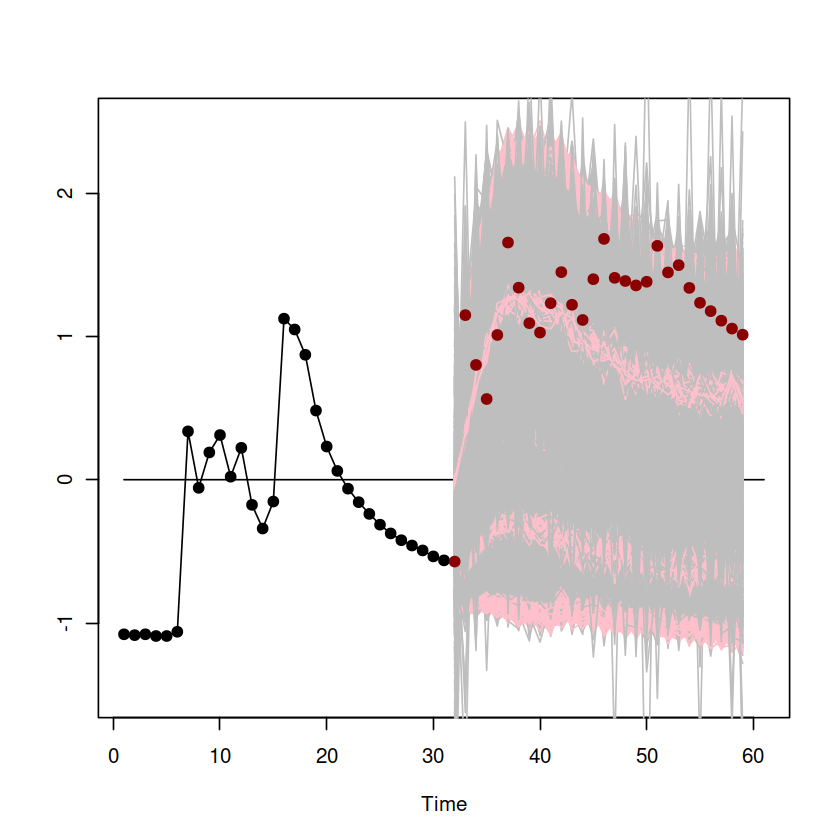

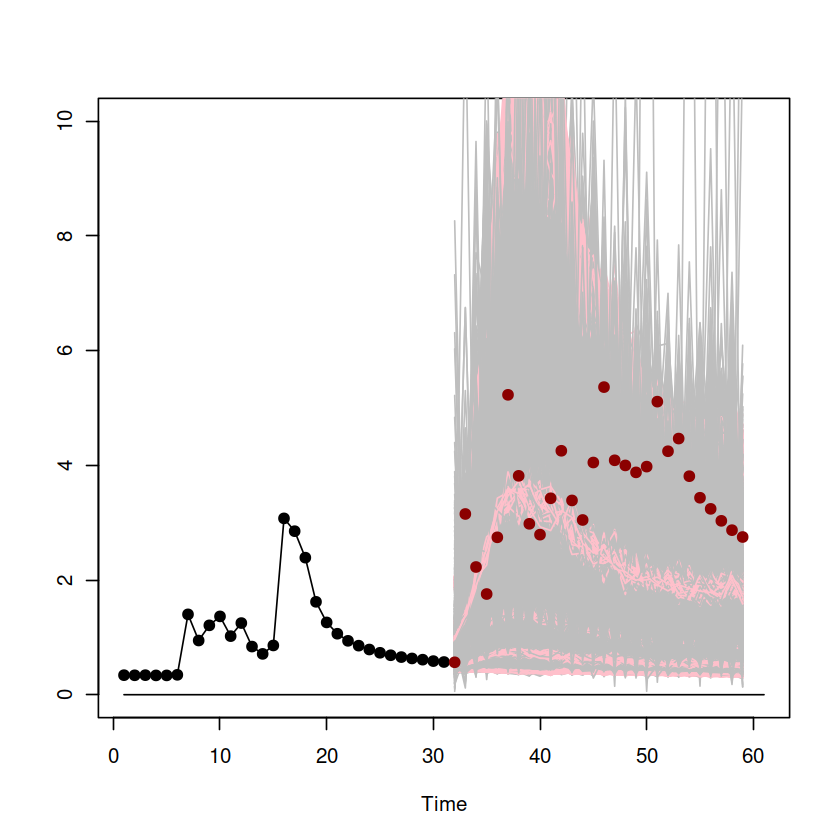

In [18]:
# Function to plot lines for multiple forecasts
plot_forecast_lines <- function(idx, y_post, xb_f, n_rows, truth, color_forecast = 'gray', color_baseline = 'pink') {
  for (s in 1:n_rows) {
    # Forecast lines
    lines((length(idx) + 1):(length(idx) + length(truth)), y_post[s, ], ylab = "", col = color_forecast)
    # Baseline lines
    lines((length(idx) + 1):(length(idx) + length(truth)), xb_f[s, ], ylab = "", col = color_baseline)
  }
}

# Plot for the log-transformed truth data
plot_log_truth_data <- function(idx, Y, truth, y_post_95, y_post_5, y_post_50, y_post_20, y_post_35, y_post_80, y_post_65,
                                xb_95_f, xb_05_f, xb_50_f, xb_20_f, xb_35_f, xb_80_f, xb_65_f, n_rows) {
  plot.ts(rep(0, length(idx) + 30), ylab = "", ylim = c(-1.5, 2.5))
  lines(Y[1, idx], ylab = "")
  points(Y[1, idx], ylab = "", pch = 19)
  
  # Forecast lines
  plot_forecast_lines(idx, y_post_95, xb_95_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_5, xb_05_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_50, xb_50_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_20, xb_20_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_35, xb_35_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_80, xb_80_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_65, xb_65_f, n_rows, truth)
  
  # Add truth points
  points((length(idx) + 1):(length(idx) + length(truth)), truth, ylab = "", col = 'darkred', pch = 19)
}

# Plot for the exp-transformed truth data
plot_exp_truth_data <- function(idx, Y, truth, y_post_95, y_post_5, y_post_50, y_post_20, y_post_35, y_post_80, y_post_65,
                                xb_95_f, xb_05_f, xb_50_f, xb_20_f, xb_35_f, xb_80_f, xb_65_f, n_rows) {
  plot.ts(rep(0, length(idx) + 30), ylab = "", ylim = c(0, 10))
  lines(exp(Y[1, idx]), ylab = "")
  points(exp(Y[1, idx]), ylab = "", pch = 19)
  
  # Forecast lines
  plot_forecast_lines(idx, exp(y_post_95), exp(xb_95_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_5), exp(xb_05_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_50), exp(xb_50_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_20), exp(xb_20_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_35), exp(xb_35_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_80), exp(xb_80_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_65), exp(xb_65_f), n_rows, truth)
  
  # Add truth points
  points((length(idx) + 1):(length(idx) + length(truth)), truth, ylab = "", col = 'darkred', pch = 19)
}

# Applying quantile computations and mean for each case
compute_quantiles_means <- function(y_post) {
  quantiles <- apply(y_post, 2, quantile, probs = c(0.05, 0.5, 0.95))
  mean_values <- colMeans(y_post)
  return(list(quantiles = quantiles, means = mean_values))
}

# Generate quantiles and means for each posterior
q50 <- compute_quantiles_means(y_post_50)
q5 <- compute_quantiles_means(y_post_5)
q95 <- compute_quantiles_means(y_post_95)
q20 <- compute_quantiles_means(y_post_20)
q35 <- compute_quantiles_means(y_post_35)
q65 <- compute_quantiles_means(y_post_65)
q80 <- compute_quantiles_means(y_post_80)

# Main Code Execution

# Log-transformed truth data
truth_log <- log(San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date >= as.Date('2022-12-26')][1:ranges[1]])
idx <- (TT - 30):(TT)

# Plot log-transformed data and forecast
plot_log_truth_data(idx, Y, truth_log, y_post_95, y_post_5, y_post_50, y_post_20, y_post_35, y_post_80, y_post_65,
                    xb_95_f, xb_05_f, xb_50_f, xb_20_f, xb_35_f, xb_80_f, xb_65_f, n_rows_5)

# Raw truth data
truth_raw <- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date >= as.Date('2022-12-26')][1:ranges[1]]

# Plot exp-transformed data and forecast
plot_exp_truth_data(idx, Y, truth_raw, y_post_95, y_post_5, y_post_50, y_post_20, y_post_35, y_post_80, y_post_65,
                    xb_95_f, xb_05_f, xb_50_f, xb_20_f, xb_35_f, xb_80_f, xb_65_f, n_rows_5)


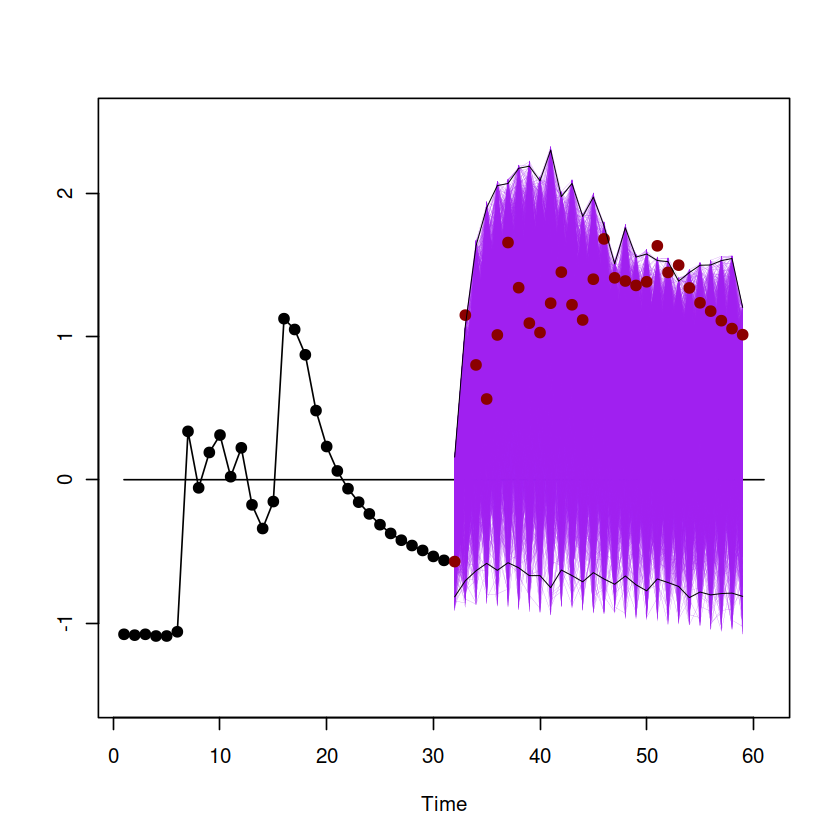

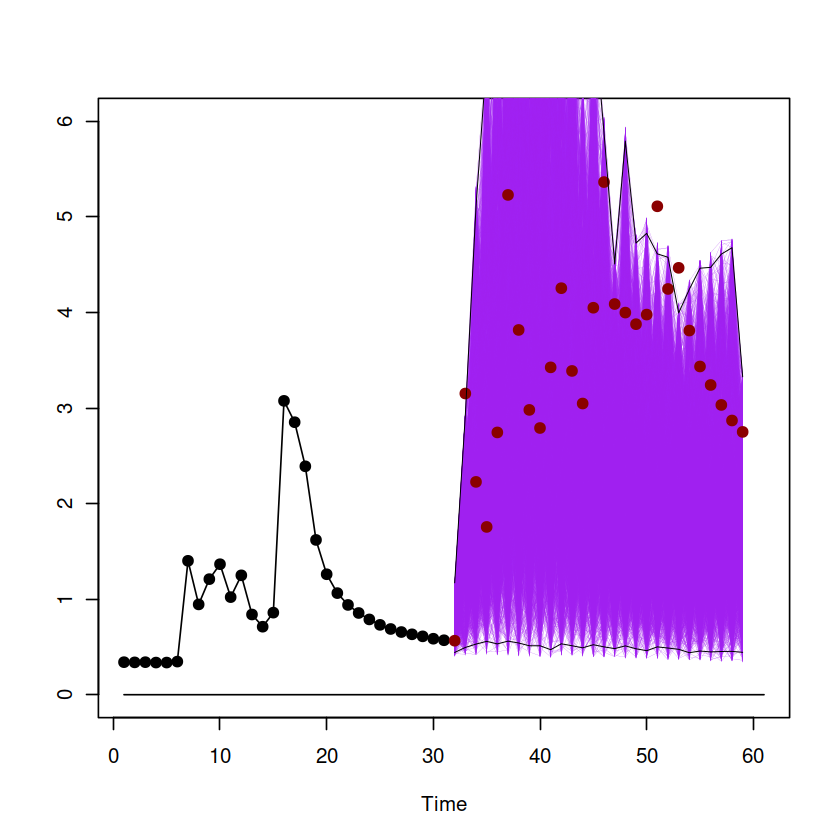

In [21]:

# Applying quantile computations and mean for each case
compute_quantiles_means <- function(y_post, q0) {
  quantiles <- apply(y_post, 2, quantile, probs = c(q0, 0.025,0.5,0.975))
  mean_values <- colMeans(y_post)
  return(list(quantiles = quantiles, means = mean_values))
}

# Generate quantiles and means for each posterior
q50 <- compute_quantiles_means(y_post_50,0.5)
q5 <- compute_quantiles_means(y_post_5,0.05)
q95 <- compute_quantiles_means(y_post_95,0.95)
q20 <- compute_quantiles_means(y_post_20,0.2)
q35 <- compute_quantiles_means(y_post_35,0.35)
q65 <- compute_quantiles_means(y_post_65,0.65)
q80 <- compute_quantiles_means(y_post_80,0.8)
################################################################################################################################################
n.samp <- dim(samp.theta_50_exAL_synth_PCA$samp_theta)[3]
synth_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
k <- 10
for(t in 1:ranges[1]){
    w <- rep(0,7)
    for(s in 1:n.samp){
        diff <- y_post_5[s,t]-q5$quantiles[1,t]
        w[1] <- exp(-k*CheckLossFn(0.05,diff)/samp.sigma_5_exAL_synth_PCA[1,s])
        diff <- y_post_50[s,t]-q50$quantiles[1,t]
        w[2] <- exp(-k*CheckLossFn(0.5,diff)/samp.sigma_50_exAL_synth_PCA[1,s])
        diff <- y_post_95[s,t]-q95$quantiles[1,t]
        w[3] <- exp(-k*CheckLossFn(0.95,diff)/samp.sigma_95_exAL_synth_PCA[1,s])
        diff <- y_post_20[s,t]-q20$quantiles[1,t]
        w[4] <- exp(-k*CheckLossFn(0.2,diff)/samp.sigma_20_exAL_synth_PCA[1,s])
        diff <- y_post_35[s,t]-q35$quantiles[1,t]
        w[5] <- exp(-k*CheckLossFn(0.35,diff)/samp.sigma_35_exAL_synth_PCA[1,s])
        diff <- y_post_80[s,t]-q80$quantiles[1,t]
        w[6] <- exp(-k*CheckLossFn(0.80,diff)/samp.sigma_80_exAL_synth_PCA[1,s])
        diff <- y_post_65[s,t]-q65$quantiles[1,t]
        w[7] <- exp(-k*CheckLossFn(0.65,diff)/samp.sigma_65_exAL_synth_PCA[1,s])
        w <- w/sum(w)
        synth_q_f[s,t] <- sum(w*c(q5$quantiles[1,t],q50$quantiles[1,t],q95$quantiles[1,t],
                                  q20$quantiles[1,t],q35$quantiles[1,t],q80$quantiles[1,t],q65$quantiles[1,t]))
    } 
}

q_synth <- apply(synth_q_f, 2, quantile, probs = c(0.025, 0.5, 0.975))
m_synth <- colMeans((synth_q_f))

################################################################################################################################################

truth<- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date>=as.Date('2022-12-26')]
truth <- log(truth[1:ranges[1]])
idx <- (TT-30):(TT)
plot.ts(rep(0, length(idx)+30), ylab="", ylim=c(-1.5,2.5))
lines((Y[1,idx]), ylab="")
points((Y[1,idx]), ylab="", pch = 19)

for(s in 1:n.samp){
    lines((length(idx)+1):(length(idx)+length(truth)),synth_f[s,], lwd = 0.1, col='gray')
} 
for(s in 1:n.samp){
    lines((length(idx)+1):(length(idx)+length(truth)),synth_q_f[s,], lwd = 0.1, col='purple')
} 

points((length(idx)+1):(length(idx)+length(truth)), (truth), ylab="", col='darkred', pch = 19)

# lines((length(idx)+1):(length(idx)+length(truth)),q95$quantiles[3,], lwd = 0.6, col='black')
lines((length(idx)+1):(length(idx)+length(truth)),q_synth[3,], lwd = 0.6, col='black')
lines((length(idx)+1):(length(idx)+length(truth)),q_synth[1,], lwd = 0.6, col='black')

################################################################################################################################################

truth<- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date>=as.Date('2022-12-26')]
truth <- (truth[1:ranges[1]])
idx <- (TT-30):(TT)
plot.ts(rep(0, length(idx)+30), ylab="", ylim=c(0,6))
lines(exp(Y[1,idx]), ylab="")
points(exp(Y[1,idx]), ylab="", pch = 19)

for(s in 1:n.samp){
    lines((length(idx)+1):(length(idx)+length(truth)),exp(synth_f[s,]), lwd = 0.1, col='gray')
} 
for(s in 1:n.samp){
    lines((length(idx)+1):(length(idx)+length(truth)),exp(synth_q_f[s,]), lwd = 0.1, col='purple')
} 
points((length(idx)+1):(length(idx)+length(truth)),(truth), ylab="", col='darkred', pch = 19)
lines((length(idx)+1):(length(idx)+length(truth)),exp(q_synth[3,]), lwd = 0.6, col='black')
lines((length(idx)+1):(length(idx)+length(truth)),exp(q_synth[1,]), lwd = 0.6, col='black')



# Combine Both periods!!

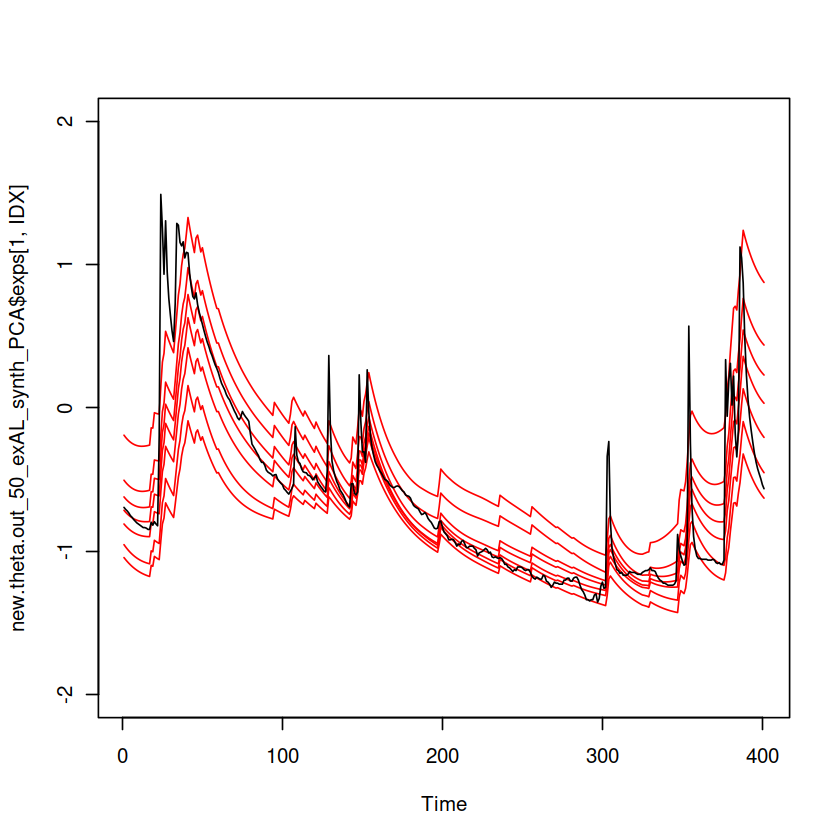

In [22]:
IDX <- (TT-400):(TT)
plot.ts(new.theta.out_50_exAL_synth_PCA$exps[1,IDX], col = 'red', ylim = c(-2,2))
lines(new.theta.out_5_exAL_synth_PCA$exps[1,IDX], col = 'red')
lines(new.theta.out_95_exAL_synth_PCA$exps[1,IDX], col = 'red')
lines(new.theta.out_20_exAL_synth_PCA$exps[1,IDX], col = 'red')
lines(new.theta.out_80_exAL_synth_PCA$exps[1,IDX], col = 'red')
lines(new.theta.out_35_exAL_synth_PCA$exps[1,IDX], col = 'red')
lines(new.theta.out_65_exAL_synth_PCA$exps[1,IDX], col = 'red')
lines(Y[1,IDX])

In [23]:
# idx <- 1:TT
# j <- 1
# t <- 1
# Mu <- new.theta.out_50_exAL_synth$sm[,t]
# Sigma <- new.theta.out_50_exAL_synth$sC[,,t]
# Ft <- FF[,1,t]
# xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu, sd = sqrt(t(Ft)%*%Sigma%*%Ft))
# xbs_ndlm_retro[1,t,] <- xbs_samp

In [24]:
xbs_retro <- array(NA_real_, c(7,TT,n.samp))
xbs_ndlm_retro <- array(NA_real_, c(1,TT,n.samp))

idx <- 1:TT
for(j in 1:J){
    for(t in idx){
        ###############################################################################
        Mu <- new.theta.out_50_NDLM_synth_PCA$sm[,t]
        Sigma <- new.theta.out_50_NDLM_synth_PCA$sC[,,t]
        Ft <- FF[,1,t]
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu, sd = sqrt(t(Ft)%*%Sigma%*%Ft))
        xbs_ndlm_retro[1,t,] <- xbs_samp
        ###############################################################################
        ###############################################################################
        Mu <- new.theta.out_95_exAL_synth_PCA$sm[,t]
        Sigma <- new.theta.out_95_exAL_synth_PCA$sC[,,t]
        Ft <- FF[,1,t]
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu, sd = sqrt(t(Ft)%*%Sigma%*%Ft))
        xbs_retro[7,t,] <- xbs_samp
        ###############################################################################
        ###############################################################################
        Mu <- new.theta.out_80_exAL_synth_PCA$sm[,t]
        Sigma <- new.theta.out_80_exAL_synth_PCA$sC[,,t]
        Ft <- FF[,1,t]
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu, sd = sqrt(t(Ft)%*%Sigma%*%Ft))
        xbs_retro[6,t,] <- xbs_samp
        ###############################################################################
        ###############################################################################
        Mu <- new.theta.out_65_exAL_synth_PCA$sm[,t]
        Sigma <- new.theta.out_65_exAL_synth_PCA$sC[,,t]
        Ft <- FF[,1,t]
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu, sd = sqrt(t(Ft)%*%Sigma%*%Ft))
        xbs_retro[5,t,] <- xbs_samp
        ###############################################################################
        ###############################################################################
        Mu <- new.theta.out_50_exAL_synth_PCA$sm[,t]
        Sigma <- new.theta.out_50_exAL_synth_PCA$sC[,,t]
        Ft <- FF[,1,t]
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu, sd = sqrt(t(Ft)%*%Sigma%*%Ft))
        xbs_retro[4,t,] <- xbs_samp
        ###############################################################################
        ###############################################################################
        Mu <- new.theta.out_35_exAL_synth_PCA$sm[,t]
        Sigma <- new.theta.out_35_exAL_synth_PCA$sC[,,t]
        Ft <- FF[,1,t]
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu, sd = sqrt(t(Ft)%*%Sigma%*%Ft))
        xbs_retro[3,t,] <- xbs_samp
        ###############################################################################
        ###############################################################################
        Mu <- new.theta.out_20_exAL_synth_PCA$sm[,t]
        Sigma <- new.theta.out_20_exAL_synth_PCA$sC[,,t]
        Ft <- FF[,1,t]
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu, sd = sqrt(t(Ft)%*%Sigma%*%Ft))
        xbs_retro[2,t,] <- xbs_samp
        ###############################################################################
        ###############################################################################
        Mu <- new.theta.out_5_exAL_synth_PCA$sm[,t]
        Sigma <- new.theta.out_5_exAL_synth_PCA$sC[,,t]
        Ft <- FF[,1,t]
        xbs_samp <- rnorm(n = n.samp, mean = t(Ft)%*%Mu, sd = sqrt(t(Ft)%*%Sigma%*%Ft))
        xbs_retro[1,t,] <- xbs_samp
        ###############################################################################

    }
}

In [25]:
dim(new.theta.out_50_exAL_synth_PCA$sm)

[1]    13 12986

In [26]:
truth<- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date>=as.Date('2022-12-26')]
# truth <- truth[1:ranges[1]]
truth <- log(truth[1:ranges[1]]+1)

In [27]:
# iii <- 30
# idx1 <- (TT-iii):(TT+ranges[2])
# idx2 <- (TT-iii):(TT+ranges[1])
# idx_all <- (TT-iii):(TT+ranges[1])
# idx_T <- (TT-iii):TT
# idx_y <- (TT-iii):TT
# idx_f <- ((iii+1)+1):((iii+1)+ranges[1])

# q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))
# ######################################################################################
# ## Base
# plot.ts((new.theta.out_95_exAL_synth$exps[2,idx_all])*0, ylim = c(0, 6))
# ######################################################################################
# # ## GloFAS Ensembles
# # for (j in 1:num_mem[1]) {
# #  lines(idx_f[1:ranges[1]], ensembles[[1]][,j], col="darksalmon")  
# # }
# # ######################################################################################
# # ## NWS Ensembles
# # for (j in 1:num_mem[2]) {
# #  lines(idx_f[1:ranges[2]], ensembles[[2]][,j], col="cadetblue1")  
# # }
# ######################################################################################
# ## Truth
# points((1+length(idx_y)):(length(truth)+length(idx_y)), truth, col = 'lightgreen', pch = 19)
# ######################################################################################
# ## Observations
# lines(Y[1,idx_y], col = 'black')
# points(Y[1,idx_y], col = 'black')
# # lines(est[idx_y], col = 'black')
# ######################################################################################
# ## 95th Quantile
# d1 <- new.theta.out_95_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_95_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_95_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[7,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_95_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 80th Quantile
# d1 <- new.theta.out_80_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_80_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_80_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[6,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_80_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 65th Quantile
# d1 <- new.theta.out_65_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_65_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_65_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[5,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_65_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 50th Quantile
# d1 <- new.theta.out_50_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_50_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_50_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[4,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_50_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 35th Quantile
# d1 <- new.theta.out_35_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_35_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_35_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[3,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_35_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 20th Quantile
# d1 <- new.theta.out_20_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_20_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_20_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[2,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_20_exAL_synth$exps[1,idx1], col='darkgreen')
# #####################################################################################
# ## 05th Quantile
# d1 <- new.theta.out_5_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_5_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_5_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[1,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col="deeppink4", lwd=2)
# lines(new.theta.out_5_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# # ## Mean Ensembles 
# # lines(idx_f, row_means_list[[2]], col="darkorange", lwd=2)
# # lines(idx_f, row_means_list[[3]], col="darkblue", lwd=2)

# percentiles <- c(0.025, 0.5, 0.975)
# result <- apply(xbs[7,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'blue', lty=2)
# lines(idx_f, result[2,],col = 'blue')
# lines(idx_f, result[3,],col = 'blue', lty=2)

# result <- apply(xbs[4,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'green', lty=2)
# lines(idx_f, result[2,],col = 'green')
# lines(idx_f, result[3,],col = 'green', lty=2)

# result <- apply(xbs[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'red', lty=2)
# lines(idx_f, result[2,],col = 'red')
# lines(idx_f, result[3,],col = 'red', lty=2)


# # result <- apply(xbs_ndlm[1,,], 1, function(x) quantile(x, probs = percentiles))
# # lines(idx_f, result[1,], ylim = c(0,6),col = 'orange')
# # lines(idx_f, result[2,],col = 'orange')
# # lines(idx_f, result[3,],col = 'orange')
# ######################################################################################

# # lines(idx_f, colMeans(q_exps), col = 'black', lwd=1)

# ######################################################################################
# ######################################################################################
# ######################################################################################

# w_q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))

# e <- (colMeans(q_exps) - q_exps[1,])/new.gamsig.out_5_exAL_synth$E.sigma[1]
# w_q_exps[1,] <- CheckLossFn(0.05, e)
# e <- (colMeans(q_exps) - q_exps[2,])/new.gamsig.out_20_exAL_synth$E.sigma[1]
# w_q_exps[2,] <- CheckLossFn(0.2, e)
# e <- (colMeans(q_exps) - q_exps[3,])/new.gamsig.out_35_exAL_synth$E.sigma[1]
# w_q_exps[3,] <- CheckLossFn(0.35, e)
# e <- (colMeans(q_exps) - q_exps[4,])/new.gamsig.out_50_exAL_synth$E.sigma[1]
# w_q_exps[4,] <- CheckLossFn(0.5, e)
# e <- (colMeans(q_exps) - q_exps[5,])/new.gamsig.out_65_exAL_synth$E.sigma[1]
# w_q_exps[5,] <- CheckLossFn(0.65, e)
# e <- (colMeans(q_exps) - q_exps[6,])/new.gamsig.out_80_exAL_synth$E.sigma[1]
# w_q_exps[6,] <- CheckLossFn(0.8, e)
# e <- (colMeans(q_exps) - q_exps[7,])/new.gamsig.out_95_exAL_synth$E.sigma[1]
# w_q_exps[7,] <- CheckLossFn(0.95, e)

# synth_q <- matrix(NA_real_, nrow = 1, ncol=(ranges[1]))


# for (t in 1:(ranges[1])) {

#    if(t>1){
#    w_q_exps[,t] <- exp(-w_q_exps[,t])*(w_q_exps[,t-1])^1
#    w_q_exps[,t] <- w_q_exps[,t]/sum(w_q_exps[,t])
#    }else{
#    w_q_exps[,t] <- exp(-w_q_exps[,t])
#    w_q_exps[,t] <- w_q_exps[,t]/sum(w_q_exps[,t])
#    }

#    q05 <- q_exps[1,t]
#    q20 <- q_exps[2,t]
#    q35 <- q_exps[3,t]
#    q50 <- q_exps[4,t]
#    q65 <- q_exps[5,t]
#    q80 <- q_exps[6,t]
#    q95 <- q_exps[7,t]
#    synth_q[t] <- sum(w_q_exps[,t]*c(q05,q20,q35,q50,q65,q80,q95))

# }

# # lines(idx_f, synth_q, col = 'black', lwd=1)
# # # lines(idx_f, synth_q2, col = 'black', lwd=1)

# #####################################################################################
# # # NDLM
# # d1 <- new.theta.out_50_NDLM_synth$sm_ens[[1]][8,]
# # d2 <- new.theta.out_50_NDLM_synth$sm_ens[[2]][8,]
# # discrep <-  c(d1,d2) 
# # estim_dqlm <- new.theta.out_50_NDLM_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# # lines(idx_f, estim_dqlm, col="orange", lwd=2)
# # sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# # lines(new.theta.out_50_NDLM_synth$exps[1,idx1], col='orange')
# # lines(new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.95), col='orange')
# # lines(new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.05), col='orange')
# # lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.95), col="orange", lwd=2)
# # lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.05), col="orange", lwd=2)





# percentiles <- c(0.025, 0.5, 0.975)
# idx <- (TT-iii):(TT)
# idxx <- 1:length(idx)
# ######################################################################################
# ######################################################################################
# ## 50th Quantile
# ########
# result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkgreen', lwd=0.5)
# lines(idxx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 5th Quantile
# ########
# result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkred', lwd=0.5)
# lines(idxx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 95th Quantile
# ########
# result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkblue', lwd=0.5)
# lines(idxx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)

# ######################################################################################
# ## 80th Quantile
# ########
# result <- apply(xbs_retro[6,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'purple', lwd=0.5)
# lines(idxx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 65th Quantile
# ########
# result <- apply(xbs_retro[5,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'purple', lwd=0.5)
# lines(idxx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 35th Quantile
# ########
# result <- apply(xbs_retro[3,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'purple', lwd=0.5)
# lines(idxx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 20th Quantile
# ########
# result <- apply(xbs_retro[2,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'purple', lwd=0.5)
# lines(idxx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
# ######################################################################################




In [28]:
# iii <- 90
# idx1 <- (TT-iii+1):(TT+ranges[2])
# idx2 <- (TT-iii+1):(TT+ranges[1])
# idx_all <- (TT-iii+1):(TT+ranges[1])
# idx_T <- (TT-iii+1):TT
# idx_y <- (TT-iii+1):TT
# idx_f <- (iii+1):(iii+ranges[1])

# q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))
# ######################################################################################
# ## Base
# plot.ts((new.theta.out_95_exAL_synth$exps[2,idx_all])*0, ylim = c(0, 6))
# ######################################################################################
# # ## GloFAS Ensembles
# # for (j in 1:num_mem[1]) {
# #  lines(idx_f[1:ranges[1]], ensembles[[1]][,j], col="darksalmon")  
# # }
# # ######################################################################################
# # ## NWS Ensembles
# # for (j in 1:num_mem[2]) {
# #  lines(idx_f[1:ranges[2]], ensembles[[2]][,j], col="cadetblue1")  
# # }
# ######################################################################################
# ## Truth
# points((1+length(idx_y)):(length(truth)+length(idx_y)), truth, col = 'lightgreen', pch = 19)
# ######################################################################################
# ## Observations
# lines(Y[1,idx_y], col = 'black')
# points(Y[1,idx_y], col = 'black')
# # lines(est[idx_y], col = 'black')
# ######################################################################################
# ## 95th Quantile
# d1 <- new.theta.out_95_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_95_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_95_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[7,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_95_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 80th Quantile
# d1 <- new.theta.out_80_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_80_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_80_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[6,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_80_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 65th Quantile
# d1 <- new.theta.out_65_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_65_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_65_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[5,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_65_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 50th Quantile
# d1 <- new.theta.out_50_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_50_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_50_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[4,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_50_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 35th Quantile
# d1 <- new.theta.out_35_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_35_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_35_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[3,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_35_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# ## 20th Quantile
# d1 <- new.theta.out_20_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_20_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_20_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[2,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_20_exAL_synth$exps[1,idx1], col='darkgreen')
# #####################################################################################
# ## 05th Quantile
# d1 <- new.theta.out_5_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_5_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_5_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[1,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col="deeppink4", lwd=2)
# lines(new.theta.out_5_exAL_synth$exps[1,idx1], col='darkgreen')
# ######################################################################################
# # ## Mean Ensembles 
# # lines(idx_f, row_means_list[[2]], col="darkorange", lwd=2)
# # lines(idx_f, row_means_list[[3]], col="darkblue", lwd=2)

# percentiles <- c(0.025, 0.5, 0.975)
# result <- apply(xbs[7,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
# lines(idx_f, result[2,],col = 'blue')
# lines(idx_f, result[3,],col = 'blue', lty = 2, lwd=0.5)

# result <- apply(xbs[4,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
# lines(idx_f, result[2,],col = 'green')
# lines(idx_f, result[3,],col = 'green', lty = 2, lwd=0.5)

# result <- apply(xbs[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
# lines(idx_f, result[2,],col = 'red')
# lines(idx_f, result[3,],col = 'red', lty = 2, lwd=0.5)


# result <- apply(xbs_ndlm[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
# lines(idx_f, result[2,],col = 'orange')
# lines(idx_f, result[3,],col = 'orange', lty = 2, lwd=0.5)
# ######################################################################################

# # lines(idx_f, colMeans(q_exps), col = 'black', lwd=1)

# ######################################################################################
# ######################################################################################
# ######################################################################################

# w_q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))

# e <- (colMeans(q_exps) - q_exps[1,])/new.gamsig.out_5_exAL_synth$E.sigma[1]
# w_q_exps[1,] <- CheckLossFn(0.05, e)
# e <- (colMeans(q_exps) - q_exps[2,])/new.gamsig.out_20_exAL_synth$E.sigma[1]
# w_q_exps[2,] <- CheckLossFn(0.2, e)
# e <- (colMeans(q_exps) - q_exps[3,])/new.gamsig.out_35_exAL_synth$E.sigma[1]
# w_q_exps[3,] <- CheckLossFn(0.35, e)
# e <- (colMeans(q_exps) - q_exps[4,])/new.gamsig.out_50_exAL_synth$E.sigma[1]
# w_q_exps[4,] <- CheckLossFn(0.5, e)
# e <- (colMeans(q_exps) - q_exps[5,])/new.gamsig.out_65_exAL_synth$E.sigma[1]
# w_q_exps[5,] <- CheckLossFn(0.65, e)
# e <- (colMeans(q_exps) - q_exps[6,])/new.gamsig.out_80_exAL_synth$E.sigma[1]
# w_q_exps[6,] <- CheckLossFn(0.8, e)
# e <- (colMeans(q_exps) - q_exps[7,])/new.gamsig.out_95_exAL_synth$E.sigma[1]
# w_q_exps[7,] <- CheckLossFn(0.95, e)

# synth_q <- matrix(NA_real_, nrow = 1, ncol=(ranges[1]))


# for (t in 1:(ranges[1])) {

#    if(t>1){
#    w_q_exps[,t] <- exp(-w_q_exps[,t])*(w_q_exps[,t-1])^1
#    w_q_exps[,t] <- w_q_exps[,t]/sum(w_q_exps[,t])
#    }else{
#    w_q_exps[,t] <- exp(-w_q_exps[,t])
#    w_q_exps[,t] <- w_q_exps[,t]/sum(w_q_exps[,t])
#    }

#    q05 <- q_exps[1,t]
#    q20 <- q_exps[2,t]
#    q35 <- q_exps[3,t]
#    q50 <- q_exps[4,t]
#    q65 <- q_exps[5,t]
#    q80 <- q_exps[6,t]
#    q95 <- q_exps[7,t]
#    synth_q[t] <- sum(w_q_exps[,t]*c(q05,q20,q35,q50,q65,q80,q95))

# }

# # lines(idx_f, synth_q, col = 'black', lwd=1)
# # # lines(idx_f, synth_q2, col = 'black', lwd=1)

# #####################################################################################
# # NDLM
# d1 <- new.theta.out_50_NDLM_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_50_NDLM_synth$sm_ens[[2]][8,]

# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# lines(idx_f, estim_dqlm, col="orange", lwd=2)
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))

# # lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.95), col="orange", lwd=2)
# # lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.05), col="orange", lwd=2)

# # discrep <-  c(new.theta.out_50_NDLM_synth$sm[8,], discrep) 
# # estim_dqlm <- new.theta.out_50_NDLM_synth$exps[2,]-discrep
# # lines(1:length(idx_all),estim_dqlm[idx_all])
# # lines(1:length(idx_all),estim_dqlm[idx_all]+sd_ndlm*qnorm(0.95))
# # lines(1:length(idx_all),estim_dqlm[idx_all]+sd_ndlm*qnorm(0.05))

# lines(1:length(idx1), new.theta.out_50_NDLM_synth$exps[1,idx1], col='orange')
# # lines(1:length(idx1),new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.95), col='orange')
# # lines(1:length(idx1),new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.05), col='orange')




# percentiles <- c(0.025, 0.5, 0.975)
# idx <- (TT-iii):(TT)
# idxx <- 1:length(idx)
# ######################################################################################
# ######################################################################################
# ## 50th Quantile
# ########
# result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkgreen', lwd=0.5)
# lines(idxx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 5th Quantile
# ########
# result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkred', lwd=0.5)
# lines(idxx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 95th Quantile
# ########
# result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkblue', lwd=0.5)
# lines(idxx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## NDLM
# ########
# result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkorange', lwd=0.5)
# lines(idxx, result[3,idx],col = 'orange', lty = 2, lwd=0.5)

# ######################################################################################
# ## 80th Quantile
# ########
# result <- apply(xbs_retro[6,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'purple', lwd=0.5)
# lines(idxx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 65th Quantile
# ########
# result <- apply(xbs_retro[5,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'purple', lwd=0.5)
# lines(idxx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 35th Quantile
# ########
# result <- apply(xbs_retro[3,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'purple', lwd=0.5)
# lines(idxx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## 20th Quantile
# ########
# result <- apply(xbs_retro[2,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'purple', lwd=0.5)
# lines(idxx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
# ######################################################################################




In [29]:
FF_t <- aperm(FF, c(2, 1, 3))
multiply_matrices <- function(slice_index) {
    FF_t[,,slice_index] %*% new.theta.out_50_exAL_synth_PCA$sm[,slice_index]
}
result_list <- lapply(1:ncol(new.theta.out_50_exAL_synth_PCA$sm), multiply_matrices)
result_array <- array(unlist(result_list), dim = c(J+1, 1, ncol(new.theta.out_50_exAL_synth_PCA$sm)))
result_array <- aperm(result_array, c(1, 3, 2))[,,1]
dim( result_array )
TT

[1]     3 12986

[1] 12986

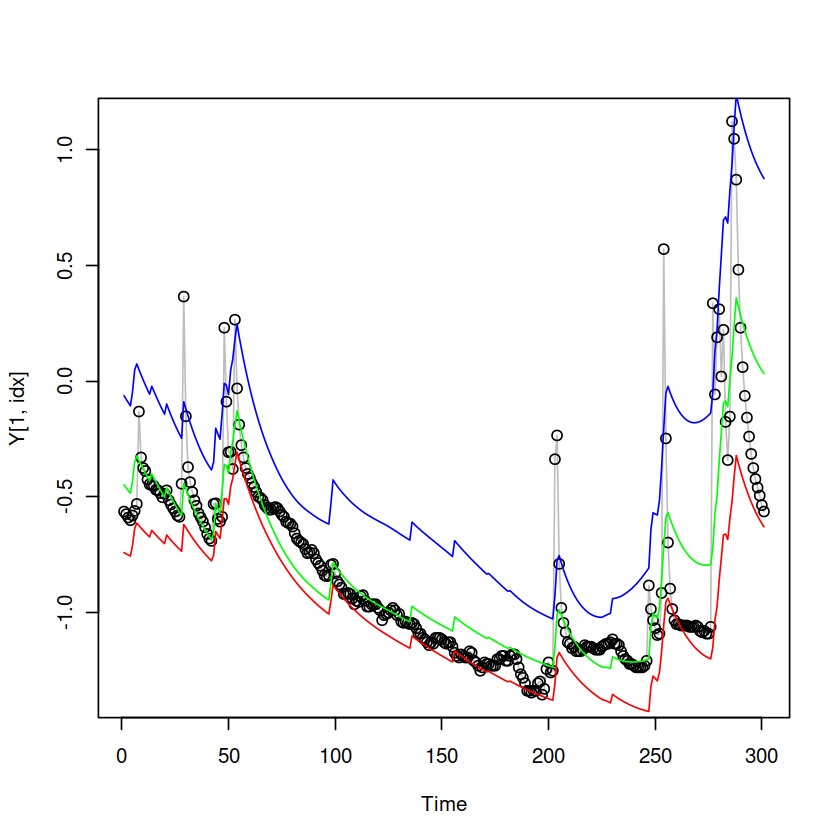

In [30]:
idx <- (TT-300):TT
plot.ts(Y[1,idx], col = 'gray')
points(Y[1,idx], col = 'black')
lines(new.theta.out_50_exAL_synth_PCA$exps[1,idx], col = 'green')
lines(new.theta.out_5_exAL_synth_PCA$exps[1,idx], col = 'red')
lines(new.theta.out_95_exAL_synth_PCA$exps[1,idx], col = 'blue')
# lines(new.theta.out_50_exAL_synth$exps[1,], col = 'green')
# lines(new.theta.out_50_exAL_synth$exps[1,], col = 'green')
# lines(new.theta.out_50_exAL_synth$exps[1,], col = 'green')

In [31]:
# Setting up the indices
iii <- 30
idx1 <- (TT-iii):(TT+ranges[2])
idx2 <- (TT-iii):(TT+ranges[1])
idx_all <- (TT-iii):(TT+ranges[1])
idx_T <- (TT-iii):TT
idx_y <- (TT-iii):TT
idx_f <- ((iii+1)+1):((iii+1)+ranges[1])

# Initialize the matrix
q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))
png("Allth_exal_PCA.png", width = 6000, height = 4000, res = 600)
# Base plot
plot.ts((new.theta.out_95_exAL_synth_PCA$exps[2,idx_all]) * 0, ylim = c(-2.5, 2.5),
        xlab = " ", ylab = "log-flow", xaxt = "n", col = NA, lwd = 2, main = "Dynamic Quantile:  exAL")

# Adding 'Truth' points
points((1 + length(idx_y)):(length(truth) + length(idx_y)), truth, col = 'deeppink4', pch = 19, cex = 0.7, lwd = 1)

# Adding 'Observations'
lines(Y[1,idx_y], col = 'black', lwd = 1.5)
points(Y[1,idx_y], col = 'black', pch = 16, cex = 0.6)

# Adding 95th Quantile estimation
d1 <- new.theta.out_95_exAL_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_95_exAL_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 

estim_dqlm <- new.theta.out_5_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[1,] <- estim_dqlm 
lines(new.theta.out_5_exAL_synth_PCA$exps[1,idx1], col = 'darkred', lwd = 2)

estim_dqlm <- new.theta.out_20_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[2,] <- estim_dqlm 
lines(new.theta.out_20_exAL_synth_PCA$exps[1,idx1], col = 'purple', lwd = 2)

estim_dqlm <- new.theta.out_35_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[3,] <- estim_dqlm 
lines(new.theta.out_35_exAL_synth_PCA$exps[1,idx1], col = 'purple', lwd = 2)

estim_dqlm <- new.theta.out_50_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[4,] <- estim_dqlm 
lines(new.theta.out_50_exAL_synth_PCA$exps[1,idx1], col = 'darkgreen', lwd = 2)

estim_dqlm <- new.theta.out_65_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[5,] <- estim_dqlm 
lines(new.theta.out_65_exAL_synth_PCA$exps[1,idx1], col = 'purple', lwd = 2)

estim_dqlm <- new.theta.out_80_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[6,] <- estim_dqlm 
lines(new.theta.out_80_exAL_synth_PCA$exps[1,idx1], col = 'purple', lwd = 2)

estim_dqlm <- new.theta.out_95_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[7,] <- estim_dqlm 
lines(new.theta.out_95_exAL_synth_PCA$exps[1,idx1], col = 'darkblue', lwd = 2)

# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'blue', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkblue', lwd = 1.5)
lines(idx_f, result[3,], col = 'blue', lty = 2, lwd = 1)

# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[6,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[5,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'green', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkgreen', lwd = 1.5)
lines(idx_f, result[3,], col = 'green', lty = 2, lwd = 1)
# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[3,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[2,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'red', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkred', lwd = 1.5)
lines(idx_f, result[3,], col = 'red', lty = 2, lwd = 1)

idx <- (TT-iii):(TT)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'red', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'darkred', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'red', lty = 2, lwd = 0.5)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[2,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[3,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'green', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'darkgreen', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'green', lty = 2, lwd = 0.5)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[5,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)


# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[6,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)


# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'blue', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'darkblue', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'blue', lty = 2, lwd = 0.5)


# # Adding quantile bands (orange) for NDLM estimation
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# result <- apply(xbs_ndlm[1,,] + sd_ndlm * qnorm(0.5), 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'orange', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'orange', lwd = 1.5)
# lines(idx_f, result[3,], col = 'orange', lty = 2, lwd = 1)

# # Adding NDLM estimation
# d1 <- new.theta.out_50_NDLM_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_50_NDLM_synth$sm_ens[[2]][8,]
# discrep <- c(d1, d2) 
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# lines(idx_f, estim_dqlm + sd_ndlm * qnorm(0.5), col = "orange", lwd = 2)
# lines(new.theta.out_50_NDLM_synth$exps[1,idx1] + sd_ndlm * qnorm(0.5), col = 'orange', lwd = 2)

# # Adding retrospective NDLM estimation (orange)
# result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx] + sd_ndlm * qnorm(0.5), col = 'orange', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx] + sd_ndlm * qnorm(0.5), col = 'darkorange', lwd = 0.5)
# lines(1:length(idx), result[3,idx] + sd_ndlm * qnorm(0.5), col = 'orange', lty = 2, lwd = 0.5)

# Adding flood levels (horizontal dashed lines) with labels
lev_flood <- c(21.76, 19.5, 16.5, 14) 
flood_labels <- c("Major Flooding", "Moderate Flooding", "Minor Flooding", "Action")
log_flood_levels <- log(lev_flood + 1)
for (i in seq_along(log_flood_levels)) {
  abline(h = log_flood_levels[i], lwd = 1, lty = 2, col = "darkgray")
  text(x = par("usr")[2] + 0.05 * diff(par("usr")[1:2]), y = log_flood_levels[i], 
       labels = flood_labels[i], col = "gray", pos = 4, cex = 0.8, font = 2)
}

# Adding date labels on the x-axis
start_date <- dates_ts_usgs[(TT - iii)]  # Starting date
days_ahead <- ranges[1] + iii            # Number of days ahead
date_sequence <- seq.Date(from = start_date, by = "day", length.out = days_ahead + 1)
selected_dates <- date_sequence
num_ticks <- 13
tick_positions <- pretty(1:length(idx2), num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, 1:length(idx2))], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, 
     srt = 45, adj = 1, xpd = TRUE, cex = 0.8, col = "black")

# Adding a vertical line for the forecast start date
forecast_date <- as.Date("2022-12-25")
forecast_position <- which(selected_dates == forecast_date)
abline(v = forecast_position, col = "black", lty = 1, lwd = 0.8)

# Adding the label for the forecast start date
text(x = forecast_position, y = par("usr")[4] + 0.03 * diff(par("usr")[3:4]), 
     labels = "forecast start date", col = "red", pos = 3, cex = 1.2, font = 2)

abline(h = 0)


# lines(Y[2,idx_y], col = 'gray', lwd = 1.5)
# points(Y[2,idx_y], col = 'gray', pch = 16, cex = 0.6)

# lines(Y[3,idx_y], col = 'gray', lwd = 1.5)
# points(Y[3,idx_y], col = 'gray', pch = 16, cex = 0.6)

# lines(colMeans(Y[,idx_y]), col = 'gray', lwd = 1.5)
# points(colMeans(Y[,idx_y]), col = 'gray', pch = 16, cex = 0.6)

dev.off()

png 
  2

In [33]:
# Setting up the indices
iii <- 30
idx1 <- (TT-iii):(TT+ranges[2])
idx2 <- (TT-iii):(TT+ranges[1])
idx_all <- (TT-iii):(TT+ranges[1])
idx_T <- (TT-iii):TT
idx_y <- (TT-iii):TT
idx_f <- ((iii+1)+1):((iii+1)+ranges[1])

# Initialize the matrix
q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))

png("All3_exal_PCA.png", width = 6000, height = 4000, res = 600)
# Base plot
plot.ts((new.theta.out_95_exAL_synth_PCA$exps[2,idx_all]) * 0, ylim = c(-2.5, 2.5),
        xlab = " ", ylab = "log-flow", xaxt = "n", col = NA, lwd = 2, main = "Dynamic Quantile:  exAL")

# Adding 'Truth' points
points((1 + length(idx_y)):(length(truth) + length(idx_y)), truth, col = 'deeppink4', pch = 19, cex = 0.7, lwd = 1)

# Adding 'Observations'
lines(Y[1,idx_y], col = 'black', lwd = 1.5)
points(Y[1,idx_y], col = 'black', pch = 16, cex = 0.6)

# Adding 95th Quantile estimation
d1 <- new.theta.out_95_exAL_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_95_exAL_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 

estim_dqlm <- new.theta.out_5_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[1,] <- estim_dqlm 
lines(new.theta.out_5_exAL_synth_PCA$exps[1,idx1], col = 'darkred', lwd = 2)

estim_dqlm <- new.theta.out_20_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[2,] <- estim_dqlm 
lines(new.theta.out_20_exAL_synth_PCA$exps[1,idx1], col = 'purple', lwd = 2)

estim_dqlm <- new.theta.out_35_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[3,] <- estim_dqlm 
lines(new.theta.out_35_exAL_synth_PCA$exps[1,idx1], col = 'purple', lwd = 2)

estim_dqlm <- new.theta.out_50_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[4,] <- estim_dqlm 
lines(new.theta.out_50_exAL_synth_PCA$exps[1,idx1], col = 'darkgreen', lwd = 2)

estim_dqlm <- new.theta.out_65_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[5,] <- estim_dqlm 
lines(new.theta.out_65_exAL_synth_PCA$exps[1,idx1], col = 'purple', lwd = 2)

estim_dqlm <- new.theta.out_80_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[6,] <- estim_dqlm 
lines(new.theta.out_80_exAL_synth_PCA$exps[1,idx1], col = 'purple', lwd = 2)

estim_dqlm <- new.theta.out_95_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[7,] <- estim_dqlm 
lines(new.theta.out_95_exAL_synth_PCA$exps[1,idx1], col = 'darkblue', lwd = 2)

# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'blue', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkblue', lwd = 1.5)
lines(idx_f, result[3,], col = 'blue', lty = 2, lwd = 1)

# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[6,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[5,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'green', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkgreen', lwd = 1.5)
lines(idx_f, result[3,], col = 'green', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[3,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[2,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'red', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkred', lwd = 1.5)
lines(idx_f, result[3,], col = 'red', lty = 2, lwd = 1)

idx <- (TT-iii):(TT)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'red', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'darkred', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'red', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[2,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[3,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'green', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'darkgreen', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'green', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[5,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)


# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[6,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)


# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'blue', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'darkblue', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'blue', lty = 2, lwd = 0.5)


# # Adding quantile bands (orange) for NDLM estimation
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# result <- apply(xbs_ndlm[1,,] + sd_ndlm * qnorm(0.5), 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'orange', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'orange', lwd = 1.5)
# lines(idx_f, result[3,], col = 'orange', lty = 2, lwd = 1)

# # Adding NDLM estimation
# d1 <- new.theta.out_50_NDLM_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_50_NDLM_synth$sm_ens[[2]][8,]
# discrep <- c(d1, d2) 
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# lines(idx_f, estim_dqlm + sd_ndlm * qnorm(0.5), col = "orange", lwd = 2)
# lines(new.theta.out_50_NDLM_synth$exps[1,idx1] + sd_ndlm * qnorm(0.5), col = 'orange', lwd = 2)

# # Adding retrospective NDLM estimation (orange)
# result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx] + sd_ndlm * qnorm(0.5), col = 'orange', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx] + sd_ndlm * qnorm(0.5), col = 'darkorange', lwd = 0.5)
# lines(1:length(idx), result[3,idx] + sd_ndlm * qnorm(0.5), col = 'orange', lty = 2, lwd = 0.5)

# Adding flood levels (horizontal dashed lines) with labels
lev_flood <- c(21.76, 19.5, 16.5, 14) 
flood_labels <- c("Major Flooding", "Moderate Flooding", "Minor Flooding", "Action")
log_flood_levels <- log(lev_flood + 1)
for (i in seq_along(log_flood_levels)) {
  abline(h = log_flood_levels[i], lwd = 1, lty = 2, col = "darkgray")
  text(x = par("usr")[2] + 0.05 * diff(par("usr")[1:2]), y = log_flood_levels[i], 
       labels = flood_labels[i], col = "gray", pos = 4, cex = 0.8, font = 2)
}

# Adding date labels on the x-axis
start_date <- dates_ts_usgs[(TT - iii)]  # Starting date
days_ahead <- ranges[1] + iii            # Number of days ahead
date_sequence <- seq.Date(from = start_date, by = "day", length.out = days_ahead + 1)
selected_dates <- date_sequence
num_ticks <- 13
tick_positions <- pretty(1:length(idx2), num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, 1:length(idx2))], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, 
     srt = 45, adj = 1, xpd = TRUE, cex = 0.8, col = "black")

# Adding a vertical line for the forecast start date
forecast_date <- as.Date("2022-12-25")
forecast_position <- which(selected_dates == forecast_date)
abline(v = forecast_position, col = "black", lty = 1, lwd = 0.8)

# Adding the label for the forecast start date
text(x = forecast_position, y = par("usr")[4] + 0.03 * diff(par("usr")[3:4]), 
     labels = "forecast start date", col = "red", pos = 3, cex = 1.2, font = 2)

abline(h = 0)


# lines(Y[2,idx_y], col = 'gray', lwd = 1.5)
# points(Y[2,idx_y], col = 'gray', pch = 16, cex = 0.6)

# lines(Y[3,idx_y], col = 'gray', lwd = 1.5)
# points(Y[3,idx_y], col = 'gray', pch = 16, cex = 0.6)

# lines(colMeans(Y[,idx_y]), col = 'gray', lwd = 1.5)
# points(colMeans(Y[,idx_y]), col = 'gray', pch = 16, cex = 0.6)

dev.off()

png 
  2

NWS RETROS CONTAIN ALREADY INFO WHEN FITTED ABOUT THE FUTURE!

In [34]:
# Setting up the indices
iii <- 30
idx1 <- (TT-iii):(TT+ranges[2])
idx2 <- (TT-iii):(TT+ranges[1])
idx_all <- (TT-iii):(TT+ranges[1])
idx_T <- (TT-iii):TT
idx_y <- (TT-iii):TT
idx_f <- ((iii+1)+1):((iii+1)+ranges[1])

# Initialize the matrix
# q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))

png("Allth_ndlm_PCA.png", width = 6000, height = 4000, res = 600)
# Base plot
plot.ts((new.theta.out_95_exAL_synth_PCA$exps[2,idx_all]) * 0, ylim = c(-2.5, 2.5),
        xlab = " ", ylab = "log-flow", xaxt = "n", col = NA, lwd = 2, main = "Dynamic Quantile: NDLM")

# Adding 'Truth' points
points((1 + length(idx_y)):(length(truth) + length(idx_y)), truth, col = 'deeppink4', pch = 19, cex = 0.7, lwd = 1)

# Adding 'Observations'
lines(Y[1,idx_y], col = 'black', lwd = 1.5)
points(Y[1,idx_y], col = 'black', pch = 16, cex = 0.6)

# # Adding 95th Quantile estimation
# d1 <- new.theta.out_95_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_95_exAL_synth$sm_ens[[2]][8,]
# discrep <- c(d1, d2) 

# estim_dqlm <- new.theta.out_5_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[1,] <- estim_dqlm 
# lines(new.theta.out_5_exAL_synth$exps[1,idx1], col = 'darkred', lwd = 2)

# estim_dqlm <- new.theta.out_20_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[2,] <- estim_dqlm 
# lines(new.theta.out_20_exAL_synth$exps[1,idx1], col = 'purple', lwd = 2)

# estim_dqlm <- new.theta.out_35_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[3,] <- estim_dqlm 
# lines(new.theta.out_35_exAL_synth$exps[1,idx1], col = 'purple', lwd = 2)

# estim_dqlm <- new.theta.out_50_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[4,] <- estim_dqlm 
# lines(new.theta.out_50_exAL_synth$exps[1,idx1], col = 'darkgreen', lwd = 2)

# estim_dqlm <- new.theta.out_65_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[5,] <- estim_dqlm 
# lines(new.theta.out_65_exAL_synth$exps[1,idx1], col = 'purple', lwd = 2)

# estim_dqlm <- new.theta.out_80_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[6,] <- estim_dqlm 
# lines(new.theta.out_80_exAL_synth$exps[1,idx1], col = 'purple', lwd = 2)

# estim_dqlm <- new.theta.out_95_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[7,] <- estim_dqlm 
# lines(new.theta.out_95_exAL_synth$exps[1,idx1], col = 'darkblue', lwd = 2)

# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'blue', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'darkblue', lwd = 1.5)
# lines(idx_f, result[3,], col = 'blue', lty = 2, lwd = 1)

# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[6,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[5,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'green', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'darkgreen', lwd = 1.5)
# lines(idx_f, result[3,], col = 'blue', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[3,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[2,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'red', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'darkred', lwd = 1.5)
# lines(idx_f, result[3,], col = 'red', lty = 2, lwd = 1)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'red', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'darkred', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'red', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[2,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[3,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'green', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'darkgreen', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'green', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[5,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)


# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[6,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)


# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'blue', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'darkblue', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'blue', lty = 2, lwd = 0.5)


idx <- (TT-iii):(TT)


sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth_PCA[1,]))

d1 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 
estim_dqlm <- new.theta.out_50_NDLM_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
lines(idx_f, estim_dqlm + sd_ndlm * qnorm(0.5), col = "orange", lwd = 2)
lines(new.theta.out_50_NDLM_synth_PCA$exps[1,idx1] + sd_ndlm * qnorm(0.5), col = 'orange', lwd = 2)

percs <- c(0.05, 0.2, 0.35, 0.5, 0.65, 0.65, 0.8, 0.95)
for (i in 1:length(percs)) {
   p <- percs[i]
    result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
    lines(1:length(idx), result[1,idx] + sd_ndlm * qnorm(p), col = 'orange', lty = 2, lwd = 0.5)
    lines(1:length(idx), result[2,idx] + sd_ndlm * qnorm(p), col = 'darkorange', lwd = 0.5)
    lines(1:length(idx), result[3,idx] + sd_ndlm * qnorm(p), col = 'orange', lty = 2, lwd = 0.5)
    result <- apply(xbs_ndlm[1,,] + sd_ndlm * qnorm(p), 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
    lines(idx_f, result[1,], col = 'orange', lty = 2, lwd = 1)
    lines(idx_f, result[2,], col = 'orange', lwd = 1.5)
    lines(idx_f, result[3,], col = 'orange', lty = 2, lwd = 1)
}

lev_flood <- c(21.76, 19.5, 16.5, 14) 
flood_labels <- c("Major Flooding", "Moderate Flooding", "Minor Flooding", "Action")
log_flood_levels <- log(lev_flood + 1)
for (i in seq_along(log_flood_levels)) {
  abline(h = log_flood_levels[i], lwd = 1, lty = 2, col = "darkgray")
  text(x = par("usr")[2] + 0.05 * diff(par("usr")[1:2]), y = log_flood_levels[i], 
       labels = flood_labels[i], col = "gray", pos = 4, cex = 0.8, font = 2)
}

start_date <- dates_ts_usgs[(TT - iii)]  # Starting date
days_ahead <- ranges[1] + iii            # Number of days ahead
date_sequence <- seq.Date(from = start_date, by = "day", length.out = days_ahead + 1)
selected_dates <- date_sequence
num_ticks <- 13
tick_positions <- pretty(1:length(idx2), num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, 1:length(idx2))], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, 
     srt = 45, adj = 1, xpd = TRUE, cex = 0.8, col = "black")

# Adding a vertical line for the forecast start date
forecast_date <- as.Date("2022-12-25")
forecast_position <- which(selected_dates == forecast_date)
abline(v = forecast_position, col = "black", lty = 1, lwd = 0.8)

# Adding the label for the forecast start date
text(x = forecast_position, y = par("usr")[4] + 0.03 * diff(par("usr")[3:4]), 
     labels = "forecast start date", col = "red", pos = 3, cex = 1.2, font = 2)

abline(h = 0)

dev.off()

png 
  2

In [35]:
# Setting up the indices
iii <- 30
idx1 <- (TT-iii):(TT+ranges[2])
idx2 <- (TT-iii):(TT+ranges[1])
idx_all <- (TT-iii):(TT+ranges[1])
idx_T <- (TT-iii):TT
idx_y <- (TT-iii):TT
idx_f <- ((iii+1)+1):((iii+1)+ranges[1])

# Initialize the matrix
# q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))

png("All3_ndlm_PCA.png", width = 6000, height = 4000, res = 600)
# Base plot
plot.ts((new.theta.out_95_exAL_synth_PCA$exps[2,idx_all]) * 0, ylim = c(-2.5, 2.5),
        xlab = " ", ylab = "log-flow", xaxt = "n", col = NA, lwd = 2, main = "Dynamic Quantile: NDLM")

# Adding 'Truth' points
points((1 + length(idx_y)):(length(truth) + length(idx_y)), truth, col = 'deeppink4', pch = 19, cex = 0.7, lwd = 1)

# Adding 'Observations'
lines(Y[1,idx_y], col = 'black', lwd = 1.5)
points(Y[1,idx_y], col = 'black', pch = 16, cex = 0.6)

# # Adding 95th Quantile estimation
# d1 <- new.theta.out_95_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_95_exAL_synth$sm_ens[[2]][8,]
# discrep <- c(d1, d2) 

# estim_dqlm <- new.theta.out_5_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[1,] <- estim_dqlm 
# lines(new.theta.out_5_exAL_synth$exps[1,idx1], col = 'darkred', lwd = 2)

# estim_dqlm <- new.theta.out_20_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[2,] <- estim_dqlm 
# lines(new.theta.out_20_exAL_synth$exps[1,idx1], col = 'purple', lwd = 2)

# estim_dqlm <- new.theta.out_35_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[3,] <- estim_dqlm 
# lines(new.theta.out_35_exAL_synth$exps[1,idx1], col = 'purple', lwd = 2)

# estim_dqlm <- new.theta.out_50_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[4,] <- estim_dqlm 
# lines(new.theta.out_50_exAL_synth$exps[1,idx1], col = 'darkgreen', lwd = 2)

# estim_dqlm <- new.theta.out_65_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[5,] <- estim_dqlm 
# lines(new.theta.out_65_exAL_synth$exps[1,idx1], col = 'purple', lwd = 2)

# estim_dqlm <- new.theta.out_80_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[6,] <- estim_dqlm 
# lines(new.theta.out_80_exAL_synth$exps[1,idx1], col = 'purple', lwd = 2)

# estim_dqlm <- new.theta.out_95_exAL_synth$exps[2,(TT+1):(TT+ranges[1])] - discrep
# q_exps[7,] <- estim_dqlm 
# lines(new.theta.out_95_exAL_synth$exps[1,idx1], col = 'darkblue', lwd = 2)

# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'blue', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'darkblue', lwd = 1.5)
# lines(idx_f, result[3,], col = 'blue', lty = 2, lwd = 1)

# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[6,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[5,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'green', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'darkgreen', lwd = 1.5)
# lines(idx_f, result[3,], col = 'blue', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[3,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[2,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'purple', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'purple', lwd = 1.5)
# lines(idx_f, result[3,], col = 'purple', lty = 2, lwd = 1)
# # Adding quantile bands (blue) for 95th Quantile estimation
# result <- apply(xbs[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(idx_f, result[1,], col = 'red', lty = 2, lwd = 1)
# lines(idx_f, result[2,], col = 'darkred', lwd = 1.5)
# lines(idx_f, result[3,], col = 'red', lty = 2, lwd = 1)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'red', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'darkred', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'red', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[2,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[3,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'green', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'darkgreen', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'green', lty = 2, lwd = 0.5)

# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[5,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)


# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[6,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'purple', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'purple', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'purple', lty = 2, lwd = 0.5)


# # Adding retrospective quantile estimation (blue)
# result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
# lines(1:length(idx), result[1,idx], col = 'blue', lty = 2, lwd = 0.5)
# lines(1:length(idx), result[2,idx], col = 'darkblue', lwd = 0.5)
# lines(1:length(idx), result[3,idx], col = 'blue', lty = 2, lwd = 0.5)


idx <- (TT-iii):(TT)


sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth_PCA[1,]))

d1 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 
estim_dqlm <- new.theta.out_50_NDLM_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
lines(idx_f, estim_dqlm + sd_ndlm * qnorm(0.5), col = "orange", lwd = 2)
lines(new.theta.out_50_NDLM_synth_PCA$exps[1,idx1] + sd_ndlm * qnorm(0.5), col = 'orange', lwd = 2)

percs <- c(0.05, 0.5, 0.95)
for (i in 1:length(percs)) {
   p <- percs[i]
    result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
    lines(1:length(idx), result[1,idx] + sd_ndlm * qnorm(p), col = 'orange', lty = 2, lwd = 0.5)
    lines(1:length(idx), result[2,idx] + sd_ndlm * qnorm(p), col = 'darkorange', lwd = 0.5)
    lines(1:length(idx), result[3,idx] + sd_ndlm * qnorm(p), col = 'orange', lty = 2, lwd = 0.5)
    result <- apply(xbs_ndlm[1,,] + sd_ndlm * qnorm(p), 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
    lines(idx_f, result[1,], col = 'orange', lty = 2, lwd = 1)
    lines(idx_f, result[2,], col = 'orange', lwd = 1.5)
    lines(idx_f, result[3,], col = 'orange', lty = 2, lwd = 1)
}

lev_flood <- c(21.76, 19.5, 16.5, 14) 
flood_labels <- c("Major Flooding", "Moderate Flooding", "Minor Flooding", "Action")
log_flood_levels <- log(lev_flood + 1)
for (i in seq_along(log_flood_levels)) {
  abline(h = log_flood_levels[i], lwd = 1, lty = 2, col = "darkgray")
  text(x = par("usr")[2] + 0.05 * diff(par("usr")[1:2]), y = log_flood_levels[i], 
       labels = flood_labels[i], col = "gray", pos = 4, cex = 0.8, font = 2)
}

start_date <- dates_ts_usgs[(TT - iii)]  # Starting date
days_ahead <- ranges[1] + iii            # Number of days ahead
date_sequence <- seq.Date(from = start_date, by = "day", length.out = days_ahead + 1)
selected_dates <- date_sequence
num_ticks <- 13
tick_positions <- pretty(1:length(idx2), num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, 1:length(idx2))], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, 
     srt = 45, adj = 1, xpd = TRUE, cex = 0.8, col = "black")

# Adding a vertical line for the forecast start date
forecast_date <- as.Date("2022-12-25")
forecast_position <- which(selected_dates == forecast_date)
abline(v = forecast_position, col = "black", lty = 1, lwd = 0.8)

# Adding the label for the forecast start date
text(x = forecast_position, y = par("usr")[4] + 0.03 * diff(par("usr")[3:4]), 
     labels = "forecast start date", col = "red", pos = 3, cex = 1.2, font = 2)

abline(h = 0)

dev.off()

png 
  2

In [37]:
# Setting up the indices
iii <- 30
idx1 <- (TT-iii):(TT+ranges[2])
idx2 <- (TT-iii):(TT+ranges[1])
idx_all <- (TT-iii):(TT+ranges[1])
idx_T <- (TT-iii):TT
idx_y <- (TT-iii):TT
idx_f <- ((iii+1)+1):((iii+1)+ranges[1])

# Initialize the matrix
# q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))

png("95th_exal_ndlm_PCA.png", width = 6000, height = 4000, res = 600)
# Base plot
plot.ts((new.theta.out_95_exAL_synth_PCA$exps[2,idx_all]) * 0, ylim = c(-2.5, 2.5),
        xlab = " ", ylab = "log-flow", xaxt = "n", col = NA, lwd = 2, main = "Dynamic 95th Quantile: exAL vs NDLM")

# Adding 'Truth' points
points((1 + length(idx_y)):(length(truth) + length(idx_y)), truth, col = 'deeppink4', pch = 19, cex = 0.7, lwd = 1)

# Adding 'Observations'
lines(Y[1,idx_y], col = 'black', lwd = 1.5)
points(Y[1,idx_y], col = 'black', pch = 16, cex = 0.6)

# Adding 95th Quantile estimation
d1 <- new.theta.out_95_exAL_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_95_exAL_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 
estim_dqlm <- new.theta.out_95_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[7,] <- estim_dqlm 
lines(new.theta.out_95_exAL_synth_PCA$exps[1,idx1], col = 'darkblue', lwd = 2)

# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'blue', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkblue', lwd = 1.5)
lines(idx_f, result[3,], col = 'blue', lty = 2, lwd = 1)

# Adding quantile bands (orange) for NDLM estimation
sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth_PCA[1,]))
result <- apply(xbs_ndlm[1,,] + sd_ndlm * qnorm(0.95), 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'orange', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkorange', lwd = 1.5)
lines(idx_f, result[3,], col = 'orange', lty = 2, lwd = 1)

# Adding NDLM estimation
d1 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 
estim_dqlm <- new.theta.out_50_NDLM_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
lines(idx_f, estim_dqlm + sd_ndlm * qnorm(0.95), col = "orange", lwd = 2)
lines(new.theta.out_50_NDLM_synth_PCA$exps[1,idx1] + sd_ndlm * qnorm(0.95), col = 'orange', lwd = 2)


idx <- (TT-iii):(TT)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'blue', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'darkblue', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'blue', lty = 2, lwd = 0.5)

# Adding retrospective NDLM estimation (orange)
result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx] + sd_ndlm * qnorm(0.95), col = 'orange', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx] + sd_ndlm * qnorm(0.95), col = 'darkorange', lwd = 0.5)
lines(1:length(idx), result[3,idx] + sd_ndlm * qnorm(0.95), col = 'orange', lty = 2, lwd = 0.5)

# Adding flood levels (horizontal dashed lines) with labels
lev_flood <- c(21.76, 19.5, 16.5, 14) 
flood_labels <- c("Major Flooding", "Moderate Flooding", "Minor Flooding", "Action")
log_flood_levels <- log(lev_flood + 1)
for (i in seq_along(log_flood_levels)) {
  abline(h = log_flood_levels[i], lwd = 1, lty = 2, col = "darkgray")
  text(x = par("usr")[2] + 0.05 * diff(par("usr")[1:2]), y = log_flood_levels[i], 
       labels = flood_labels[i], col = "gray", pos = 4, cex = 0.8, font = 2)
}

# Adding date labels on the x-axis
start_date <- dates_ts_usgs[(TT - iii)]  # Starting date
days_ahead <- ranges[1] + iii            # Number of days ahead
date_sequence <- seq.Date(from = start_date, by = "day", length.out = days_ahead + 1)
selected_dates <- date_sequence
num_ticks <- 13
tick_positions <- pretty(1:length(idx2), num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, 1:length(idx2))], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, 
     srt = 45, adj = 1, xpd = TRUE, cex = 0.8, col = "black")

# Adding a vertical line for the forecast start date
forecast_date <- as.Date("2022-12-25")
forecast_position <- which(selected_dates == forecast_date)
abline(v = forecast_position, col = "black", lty = 1, lwd = 0.8)

# Adding the label for the forecast start date
text(x = forecast_position, y = par("usr")[4] + 0.03 * diff(par("usr")[3:4]), 
     labels = "forecast start date", col = "red", pos = 3, cex = 1.2, font = 2)

abline(h = 0)


dev.off()

png 
  2

In [39]:
# Setting up the indices
iii <- 30
idx1 <- (TT-iii):(TT+ranges[2])
idx2 <- (TT-iii):(TT+ranges[1])
idx_all <- (TT-iii):(TT+ranges[1])
idx_T <- (TT-iii):TT
idx_y <- (TT-iii):TT
idx_f <- ((iii+1)+1):((iii+1)+ranges[1])

# Initialize the matrix
# q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))
#
png("50th_exal_ndlm_PCA.png", width = 6000, height = 4000, res = 600)
# Base plot
plot.ts((new.theta.out_50_exAL_synth_PCA$exps[2,idx_all]) * 0, ylim = c(-2.5, 2.5),
        xlab = " ", ylab = "log-flow", xaxt = "n", col = NA, lwd = 2, main = "Dynamic 50th Quantile: exAL vs NDLM")

# Adding 'Truth' points
points((1 + length(idx_y)):(length(truth) + length(idx_y)), truth, col = 'deeppink4', pch = 19, cex = 0.7, lwd = 1)

# Adding 'Observations'
lines(Y[1,idx_y], col = 'black', lwd = 1.5)
points(Y[1,idx_y], col = 'black', pch = 16, cex = 0.6)

# Adding 95th Quantile estimation
d1 <- new.theta.out_50_exAL_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_50_exAL_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 
estim_dqlm <- new.theta.out_50_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[7,] <- estim_dqlm 
lines(new.theta.out_50_exAL_synth_PCA$exps[1,idx1], col = 'darkgreen', lwd = 2)

# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'green', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkgreen', lwd = 1.5)
lines(idx_f, result[3,], col = 'green', lty = 2, lwd = 1)

# Adding quantile bands (orange) for NDLM estimation
sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth_PCA[1,]))
result <- apply(xbs_ndlm[1,,] + sd_ndlm * qnorm(0.5), 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'orange', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'orange', lwd = 1.5)
lines(idx_f, result[3,], col = 'orange', lty = 2, lwd = 1)

# Adding NDLM estimation
d1 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 
estim_dqlm <- new.theta.out_50_NDLM_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
lines(idx_f, estim_dqlm + sd_ndlm * qnorm(0.5), col = "orange", lwd = 2)
lines(new.theta.out_50_NDLM_synth_PCA$exps[1,idx1] + sd_ndlm * qnorm(0.5), col = 'orange', lwd = 2)


idx <- (TT-iii):(TT)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'green', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'darkgreen', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'green', lty = 2, lwd = 0.5)

# Adding retrospective NDLM estimation (orange)
result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx] + sd_ndlm * qnorm(0.5), col = 'orange', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx] + sd_ndlm * qnorm(0.5), col = 'darkorange', lwd = 0.5)
lines(1:length(idx), result[3,idx] + sd_ndlm * qnorm(0.5), col = 'orange', lty = 2, lwd = 0.5)

# Adding flood levels (horizontal dashed lines) with labels
lev_flood <- c(21.76, 19.5, 16.5, 14) 
flood_labels <- c("Major Flooding", "Moderate Flooding", "Minor Flooding", "Action")
log_flood_levels <- log(lev_flood + 1)
for (i in seq_along(log_flood_levels)) {
  abline(h = log_flood_levels[i], lwd = 1, lty = 2, col = "darkgray")
  text(x = par("usr")[2] + 0.05 * diff(par("usr")[1:2]), y = log_flood_levels[i], 
       labels = flood_labels[i], col = "gray", pos = 4, cex = 0.8, font = 2)
}

# Adding date labels on the x-axis
start_date <- dates_ts_usgs[(TT - iii)]  # Starting date
days_ahead <- ranges[1] + iii            # Number of days ahead
date_sequence <- seq.Date(from = start_date, by = "day", length.out = days_ahead + 1)
selected_dates <- date_sequence
num_ticks <- 13
tick_positions <- pretty(1:length(idx2), num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, 1:length(idx2))], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, 
     srt = 45, adj = 1, xpd = TRUE, cex = 0.8, col = "black")

# Adding a vertical line for the forecast start date
forecast_date <- as.Date("2022-12-25")
forecast_position <- which(selected_dates == forecast_date)
abline(v = forecast_position, col = "black", lty = 1, lwd = 0.8)

# Adding the label for the forecast start date
text(x = forecast_position, y = par("usr")[4] + 0.03 * diff(par("usr")[3:4]), 
     labels = "forecast start date", col = "red", pos = 3, cex = 1.2, font = 2)

abline(h = 0)
dev.off()

png 
  2

In [40]:
# Setting up the indices
iii <- 30
idx1 <- (TT-iii):(TT+ranges[2])
idx2 <- (TT-iii):(TT+ranges[1])
idx_all <- (TT-iii):(TT+ranges[1])
idx_T <- (TT-iii):TT
idx_y <- (TT-iii):TT
idx_f <- ((iii+1)+1):((iii+1)+ranges[1])

# Initialize the matrix
# q_exps <- matrix(NsA_real_, nrow = 7, ncol=(ranges[1]))

# Base plot
png("5th_exal_ndlm_PCA.png", width = 6000, height = 4000, res = 600)
plot.ts((new.theta.out_5_exAL_synth_PCA$exps[2,idx_all]) * 0, ylim = c(-2.5, 2.5),
        xlab = " ", ylab = "log-flow", xaxt = "n", col = NA, lwd = 2, main = "Dynamic 5th Quantile: exAL vs NDLM")

# Adding 'Truth' points
points((1 + length(idx_y)):(length(truth) + length(idx_y)), truth, col = 'deeppink4', pch = 19, cex = 0.7, lwd = 1)

# Adding 'Observations'
lines(Y[1,idx_y], col = 'black', lwd = 1.5)
points(Y[1,idx_y], col = 'black', pch = 16, cex = 0.6)

# Adding 95th Quantile estimation
d1 <- new.theta.out_5_exAL_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_5_exAL_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 
estim_dqlm <- new.theta.out_5_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[7,] <- estim_dqlm 
lines(new.theta.out_5_exAL_synth_PCA$exps[1,idx1], col = 'darkred', lwd = 2)

# Adding quantile bands (blue) for 95th Quantile estimation
result <- apply(xbs[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'red', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'darkred', lwd = 1.5)
lines(idx_f, result[3,], col = 'red', lty = 2, lwd = 1)

# Adding quantile bands (orange) for NDLM estimation
sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth_PCA[1,]))
result <- apply(xbs_ndlm[1,,] + sd_ndlm * qnorm(0.05), 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(idx_f, result[1,], col = 'orange', lty = 2, lwd = 1)
lines(idx_f, result[2,], col = 'orange', lwd = 1.5)
lines(idx_f, result[3,], col = 'orange', lty = 2, lwd = 1)

# Adding NDLM estimation
d1 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_50_NDLM_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 
estim_dqlm <- new.theta.out_50_NDLM_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[4,] <- estim_dqlm 
lines(idx_f, estim_dqlm + sd_ndlm * qnorm(0.05), col = "orange", lwd = 2)
lines(new.theta.out_50_NDLM_synth_PCA$exps[1,idx1] + sd_ndlm * qnorm(0.05), col = 'orange', lwd = 2)


idx <- (TT-iii):(TT)

# Adding retrospective quantile estimation (blue)
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx], col = 'red', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx], col = 'darkred', lwd = 0.5)
lines(1:length(idx), result[3,idx], col = 'red', lty = 2, lwd = 0.5)

# Adding retrospective NDLM estimation (orange)
result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = c(0.025, 0.5, 0.975)))
lines(1:length(idx), result[1,idx] + sd_ndlm * qnorm(0.05), col = 'orange', lty = 2, lwd = 0.5)
lines(1:length(idx), result[2,idx] + sd_ndlm * qnorm(0.05), col = 'darkorange', lwd = 0.5)
lines(1:length(idx), result[3,idx] + sd_ndlm * qnorm(0.05), col = 'orange', lty = 2, lwd = 0.5)

# Adding flood levels (horizontal dashed lines) with labels
lev_flood <- c(21.76, 19.5, 16.5, 14) 
flood_labels <- c("Major Flooding", "Moderate Flooding", "Minor Flooding", "Action")
log_flood_levels <- log(lev_flood + 1)
for (i in seq_along(log_flood_levels)) {
  abline(h = log_flood_levels[i], lwd = 1, lty = 2, col = "darkgray")
  text(x = par("usr")[2] + 0.05 * diff(par("usr")[1:2]), y = log_flood_levels[i], 
       labels = flood_labels[i], col = "gray", pos = 4, cex = 0.8, font = 2)
}

# Adding date labels on the x-axis
start_date <- dates_ts_usgs[(TT - iii)]  # Starting date
days_ahead <- ranges[1] + iii            # Number of days ahead
date_sequence <- seq.Date(from = start_date, by = "day", length.out = days_ahead + 1)
selected_dates <- date_sequence
num_ticks <- 13
tick_positions <- pretty(1:length(idx2), num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, 1:length(idx2))], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, 
     srt = 45, adj = 1, xpd = TRUE, cex = 0.8, col = "black")

# Adding a vertical line for the forecast start date
forecast_date <- as.Date("2022-12-25")
forecast_position <- which(selected_dates == forecast_date)
abline(v = forecast_position, col = "black", lty = 1, lwd = 0.8)

# Adding the label for the forecast start date
text(x = forecast_position, y = par("usr")[4] + 0.03 * diff(par("usr")[3:4]), 
     labels = "forecast start date", col = "red", pos = 3, cex = 1.2, font = 2)

abline(h = 0)

dev.off()

png 
  2

In [41]:
# iii <- 30
# idx1 <- (TT-iii):(TT+ranges[2])
# idx2 <- (TT-iii):(TT+ranges[1])
# idx_all <- (TT-iii):(TT+ranges[1])
# idx_T <- (TT-iii):TT
# idx_y <- (TT-iii):TT
# idx_f <- ((iii+1)+1):((iii+1)+ranges[1])
# ######################################################################################
# q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))
# ######################################################################################
# ## Base
# plot.ts((new.theta.out_95_exAL_synth$exps[2,idx_all])*0, ylim = c(0, 6),
#         xlab = " ", ylab = "log-flow", xaxt = "n")

# ######################################################################################
# ## Truth
# points((1+length(idx_y)):(length(truth)+length(idx_y)), truth, col = 'deeppink4', pch = 19, lwd=.5)
# ######################################################################################
# ## Observations
# lines(Y[1,idx_y], col = 'black')
# points(Y[1,idx_y], col = 'black')
# ######################################################################################
# ## 95th Quantile
# d1 <- new.theta.out_95_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_95_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_95_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[7,] <- estim_dqlm 
# # lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_95_exAL_synth$exps[1,idx1], col='darkblue')
# percentiles <- c(0.025, 0.5, 0.975)
# ########
# result <- apply(xbs[7,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'blue', lty = 2)
# lines(idx_f, result[2,],col = 'blue')
# lines(idx_f, result[3,],col = 'blue', lty = 2)
# ########
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# result <- apply(xbs_ndlm[1,,]+sd_ndlm*qnorm(0.95), 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'orange', lty = 2)
# lines(idx_f, result[2,],col = 'orange')
# lines(idx_f, result[3,],col = 'orange', lty = 2)
# ######################################################################################
# # NDLM
# d1 <- new.theta.out_50_NDLM_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_50_NDLM_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.95), col="orange", lwd=2)
# lines(new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.95), col='orange')



# percentiles <- c(0.025, 0.5, 0.975)
# idx <- (TT-iii):(TT)
# idxx <- 1:length(idx)
# ######################################################################################
# ######################################################################################
# ## 95th Quantile
# ########
# result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkblue', lwd=0.5)
# lines(idxx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## NDLM
# ########
# result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx]+sd_ndlm*qnorm(0.95), ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx]+sd_ndlm*qnorm(0.95),col = 'darkorange', lwd=0.5)
# lines(idxx, result[3,idx]+sd_ndlm*qnorm(0.95),col = 'orange', lty = 2, lwd=0.5)


# lev_flood <- c(21.76,19.5,16.5,14) 
# abline(h=log(lev_flood+1), lwd=0.5, lty = 2)


# start_date <- dates_ts_usgs[(TT - iii)]  # This is your starting date
# days_ahead <- ranges[1]  + iii                # Number of days ahead
# date_sequence <- seq.Date(from = start_date, by = "day", length.out = days_ahead + 1)
# selected_dates <- date_sequence
# num_ticks <- 18
# tick_positions <- pretty(1:length(idx2), num_ticks) 
# if (length(tick_positions) > num_ticks) {
#     tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
# }
# tick_labels <- format(selected_dates[match(tick_positions, 1:length(idx2))], "%Y-%m-%d")
# axis(1, at = tick_positions, labels = FALSE) 
# text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

# forecast_date <- as.Date("2022-12-25")
# forecast_position <- which(selected_dates == forecast_date)
# abline(v = forecast_position, col = "gray", lty = 1, lwd = 1)

In [42]:
# iii <- 120
# idx1 <- (TT-iii):(TT+ranges[2])
# idx2 <- (TT-iii):(TT+ranges[1])
# idx_all <- (TT-iii):(TT+ranges[1])
# idx_T <- (TT-iii):TT
# idx_y <- (TT-iii):TT
# idx_f <- ((iii+1)+1):((iii+1)+ranges[1])
# ######################################################################################
# q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))
# ######################################################################################
# ## Base
# plot.ts((new.theta.out_50_exAL_synth$exps[2,idx_all])*0, ylim = c(0, 6),
#         xlab = " ", ylab = "log-flow", xaxt = "n")
# ######################################################################################
# ## Truth
# points((1+length(idx_y)):(length(truth)+length(idx_y)), truth, col = 'lightgreen', pch = 19)
# ######################################################################################
# ## Observations
# lines(Y[1,idx_y], col = 'black')
# points(Y[1,idx_y], col = 'black')
# ######################################################################################
# ## 95th Quantile
# d1 <- new.theta.out_50_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_50_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_50_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[7,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_50_exAL_synth$exps[1,idx1], col='darkgreen')
# percentiles <- c(0.025, 0.5, 0.975)
# ########
# result <- apply(xbs[4,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'green', lty = 2)
# lines(idx_f, result[2,],col = 'green')
# lines(idx_f, result[3,],col = 'green', lty = 2)
# ########
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# result <- apply(xbs_ndlm[1,,]+sd_ndlm*qnorm(0.5), 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'orange', lty = 2)
# lines(idx_f, result[2,],col = 'orange')
# lines(idx_f, result[3,],col = 'orange', lty = 2)
# ######################################################################################
# # NDLM
# d1 <- new.theta.out_50_NDLM_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_50_NDLM_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.5), col="orange", lwd=2)
# lines(new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.5), col='orange')



# percentiles <- c(0.025, 0.5, 0.975)
# idx <- (TT-iii):(TT)
# idxx <- 1:length(idx)
# ######################################################################################
# ######################################################################################
# ## 50th Quantile
# ########
# result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkgreen', lwd=0.5)
# lines(idxx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## NDLM
# ########
# result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkorange', lwd=0.5)
# lines(idxx, result[3,idx],col = 'orange', lty = 2, lwd=0.5)

# lev_flood <- c(21.76,19.5,16.5,14) 
# abline(h=log(lev_flood+1), lwd=0.5, lty = 2)


# selected_dates <- dates_ts_usgs[idx] 
# num_ticks <- 10
# tick_positions <- pretty(idx, num_ticks) 
# if (length(tick_positions) > num_ticks) {
#     tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
# }
# tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
# axis(1, at = tick_positions, labels = FALSE) 
# text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

In [43]:
# iii <- 120
# idx1 <- (TT-iii):(TT+ranges[2])
# idx2 <- (TT-iii):(TT+ranges[1])
# idx_all <- (TT-iii):(TT+ranges[1])
# idx_T <- (TT-iii):TT
# idx_y <- (TT-iii):TT
# idx_f <- ((iii+1)+1):((iii+1)+ranges[1])
# ######################################################################################
# q_exps <- matrix(NA_real_, nrow = 7, ncol=(ranges[1]))
# ######################################################################################
# ## Base
# plot.ts((new.theta.out_5_exAL_synth$exps[2,idx_all])*0, ylim = c(-1, 6),
#         xlab = " ", ylab = "log-flow", xaxt = "n")
# ######################################################################################
# ## Truth
# points((1+length(idx_y)):(length(truth)+length(idx_y)), truth, col = 'lightgreen', pch = 19)
# ######################################################################################
# ## Observations
# lines(Y[1,idx_y], col = 'black')
# points(Y[1,idx_y], col = 'black')
# ######################################################################################
# ## 95th Quantile
# d1 <- new.theta.out_5_exAL_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_5_exAL_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_5_exAL_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# q_exps[7,] <- estim_dqlm 
# lines(idx_f, estim_dqlm, col='deeppink4', lwd=2)
# lines(new.theta.out_5_exAL_synth$exps[1,idx1], col='darkred')
# percentiles <- c(0.025, 0.5, 0.975)
# ########
# result <- apply(xbs[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'red', lty = 2)
# lines(idx_f, result[2,],col = 'red')
# lines(idx_f, result[3,],col = 'red', lty = 2)
# ########
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# result <- apply(xbs_ndlm[1,,]+sd_ndlm*qnorm(0.05), 1, function(x) quantile(x, probs = percentiles))
# lines(idx_f, result[1,], ylim = c(0,6),col = 'orange', lty = 2)
# lines(idx_f, result[2,],col = 'orange')
# lines(idx_f, result[3,],col = 'orange', lty = 2)
# ######################################################################################
# # NDLM
# d1 <- new.theta.out_50_NDLM_synth$sm_ens[[1]][8,]
# d2 <- new.theta.out_50_NDLM_synth$sm_ens[[2]][8,]
# discrep <-  c(d1,d2) 
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[2,(TT+1):(TT+ranges[1])]-discrep
# lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.05), col="orange", lwd=2)
# lines(new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.05), col='orange')



# percentiles <- c(0.025, 0.5, 0.975)
# idx <- (TT-iii):(TT)
# idxx <- 1:length(idx)
# ## 5th Quantile
# ########
# result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx],col = 'darkred', lwd=0.5)
# lines(idxx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
# ######################################################################################
# ######################################################################################
# ## NDLM
# ########
# result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
# lines(idxx, result[1,idx]+sd_ndlm*qnorm(0.05), ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
# lines(idxx, result[2,idx]+sd_ndlm*qnorm(0.05),col = 'darkorange', lwd=0.5)
# lines(idxx, result[3,idx]+sd_ndlm*qnorm(0.05),col = 'orange', lty = 2, lwd=0.5)

# lev_flood <- c(21.76,19.5,16.5,14) 
# abline(h=log(lev_flood+1), lwd=0.5, lty = 2)


# selected_dates <- dates_ts_usgs[idx] 
# num_ticks <- 10
# tick_positions <- pretty(idx, num_ticks) 
# if (length(tick_positions) > num_ticks) {
#     tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
# }
# tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
# axis(1, at = tick_positions, labels = FALSE) 
# text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

### VB parameters convergence: sigma and gamma | exAL_Synth

In [44]:
png("All_conv_VB_PCA.png", width = 6000, height = 4000, res = 600)
par(mfrow = c(2, 7), mar = c(2, 2, 2, 1), oma = c(0, 0, 3, 0))

colors <- c("forestgreen", "darkorange", "darkblue")

a <- 0

seq.sigma_5_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.sigma_5_exAL_synth_PCA), col = colors, main = "Sigma 05th", xlab = "Iteration", ylab = "Sigma", lwd = 2, ylim = c(0,0.2))

seq.sigma_20_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.sigma_20_exAL_synth_PCA), col = colors, main = "Sigma 20th", xlab = "Iteration", ylab = "Sigma", lwd = 2, ylim = c(0,0.2))

seq.sigma_35_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.sigma_35_exAL_synth_PCA), col = colors, main = "Sigma 35th", xlab = "Iteration", ylab = "Sigma", lwd = 2, ylim = c(0,0.2))

seq.sigma_50_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.sigma_50_exAL_synth_PCA), col = colors, main = "Sigma 50th", xlab = "Iteration", ylab = "Sigma", lwd = 2, ylim = c(0,0.2))

seq.sigma_65_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.sigma_65_exAL_synth_PCA), col = colors, main = "Sigma 65th", xlab = "Iteration", ylab = "Sigma", lwd = 2, ylim = c(0,0.2))

seq.sigma_80_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.sigma_80_exAL_synth_PCA), col = colors, main = "Sigma 80th", xlab = "Iteration", ylab = "Sigma", lwd = 2, ylim = c(0,0.2))

seq.sigma_95_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.sigma_95_exAL_synth_PCA), col = colors, main = "Sigma 95th", xlab = "Iteration", ylab = "Sigma", lwd = 2, ylim = c(0,0.2))

seq.gamma_5_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.gamma_5_exAL_synth_PCA), col = colors, main = "Gamma 05th", xlab = "Iteration", ylab = "Gamma", lwd = 2, ylim = c(-3,1))

seq.gamma_20_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.gamma_20_exAL_synth_PCA), col = colors, main = "Gamma 20th", xlab = "Iteration", ylab = "Gamma", lwd = 2, ylim = c(-3,1))

seq.gamma_35_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.gamma_35_exAL_synth_PCA), col = colors, main = "Gamma 35th", xlab = "Iteration", ylab = "Gamma", lwd = 2, ylim = c(-3,1))

seq.gamma_50_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.gamma_50_exAL_synth_PCA), col = colors, main = "Gamma 50th", xlab = "Iteration", ylab = "Gamma", lwd = 2, ylim = c(-3,1))

seq.gamma_65_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.gamma_65_exAL_synth_PCA), col = colors, main = "Gamma 65th", xlab = "Iteration", ylab = "Gamma", lwd = 2, ylim = c(-3,1))

seq.gamma_80_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.gamma_80_exAL_synth_PCA), col = colors, main = "Gamma 80th", xlab = "Iteration", ylab = "Sigma", lwd = 2, ylim = c(-3,1))

seq.gamma_95_exAL_synth_PCA[,1:a] = NaN
ts.plot(t(seq.gamma_95_exAL_synth_PCA), col = colors, main = "Gamma 95th", xlab = "Iteration", ylab = "Gamma", lwd = 2, ylim = c(-3,1))


# # Add a common legend to the plot
# # Placing the legend at the top of the first column (adjust `oma` and `mar` for space)
# mtext("Green - USGS, Orange - GLOFAS, Blue - NWS", side = 3, outer = TRUE, line = 0, cex = 0.8)
# par(mfrow = c(2, 4), mar = c(4, 4, 2, 1), oma = c(0, 0, 3, 0))
# # Plot each time series with the specified colors

mtext("Green - USGS, Orange - GLOFAS, Blue - NWS", side = 3, outer = TRUE, line = 0, cex = 0.8)
dev.off()
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))

png 
  2

### VB ELBO convergence: sigma and gamma | exAL_Synth, NDLM_Synth


In [ ]:
# Define a function to calculate quantiles for each row (source) in the dataset
calculate_quantiles <- function(data, variable_name, quantile_name, source_name) {
  quantile_values <- quantile(data, probs = c(0.025, 0.5, 0.975))
  tibble(
    variable = variable_name,
    source = source_name,
    quantile = quantile_name,
    quantile_025 = quantile_values["2.5%"],
    median = quantile_values["50%"],
    quantile_975 = quantile_values["97.5%"]
  )
}

# List of datasets and their metadata
data_sets <- list(
  gamma_50_M = list(data = samp.gamma_50_exAL_synth_PCA, quantile = "50th", variable = "Gamma"),
  gamma_95_M = list(data = samp.gamma_95_exAL_synth_PCA, quantile = "95th", variable = "Gamma"),
  gamma_05_M = list(data = samp.gamma_5_exAL_synth_PCA, quantile = "05th", variable = "Gamma"),
  gamma_20_M = list(data = samp.gamma_20_exAL_synth_PCA, quantile = "20th", variable = "Gamma"),
  gamma_35_M = list(data = samp.gamma_35_exAL_synth_PCA, quantile = "35th", variable = "Gamma"),
  gamma_65_M = list(data = samp.gamma_65_exAL_synth_PCA, quantile = "65th", variable = "Gamma"),
  gamma_80_M = list(data = samp.gamma_80_exAL_synth_PCA, quantile = "80th", variable = "Gamma"),
  sigma_50_M = list(data = samp.sigma_50_exAL_synth_PCA, quantile = "50th", variable = "Sigma"),
  sigma_95_M = list(data = samp.sigma_95_exAL_synth_PCA, quantile = "95th", variable = "Sigma"),
  sigma_05_M = list(data = samp.sigma_5_exAL_synth_PCA, quantile = "05th", variable = "Sigma"),
  sigma_20_M = list(data = samp.sigma_20_exAL_synth_PCA, quantile = "20th", variable = "Sigma"),
  sigma_35_M = list(data = samp.sigma_35_exAL_synth_PCA, quantile = "35th", variable = "Sigma"),
  sigma_65_M = list(data = samp.sigma_65_exAL_synth_PCA, quantile = "65th", variable = "Sigma"),
  sigma_80_M = list(data = samp.sigma_80_exAL_synth_PCA, quantile = "80th", variable = "Sigma")
)

# Calculate quantiles for each dataset and source
all_quantiles <- bind_rows(
  lapply(data_sets, function(item) {
    bind_rows(
      calculate_quantiles(item$data[1, ], item$variable, item$quantile, "USGS"),
      calculate_quantiles(item$data[2, ], item$variable, item$quantile, "GLOFAS"),
      calculate_quantiles(item$data[3, ], item$variable, item$quantile, "NWS")
    )
  })
)

# Print the complete table of quantiles
print(all_quantiles, n = Inf)


# A tibble: 42 × 6
   variable source quantile quantile_025   median quantile_975
   <chr>    <chr>  <chr>           <dbl>    <dbl>        <dbl>
 1 Gamma    USGS   50th         -0.194   -0.185        -0.176 
 2 Gamma    GLOFAS 50th         -0.00325  0.00459       0.0127
 3 Gamma    NWS    50th          0.164    0.173         0.182 
 4 Gamma    USGS   95th         -2.60    -2.57         -2.54  
 5 Gamma    GLOFAS 95th         -2.59    -2.56         -2.53  
 6 Gamma    NWS    95th         -1.21    -1.20         -1.18  
 7 Gamma    USGS   05th          0.333    0.343         0.352 
 8 Gamma    GLOFAS 05th          0.552    0.564         0.575 
 9 Gamma    NWS    05th          2.40     2.43          2.46  
10 Gamma    USGS   20th         -0.0210  -0.0181       -0.0152
11 Gamma    GLOFAS 20th          0.361    0.375         0.389 
12 Gamma    NWS    20th          0.892    0.911         0.929 
13 Gamma    USGS   35th         -0.113   -0.108        -0.103 
14 Gamma    GLOFAS 35th          0.0

In [46]:
# library(ggplot2)
# library(dplyr)
# library(tidyr)

# # Function to reshape a single dataset for plotting
# reshape_data_for_plot <- function(data, variable_name, quantile_name) {
#   tibble(
#     sample = as.vector(t(data)),  # Flattening the matrix by column
#     source = factor(rep(c("USGS", "GLOFAS", "NWS"), each = ncol(data))),
#     variable = variable_name,
#     quantile = quantile_name
#   )
# }

# # List of datasets and their metadata
# data_sets <- list(
#   gamma_50_M = list(data = samp.gamma_50_exAL_synth, quantile = "50th", variable = "Gamma"),
#   gamma_95_M = list(data = samp.gamma_95_exAL_synth, quantile = "95th", variable = "Gamma"),
#   gamma_05_M = list(data = samp.gamma_5_exAL_synth, quantile = "05th", variable = "Gamma"),
#   gamma_20_M = list(data = samp.gamma_20_exAL_synth, quantile = "20th", variable = "Gamma"),
#   gamma_35_M = list(data = samp.gamma_35_exAL_synth, quantile = "35th", variable = "Gamma"),
#   gamma_65_M = list(data = samp.gamma_65_exAL_synth, quantile = "65th", variable = "Gamma"),
#   gamma_80_M = list(data = samp.gamma_80_exAL_synth, quantile = "80th", variable = "Gamma"),
#   sigma_50_M = list(data = samp.sigma_50_exAL_synth, quantile = "50th", variable = "Sigma"),
#   sigma_95_M = list(data = samp.sigma_95_exAL_synth, quantile = "95th", variable = "Sigma"),
#   sigma_05_M = list(data = samp.sigma_5_exAL_synth, quantile = "05th", variable = "Sigma"),
#   sigma_20_M = list(data = samp.sigma_20_exAL_synth, quantile = "20th", variable = "Sigma"),
#   sigma_35_M = list(data = samp.sigma_35_exAL_synth, quantile = "35th", variable = "Sigma"),
#   sigma_65_M = list(data = samp.sigma_65_exAL_synth, quantile = "65th", variable = "Sigma"),
#   sigma_80_M = list(data = samp.sigma_80_exAL_synth, quantile = "80th", variable = "Sigma")
# )

# # Reshape all datasets into a single dataframe
# all_samples <- bind_rows(
#   lapply(data_sets, function(item) {
#     reshape_data_for_plot(item$data, item$variable, item$quantile)
#   })
# )

# # Function to create subplots for a given variable (Gamma or Sigma) in a single row with common y-limits
# create_subplots <- function(data, variable_name, y_limits) {
#   ggplot(data %>% filter(variable == variable_name), 
#          aes(x = source, y = sample, fill = source)) +
#     geom_boxplot(outlier.color = "red", outlier.shape = 16, outlier.size = 2) +
#     scale_fill_manual(values = c("USGS" = "#0072B2", "GLOFAS" = "#D55E00", "NWS" = "#009E73")) +
#     labs(
#       title = paste(variable_name, "Parameter Boxplots Across Quantiles"),
#       x = NULL,  # Remove x-axis label
#       y = "Sample Values"
#     ) +
#     ylim(y_limits) +  # Apply common y-limits
#     facet_wrap(~ quantile, ncol = length(unique(data$quantile))) +  # All subplots in a single row
#     theme_minimal() +
#     theme(
#       plot.title = element_text(size = 14, face = "bold"),
#       axis.text.x = element_blank(),  # Remove x-axis text
#       axis.ticks.x = element_blank(),  # Remove x-axis ticks
#       axis.text.y = element_text(size = 12),
#       axis.title = element_text(size = 12, face = "bold"),
#       legend.position = "bottom",  # Place legend at the bottom
#       legend.title = element_blank(),  # Remove legend title
#       strip.text.x = element_text(size = 12, face = "bold")  # Adjust facet labels
#     )
# }

# # Set common y-limits for Gamma and Sigma plots
# gamma_y_limits <- c(-3, 0.7)
# sigma_y_limits <- c(0, 0.15)

# # Create subplots for Sigma and Gamma variables with common y-limits
# gamma_plot <- create_subplots(all_samples, "Gamma", gamma_y_limits)
# sigma_plot <- create_subplots(all_samples, "Sigma", sigma_y_limits)

# # Display the plots
# print(gamma_plot)
# print(sigma_plot)

# # Save the plots
# ggsave(filename = "gamma_boxplots_single_row.png", plot = gamma_plot, width = 16, height = 6)
# ggsave(filename = "sigma_boxplots_single_row.png", plot = sigma_plot, width = 16, height = 6)


In [47]:
prepare_quantile_data <- function(v_d) {
  v_d_transposed <- aperm(v_d, c(3, 1, 2))
  q_d_transposed <- apply(v_d_transposed, 2:3, function(x) quantile(x, probs = c(0.975, 0.5, 0.025)))
  q_d <- aperm(q_d_transposed, c(2, 3, 1))
  return(q_d)
}
q_d_50 <- prepare_quantile_data(samp.theta_50_exAL_synth_PCA$samp_theta)
q_d_05 <- prepare_quantile_data(samp.theta_5_exAL_synth_PCA$samp_theta)
q_d_95 <- prepare_quantile_data(samp.theta_95_exAL_synth_PCA$samp_theta)

q_d_20 <- prepare_quantile_data(samp.theta_20_exAL_synth_PCA$samp_theta)
q_d_35 <- prepare_quantile_data(samp.theta_35_exAL_synth_PCA$samp_theta)
q_d_65 <- prepare_quantile_data(samp.theta_65_exAL_synth_PCA$samp_theta)
q_d_80 <- prepare_quantile_data(samp.theta_80_exAL_synth_PCA$samp_theta)

prepare_quantile_data <- function(v_d) {
  v_d_transposed <- aperm(v_d, c(3, 1, 2))
  q_d_transposed <- apply(v_d_transposed, 2:3, function(x) quantile(x, probs = c(0.975, 0.5, 0.025)))
  q_d <- aperm(q_d_transposed, c(2, 3, 1))
  return(q_d)
}

q_d_NDLM <- prepare_quantile_data(samp.theta_50_NDLM_synth_PCA$samp_theta)

In [48]:
# library(parallel)

# # Function to prepare quantile data with parallelized inner quantile computation
# prepare_quantile_data_parallel <- function(v_d) {
#   v_d_transposed <- aperm(v_d, c(3, 1, 2))
  
#   # Parallelize the quantile computation across the 2nd and 3rd dimensions
#   q_d_transposed <- apply(v_d_transposed, 2:3, function(x) {
#     mclapply(1:length(x), function(i) quantile(x[i], probs = c(0.975, 0.5, 0.025)), mc.cores = 1)
#   })
  
#   q_d <- aperm(q_d_transposed, c(2, 3, 1))
#   return(q_d)
# }

# # Parallelize the computation for each quantile dataset
# q_d_50 <- prepare_quantile_data_parallel(samp.theta_50_exAL_synth$samp_theta)
# q_d_05 <- prepare_quantile_data_parallel(samp.theta_5_exAL_synth$samp_theta)
# q_d_95 <- prepare_quantile_data_parallel(samp.theta_95_exAL_synth$samp_theta)
# q_d_20 <- prepare_quantile_data_parallel(samp.theta_20_exAL_synth$samp_theta)
# q_d_35 <- prepare_quantile_data_parallel(samp.theta_35_exAL_synth$samp_theta)
# q_d_65 <- prepare_quantile_data_parallel(samp.theta_65_exAL_synth$samp_theta)
# q_d_80 <- prepare_quantile_data_parallel(samp.theta_80_exAL_synth$samp_theta)

# # Process the NDLM data
# q_d_NDLM <- prepare_quantile_data_parallel(samp.theta_50_NDLM_synth$samp_theta)


In [49]:
time_cuts <- which(timestamps %in% c("2012-08-01","2016-05-01","2016-09-15","2019-08-01") )

In [50]:

png("All_exal_ndlm_2012-2016_PCA.png", width = 6000, height = 4000, res = 600)
par(mar = c(4, 4, 2, 1) + 0.1)

idx <- time_cuts[1]:time_cuts[2]
percentiles <- c(0.025, 0.5, 0.975)
######################################################################################
######################################################################################
## Base
plot.ts(idx, (new.theta.out_50_exAL_synth_PCA$exps[1,idx])*0, ylim = c(-2, 2),  type="l", lwd = 1,
        main = "Quantile Dynamics     -    2012-2016",
        xlab = " ", ylab = "log-flow", xaxt = "n")
lines(idx, Y[1,idx], col = 'black')
points(idx, Y[1,idx], col = 'gray')
points(idx, Y[1,idx], col = 'black', pch = 19, cex = 0.5, lwd = 0.1)
######################################################################################
## 50th Quantile
########
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkgreen', lwd=0.5)
lines(idx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 5th Quantile
########
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkred', lwd=0.5)
lines(idx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 95th Quantile
########
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkblue', lwd=0.5)
lines(idx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## NDLM
########
result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkorange', lwd=0.5)
lines(idx, result[3,idx],col = 'orange', lty = 2, lwd=0.5)



######################################################################################
## 80th Quantile
########
result <- apply(xbs_retro[6,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 65th Quantile
########
result <- apply(xbs_retro[5,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 35th Quantile
########
result <- apply(xbs_retro[3,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 20th Quantile
########
result <- apply(xbs_retro[2,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################

lev_flood <- c(21.76,19.5,16.5,14) 
abline(h=log(lev_flood+1), lwd=0.5, lty = 2)
######################################################################################
# NDLM
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[1,idx]
# lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.5), col="orange", lwd=2)
# lines(new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.5), col='orange')

selected_dates <- dates_ts_usgs[idx] 
num_ticks <- 35
tick_positions <- pretty(idx, num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
dev.off()

png 
  2

In [51]:
png("All_exal_ndlm_2017-2019_PCA.png", width = 6000, height = 4000, res = 600)
par(mar = c(4, 4, 2, 1) + 0.1)

idx <- time_cuts[3]:time_cuts[4]
percentiles <- c(0.025, 0.5, 0.975)
######################################################################################
######################################################################################
## Base
plot.ts(idx, (new.theta.out_50_exAL_synth_PCA$exps[1,idx])*0, ylim = c(-2, 2),  type="l", lwd = 1,
        main = "Quantile Dynamics     -    2017-2019",
        xlab = " ", ylab = "log-flow", xaxt = "n")
lines(idx, Y[1,idx], col = 'black', lwd = 0.1)
points(idx, Y[1,idx], col = 'gray')
points(idx, Y[1,idx], col = 'black', pch = 19, cex = 0.5, lwd = 0.1)
######################################################################################
## 50th Quantile
########
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkgreen', lwd=0.5)
lines(idx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 5th Quantile
########
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkred', lwd=0.5)
lines(idx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 95th Quantile
########
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkblue', lwd=0.5)
lines(idx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## NDLM
########
result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkorange', lwd=0.5)
lines(idx, result[3,idx],col = 'orange', lty = 2, lwd=0.5)



######################################################################################
## 80th Quantile
########
result <- apply(xbs_retro[6,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 65th Quantile
########
result <- apply(xbs_retro[5,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 35th Quantile
########
result <- apply(xbs_retro[3,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 20th Quantile
########
result <- apply(xbs_retro[2,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################

lev_flood <- c(21.76,19.5,16.5,14) 
abline(h=log(lev_flood+1), lwd=0.5, lty = 2)
######################################################################################
# NDLM
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[1,idx]
# lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.5), col="orange", lwd=2)
# lines(new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.5), col='orange')

selected_dates <- dates_ts_usgs[idx] 
num_ticks <- 25
tick_positions <- pretty(idx, num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

dev.off()

png 
  2

In [52]:
png("All3_exal_ndlm_2012-2016_PCA.png", width = 6000, height = 4000, res = 600)
par(mar = c(4, 4, 2, 1) + 0.1)
par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

idx <- time_cuts[1]:time_cuts[2]
percentiles <- c(0.025, 0.5, 0.975)
######################################################################################
######################################################################################
## Base
plot.ts(idx, (new.theta.out_50_exAL_synth_PCA$exps[1,idx])*0, ylim = c(-2, 2),  type="l", lwd = 1,
        main = "Quantile Dynamics     -    2012-2016",
        xlab = " ", ylab = "log-flow", xaxt = "n")
lines(idx, Y[1,idx], col = 'black', lwd = 0.1)
points(idx, Y[1,idx], col = 'gray')
points(idx, Y[1,idx], col = 'black', pch = 19, cex = 0.5, lwd = 0.1)
######################################################################################
######################################################################################
## 50th Quantile
########
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkgreen', lwd=0.5)
lines(idx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 5th Quantile
########
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkred', lwd=0.5)
lines(idx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 95th Quantile
########
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkblue', lwd=0.5)
lines(idx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## NDLM
########
result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkorange', lwd=0.5)
lines(idx, result[3,idx],col = 'orange', lty = 2, lwd=0.5)


lev_flood <- c(21.76,19.5,16.5,14) 
abline(h=log(lev_flood+1), lwd=0.5, lty = 2)
######################################################################################
# NDLM
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[1,idx]
# lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.5), col="orange", lwd=2)
# lines(new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.5), col='orange')

selected_dates <- dates_ts_usgs[idx] 
num_ticks <- 35
tick_positions <- pretty(idx, num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)

dev.off()

png 
  2

In [53]:

png("All3_exal_2012-2016_PCA.png", width = 6000, height = 4000, res = 600)
par(mar = c(4, 4, 2, 1) + 0.1)
par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

idx <- time_cuts[1]:time_cuts[2]
percentiles <- c(0.025, 0.5, 0.975)
######################################################################################
######################################################################################
## Base
plot.ts(idx, (new.theta.out_50_exAL_synth_PCA$exps[1,idx])*0, ylim = c(-2, 2),  type="l", lwd = 1,
        main = "Quantile Dynamics     -    2012-2016",
        xlab = " ", ylab = "log-flow", xaxt = "n")
lines(idx, Y[1,idx], col = 'black', lwd = 0.1)
points(idx, Y[1,idx], col = 'gray')
points(idx, Y[1,idx], col = 'black', pch = 19, cex = 0.5, lwd = 0.1)
######################################################################################
######################################################################################
## 50th Quantile
########
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkgreen', lwd=0.5)
lines(idx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 5th Quantile
########
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkred', lwd=0.5)
lines(idx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 95th Quantile
########
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkblue', lwd=0.5)
lines(idx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)
######################################################################################
######################################################################################


lev_flood <- c(21.76,19.5,16.5,14) 
abline(h=log(lev_flood+1), lwd=0.5, lty = 2)
######################################################################################
# NDLM
# sd_ndlm <- mean(sqrt(samp.sigma_50_NDLM_synth[1,]))
# estim_dqlm <- new.theta.out_50_NDLM_synth$exps[1,idx]
# lines(idx_f, estim_dqlm+sd_ndlm*qnorm(0.5), col="orange", lwd=2)
# lines(new.theta.out_50_NDLM_synth$exps[1,idx1]+sd_ndlm*qnorm(0.5), col='orange')

selected_dates <- dates_ts_usgs[idx] 
num_ticks <- 35
tick_positions <- pretty(idx, num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile", side = 1, outer = TRUE, line = 2, cex = 0.8)

dev.off()

png 
  2

In [54]:
png("All3_exal_ndlm_2017-2019_PCA.png", width = 6000, height = 4000, res = 600)
par(mar = c(4, 4, 2, 1) + 0.1)
par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

idx <- time_cuts[3]:time_cuts[4]
percentiles <- c(0.025, 0.5, 0.975)
######################################################################################
######################################################################################
## Base
plot.ts(idx, (new.theta.out_50_exAL_synth_PCA$exps[1,idx])*0, ylim = c(-2, 2),  type="l", lwd = 1,
        main = "Quantile Dynamics     -    2017-2019",
        xlab = " ", ylab = "log-flow", xaxt = "n")
lines(idx, Y[1,idx], col = 'black', lwd = 0.1)
points(idx, Y[1,idx], col = 'gray')
points(idx, Y[1,idx], col = 'black', pch = 19, cex = 0.5, lwd = 0.1)
######################################################################################
######################################################################################
## 50th Quantile
########
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkgreen', lwd=0.5)
lines(idx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 5th Quantile
########
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkred', lwd=0.5)
lines(idx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 95th Quantile
########
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkblue', lwd=0.5)
lines(idx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## NDLM
########
result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkorange', lwd=0.5)
lines(idx, result[3,idx],col = 'orange', lty = 2, lwd=0.5)


lev_flood <- c(21.76,19.5,16.5,14) 
abline(h=log(lev_flood+1), lwd=0.5, lty = 2)
######################################################################################

selected_dates <- dates_ts_usgs[idx] 
num_ticks <- 25
tick_positions <- pretty(idx, num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
  mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)

dev.off()

png 
  2

In [1]:
# png("All3_exal_ndlm_2017-2019_PCA.png", width = 6000, height = 4000, res = 600)
par(mar = c(4, 4, 2, 1) + 0.1)
par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

idx <- time_cuts[3]:time_cuts[4]
percentiles <- c(0.025, 0.5, 0.975)
######################################################################################
######################################################################################
## Base
plot.ts(idx, (new.theta.out_50_exAL_synth_PCA$exps[1,idx])*0, ylim = c(-2, 2),  type="l", lwd = 1,
        main = "Quantile Dynamics     -    2017-2019",
        xlab = " ", ylab = "log-flow", xaxt = "n")
lines(idx, Y[1,idx], col = 'black', lwd = 0.1)
points(idx, Y[1,idx], col = 'gray')
points(idx, Y[1,idx], col = 'black', pch = 19, cex = 0.5, lwd = 0.1)
######################################################################################
######################################################################################
## 50th Quantile
########
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkgreen', lwd=0.5)
lines(idx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 5th Quantile
########
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkred', lwd=0.5)
lines(idx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 95th Quantile
########
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkblue', lwd=0.5)
lines(idx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## NDLM
########
result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkorange', lwd=0.5)
lines(idx, result[3,idx],col = 'orange', lty = 2, lwd=0.5)


lev_flood <- c(21.76,19.5,16.5,14) 
abline(h=log(lev_flood+1), lwd=0.5, lty = 2)
######################################################################################

selected_dates <- dates_ts_usgs[idx] 
num_ticks <- 25
tick_positions <- pretty(idx, num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
  mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)

# dev.off()

ERROR: Error in eval(expr, envir, enclos): object 'time_cuts' not found


In [ ]:
# plot.ts(diff(Y[1,])[idx], col = 'black', lwd = 0.5, ylim = c(-0.5,0.5))
# lines(diff(Y[2,])[idx], col = 'orange', lwd = 0.5)

# plot.ts(diff(Y[1,])[idx], col = 'black', lwd = 0.5, ylim = c(-0.5,0.5))
# lines(diff(Y[3,])[idx], col = 'purple', lwd = 0.5)

In [56]:

png("All_exal_ndlm_2018-2021_PCA.png", width = 6000, height = 4000, res = 60)
idx <- time_cuts[3]:time_cuts[4]
percentiles <- c(0.025, 0.5, 0.975)
######################################################################################
######################################################################################
## Base
plot.ts(idx, (new.theta.out_50_exAL_synth_PCA$exps[1,idx])*0, ylim = c(-2, 2),  type="l", lwd = 1,
        main = "Quantile Dynamics     -    2017-2019",
        xlab = " ", ylab = "log-flow", xaxt = "n")
lines(idx, Y[1,idx], col = 'black', lwd = 0.1)
points(idx, Y[1,idx], col = 'gray')
points(idx, Y[1,idx], col = 'black', pch = 19, cex = 0.5, lwd = 0.1)
######################################################################################
######################################################################################
## 50th Quantile
########
result <- apply(xbs_retro[4,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'green', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkgreen', lwd=0.5)
lines(idx, result[3,idx],col = 'green', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 5th Quantile
########
result <- apply(xbs_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'red', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkred', lwd=0.5)
lines(idx, result[3,idx],col = 'red', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 95th Quantile
########
result <- apply(xbs_retro[7,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'blue', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkblue', lwd=0.5)
lines(idx, result[3,idx],col = 'blue', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## NDLM
########
result <- apply(xbs_ndlm_retro[1,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'orange', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'darkorange', lwd=0.5)
lines(idx, result[3,idx],col = 'orange', lty = 2, lwd=0.5)

######################################################################################
## 80th Quantile
########
result <- apply(xbs_retro[6,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 65th Quantile
########
result <- apply(xbs_retro[5,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 35th Quantile
########
result <- apply(xbs_retro[3,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################
######################################################################################
## 20th Quantile
########
result <- apply(xbs_retro[2,,], 1, function(x) quantile(x, probs = percentiles))
lines(idx, result[1,idx], ylim = c(0,6),col = 'purple', lty = 2, lwd=0.5)
lines(idx, result[2,idx],col = 'purple', lwd=0.5)
lines(idx, result[3,idx],col = 'purple', lty = 2, lwd=0.5)
######################################################################################

lev_flood <- c(21.76,19.5,16.5,14) 
abline(h=log(lev_flood+1), lwd=0.5, lty = 2)

selected_dates <- dates_ts_usgs[idx] 
num_ticks <- 25
tick_positions <- pretty(idx, num_ticks) 
if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
}
tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
axis(1, at = tick_positions, labels = FALSE) 
text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

dev.off()

png 
  2

In [57]:
# Function to plot with quantiles and dates on x-axis
plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, component, num_ticks,figure_names) {
  png(figure_names, width = 6000, height = 4000, res = 600)
  
  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function

  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  num_ticks <- 27
  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")


  if (component == 1)  {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "Trend Component  -  1991-2022", xaxt = "n") 
  } else if (component == 2) {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5),
        xlab = " ", ylab = "log-flow", main = "Yearly Seasonal Effect  -  1991-2022", xaxt = "n")
  } else if (component == 4) {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "6-Month Sasonal Effect  -  1991-2022",, xaxt = "n")
  } else if (component == 6) {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "80-Month Sasonal Effect  -  1991-2022",, xaxt = "n")
  } else if (component == 8) {
    plot(idx, Y[2, idx]-Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1,1), 
        xlab = " ", ylab = "log-flow", main = "Discrepancy USGS-GloFAS  -  1991-2022", xaxt = "n")
  } else if (component == 9) {
    plot(idx, Y[3, idx]-Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1,1), 
        xlab = " ", ylab = "log-flow", main = "Discrepancy USGS-NWS  -  1991-2022", xaxt = "n")
  } else if (component == 10) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  } else if (component == 11) {
   plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0, 0.1), 
        xlab = " ", ylab = "log-flow", main = "PPT  -  1991-2022", xaxt = "n")
  } else if (component == 12) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.04,0.0), 
        xlab = " ", ylab = "log-flow", main = "Soil Moisture  -  1991-2022", xaxt = "n")
  } else if (component == 13) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.05,0.05), 
        xlab = " ", ylab = "log-flow", main = "Solar Flux  -  1991-2022", xaxt = "n")
 } else if (component == 14) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.05,0.05), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 1  -  1991-2022", xaxt = "n")
  } else if (component == 15) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.08,0.05), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 2  -  1991-2022", xaxt = "n")
  } else if (component == 16) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.055,0.055), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 3  -  1991-2022", xaxt = "n")
  } else {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.0,0.09), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 4  -  1991-2022", xaxt = "n")
  
  } 


  lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
  lines(idx, q_d_50[component, idx, 1], col = "green", lwd = 0.5, lty = 2)
  lines(idx, q_d_50[component, idx, 3], col = "green", lwd = 0.5, lty = 2)

  lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
  lines(idx, q_d_05[component, idx, 1], col = "red", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 3], col = "red", lwd = 0.5, lty = 2)

  lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
  lines(idx, q_d_95[component, idx, 1], col = "blue", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 3], col = "blue", lwd = 0.5, lty = 2)

  # lines(idx, q_d_NDLM[component, idx, 2], col = "darkorange", lwd = 1)
  # lines(idx, q_d_NDLM[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
  # lines(idx, q_d_NDLM[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)


  # # Retained additional lines for future use
  # lines(idx, q_d_20[component, idx, 2], col = "gold", lwd = 1)
  # lines(idx, q_d_20[component, idx, 1], col = "gold", lwd = 0.5, lty = 2)
  # lines(idx, q_d_20[component, idx, 3], col = "gold", lwd = 0.5, lty = 2)

  # lines(idx, q_d_35[component, idx, 2], col = "purple", lwd = 1)
  # lines(idx, q_d_35[component, idx, 1], col = "purple", lwd = 0.5, lty = 2)
  # lines(idx, q_d_35[component, idx, 3], col = "purple", lwd = 0.5, lty = 2)
  
  # lines(idx, q_d_65[component, idx, 2], col = "brown", lwd = 1)
  # lines(idx, q_d_65[component, idx, 1], col = "brown", lwd = 0.5, lty = 2)
  # lines(idx, q_d_65[component, idx, 3], col = "brown", lwd = 0.5, lty = 2)

  # lines(idx, q_d_80[component, idx, 2], col = "orange", lwd = 1)
  # lines(idx, q_d_80[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
  # lines(idx, q_d_80[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)

  abline(h=0, col='black')

  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

  mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 
}

par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

idx <- ceiling(TT/10):TT
components <- c(1, 2, 4, 6, 8, 9:dim(q_d_50)[1])
figure_names <- paste0("Component_1991_2022_", 1:length(components), ".png")
for (i in 1:length(components)) {
  par(mar = c(4, 4, 2, 1) + 0.1)  
  plot_quantile_component(q_d_50, q_d_05, q_d_95, 
                        q_d_20, q_d_35, q_d_65, q_d_80,
                        Y, idx, 
                        components[i], num_ticks = 8,figure_names[i])
}

par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


In [58]:
# Function to plot with quantiles and dates on x-axis
plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, component, num_ticks) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  num_ticks <- 27
  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")

     png("Component_1991_2022_TRANSFER50_PCA.png", width = 6000, height = 4000, res = 600)
  
  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2,2), 
       xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
  lines(idx, q_d_50[component, idx, 1], col = "lightgreen", lwd = 0.5, lty = 2)
  lines(idx, q_d_50[component, idx, 3], col = "lightgreen", lwd = 0.5, lty = 2)
  abline(h=0, col='black')
  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
  mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 

   png("Component_1991_2022_TRANSFER05_PCA.png", width = 6000, height = 4000, res = 600)
  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.3,2.6), 
       xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
  lines(idx, q_d_05[component, idx, 1], col = "pink", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 3], col = "pink", lwd = 0.5, lty = 2)
  abline(h=0, col='black')
  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
#   mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 

png("Component_1991_2022_TRANSFER95_PCA.png", width = 6000, height = 4000, res = 600)
  
  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.3,2.6), 
       xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
  lines(idx, q_d_95[component, idx, 1], col = "lightblue", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 3], col = "lightblue", lwd = 0.5, lty = 2)
  abline(h=0, col='black')
  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
#   mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 
}


  
# par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))
par(mar = c(4, 4, 2, 1))

idx <- ceiling(TT/10):TT
plot_quantile_component(q_d_50, q_d_05, q_d_95, 
                        q_d_20, q_d_35, q_d_65, q_d_80,
                        Y, idx, 
                        10, num_ticks = 8)



par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


png 
  2

In [59]:
# Function to plot with quantiles and dates on x-axis
plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, component, num_ticks,figure_names) {
  png(figure_names[i], width = 6000, height = 4000, res = 600)
  
  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")



  if (component == 1)  {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "Trend Component  -  2012-2016", xaxt = "n")
  } else if (component == 2) {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5),
        xlab = " ", ylab = "log-flow", main = "Yearly Seasonal Effect  -  2012-2016", xaxt = "n")
  } else if (component == 4) {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "6-Month Sasonal Effect  -  2012-2016", xaxt = "n")
  } else if (component == 6) {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "80-Month Sasonal Effect  -  2012-2016", xaxt = "n")
  } else if (component == 8) {
    plot(idx, Y[2, idx]-Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1,1), 
        xlab = " ", ylab = "log-flow", main = "Discrepancy USGS-GloFAS  -  2012-2016", xaxt = "n")
  } else if (component == 9) {
    plot(idx, Y[3, idx]-Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1,1), 
        xlab = " ", ylab = "log-flow", main = "Discrepancy USGS-NWS  -  2012-2016", xaxt = "n")
  } else if (component == 10) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  2012-2016", xaxt = "n")
  } else if (component == 11) {
   plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0, 0.1), 
        xlab = " ", ylab = "log-flow", main = "PPT  -  2012-2016", xaxt = "n")
  } else if (component == 12) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.04,0.0), 
        xlab = " ", ylab = "log-flow", main = "Soil Moisture  -  2012-2016", xaxt = "n")
  } else if (component == 13) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.05,0.05), 
        xlab = " ", ylab = "log-flow", main = "Solar Flux  -  2012-2016", xaxt = "n")
 } else if (component == 14) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.05,0.05), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 1  -  2012-2016", xaxt = "n")
  } else if (component == 15) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.08,0.05), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 5  -  2012-2016", xaxt = "n")
  } else if (component == 16) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.055,0.055), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 6  -  2012-2016", xaxt = "n")
  } else {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.0,0.09), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 7  -  2012-2016", xaxt = "n")
  
  } 

  

  lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
  lines(idx, q_d_50[component, idx, 1], col = "green", lwd = 0.5, lty = 2)
  lines(idx, q_d_50[component, idx, 3], col = "green", lwd = 0.5, lty = 2)

  lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
  lines(idx, q_d_05[component, idx, 1], col = "red", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 3], col = "red", lwd = 0.5, lty = 2)

  lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
  lines(idx, q_d_95[component, idx, 1], col = "blue", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 3], col = "blue", lwd = 0.5, lty = 2)
  # lines(idx, q_d_NDLM[component, idx, 2], col = "darkorange", lwd = 1)
  # lines(idx, q_d_NDLM[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
  # lines(idx, q_d_NDLM[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)


  # # Retained additional lines for future use
  # lines(idx, q_d_20[component, idx, 2], col = "gold", lwd = 1)
  # lines(idx, q_d_20[component, idx, 1], col = "gold", lwd = 0.5, lty = 2)
  # lines(idx, q_d_20[component, idx, 3], col = "gold", lwd = 0.5, lty = 2)

  # lines(idx, q_d_35[component, idx, 2], col = "purple", lwd = 1)
  # lines(idx, q_d_35[component, idx, 1], col = "purple", lwd = 0.5, lty = 2)
  # lines(idx, q_d_35[component, idx, 3], col = "purple", lwd = 0.5, lty = 2)
  
  # lines(idx, q_d_65[component, idx, 2], col = "brown", lwd = 1)
  # lines(idx, q_d_65[component, idx, 1], col = "brown", lwd = 0.5, lty = 2)
  # lines(idx, q_d_65[component, idx, 3], col = "brown", lwd = 0.5, lty = 2)

  # lines(idx, q_d_80[component, idx, 2], col = "orange", lwd = 1)
  # lines(idx, q_d_80[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
  # lines(idx, q_d_80[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)

  abline(h=0, col='black')

  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

  mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)
  dev.off() 
}

par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# idx <- ceiling(TT/10):TT
idx <- time_cuts[1]:time_cuts[2]
components <- c(1, 2, 4, 6, 8, 9:dim(q_d_50)[1])
figure_names <- paste0("Component_2012_2016_", 1:length(components), "_PCA.png")
for (i in 1:length(components)) {
  par(mar = c(4, 4, 2, 1) + 0.1)  
  plot_quantile_component(q_d_50, q_d_05, q_d_95, 
                        q_d_20, q_d_35, q_d_65, q_d_80,
                        Y, idx, 
                        components[i], num_ticks = 35,figure_names)
}

par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


In [60]:
# Function to plot with quantiles and dates on x-axis
plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, component, num_ticks) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  num_ticks <- 35
  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")

     png("Component_2012_2016_TRANSFER50_PCA.png", width = 6000, height = 4000, res = 600)
  
  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2,2), 
       xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
  lines(idx, q_d_50[component, idx, 1], col = "lightgreen", lwd = 0.5, lty = 2)
  lines(idx, q_d_50[component, idx, 3], col = "lightgreen", lwd = 0.5, lty = 2)
  abline(h=0, col='black')
  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
  mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 

     png("Component_2012_2016_TRANSFER05_PCA.png", width = 6000, height = 4000, res = 600)
  
  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.3,2.6), 
       xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
  lines(idx, q_d_05[component, idx, 1], col = "pink", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 3], col = "pink", lwd = 0.5, lty = 2)
  abline(h=0, col='black')
  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
#   mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 

     png("Component_2012_2016_TRANSFER95_PCA.png", width = 6000, height = 4000, res = 600)
  
  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.3,2.6), 
       xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
  lines(idx, q_d_95[component, idx, 1], col = "lightblue", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 3], col = "lightblue", lwd = 0.5, lty = 2)
  abline(h=0, col='black')
  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
#   mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 
}

par(mar = c(4, 4, 2, 1))

# idx <- ceiling(TT/10):TT
idx <- time_cuts[1]:time_cuts[2]
plot_quantile_component(q_d_50, q_d_05, q_d_95, 
                        q_d_20, q_d_35, q_d_65, q_d_80,
                        Y, idx, 
                        10, num_ticks = 11)



par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


png 
  2

In [61]:
# Function to plot with quantiles and dates on x-axis
plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, component, num_ticks,figure_names) {
  png(figure_names[i], width = 6000, height = 4000, res = 600)
  
  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function

  
  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")


  if (component == 1)  {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "Trend Component  -  2017-2019", xaxt = "n")
  } else if (component == 2) {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5),
        xlab = " ", ylab = "log-flow", main = "Yearly Seasonal Effect  -  2017-2019", xaxt = "n")
  } else if (component == 4) {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "6-Month Sasonal Effect  -  2017-2019", xaxt = "n")
  } else if (component == 6) {
    plot(idx, 1*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "80-Month Sasonal Effect  -  2017-2019", xaxt = "n")
  } else if (component == 8) {
    plot(idx, Y[2, idx]-Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1,1), 
        xlab = " ", ylab = "log-flow", main = "Discrepancy USGS-GloFAS  -  2017-2019", xaxt = "n")
  } else if (component == 9) {
    plot(idx, Y[3, idx]-Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1,1), 
        xlab = " ", ylab = "log-flow", main = "Discrepancy USGS-NWS  -  2017-2019", xaxt = "n")
  } else if (component == 10) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2.5,2.5), 
        xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  2017-2019", xaxt = "n")
  } else if (component == 11) {
   plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0, 0.1), 
        xlab = " ", ylab = "log-flow", main = "PPT  -  1991-2022", xaxt = "n")
  } else if (component == 12) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.04,0.0), 
        xlab = " ", ylab = "log-flow", main = "Soil Moisture  -  2017-2019", xaxt = "n")
  } else if (component == 13) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.05,0.05), 
        xlab = " ", ylab = "log-flow", main = "Solar Flux  -  2017-2019", xaxt = "n")
 } else if (component == 14) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.05,0.05), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 1  -  2017-2019", xaxt = "n")
  } else if (component == 15) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.08,0.05), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 5  -  2017-2019", xaxt = "n")
  } else if (component == 16) {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.055,0.055), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 6  -  2017-2019", xaxt = "n")
  } else {
    plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.0,0.09), 
        xlab = " ", ylab = "log-flow", main = "Factor Component 7  -  2017-2019", xaxt = "n")
  
  } 


  lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
  lines(idx, q_d_50[component, idx, 1], col = "green", lwd = 0.5, lty = 2)
  lines(idx, q_d_50[component, idx, 3], col = "green", lwd = 0.5, lty = 2)

  lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
  lines(idx, q_d_05[component, idx, 1], col = "red", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 3], col = "red", lwd = 0.5, lty = 2)

  lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
  lines(idx, q_d_95[component, idx, 1], col = "blue", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 3], col = "blue", lwd = 0.5, lty = 2)

  # lines(idx, q_d_NDLM[component, idx, 2], col = "darkorange", lwd = 1)
  # lines(idx, q_d_NDLM[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
  # lines(idx, q_d_NDLM[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)


  # # Retained additional lines for future use
  # lines(idx, q_d_20[component, idx, 2], col = "gold", lwd = 1)
  # lines(idx, q_d_20[component, idx, 1], col = "gold", lwd = 0.5, lty = 2)
  # lines(idx, q_d_20[component, idx, 3], col = "gold", lwd = 0.5, lty = 2)

  # lines(idx, q_d_35[component, idx, 2], col = "purple", lwd = 1)
  # lines(idx, q_d_35[component, idx, 1], col = "purple", lwd = 0.5, lty = 2)
  # lines(idx, q_d_35[component, idx, 3], col = "purple", lwd = 0.5, lty = 2)
  
  # lines(idx, q_d_65[component, idx, 2], col = "brown", lwd = 1)
  # lines(idx, q_d_65[component, idx, 1], col = "brown", lwd = 0.5, lty = 2)
  # lines(idx, q_d_65[component, idx, 3], col = "brown", lwd = 0.5, lty = 2)

  # lines(idx, q_d_80[component, idx, 2], col = "orange", lwd = 1)
  # lines(idx, q_d_80[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
  # lines(idx, q_d_80[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)

  abline(h=0, col='black')

  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

  mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 
}

par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# idx <- ceiling(TT/10):TT
idx <- time_cuts[3]:time_cuts[4]
components <- c(1, 2, 4, 6, 8, 9:dim(q_d_50)[1])
figure_names <- paste0("Component_2018_2020_", 1:length(components), "_PCA.png")
for (i in 1:length(components)) {
  par(mar = c(4, 4, 2, 1) + 0.1)  
  plot_quantile_component(q_d_50, q_d_05, q_d_95, 
                        q_d_20, q_d_35, q_d_65, q_d_80,
                        Y, idx, 
                        components[i], num_ticks = 25,figure_names)
}

par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


In [62]:
# Function to plot with quantiles and dates on x-axis
plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, component, num_ticks) {
  par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
  selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

  num_ticks <- 25
  tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

  if (length(tick_positions) > num_ticks) {
    tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
  }
  
  tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")
     png("Component_2017_2019_TRANSFER50_PCA.png", width = 6000, height = 4000, res = 600)
  
  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-2,2), 
       xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
  lines(idx, q_d_50[component, idx, 1], col = "lightgreen", lwd = 0.5, lty = 2)
  lines(idx, q_d_50[component, idx, 3], col = "lightgreen", lwd = 0.5, lty = 2)
  abline(h=0, col='black')
  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
  mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 

     png("Component_22017_2019_TRANSFER05_PCA.png", width = 6000, height = 4000, res = 600)
  
  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.3,2.6), 
       xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
  lines(idx, q_d_05[component, idx, 1], col = "pink", lwd = 0.5, lty = 2)
  lines(idx, q_d_05[component, idx, 3], col = "pink", lwd = 0.5, lty = 2)
  abline(h=0, col='black')
  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
#   mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 

     png("Component_2017_2019_TRANSFER95_PCA.png", width = 6000, height = 4000, res = 600)
  
  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.3,2.6), 
       xlab = " ", ylab = "log-flow", main = "Cummulative Transfer  -  1991-2022", xaxt = "n")
  lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
  lines(idx, q_d_95[component, idx, 1], col = "lightblue", lwd = 0.5, lty = 2)
  lines(idx, q_d_95[component, idx, 3], col = "lightblue", lwd = 0.5, lty = 2)
  abline(h=0, col='black')
  axis(1, at = tick_positions, labels = FALSE) 
  text(x = tick_positions, y = par("usr")[3] - 0.025 * diff(par("usr")[3:4]),
       labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
#   mtext("Forest Green: 50th Quantile | Dark Red: 5th Quantile | Dark Blue: 95th Quantile | Orange: Average", side = 1, outer = TRUE, line = 2, cex = 0.8)
  
  dev.off() 
}

par(mar = c(4, 4, 2, 1))

# idx <- ceiling(TT/10):TT
idx <- time_cuts[3]:time_cuts[4]
plot_quantile_component(q_d_50, q_d_05, q_d_95, 
                        q_d_20, q_d_35, q_d_65, q_d_80,
                        Y, idx, 
                        10, num_ticks = 11)



par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


png 
  2

In [63]:
# # Function to plot with quantiles and dates on x-axis
# plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, component, main_label, num_ticks) {
#   par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
#   selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

#   num_ticks <- 18
#   tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

#   if (length(tick_positions) > num_ticks) {
#     tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
#   }
  
#   tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")

#   ylims <- c(-0.5, 3)

#   if (component > 9) {
#     if (component < 10) {
#       plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.7,0.5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#     } else if (component == 10) {
#       plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.2,0.8), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#     } else {
#       plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.02,0.012), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#     } 
#   } else {
#       if(component==1){
#         plot(idx, Y[1, idx], type = "l", col = "gray", lwd = 2, ylim = c(0,5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#       }else{
#         if (!main_label %in% c("Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS")) {
#           plot(idx, Y[1, idx], type = "l", col = "gray", lwd = 2, ylim = c(-0.2,5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#         } else {
#           plot(idx,  -Y[1, idx] + Y[ifelse(main_label == "Discrepancy USGS-GLOFAS", 2, 3), idx], type = "l", col = "gray", lwd = 2, ylim = c(-0.8,0.5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#         }
#     }
#   }

#   lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
#   lines(idx, q_d_50[component, idx, 1], col = "lightgreen", lwd = 0.5, lty = 2)
#   lines(idx, q_d_50[component, idx, 3], col = "lightgreen", lwd = 0.5, lty = 2)

#   lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
#   lines(idx, q_d_05[component, idx, 1], col = "pink", lwd = 0.5, lty = 2)
#   lines(idx, q_d_05[component, idx, 3], col = "pink", lwd = 0.5, lty = 2)

#   lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
#   lines(idx, q_d_95[component, idx, 1], col = "lightblue", lwd = 0.5, lty = 2)
#   lines(idx, q_d_95[component, idx, 3], col = "lightblue", lwd = 0.5, lty = 2)

#   lines(idx, q_d_NDLM[component, idx, 2], col = "darkorange", lwd = 1)
#   lines(idx, q_d_NDLM[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
#   lines(idx, q_d_NDLM[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)

  

#   # # Retained additional lines for future use
#   # lines(idx, q_d_20[component, idx, 2], col = "gold", lwd = 1)
#   # lines(idx, q_d_20[component, idx, 1], col = "gold", lwd = 0.5, lty = 2)
#   # lines(idx, q_d_20[component, idx, 3], col = "gold", lwd = 0.5, lty = 2)

#   # lines(idx, q_d_35[component, idx, 2], col = "purple", lwd = 1)
#   # lines(idx, q_d_35[component, idx, 1], col = "purple", lwd = 0.5, lty = 2)
#   # lines(idx, q_d_35[component, idx, 3], col = "purple", lwd = 0.5, lty = 2)
  
#   # lines(idx, q_d_65[component, idx, 2], col = "brown", lwd = 1)
#   # lines(idx, q_d_65[component, idx, 1], col = "brown", lwd = 0.5, lty = 2)
#   # lines(idx, q_d_65[component, idx, 3], col = "brown", lwd = 0.5, lty = 2)

#   # lines(idx, q_d_80[component, idx, 2], col = "orange", lwd = 1)
#   # lines(idx, q_d_80[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
#   # lines(idx, q_d_80[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)

#   abline(h=0, col='black')

#   axis(1, at = tick_positions, labels = FALSE) 
#   text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
# }


# # Set up plotting window for a 1x1 layout
# par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# # idx <- ceiling(TT/1.5):TT
# idx <- time_cuts[1]:time_cuts[2]
# components <- c(1, 2, 4, 6, 8, 9:dim(q_d_50)[1])

# component_labels <- c("Trend Component", "First Harmonic", "Second Harmonic", "80-month Harmonic", 
#                       "Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS", "Cummulative Transfer")

# factor_labels <- paste0("Factor ", 1:(length(components) - length(component_labels)))
# component_labels <- c(component_labels, factor_labels)

# for (i in 1:length(components)) {
#   par(mar = c(4, 4, 2, 1) + 0.1)  
#   tit <- paste0(component_labels[i], "     -    2012-2015")
#   plot_quantile_component(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, components[i], tit, num_ticks = 8)
# }

# mtext("Legend: Forest Green - 50_M, Dark Red - 05_M, Dark Blue - 95_M", side = 1, outer = TRUE, line = 2, cex = 0.8)
# par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


In [64]:
# # Function to plot with quantiles and dates on x-axis
# plot_quantile_component <- function(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, component, main_label, num_ticks) {
#   par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
#   selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

#   num_ticks <- 15
#   tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

#   if (length(tick_positions) > num_ticks) {
#     tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
#   }
  
#   tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")

#   ylims <- c(-0.5, 3)

#   if (component > 9) {
#     if (component < 10) {
#       plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.5,0.5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#     } else if (component == 10) {
#       plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.2,2), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#     } else {
#       plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-0.03,0.03), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#     } 
#   } else {
#       if(component==1){
#         plot(idx, Y[1, idx], type = "l", col = "gray", lwd = 2, ylim = c(0,5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#       }else{
#         if (!main_label %in% c("Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS")) {
#           plot(idx, Y[1, idx], type = "l", col = "gray", lwd = 2, ylim = c(-0.2,5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#         } else {
#           plot(idx,  -Y[1, idx] + Y[ifelse(main_label == "Discrepancy USGS-GLOFAS", 2, 3), idx], type = "l", col = "gray", lwd = 2, ylim = c(-0.8,0.5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#         }
#     }
#   }

#   lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
#   lines(idx, q_d_50[component, idx, 1], col = "lightgreen", lwd = 0.5, lty = 2)
#   lines(idx, q_d_50[component, idx, 3], col = "lightgreen", lwd = 0.5, lty = 2)

#   lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
#   lines(idx, q_d_05[component, idx, 1], col = "pink", lwd = 0.5, lty = 2)
#   lines(idx, q_d_05[component, idx, 3], col = "pink", lwd = 0.5, lty = 2)

#   lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
#   lines(idx, q_d_95[component, idx, 1], col = "lightblue", lwd = 0.5, lty = 2)
#   lines(idx, q_d_95[component, idx, 3], col = "lightblue", lwd = 0.5, lty = 2)

#   lines(idx, q_d_NDLM[component, idx, 2], col = "darkorange", lwd = 1)
#   lines(idx, q_d_NDLM[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
#   lines(idx, q_d_NDLM[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)

  

#   # # Retained additional lines for future use
#   # lines(idx, q_d_20[component, idx, 2], col = "gold", lwd = 1)
#   # lines(idx, q_d_20[component, idx, 1], col = "gold", lwd = 0.5, lty = 2)
#   # lines(idx, q_d_20[component, idx, 3], col = "gold", lwd = 0.5, lty = 2)

#   # lines(idx, q_d_35[component, idx, 2], col = "purple", lwd = 1)
#   # lines(idx, q_d_35[component, idx, 1], col = "purple", lwd = 0.5, lty = 2)
#   # lines(idx, q_d_35[component, idx, 3], col = "purple", lwd = 0.5, lty = 2)
  
#   # lines(idx, q_d_65[component, idx, 2], col = "brown", lwd = 1)
#   # lines(idx, q_d_65[component, idx, 1], col = "brown", lwd = 0.5, lty = 2)
#   # lines(idx, q_d_65[component, idx, 3], col = "brown", lwd = 0.5, lty = 2)

#   # lines(idx, q_d_80[component, idx, 2], col = "orange", lwd = 1)
#   # lines(idx, q_d_80[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
#   # lines(idx, q_d_80[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)

#   abline(h=0, col='black')

#   axis(1, at = tick_positions, labels = FALSE) 
#   text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
# }

# # Set up plotting window for a 1x1 layout
# par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# # idx <- ceiling(TT/1.5):TT
# idx <- time_cuts[3]:time_cuts[4]
# components <- c(1, 2, 4, 6, 8, 9:dim(q_d_50)[1])

# component_labels <- c("Trend Component", "First Harmonic", "Second Harmonic", "80-month Harmonic", 
#                       "Discrepancy USGS-GLOFAS", "Discrepancy USGS-NWS", "Trans Param")

# factor_labels <- paste0("Factor ", 1:(length(components) - length(component_labels)))
# component_labels <- c(component_labels, factor_labels)

# for (i in 1:length(components)) {
#   par(mar = c(4, 4, 2, 1) + 0.1)  
#   tit <- paste0(component_labels[i], "     -    2018-2020")
#   plot_quantile_component(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, components[i], tit, num_ticks = 8)
# }

# mtext("Legend: Forest Green - 50_M, Dark Red - 05_M, Dark Blue - 95_M", side = 1, outer = TRUE, line = 2, cex = 0.8)
# par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


In [65]:
# plot_quantile_component <- function(q_d_50, q_d_05, q_d_95,q_d_20,q_d_35,q_d_65,q_d_80, Y, idx, component, main_label, num_ticks) {

#   par(mar = c(4, 4, 2, 1) + 0.1)  # Ensure consistent margins in the function
  
#   selected_dates <- dates_ts_usgs[idx]  # Retrieve dates corresponding to the indices

#   num_ticks <- 20
#   tick_positions <- pretty(idx, num_ticks)  # Using pretty() to generate nice breakpoints

#   if (length(tick_positions) > num_ticks) {
#     tick_positions <- tick_positions[seq(1, length(tick_positions), length.out = num_ticks)]
#   }
  
#   tick_labels <- format(selected_dates[match(tick_positions, idx)], "%Y-%m-%d")

#  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.2,2.6), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#   # lines(idx, Y[1, idx]-q_d_50[1, idx, 2], type = "l", col = "gray", lwd = 2, ylim = c(-0.5,5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#   lines(idx, q_d_50[component, idx, 2], col = "forestgreen", lwd = 1)
#   lines(idx, q_d_50[component, idx, 1], col = "lightgreen", lwd = 0.5, lty = 2)
#   lines(idx, q_d_50[component, idx, 3], col = "lightgreen", lwd = 0.5, lty = 2)

#   abline(h=0, col='black')
#   axis(1, at = tick_positions, labels = FALSE) 
#   text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

#  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.2,2.6), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#   # lines(idx, Y[1, idx]-q_d_05[1, idx, 2], type = "l", col = "gray", lwd = 2, ylim = c(-0.5,5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#   lines(idx, q_d_05[component, idx, 2], col = "darkred", lwd = 1)
#   lines(idx, q_d_05[component, idx, 1], col = "pink", lwd = 0.5, lty = 2)
#   lines(idx, q_d_05[component, idx, 3], col = "pink", lwd = 0.5, lty = 2)

#   abline(h=0, col='black')
#   axis(1, at = tick_positions, labels = FALSE) 
#   text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)

#  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.2,2.6), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#   # lines(idx, Y[1, idx]-q_d_95[1, idx, 2], type = "l", col = "gray", lwd = 2, ylim = c(-0.5,5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#   lines(idx, q_d_95[component, idx, 2], col = "darkblue", lwd = 1)
#   lines(idx, q_d_95[component, idx, 1], col = "lightblue", lwd = 0.5, lty = 2)
#   lines(idx, q_d_95[component, idx, 3], col = "lightblue", lwd = 0.5, lty = 2)
  
#   abline(h=0, col='black')
#   axis(1, at = tick_positions, labels = FALSE) 
#   text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)


#  plot(idx, 0*Y[1, idx], type = "l", col = "gray", lwd = 2, ylim=c(-1.2,2.6), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#   # lines(idx, Y[1, idx]-q_d_95[1, idx, 2], type = "l", col = "gray", lwd = 2, ylim = c(-0.5,5), xlab = " ", ylab = "log-flow", main = main_label, xaxt = "n")
#   lines(idx, q_d_NDLM[component, idx, 2], col = "darkorange", lwd = 1)
#   lines(idx, q_d_NDLM[component, idx, 1], col = "orange", lwd = 0.5, lty = 2)
#   lines(idx, q_d_NDLM[component, idx, 3], col = "orange", lwd = 0.5, lty = 2)

#   abline(h=0, col='black')
#   axis(1, at = tick_positions, labels = FALSE) 
#   text(x = tick_positions, y = par("usr")[3] - 0.05 * diff(par("usr")[3:4]), labels = tick_labels, srt = 45, adj = 1, xpd = TRUE, cex = 0.8)
# }

# # Set up plotting window for a 2x3 matrix layout
# par(mfrow = c(1, 1), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0))

# # Index range and plotting
# # idx <- ceiling(TT/1.5):TT
# idx <- time_cuts[1]:time_cuts[4]
# components <- c(10)
# component_labels <- c("Transfer Param")

# for (i in 1:length(components)) {
#   par(mar = c(4, 4, 2, 1) + 0.1)  # Reset margins at each iteration
#   tit <- paste0(component_labels[i], "     -    2012-2020")
#   plot_quantile_component(q_d_50, q_d_05, q_d_95, q_d_20, q_d_35, q_d_65, q_d_80, Y, idx, components[i], tit, num_ticks = 8)
# }

# # Add a common legend or note at the bottom
# mtext("Legend: Forest Green - 50_M, Dark Red - 05_M, Dark Blue - 95_M", side = 1, outer = TRUE, line = 2, cex = 0.8)

# # Reset plotting layout to default
# par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))


In [66]:
# Load necessary libraries
library(MASS)  # For multivariate normal distribution functions
library(ks)    # For kernel density estimation (KDE)

# Function to compute JSD for a given sample matrix
compute_jsd <- function(p_sample, gridsize = c(100, 100, 100)) {
  
  # Step 2: Perform KDE on the sample to estimate the density of p
  kde_p <- kde(p_sample, gridsize = gridsize)  # KDE estimation with custom grid size

  # Step 3: Define the grid and evaluate the KDE density
  pdf_p <- kde_p$estimate  # Estimated density of p on the grid
  dim_p <- dim(pdf_p)
  # cat("Dimensions of pdf_p:", dim_p, "\n")  # Print the dimensions of pdf_p

  # Step 4: Define the distribution q (standard multivariate normal)
  mean_q <- rep(0, 3)  # Mean vector of zeros for q
  cov_q <- diag(3)     # Identity matrix as covariance for q

  # Step 5: Evaluate the PDF for q on the same grid as kde_p
  grid_points <- kde_p$eval.points  # Grid points used in kde_p

  # Create a matrix of all grid points where the densities are evaluated
  grid_matrix <- expand.grid(grid_points[[1]], grid_points[[2]], grid_points[[3]])

  # Calculate the density for the standard normal on the same grid
  pdf_q <- dmvnorm(as.matrix(grid_matrix), mean = mean_q, sigma = cov_q)
  pdf_q <- array(pdf_q, dim = dim_p)  # Reshape to match the dimension of pdf_p
  # cat("Dimensions of pdf_q:", dim(pdf_q), "\n")  # Print the dimensions of pdf_q

  # Step 6: Normalize the densities
  pdf_p <- pdf_p / sum(pdf_p)
  pdf_q <- pdf_q / sum(pdf_q)

  # Step 7: Function to compute the KL divergence
  KL.divergence <- function(p, q) {
    epsilon <- 1e-10  # Small value to prevent division by zero or log of zero
    p <- p + epsilon
    q <- q + epsilon
    return(sum(p * log(p / q)))
  }

  # Step 8: Function to compute the Jensen-Shannon divergence
  JSD <- function(p, q) {
    m <- 0.5 * (p + q)
    return(0.5 * KL.divergence(p, m) + 0.5 * KL.divergence(q, m))
  }

  # Step 9: Compute the Jensen-Shannon divergence
  js_divergence <- JSD(pdf_p, pdf_q)
  return(js_divergence)
}

# List of p_sample matrices
sample_list <- list(
  t(new.theta.out_50_NDLM_synth_PCA$standard_forecast_errors),
  t(new.theta.out_5_exAL_synth_PCA$standard_forecast_errors),
  t(new.theta.out_20_exAL_synth_PCA$standard_forecast_errors),
  t(new.theta.out_35_exAL_synth_PCA$standard_forecast_errors),
  t(new.theta.out_50_exAL_synth_PCA$standard_forecast_errors),
  t(new.theta.out_65_exAL_synth_PCA$standard_forecast_errors),
  t(new.theta.out_80_exAL_synth_PCA$standard_forecast_errors),
  t(new.theta.out_95_exAL_synth_PCA$standard_forecast_errors)
)

# Corresponding names for clarity in output
sample_names <- c(
  "new.theta.out_50_NDLM_synth$standard_forecast_errors",
  "new.theta.out_5_exAL_synth$standard_forecast_errors",
  "new.theta.out_20_exAL_synth$standard_forecast_errors",
  "new.theta.out_35_exAL_synth$standard_forecast_errors",
  "new.theta.out_50_exAL_synth$standard_forecast_errors",
  "new.theta.out_65_exAL_synth$standard_forecast_errors",
  "new.theta.out_80_exAL_synth$standard_forecast_errors",
  "new.theta.out_95_exAL_synth$standard_forecast_errors"
)

# Compute JSD for each sample and print the results
results <- list()

for (i in 1:length(sample_list)) {
  cat("Computing JSD for:", sample_names[i], "\n")
  js_divergence <- compute_jsd(sample_list[[i]], gridsize = c(100, 100, 100))
  cat("Jensen-Shannon divergence for", sample_names[i], "is", js_divergence, "\n\n")
  results[[sample_names[i]]] <- js_divergence
}

# Print final results
cat("Final JSD Results:\n")
print(results)


Computing JSD for: new.theta.out_50_NDLM_synth$standard_forecast_errors 
Jensen-Shannon divergence for new.theta.out_50_NDLM_synth$standard_forecast_errors is 0.1431402 

Computing JSD for: new.theta.out_5_exAL_synth$standard_forecast_errors 
Jensen-Shannon divergence for new.theta.out_5_exAL_synth$standard_forecast_errors is 0.4279298 

Computing JSD for: new.theta.out_20_exAL_synth$standard_forecast_errors 
Jensen-Shannon divergence for new.theta.out_20_exAL_synth$standard_forecast_errors is 0.2641179 

Computing JSD for: new.theta.out_35_exAL_synth$standard_forecast_errors 
Jensen-Shannon divergence for new.theta.out_35_exAL_synth$standard_forecast_errors is 0.1603283 

Computing JSD for: new.theta.out_50_exAL_synth$standard_forecast_errors 
Jensen-Shannon divergence for new.theta.out_50_exAL_synth$standard_forecast_errors is 0.1917341 

Computing JSD for: new.theta.out_65_exAL_synth$standard_forecast_errors 
Jensen-Shannon divergence for new.theta.out_65_exAL_synth$standard_forecas

In [67]:
matrix_df <- as.data.frame(X)
matrix_df <- cbind(Timestamp = timestamps, matrix_df)
write.csv(matrix_df, "factors.csv", row.names = FALSE)

In [69]:

# Function definitions
k_lb_tot_effect <- function(eps, lambda, tef) {
  lb <- (log(eps) - log(abs(tef))) / log(lambda)
  return(ceiling(lb))
}

# Calculate tef
p_tot <- dim(new.theta.out_20_exAL_synth_PCA$sm)[1]
reg_idx <- (p_tot - (ppx - 1) + 1):(p_tot)

# Define lambda
lambda <- 0.99

# Define epsilon values
epsilon_values <- c(0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.005, 0.001)

# Calculate the mean of k_lb_tot_effect for each epsilon for each tef
compute_results <- function(tef) {
  sapply(epsilon_values, function(eps) max(mean(k_lb_tot_effect(eps, lambda, tef)), 0))
}

# Calculate tef for different quantiles
retro_idx <- 1:TT
tef_5 <- rowSums(X * t(new.theta.out_5_exAL_synth_PCA$sm[reg_idx,retro_idx]))
tef_50 <- rowSums(X * t(new.theta.out_50_exAL_synth_PCA$sm[reg_idx,retro_idx]))
tef_95 <- rowSums(X * t(new.theta.out_95_exAL_synth_PCA$sm[reg_idx,retro_idx]))
tef_20 <- rowSums(X * t(new.theta.out_20_exAL_synth_PCA$sm[reg_idx,retro_idx]))

# Calculate results for each tef
results_5 <- compute_results(tef_5)
results_50 <- compute_results(tef_50)
results_95 <- compute_results(tef_95)
results_20 <- compute_results(tef_20)

# Create data frames for plotting
plot_data_5_50_95 <- data.frame(
  epsilon = rep(epsilon_values, 3),
  mean_k_lb = c(results_5, results_50, results_95),
  Quantile = factor(rep(c("5th", "50th", "95th"), each = length(epsilon_values)))
)

plot_data_20 <- data.frame(
  epsilon = epsilon_values,
  mean_k_lb = results_20,
  Quantile = "20th"
)

# Plot for 5th, 50th, and 95th quantiles
p1 <- ggplot(plot_data_5_50_95, aes(x = epsilon, y = mean_k_lb, color = Quantile)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_x_log10() +
  labs(title = "Total Effect Error Margin vs. Average k-step Ahead",
       x = expression(epsilon),
       y = "Average k-step Ahead to Make it Negligible") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 10)
  ) +
  scale_color_manual(values = c("darkgreen", "darkred", "darkblue"))

# Save the plot for 5th, 50th, and 95th quantiles
ggsave(filename = "/data/muscat_data/jaguir26/project1_ucsc_phd/tef_5_50_95_plot_PCA.png", plot = p1, width = 8, height = 6, dpi = 300)

# Plot for 20th quantile
p2 <- ggplot(plot_data_20, aes(x = epsilon, y = mean_k_lb, color = Quantile)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_x_log10() +
  labs(title = "Total Effect Error Margin vs. Average k-step Ahead",
       x = expression(epsilon),
       y = "Average k-step Ahead to Make it Negligible") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 10)
  ) +
  scale_color_manual(values = c("darkorange"))

# Save the plot for 20th quantile
ggsave(filename = "/data/muscat_data/jaguir26/project1_ucsc_phd/tef_20_plot_PCA.png", plot = p2, width = 8, height = 6, dpi = 300)


In [70]:
# # Assuming necessary data (X, dates_ts_usgs, reg_idx) and function k_lb_tot_effect2 are already defined

# # Define constants
# eps <- 0.01
# lam <- 0.99
# timestamps <- as.Date(dates_ts_usgs) 

# # Function to calculate k_lb_tot_effect2 and plot the results
# calculate_and_plot <- function(tef, title, col) {
#   kt <- k_lb_tot_effect2(eps, lam, tef)
#   kt[kt <= 0] <- 0
#   plot(timestamps, kt, type = "l", col = col, main = title, xlab = "Date", ylab = "k-step Ahead")
#   return(mean(kt))
# }

# # Define the tef for each quantile
# tef_5 <- rowSums(X * t(new.theta.out_5_exAL_synth$sm[reg_idx, ]))
# tef_20 <- rowSums(X * t(new.theta.out_20_exAL_synth$sm[reg_idx, ]))
# tef_35 <- rowSums(X * t(new.theta.out_35_exAL_synth$sm[reg_idx, ]))
# tef_50 <- rowSums(X * t(new.theta.out_50_exAL_synth$sm[reg_idx, ]))
# tef_65 <- rowSums(X * t(new.theta.out_65_exAL_synth$sm[reg_idx, ]))
# tef_80 <- rowSums(X * t(new.theta.out_80_exAL_synth$sm[reg_idx, ]))
# tef_95 <- rowSums(X * t(new.theta.out_95_exAL_synth$sm[reg_idx, ]))

# # Set up the plotting window for subplots (2 rows, 4 columns)
# par(mfrow = c(2, 4))

# # Calculate and plot for each quantile
# mean_5 <- calculate_and_plot(tef_5, "5th Quantile", "darkgreen")
# mean_20 <- calculate_and_plot(tef_20, "20th Quantile", "darkorange")
# mean_35 <- calculate_and_plot(tef_35, "35th Quantile", "purple")
# mean_50 <- calculate_and_plot(tef_50, "50th Quantile", "darkred")
# mean_65 <- calculate_and_plot(tef_65, "65th Quantile", "blue")
# mean_80 <- calculate_and_plot(tef_80, "80th Quantile", "brown")
# mean_95 <- calculate_and_plot(tef_95, "95th Quantile", "darkblue")

# # Restore default plotting layout
# par(mfrow = c(1, 1))

# # Display a table of means
# mean_table <- data.frame(
#   Quantile = c("5th", "20th", "35th", "50th", "65th", "80th", "95th"),
#   Mean_k_lb = c(mean_5, mean_20, mean_35, mean_50, mean_65, mean_80, mean_95)
# )

# print(mean_table)


## Scores`

### Sampling Posteriors

In [154]:
names(new.theta.out_50_exAL_synth_PCA)
names(new.sts_ens.out_50_exAL_synth_PCA)
names(new.gamsig.out_50_exAL_synth_PCA)

[1] "exps"                         "exps2"                       
 [3] "sm_ens"                       "sC_ens"                      
 [5] "fm_ens"                       "fC_ens"                      
 [7] "standard_forecast_errors_ens" "standard_forecast_errors"    
 [9] "sm"                           "sC"                          
[11] "fm"                           "fC"                          
[13] "elbo.part"                    "elbo.part_ens"

[1] "E.sts"      "E.sts2"     "tot.entrop"

[1] "E.gam"                   "V.gam"                  
 [3] "E.sigma"                 "V.sig"                  
 [5] "E.inv.sigma"             "E.c2.invb.absgam2.sigma"
 [7] "E.c.invb.absgam"         "E.c.a.invb.absgam"      
 [9] "E.a2.invb.inv.sigma"     "E.invb.inv.sigma"       
[11] "E.a.invb.inv.sigma"      "E.log.sig.b"            
[13] "E.log.sig"               "E.prior.sig.gam"        
[15] "entrop"

In [ ]:
dim(samp.theta_50_exAL_synth_PCA$samp_theta)
dim(samp.sts_50_exAL_synth_PCA)
dim(samp.gamma_50_exAL_synth_PCA)
dim(samp.sigma_50_exAL_synth_PCA)

inverse_cdf_AL <- function(U, mu, sigma, p) {
  ifelse(U < p, 
         mu + (sigma / (1 - p)) * log(U / p), 
         mu - (sigma / p) * log((1 - U) / (1 - p)))
}

L.fn<-function(p0){ stats::uniroot(function(gam) exp(log.g(gam))-(1-p0), c(-1000,0))$root }
U.fn<-function(p0){ stats::uniroot(function(gam) exp(log.g(gam))-p0, c(0,1000))$root }
p.fn<-function(p0,gam){ (p0-as.numeric(gam<0))/exp(log.g(gam))+as.numeric(gam<0)}
A.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((1-2*temp.p)/(temp.p*(1-temp.p))) }
B.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((2)/(temp.p*(1-temp.p))) }
C.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((as.numeric(gam>0)-temp.p)^(-1)) }
#

# set.seed(777) 
# p0 <- 0.5
# j <- 1; 
# t <- 1; s <- 1;
# y_post <- matrix(NA_real_,nrow = dim(samp.theta_50_exAL_synth$samp_theta)[3], ncol = dim(samp.theta_50_exAL_synth$samp_theta)[2])
# for(t in 1:dim(samp.theta_50_exAL_synth$samp_theta)[2]){
#   for(s in 1:dim(samp.theta_50_exAL_synth$samp_theta)[3]){
#     y_post[s,t] <- 
#   } 
# }
# u <- runif(1)
# th_jt <- samp.theta_50_exAL_synth$samp_theta[,t,s]
# stj <- samp.sts_50_exAL_synth[j,t,s]
# gamj <- samp.gamma_50_exAL_synth[j,s]
# sigj <- samp.sigma_50_exAL_synth[j,s]
# p_exAL <- p.fn(p0, gamj)
# mu <- t(FF[,j,t])%*%(th_jt) + sigj*abs(gamj)*C.fn(p0, gamj)*stj
# inverse_cdf_AL(u, mu, sigj, p_exAL)


[1]    13 12986  2000

[1]     3 12986  2000

[1]    3 2000

[1]    3 2000

In [156]:
# library(parallel)
# library(doParallel)
# j <- 1
# # Define the inverse CDF function for the Asymmetric Laplace distribution
# inverse_cdf_AL <- function(U, mu, sigma, p) {
#   ifelse(U < p, 
#          mu + (sigma / (1 - p)) * log(U / p), 
#          mu - (sigma / p) * log((1 - U) / (1 - p)))
# }

# # Define the required p.fn and C.fn functions
# p.fn <- function(p0, gam) {
#   (p0 - as.numeric(gam < 0)) / exp(log.g(gam)) + as.numeric(gam < 0)
# }

# C.fn <- function(p0, gam) {
#   temp.p = p.fn(p0, gam)
#   return((as.numeric(gam > 0) - temp.p)^(-1))
# }

# # Set random seed for reproducibility
# set.seed(777)
# p0_5 <- 0.05
# p0_50 <- 0.50
# p0_95 <- 0.95

# # Dimensions of the matrices based on samp.theta_XX_exAL_synth
# n_rows_5 <- dim(samp.theta_5_exAL_synth$samp_theta)[3]
# n_cols_5 <- dim(samp.theta_5_exAL_synth$samp_theta)[2]

# n_rows_50 <- dim(samp.theta_50_exAL_synth$samp_theta)[3]
# n_cols_50 <- dim(samp.theta_50_exAL_synth$samp_theta)[2]

# n_rows_95 <- dim(samp.theta_95_exAL_synth$samp_theta)[3]
# n_cols_95 <- dim(samp.theta_95_exAL_synth$samp_theta)[2]

# # Preallocate matrices for posterior samples
# y_post_5 <- matrix(NA_real_, nrow = n_rows_5, ncol = n_cols_5)
# y_post_50 <- matrix(NA_real_, nrow = n_rows_50, ncol = n_cols_50)
# y_post_95 <- matrix(NA_real_, nrow = n_rows_95, ncol = n_cols_95)

# # Generate uniform random samples for each matrix
# u_values_5 <- matrix(runif(n_rows_5 * n_cols_5), nrow = n_rows_5)
# u_values_50 <- matrix(runif(n_rows_50 * n_cols_50), nrow = n_rows_50)
# u_values_95 <- matrix(runif(n_rows_95 * n_cols_95), nrow = n_rows_95)

# # Set up parallel backend
# cl <- makeCluster(detectCores() - 1)  # Use one less than the number of available cores
# registerDoParallel(cl)

# # Export necessary functions and objects to each parallel worker
# clusterExport(cl, list("inverse_cdf_AL", "p.fn", "C.fn", "FF", "j","log.g"))

# # Function to compute posterior samples for a given quantile and parameter set
# compute_posterior_samples <- function(p0, samp_theta, samp_sts, samp_gamma, samp_sigma, u_values, FF, j) {
#   foreach(t = 1:dim(samp_theta)[2], .combine = cbind, .packages = c("matrixStats")) %dopar% {
    
#     # Extract relevant slices for the current time step `t`
#     th_jt <- samp_theta[, t, ]
#     stj <- samp_sts[j, t, ]
#     gamj <- samp_gamma[j, ]
#     sigj <- samp_sigma[j, ]
    
#     # Compute `p_exAL` in a vectorized manner
#     p_exAL <- p.fn(p0, gamj)
    
#     # Compute `mu` in a vectorized manner for each `s`
#     mu <- colSums(FF[, j, t] * th_jt) + sigj * abs(gamj) * C.fn(p0, gamj) * stj
    
#     # Compute posterior samples for this time step
#     inverse_cdf_AL(u_values[, t], mu, sigj, p_exAL)
#   }
# }

# # Compute posterior samples for 5th quantile
# y_post_5 <- (compute_posterior_samples(
#   p0_5, samp.theta_5_exAL_synth$samp_theta, samp.sts_5_exAL_synth, samp.gamma_5_exAL_synth,
#   samp.sigma_5_exAL_synth, u_values_5, FF, j
# ))

# # Compute posterior samples for 50th quantile
# y_post_50 <- (compute_posterior_samples(
#   p0_50, samp.theta_50_exAL_synth$samp_theta, samp.sts_50_exAL_synth, samp.gamma_50_exAL_synth,
#   samp.sigma_50_exAL_synth, u_values_50, FF, j
# ))

# # Compute posterior samples for 95th quantile
# y_post_95 <- (compute_posterior_samples(
#   p0_95, samp.theta_95_exAL_synth$samp_theta, samp.sts_95_exAL_synth, samp.gamma_95_exAL_synth,
#   samp.sigma_95_exAL_synth, u_values_95, FF, j
# ))

# # Stop the parallel backend
# stopCluster(cl)


In [157]:
# # Define the inverse CDF function for the Asymmetric Laplace distribution
# inverse_cdf_AL <- function(U, mu, sigma, p) {
#   ifelse(U < p, 
#          mu + (sigma / (1 - p)) * log(U / p), 
#          mu - (sigma / p) * log((1 - U) / (1 - p)))
# }

# # Define the p.fn function for parameter adjustment based on gamma
# p.fn <- function(p0, gam) {
#   (p0 - as.numeric(gam < 0)) / exp(log.g(gam)) + as.numeric(gam < 0)
# }

# # Define the C.fn function to adjust based on gamma and quantile level
# C.fn <- function(p0, gam) {
#   temp.p <- p.fn(p0, gam)
#   (as.numeric(gam > 0) - temp.p)^(-1)
# }

# j <- 1  

# th <- samp.theta_50_exAL_synth$samp_theta[, , ]         # Parameter values [samples x parameters]
# stj <- samp.sts_50_exAL_synth[j, , ]                    # State values [samples]
# gamj <- samp.gamma_50_exAL_synth[j, ]                    # Gamma values [samples]
# sigj <- samp.sigma_50_exAL_synth[j, ]                    # Sigma (standard deviation) values [samples]

# p_exAL <- p.fn(p0_50, gamj)

# mu <- colSums(FF[, j, ] * th) + sigj * abs(gamj) * C.fn(p0_50, gamj) * stj

# n_rows_50 <- dim(samp.theta_50_exAL_synth$samp_theta)[3]  # Samples
# n_cols_50 <- dim(samp.theta_50_exAL_synth$samp_theta)[2]  # Time steps
# u_values_50 <- matrix(runif(n_rows_50 * n_cols_50), nrow = n_rows_50)  # Uniform values [samples x time steps]
# u_values <- u_values_50
# posterior_samples <- inverse_cdf_AL(u_values[, ], mu, sigj, p_exAL)

In [158]:
# Set index for parameters
j <- 1
# Set seed for reproducibility
set.seed(777)

# Define the inverse CDF function for the Asymmetric Laplace distribution
inverse_cdf_AL <- function(U, mu, sigma, p) {
  ifelse(U < p, 
         mu + (sigma / (1 - p)) * log(U / p), 
         mu - (sigma / p) * log((1 - U) / (1 - p)))
}

# Define auxiliary functions
p.fn <- function(p0, gam) {
  (p0 - as.numeric(gam < 0)) / exp(log.g(gam)) + as.numeric(gam < 0)
}

C.fn <- function(p0, gam) {
  temp.p <- p.fn(p0, gam)
  (as.numeric(gam > 0) - temp.p)^(-1)
}

# Define quantile levels
p0_5 <- 0.05
p0_20 <- 0.20
p0_35 <- 0.35
p0_50 <- 0.50
p0_65 <- 0.65
p0_80 <- 0.80
p0_95 <- 0.95

# Generate uniform values for inverse sampling, with dimensions [time steps x samples]
n_rows_50 <- dim(samp.theta_50_exAL_synth_PCA$samp_theta)[3]  # Samples
n_cols_50 <- dim(samp.theta_50_exAL_synth_PCA$samp_theta)[2]  # Time steps
u_values_5 <- matrix(runif(n_rows_50 * n_cols_50), ncol = n_rows_50)   # Uniform values for 5th quantile
u_values_20 <- matrix(runif(n_rows_50 * n_cols_50), ncol = n_rows_50)  # Uniform values for 20th quantile
u_values_35 <- matrix(runif(n_rows_50 * n_cols_50), ncol = n_rows_50)  # Uniform values for 35th quantile
u_values_50 <- matrix(runif(n_rows_50 * n_cols_50), ncol = n_rows_50)  # Uniform values for 50th quantile
u_values_65 <- matrix(runif(n_rows_50 * n_cols_50), ncol = n_rows_50)  # Uniform values for 65th quantile
u_values_80 <- matrix(runif(n_rows_50 * n_cols_50), ncol = n_rows_50)  # Uniform values for 80th quantile
u_values_95 <- matrix(runif(n_rows_50 * n_cols_50), ncol = n_rows_50)  # Uniform values for 95th quantile

# Function to compute posterior samples for each quantile
compute_y_post <- function(p0, samp_theta, samp_sts, samp_gamma, samp_sigma, FF, u_values) {
  # Set index for parameters
  j <- 1

  # Extract parameter arrays for computation
  th <- samp_theta$samp_theta                # [parameters x time steps x samples]
  stj <- samp_sts[j, , ]                     # [time steps x samples]
  gamj <- samp_gamma[j, ]                    # [samples]
  sigj <- samp_sigma[j, ]                    # [samples]
  p_exAL <- p.fn(p0, gamj)

  # Reshape FF to align dimensions for matrix multiplication across time steps
  TT <- dim(samp_theta$samp_theta)[2]        # Number of time steps
  FF_reshaped <- array(FF[, j, ], dim = c(dim(samp_theta$samp_theta)[1], 1, TT))

  # Compute XB by applying the matrix multiplication for each time step `t`
  result_list <- lapply(1:TT, function(t) t(FF_reshaped[,,t]) %*% th[,t,])
  XB <- do.call(rbind, result_list)          # [time steps x samples]

  # Compute `mu` using the XB result and additional parameters
  mu <- XB + sigj * abs(gamj) * C.fn(p0, gamj) * stj

  # Compute posterior samples
  inverse_cdf_AL(u_values, mu, sigj, p_exAL)
}

# Compute y_post for each quantile
y_post_5 <- compute_y_post(p0_5, samp.theta_5_exAL_synth_PCA, samp.sts_5_exAL_synth_PCA,
                           samp.gamma_5_exAL_synth_PCA, samp.sigma_5_exAL_synth_PCA, FF, u_values_5)
y_post_5 <- t(y_post_5)
y_post_20 <- compute_y_post(p0_20, samp.theta_20_exAL_synth_PCA, samp.sts_20_exAL_synth_PCA,
                            samp.gamma_20_exAL_synth_PCA, samp.sigma_20_exAL_synth_PCA, FF, u_values_20)
y_post_20 <- t(y_post_20)
y_post_35 <- compute_y_post(p0_35, samp.theta_35_exAL_synth_PCA, samp.sts_35_exAL_synth_PCA,
                            samp.gamma_35_exAL_synth_PCA, samp.sigma_35_exAL_synth_PCA, FF, u_values_35)
y_post_35 <- t(y_post_35)
y_post_50 <- compute_y_post(p0_50, samp.theta_50_exAL_synth_PCA, samp.sts_50_exAL_synth_PCA,
                            samp.gamma_50_exAL_synth_PCA, samp.sigma_50_exAL_synth_PCA, FF, u_values_50)
y_post_50 <- t(y_post_50)
y_post_65 <- compute_y_post(p0_65, samp.theta_65_exAL_synth_PCA, samp.sts_65_exAL_synth_PCA,
                            samp.gamma_65_exAL_synth_PCA, samp.sigma_65_exAL_synth_PCA, FF, u_values_65)
y_post_65 <- t(y_post_65)
y_post_80 <- compute_y_post(p0_80, samp.theta_80_exAL_synth_PCA, samp.sts_80_exAL_synth_PCA,
                            samp.gamma_80_exAL_synth_PCA, samp.sigma_80_exAL_synth_PCA, FF, u_values_80)
y_post_80 <- t(y_post_80)
y_post_95 <- compute_y_post(p0_95, samp.theta_95_exAL_synth_PCA, samp.sts_95_exAL_synth_PCA,
                            samp.gamma_95_exAL_synth_PCA, samp.sigma_95_exAL_synth_PCA, FF, u_values_95)
y_post_95 <- t(y_post_95)


In [159]:

# # Define the inverse CDF function for the Asymmetric Laplace distribution
# inverse_cdf_AL <- function(U, mu, sigma, p) {
#   ifelse(U < p, 
#          mu + (sigma / (1 - p)) * log(U / p), 
#          mu - (sigma / p) * log((1 - U) / (1 - p)))
# }

# # Define the required p.fn and C.fn functions
# p.fn <- function(p0, gam) {
#   (p0 - as.numeric(gam < 0)) / exp(log.g(gam)) + as.numeric(gam < 0)
# }

# C.fn <- function(p0, gam) {
#   temp.p = p.fn(p0, gam)
#   return((as.numeric(gam > 0) - temp.p)^(-1))
# }

# # Set random seed for reproducibility
# set.seed(777)
# p0_20 <- 0.20
# p0_35 <- 0.35
# p0_65 <- 0.65
# p0_80 <- 0.8

# # Dimensions of the matrices based on samp.theta_XX_exAL_synth
# n_rows_20 <- dim(samp.theta_20_exAL_synth$samp_theta)[3]
# n_cols_20 <- dim(samp.theta_20_exAL_synth$samp_theta)[2]

# n_rows_35 <- dim(samp.theta_35_exAL_synth$samp_theta)[3]
# n_cols_35 <- dim(samp.theta_35_exAL_synth$samp_theta)[2]

# n_rows_65 <- dim(samp.theta_65_exAL_synth$samp_theta)[3]
# n_cols_65 <- dim(samp.theta_65_exAL_synth$samp_theta)[2]

# n_rows_80 <- dim(samp.theta_80_exAL_synth$samp_theta)[3]
# n_cols_80 <- dim(samp.theta_80_exAL_synth$samp_theta)[2]

# # Preallocate matrices for posterior samples
# y_post_20 <- matrix(NA_real_, nrow = n_rows_20, ncol = n_cols_20)
# y_post_35 <- matrix(NA_real_, nrow = n_rows_35, ncol = n_cols_35)
# y_post_65 <- matrix(NA_real_, nrow = n_rows_65, ncol = n_cols_65)
# y_post_80 <- matrix(NA_real_, nrow = n_rows_80, ncol = n_cols_80)

# # Generate uniform random samples for each matrix
# u_values_20 <- matrix(runif(n_rows_20 * n_cols_20), nrow = n_rows_20)
# u_values_35 <- matrix(runif(n_rows_35 * n_cols_35), nrow = n_rows_35)
# u_values_65 <- matrix(runif(n_rows_65 * n_cols_65), nrow = n_rows_65)
# u_values_80 <- matrix(runif(n_rows_80 * n_cols_80), nrow = n_rows_80)

# # Set up parallel backend
# cl <- makeCluster(detectCores() - 1)  # Use one less than the number of available cores
# registerDoParallel(cl)

# # Export necessary functions and objects to each parallel worker
# clusterExport(cl, list("inverse_cdf_AL", "p.fn", "C.fn", "FF", "j","log.g"))

# # Function to compute posterior samples for a given quantile and parameter set
# compute_posterior_samples <- function(p0, samp_theta, samp_sts, samp_gamma, samp_sigma, u_values, FF, j) {
#   foreach(t = 1:dim(samp_theta)[2], .combine = cbind, .packages = c("matrixStats")) %dopar% {
    
#     # Extract relevant slices for the current time step `t`
#     th_jt <- samp_theta[, t, ]
#     stj <- samp_sts[j, t, ]
#     gamj <- samp_gamma[j, ]
#     sigj <- samp_sigma[j, ]
    
#     # Compute `p_exAL` in a vectorized manner
#     p_exAL <- p.fn(p0, gamj)
    
#     # Compute `mu` in a vectorized manner for each `s`
#     mu <- colSums(FF[, j, t] * th_jt) + sigj * abs(gamj) * C.fn(p0, gamj) * stj
    
#     # Compute posterior samples for this time step
#     inverse_cdf_AL(u_values[, t], mu, sigj, p_exAL)
#   }
# }

# # Compute posterior samples for 5th quantile
# y_post_20 <- (compute_posterior_samples(
#   p0_20, samp.theta_20_exAL_synth$samp_theta, samp.sts_20_exAL_synth, samp.gamma_20_exAL_synth,
#   samp.sigma_20_exAL_synth, u_values_20, FF, j
# ))

# # Compute posterior samples for 50th quantile
# y_post_35 <- (compute_posterior_samples(
#   p0_35, samp.theta_35_exAL_synth$samp_theta, samp.sts_35_exAL_synth, samp.gamma_35_exAL_synth,
#   samp.sigma_35_exAL_synth, u_values_35, FF, j
# ))

# # Compute posterior samples for 95th quantile
# y_post_65 <- (compute_posterior_samples(
#   p0_65, samp.theta_65_exAL_synth$samp_theta, samp.sts_65_exAL_synth, samp.gamma_65_exAL_synth,
#   samp.sigma_65_exAL_synth, u_values_65, FF, j
# ))

# # Compute posterior samples for 5th quantile
# y_post_80 <- (compute_posterior_samples(
#   p0_80, samp.theta_80_exAL_synth$samp_theta, samp.sts_80_exAL_synth, samp.gamma_80_exAL_synth,
#   samp.sigma_80_exAL_synth, u_values_80, FF, j
# ))


# # Stop the parallel backend
# stopCluster(cl)


In [160]:
exp_y_post_5 <- exp(y_post_5)
exp_y_post_20 <- exp(y_post_20)
exp_y_post_35 <- exp(y_post_35)
exp_y_post_50 <- exp(y_post_50)
exp_y_post_65 <- exp(y_post_65)
exp_y_post_80 <- exp(y_post_80)
exp_y_post_95 <- exp(y_post_95)

In [161]:
dim(exp_y_post_50)

[1]  2000 12986

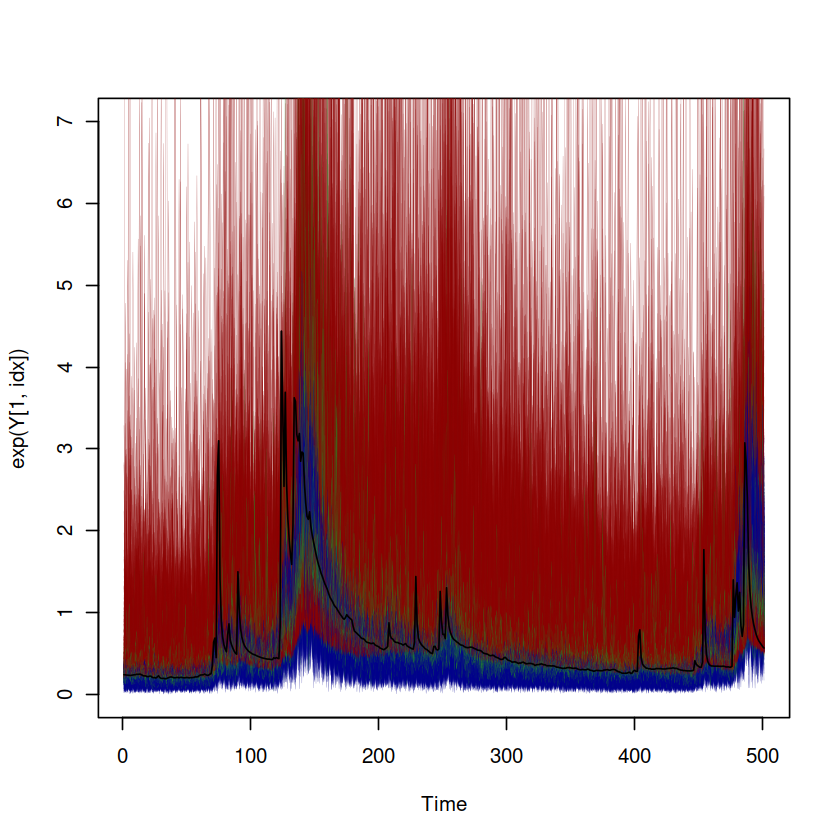

In [162]:
idx <- (TT-500):(TT)
n.samp <- dim(samp.theta_50_exAL_synth_PCA$samp_theta)[3]
plot.ts(exp(Y[1,idx]), ylim = c(0,7))
for(s in 1:n.samp){
    lines(exp_y_post_50[s,idx], lwd = 0.1, col='forestgreen')
    lines(exp_y_post_95[s,idx], lwd = 0.1, col='darkblue')
    lines(exp_y_post_5[s,idx], lwd = 0.1, col='darkred')
} 
lines(exp(Y[1,idx]))

In [163]:
q50 <- apply(y_post_50, 2, quantile, probs = c(0.5, 0.025, 0.5, 0.975))
m50 <- colMeans((y_post_50))
q5 <- apply(y_post_5, 2, quantile, probs = c(0.05, 0.025, 0.5, 0.975))
m5 <- colMeans((y_post_5))
q95 <- apply(y_post_95, 2, quantile, probs = c(0.95, 0.025, 0.5, 0.975))
m95 <- colMeans((y_post_95))
q20 <- apply(y_post_20, 2, quantile, probs = c(0.2, 0.025, 0.5, 0.975))
m20 <- colMeans((y_post_20))
q35 <- apply(y_post_35, 2, quantile, probs = c(0.35, 0.025, 0.5, 0.975))
m35 <- colMeans((y_post_35))
q65 <- apply(y_post_65, 2, quantile, probs = c(0.65, 0.025, 0.5, 0.975))
m65 <- colMeans((y_post_65))
q80 <- apply(y_post_80, 2, quantile, probs = c(0.8, 0.025, 0.5, 0.975))
m80 <- colMeans((y_post_80))

exp_q50 <- apply(exp_y_post_50, 2, quantile, probs = c(0.5, 0.025, 0.5, 0.975))
exp_m50 <- colMeans((exp_y_post_50))
exp_q5 <- apply(exp_y_post_5, 2, quantile, probs = c(0.05, 0.025, 0.5, 0.975))
exp_m5 <- colMeans((exp_y_post_5))
exp_q95 <- apply(exp_y_post_95, 2, quantile, probs = c(0.95, 0.025, 0.5, 0.975))
exp_m95 <- colMeans((exp_y_post_95))
exp_q20 <- apply(exp_y_post_20, 2, quantile, probs = c(0.2, 0.025, 0.5, 0.975))
exp_m20 <- colMeans((exp_y_post_20))
exp_q35 <- apply(exp_y_post_35, 2, quantile, probs = c(0.35, 0.025, 0.5, 0.975))
exp_m35 <- colMeans((exp_y_post_35))
exp_q65 <- apply(exp_y_post_65, 2, quantile, probs = c(0.65, 0.025, 0.5, 0.975))
exp_m65 <- colMeans((exp_y_post_65))
exp_q80 <- apply(exp_y_post_80, 2, quantile, probs = c(0.8, 0.025, 0.5, 0.975))
exp_m80 <- colMeans((exp_y_post_80))


In [164]:
# Define the time range and common y-axis limits
idx <- (TT - 500):(TT)
n.samp <- dim(samp.theta_50_exAL_synth_PCA$samp_theta)[3]
ylim_range <- c(0, 7)
output_dir <- "/data/muscat_data/jaguir26/project1_ucsc_phd/"

# Create a function for plotting posterior predictive samples with legends and labels (without the new.theta.out_p0_exAL_synth$exps)
plot_posterior_samples <- function(y_post, q, quantile_label, p0, color_post, color_quantile, ylim_range, idx) {
  par(mar = c(4, 4, 2, 2))  # Adjust margins
  plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
       col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
       main = paste(quantile_label, "Qntl.: Post. Pred. Samp."))
  
  for (s in 1:n.samp) {
    lines(timestamps[idx], y_post[s, idx], lwd = 0.1, col = color_post)
  }
  
  lines(timestamps[idx], q[1, idx], lwd = 1, col = color_quantile)  # Post. Pred. Quantile
  lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black')  # True Obs. Streamflow
  
  # Add a legend, slightly adjusted to the left
  legend(x = "topright", inset = c(0.2, 0), legend = c("Post. Pred. Samp.", paste0(p0, "th Post. Pred. Qntl."), "log(Streamflow)"),
         col = c(color_post, color_quantile, 'black'), lwd = c(1, 1, 1.5), bty = "n")
}

# Function to save individual plots (without new.theta.out_p0_exAL_synth$exps)
save_individual_plot <- function(filename, y_post, q, quantile_label, p0, color_post, color_quantile) {
  png(filename = paste0(output_dir, filename), width = 2000, height = 1200, res = 300)
  plot_posterior_samples(y_post, q, quantile_label, p0, color_post, color_quantile, ylim_range, idx)
  dev.off()
}

# Save individual plots
save_individual_plot("plot_50th_quantile_PCA.png", exp_y_post_50, exp_q50, "50th", "50", "forestgreen", "orange")
save_individual_plot("plot_95th_quantile_PCA.png", exp_y_post_95, exp_q95, "95th", "95", "darkblue", "orange")
save_individual_plot("plot_5th_quantile_PCA.png", exp_y_post_5, exp_q5, "5th", "5", "darkred", "orange")

# Save plot with all posterior samples together (without new.theta.out_p0_exAL_synth$exps)
png(filename = paste0(output_dir, "plot_all_quantiles_combined_PCA.png"), width = 2000, height = 1200, res = 300)
par(mar = c(4, 4, 2, 2))  # Adjust margins
plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
     col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
     main = "Post. Pred. Samp.: 50th, 95th, and 5th Qntls.")

for (s in 1:n.samp) {
  lines(timestamps[idx], exp_y_post_50[s, idx], lwd = 0.1, col = 'forestgreen')
  lines(timestamps[idx], exp_y_post_95[s, idx], lwd = 0.1, col = 'darkblue')
  lines(timestamps[idx], exp_y_post_5[s, idx], lwd = 0.1, col = 'darkred')
}

lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black')  # True Obs. Streamflow
legend(x = "topright", inset = c(0.2, 0), legend = c("50th Post. Pred. Samp.", "95th Post. Pred. Samp.", "5th Post. Pred. Samp.", "log(Streamflow)"),
       col = c("forestgreen", "darkblue", "darkred", 'black'), lwd = c(1, 1, 1, 1.5), bty = "n")
dev.off()

# Save matrix plot with 3 rows (without new.theta.out_p0_exAL_synth$exps)
png(filename = paste0(output_dir, "plot_3_row_matrix_PCA.png"), width = 2000, height = 1600, res = 300)
par(mfrow = c(3, 1), mar = c(4, 4, 2, 2))  # Set the layout to 3 rows and 1 column, adjust margins
plot_posterior_samples(exp_y_post_50, exp_q50, "50th", "50", "forestgreen", "orange", ylim_range, idx)
plot_posterior_samples(exp_y_post_95, exp_q95, "95th", "95", "darkblue", "orange", ylim_range, idx)
plot_posterior_samples(exp_y_post_5, exp_q5, "5th", "5", "darkred", "orange", ylim_range, idx)
dev.off()

# Save matrix plot with combined plot on top and 3 quantiles below (without new.theta.out_p0_exAL_synth$exps)
png(filename = paste0(output_dir, "plot_combined_matrix_PCA.png"), width = 2000, height = 1800, res = 300)
par(mfrow = c(4, 1), mar = c(4, 4, 2, 2))  # Set the layout to 4 rows and 1 column, adjust margins
plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
     col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
     main = "Post. Pred. Samp.: 50th, 95th, and 5th Qntls.")

for (s in 1:n.samp) {
  lines(timestamps[idx], exp_y_post_50[s, idx], lwd = 0.1, col = 'forestgreen')
  lines(timestamps[idx], exp_y_post_95[s, idx], lwd = 0.1, col = 'darkblue')
  lines(timestamps[idx], exp_y_post_5[s, idx], lwd = 0.1, col = 'darkred')
}

lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black')  # True Obs. Streamflow
legend(x = "topright", inset = c(0.2, 0), legend = c("50th Post. Pred. Samp.", "95th Post. Pred. Samp.", "5th Post. Pred. Samp.", "log(Streamflow)"),
       col = c("forestgreen", "darkblue", "darkred", 'black'), lwd = c(1, 1, 1, 1.5), bty = "n")

# Individual quantile plots
plot_posterior_samples(exp_y_post_50, exp_q50, "50th", "50", "forestgreen", "orange", ylim_range, idx)
plot_posterior_samples(exp_y_post_95, exp_q95, "95th", "95", "darkblue", "orange", ylim_range, idx)
plot_posterior_samples(exp_y_post_5, exp_q5, "5th", "5", "darkred", "orange", ylim_range, idx)
dev.off()

# Reset plotting parameters
par(mfrow = c(1, 1))  # Return to single plot layout


png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

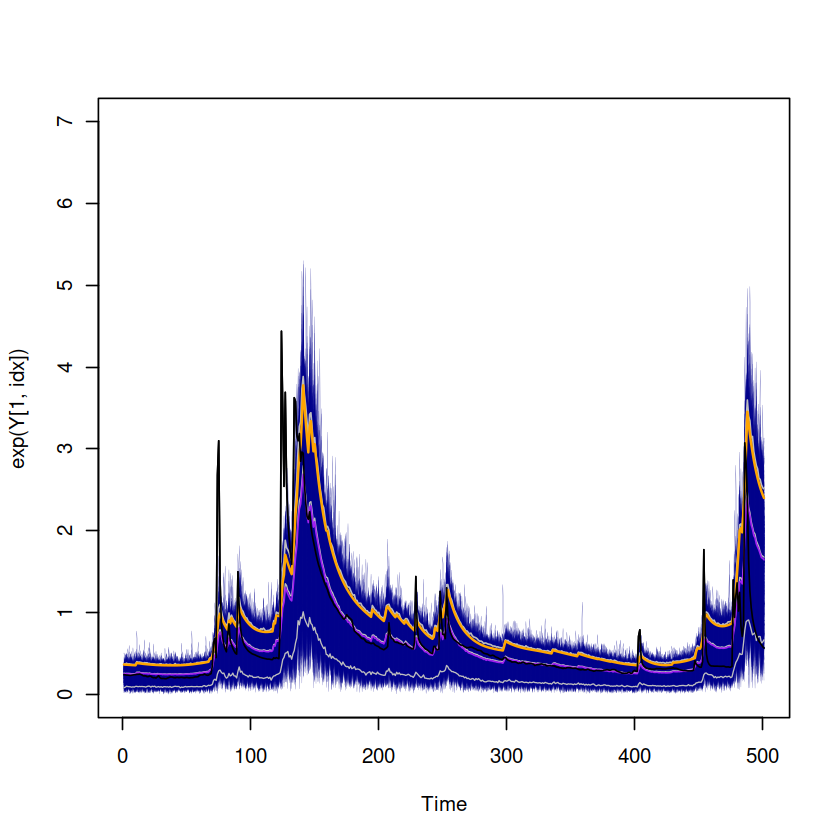

In [165]:
idx <- (TT-500):(TT)
n.samp <- dim(samp.theta_95_exAL_synth_PCA$samp_theta)[3]

plot.ts(exp(Y[1,idx]), ylim = c(0,7))
for(s in 1:n.samp){
    lines(exp_y_post_95[s,idx], lwd = 0.1, col='darkblue')
} 
lines(exp_q95[2,idx], lwd = 0.8, col='gray')
lines(exp_q95[3,idx], lwd = 0.8, col='gray')
lines(exp_q95[4,idx], lwd = 1, col='gray')
lines(t(exp_m95)[idx], lwd = 1, col='purple')
lines(exp(new.theta.out_95_exAL_synth_PCA$exps[1,idx]), lwd = 1.5, col='orange')
lines(exp(Y[1,idx]))



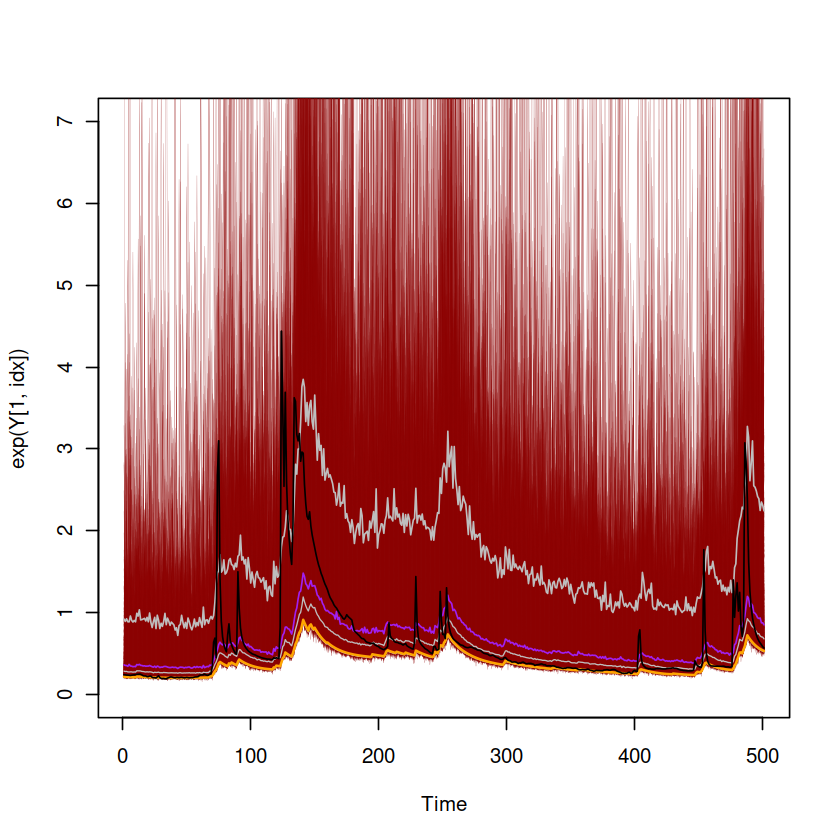

In [166]:
idx <- (TT-500):(TT)
n.samp <- dim(samp.theta_5_exAL_synth_PCA$samp_theta)[3]

plot.ts(exp(Y[1,idx]), ylim = c(0,7))
for(s in 1:n.samp){
    lines(exp_y_post_5[s,idx], lwd = 0.1, col='darkred')
} 
lines(exp_q5[2,idx], lwd = 0.8, col='gray')
lines(exp_q5[3,idx], lwd = 0.8, col='gray')
lines(exp_q5[4,idx], lwd = 1, col='gray')
lines(t(exp_m5)[idx], lwd = 1, col='purple')
lines(exp(new.theta.out_5_exAL_synth_PCA$exps[1,idx]), lwd = 1.5, col='orange')
lines(exp(Y[1,idx]))

In [167]:
# k<- 10
# idx <- (TT-500):(TT)
# n.samp <- dim(samp.theta_50_exAL_synth$samp_theta)[3]
# synth_q <- matrix(NA_real_, nrow = n.samp, ncol = TT)
# for(t in 1:TT){
#     w <- rep(0,7)
#     for(s in 1:n.samp){
#         diff <- y_post_5[s,t]-q5[1,t]
#         w[1] <- exp(-k*CheckLossFn(0.05,diff)/samp.sigma_5_exAL_synth[1,s])
#         diff <- y_post_50[s,t]-q50[1,t]
#         w[2] <- exp(-k*CheckLossFn(0.5,diff)/samp.sigma_50_exAL_synth[1,s])
#         diff <- y_post_95[s,t]-q95[1,t]
#         w[3] <- exp(-k*CheckLossFn(0.95,diff)/samp.sigma_95_exAL_synth[1,s])
#         diff <- y_post_20[s,t]-q20[1,t]
#         w[4] <- exp(-k*CheckLossFn(0.2,diff)/samp.sigma_20_exAL_synth[1,s])
#         diff <- y_post_35[s,t]-q35[1,t]
#         w[5] <- exp(-k*CheckLossFn(0.35,diff)/samp.sigma_35_exAL_synth[1,s])
#         diff <- y_post_80[s,t]-q80[1,t]
#         w[6] <- exp(-k*CheckLossFn(0.80,diff)/samp.sigma_80_exAL_synth[1,s])
#         diff <- y_post_65[s,t]-q65[1,t]
#         w[7] <- exp(-k*CheckLossFn(0.65,diff)/samp.sigma_65_exAL_synth[1,s])
#         w <- w/sum(w)
#         synth_q[s,t] <- sum(w*c(q5[1,t],q50[1,t],q95[1,t],q20[1,t],q35[1,t],q80[1,t],q65[1,t]))
#     } 
# }

In [168]:
# idx <- (TT-500):(TT)
# n.samp <- dim(samp.theta_5_exAL_synth$samp_theta)[3]

# plot.ts(exp(Y[1,idx]), ylim = c(0,7))
# # for(s in 1:n.samp){
# #     lines(synth[s,idx], lwd = 0.1, col='gray')
# # } 
# for(s in 1:n.samp){
#     lines(synth_q[s,idx], lwd = 0.1, col='purple')
# } 
# lines(exp(Y[1,idx]))


# # points(exp(Y[1,idx]), col='gray')
# # lines(exp(new.theta.out_5_exAL_synth$exps[1,idx]), lwd = 0.6, col='red')
# # lines(exp(new.theta.out_50_exAL_synth$exps[1,idx]), lwd = 0.6, col='green')
# # lines(exp(new.theta.out_95_exAL_synth$exps[1,idx]), lwd = 0.6, col='blue')
# # lines(exp(new.theta.out_20_exAL_synth$exps[1,idx]), lwd = 0.6, col='pink')
# # lines(exp(new.theta.out_35_exAL_synth$exps[1,idx]), lwd = 0.6, col='pink')
# # lines(exp(new.theta.out_65_exAL_synth$exps[1,idx]), lwd = 0.6, col='pink')
# # lines(exp(new.theta.out_80_exAL_synth$exps[1,idx]), lwd = 0.6, col='pink')
# # lines(q5[1,idx], lwd = 1.5, col='gray')


In [169]:
# idx <- (TT-500):(TT)
# n.samp <- dim(samp.theta_5_exAL_synth$samp_theta)[3]

# plot.ts(exp(Y[1,idx]), ylim = c(0,6))
# for(s in 1:n.samp){
#     lines(exp(synth[s,idx]), lwd = 0.1, col='gray')
# } 
# for(s in 1:n.samp){
#     lines(exp(synth_q[s,idx]), lwd = 0.1, col='purple')
# } 
# lines(exp(Y[1,idx]))
# points(exp(Y[1,idx]), col='gray')
# lines(exp(new.theta.out_5_exAL_synth$exps[1,idx]), lwd = 0.6, col='red')
# lines(exp(new.theta.out_50_exAL_synth$exps[1,idx]), lwd = 0.6, col='green')
# lines(exp(new.theta.out_95_exAL_synth$exps[1,idx]), lwd = 0.6, col='blue')
# lines(exp(new.theta.out_20_exAL_synth$exps[1,idx]), lwd = 0.6, col='pink')
# lines(exp(new.theta.out_35_exAL_synth$exps[1,idx]), lwd = 0.6, col='pink')
# lines(exp(new.theta.out_65_exAL_synth$exps[1,idx]), lwd = 0.6, col='pink')
# lines(exp(new.theta.out_80_exAL_synth$exps[1,idx]), lwd = 0.6, col='pink')
# # lines(q5[1,idx], lwd = 1.5, col='gray')
# # lines(q50[2,idx], lwd = 1.5, col='gray')
# # lines(q95[3,idx], lwd = 1.5, col='gray')

In [170]:
library(truncnorm)
set.seed(777)
############################################################################
# Function Definitions
inverse_cdf_AL <- function(U, mu, sigma, p) {
  ifelse(U < p, 
         mu + (sigma / (1 - p)) * log(U / p), 
         mu - (sigma / p) * log((1 - U) / (1 - p)))
}
############################################################################
p.fn <- function(p0, gam) {
  (p0 - as.numeric(gam < 0)) / exp(log.g(gam)) + as.numeric(gam < 0)
}
############################################################################
C.fn <- function(p0, gam) {
  temp.p <- p.fn(p0, gam)
  (as.numeric(gam > 0) - temp.p)^(-1)
}
############################################################################
# Generalized function to handle each case
generate_y_post <- function(p0, xb_matrix, gamma_sample, sigma_sample) {
  n_rows <- dim(xb_matrix)[1]
  n_cols <- dim(xb_matrix)[2]
  y_post <- matrix(NA_real_, nrow = n_rows, ncol = n_cols)
  
  for (t in 1:n_cols) {
    s_0 <- rtruncnorm(1, a=0, b=Inf, mean = 0, sd = 1)
    u <- runif(n_rows)
    y_post[,t] <- xb_matrix[,t] + sigma_sample * abs(gamma_sample) * C.fn(p0, gamma_sample) * s_0 +  
                  sigma_sample * inverse_cdf_AL(u, 0, 1, p.fn(p0, gamma_sample))
  }

  return(y_post)
}
############################################################################
# Case 1: p0 = 0.05
p0_05 <- 0.05
xb_05_f <- t(xbs[1,,])
gam_05_f <- samp.gamma_5_exAL_synth_PCA[1,]
sig_05_f <- samp.sigma_5_exAL_synth_PCA[1,]
y_post_5_f <- (generate_y_post(p0_05, xb_05_f, gam_05_f, sig_05_f))
exp_y_post_5_f <- exp(generate_y_post(p0_05, xb_05_f, gam_05_f, sig_05_f))
# Case 2: p0 = 0.5
p0_50 <- 0.5
xb_50_f <- t(xbs[4,,])
gam_50_f <- samp.gamma_50_exAL_synth_PCA[1,]
sig_50_f <- samp.sigma_50_exAL_synth_PCA[1,]
y_post_50_f <- (generate_y_post(p0_50, xb_50_f, gam_50_f, sig_50_f))
exp_y_post_50_f <- exp(generate_y_post(p0_50, xb_50_f, gam_50_f, sig_50_f))
# Case 3: p0 = 0.95
p0_95 <- 0.95
xb_95_f <- t(xbs[7,,])
gam_95_f <- samp.gamma_95_exAL_synth_PCA[1,]
sig_95_f <- samp.sigma_95_exAL_synth_PCA[1,]
y_post_95_f <- (generate_y_post(p0_95, xb_95_f, gam_95_f, sig_95_f))
exp_y_post_95_f <- exp(generate_y_post(p0_95, xb_95_f, gam_95_f, sig_95_f))
# Case 4: p0 = 0.20
p0_20 <- 0.20
xb_20_f <- t(xbs[2,,])
gam_20_f <- samp.gamma_20_exAL_synth_PCA[1,]
sig_20_f <- samp.sigma_20_exAL_synth_PCA[1,]
y_post_20_f <- (generate_y_post(p0_20, xb_20_f, gam_20_f, sig_20_f))
exp_y_post_20_f <- exp(generate_y_post(p0_20, xb_20_f, gam_20_f, sig_20_f))
# Case 5: p0 = 0.80
p0_80 <- 0.80
xb_80_f <- t(xbs[6,,])
gam_80_f <- samp.gamma_80_exAL_synth_PCA[1,]
sig_80_f <- samp.sigma_80_exAL_synth_PCA[1,]
y_post_80_f <- (generate_y_post(p0_80, xb_80_f, gam_80_f, sig_80_f))
exp_y_post_80_f <- exp(generate_y_post(p0_80, xb_80_f, gam_80_f, sig_80_f))
# Case 6: p0 = 0.35
p0_35 <- 0.35
xb_35_f <- t(xbs[3,,])
gam_35_f <- samp.gamma_35_exAL_synth_PCA[1,]
sig_35_f <- samp.sigma_35_exAL_synth_PCA[1,]
y_post_35_f <- (generate_y_post(p0_35, xb_35_f, gam_35_f, sig_35_f))
exp_y_post_35_f <- exp(generate_y_post(p0_35, xb_35_f, gam_35_f, sig_35_f))
# Case 7: p0 = 0.65
p0_65 <- 0.65
xb_65_f <- t(xbs[5,,])
gam_65_f <- samp.gamma_65_exAL_synth_PCA[1,]
sig_65_f <- samp.sigma_65_exAL_synth_PCA[1,]
y_post_65_f <- (generate_y_post(p0_65, xb_65_f, gam_65_f, sig_65_f))
exp_y_post_65_f <- exp(generate_y_post(p0_65, xb_65_f, gam_65_f, sig_65_f))
############################################################################
n_rows_5 <- dim(xb_05_f)[1]
n_cols_5 <- dim(xb_05_f)[2]



In [171]:
# Initialize the y_reps array with dimensions 7 x n.samp x TT
y_reps_f <- array(NA, dim = c(7, n_rows_5, n_cols_5))

# Populate the array as specified
y_reps_f[1,,] <- exp_y_post_5_f[,]
y_reps_f[4,,] <- exp_y_post_50_f[,]
y_reps_f[7,,] <- exp_y_post_95_f[,]
y_reps_f[2,,] <- exp_y_post_20_f[,]
y_reps_f[3,,] <- exp_y_post_35_f[,]
y_reps_f[5,,] <- exp_y_post_80_f[,]
y_reps_f[6,,] <- exp_y_post_65_f[,]

# Save the array to your current directory
saveRDS(y_reps_f, file = "y_reps_f.rds")

print("Array y_reps saved as y_reps.rds in the current directory.")

[1] "Array y_reps saved as y_reps.rds in the current directory."


In [172]:
# Function to plot lines for multiple forecasts
plot_forecast_lines <- function(idx, y_post, xb_f, n_rows, truth, color_forecast = 'gray', color_baseline = 'pink') {
  for (s in 1:n_rows) {
    # Forecast lines
    lines((length(idx) + 1):(length(idx) + length(truth)), y_post[s, ], ylab = "", col = color_forecast)
    # Baseline lines
    lines((length(idx) + 1):(length(idx) + length(truth)), xb_f[s, ], ylab = "", col = color_baseline)
  }
}

# Plot for the log-transformed truth data
plot_log_truth_data <- function(idx, Y, truth, y_post_95, y_post_5, y_post_50, y_post_20, y_post_35, y_post_80, y_post_65,
                                xb_95_f, xb_05_f, xb_50_f, xb_20_f, xb_35_f, xb_80_f, xb_65_f, n_rows) {
  plot.ts(rep(0, length(idx) + 30), ylab = "", ylim = c(-1.5, 2.5))
  lines(Y[1, idx], ylab = "")
  points(Y[1, idx], ylab = "", pch = 19)
  
  # Forecast lines
  plot_forecast_lines(idx, y_post_95, xb_95_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_5, xb_05_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_50, xb_50_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_20, xb_20_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_35, xb_35_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_80, xb_80_f, n_rows, truth)
  plot_forecast_lines(idx, y_post_65, xb_65_f, n_rows, truth)
  
  # Add truth points
  points((length(idx) + 1):(length(idx) + length(truth)), truth, ylab = "", col = 'darkred', pch = 19)
}

# Plot for the exp-transformed truth data
plot_exp_truth_data <- function(idx, Y, truth, y_post_95, y_post_5, y_post_50, y_post_20, y_post_35, y_post_80, y_post_65,
                                xb_95_f, xb_05_f, xb_50_f, xb_20_f, xb_35_f, xb_80_f, xb_65_f, n_rows) {
  plot.ts(rep(0, length(idx) + 30), ylab = "", ylim = c(0, 10))
  lines(exp(Y[1, idx]), ylab = "")
  points(exp(Y[1, idx]), ylab = "", pch = 19)
  
  # Forecast lines
  plot_forecast_lines(idx, exp(y_post_95), exp(xb_95_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_5), exp(xb_05_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_50), exp(xb_50_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_20), exp(xb_20_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_35), exp(xb_35_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_80), exp(xb_80_f), n_rows, truth)
  plot_forecast_lines(idx, exp(y_post_65), exp(xb_65_f), n_rows, truth)
  
  # Add truth points
  points((length(idx) + 1):(length(idx) + length(truth)), truth, ylab = "", col = 'darkred', pch = 19)
}

# Applying quantile computations and mean for each case
compute_quantiles_means <- function(y_post,q0) {
  quantiles <- apply(y_post, 2, quantile, probs = c(q0,0.05, 0.5, 0.95))
  mean_values <- colMeans(y_post)
  return(list(quantiles = quantiles, means = mean_values))
}

# Generate quantiles and means for each posterior
q50_f <- compute_quantiles_means(y_post_50_f,0.5)
q5_f <- compute_quantiles_means(y_post_5_f,0.05)
q95_f <- compute_quantiles_means(y_post_95_f,0.95)
q20_f <- compute_quantiles_means(y_post_20_f,0.2)
q35_f <- compute_quantiles_means(y_post_35_f,0.35)
q65_f <- compute_quantiles_means(y_post_65_f,0.65)
q80_f <- compute_quantiles_means(y_post_80_f,0.8)

exp_q50_f <- compute_quantiles_means(exp_y_post_50_f,0.5)
exp_q5_f <- compute_quantiles_means(exp_y_post_5_f,0.05)
exp_q95_f <- compute_quantiles_means(exp_y_post_95_f,0.95)
exp_q20_f <- compute_quantiles_means(exp_y_post_20_f,0.2)
exp_q35_f <- compute_quantiles_means(exp_y_post_35_f,0.35)
exp_q65_f <- compute_quantiles_means(exp_y_post_65_f,0.65)
exp_q80_f <- compute_quantiles_means(exp_y_post_80_f,0.8)




In [173]:
# k<- 10
# idx <- (TT-500):(TT)
# n.samp <- dim(samp.theta_50_exAL_synth$samp_theta)[3]
# synth <- matrix(NA_real_, nrow = n.samp, ncol = TT)
# synth_q <- matrix(NA_real_, nrow = n.samp, ncol = TT)
# for(t in 1:TT){
#     w <- rep(0,7)
#     for(s in 1:n.samp){
#         diff <- y_post_5[s,t]-q5[1,t]
#         w[1] <- exp(-k*CheckLossFn(0.05,diff)/samp.sigma_5_exAL_synth[1,s])
#         diff <- y_post_50[s,t]-q50[1,t]
#         w[2] <- exp(-k*CheckLossFn(0.5,diff)/samp.sigma_50_exAL_synth[1,s])
#         diff <- y_post_95[s,t]-q95[1,t]
#         w[3] <- exp(-k*CheckLossFn(0.95,diff)/samp.sigma_95_exAL_synth[1,s])
#         diff <- y_post_20[s,t]-q20[1,t]
#         w[4] <- exp(-k*CheckLossFn(0.2,diff)/samp.sigma_20_exAL_synth[1,s])
#         diff <- y_post_35[s,t]-q35[1,t]
#         w[5] <- exp(-k*CheckLossFn(0.35,diff)/samp.sigma_35_exAL_synth[1,s])
#         diff <- y_post_80[s,t]-q80[1,t]
#         w[6] <- exp(-k*CheckLossFn(0.80,diff)/samp.sigma_80_exAL_synth[1,s])
#         diff <- y_post_65[s,t]-q65[1,t]
#         w[7] <- exp(-k*CheckLossFn(0.65,diff)/samp.sigma_65_exAL_synth[1,s])
#         w <- w/sum(w)
#         synth_q[s,t] <- sum(w*c(q5[1,t],q50[1,t],q95[1,t],q20[1,t],q35[1,t],q80[1,t],q65[1,t]))
#     } 
# }

In [174]:
# n.samp <- dim(samp.theta_50_exAL_synth$samp_theta)[3]
# synth_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
# synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
# for(t in 1:ranges[1]){
#     w <- rep(0,7)
#     for(s in 1:n.samp){
#         diff <- y_post_5[s,t]-q5_f$quantiles[1,t]
#         w[1] <- exp(-k*CheckLossFn(0.05,diff)/samp.sigma_5_exAL_synth[1,s])
#         diff <- y_post_50[s,t]-q50_f$quantiles[1,t]
#         w[2] <- exp(-k*CheckLossFn(0.5,diff)/samp.sigma_50_exAL_synth[1,s])
#         diff <- y_post_95[s,t]-q95_f$quantiles[1,t]
#         w[3] <- exp(-k*CheckLossFn(0.95,diff)/samp.sigma_95_exAL_synth[1,s])
#         diff <- y_post_20[s,t]-q20_f$quantiles[1,t]
#         w[4] <- exp(-k*CheckLossFn(0.2,diff)/samp.sigma_20_exAL_synth[1,s])
#         diff <- y_post_35[s,t]-q35_f$quantiles[1,t]
#         w[5] <- exp(-k*CheckLossFn(0.35,diff)/samp.sigma_35_exAL_synth[1,s])
#         diff <- y_post_80[s,t]-q80_f$quantiles[1,t]
#         w[6] <- exp(-k*CheckLossFn(0.80,diff)/samp.sigma_80_exAL_synth[1,s])
#         diff <- y_post_65[s,t]-q65_f$quantiles[1,t]
#         w[7] <- exp(-k*CheckLossFn(0.65,diff)/samp.sigma_65_exAL_synth[1,s])
#         w <- w/sum(w)
#         synth_q_f[s,t] <- sum(w*c(q5_f$quantiles[1,t],q50_f$quantiles[1,t],q95_f$quantiles[1,t],
#                                   q20_f$quantiles[1,t],q35_f$quantiles[1,t],q80_f$quantiles[1,t],q65_f$quantiles[1,t]))
#     } 
# }


In [175]:

# q_synth <- apply(synth_q_f, 2, quantile, probs = c(0.025, 0.5, 0.975))
# m_synth <- colMeans((synth_q_f))

# ################################################################################################################################################

# truth<- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date>=as.Date('2022-12-26')]
# truth <- log(truth[1:ranges[1]])
# idx <- (TT-30):(TT)
# plot.ts(rep(0, length(idx)+30), ylab="", ylim=c(-1.5,2.5))
# lines((Y[1,idx]), ylab="")
# points((Y[1,idx]), ylab="", pch = 19)

# for(s in 1:n.samp){
#     lines((length(idx)+1):(length(idx)+length(truth)),synth_f[s,], lwd = 0.1, col='gray')
# } 
# for(s in 1:n.samp){
#     lines((length(idx)+1):(length(idx)+length(truth)),synth_q_f[s,], lwd = 0.1, col='purple')
# } 

# points((length(idx)+1):(length(idx)+length(truth)), (truth), ylab="", col='darkred', pch = 19)

# # lines((length(idx)+1):(length(idx)+length(truth)),q95$quantiles[3,], lwd = 0.6, col='black')
# lines((length(idx)+1):(length(idx)+length(truth)),q_synth[3,], lwd = 0.6, col='black')
# lines((length(idx)+1):(length(idx)+length(truth)),q_synth[1,], lwd = 0.6, col='black')

# ################################################################################################################################################

# truth<- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date>=as.Date('2022-12-26')]
# truth <- (truth[1:ranges[1]])
# idx <- (TT-30):(TT)
# plot.ts(rep(0, length(idx)+30), ylab="", ylim=c(0,6))
# lines(exp(Y[1,idx]), ylab="")
# points(exp(Y[1,idx]), ylab="", pch = 19)

# for(s in 1:n.samp){
#     lines((length(idx)+1):(length(idx)+length(truth)),exp(synth_f[s,]), lwd = 0.1, col='gray')
# } 
# for(s in 1:n.samp){
#     lines((length(idx)+1):(length(idx)+length(truth)),exp(synth_q_f[s,]), lwd = 0.1, col='purple')
# } 
# points((length(idx)+1):(length(idx)+length(truth)),(truth), ylab="", col='darkred', pch = 19)
# lines((length(idx)+1):(length(idx)+length(truth)),exp(q_synth[3,]), lwd = 0.6, col='black')
# lines((length(idx)+1):(length(idx)+length(truth)),exp(q_synth[1,]), lwd = 0.6, col='black')



In [176]:
# k <- 9
# alpha <- 0
# idx <- (TT-500):(TT)
# jitter <- 0.001

# n.samp <- dim(samp.theta_50_exAL_synth$samp_theta)[3]
# synth_q <- matrix(NA_real_, nrow = n.samp, ncol = TT)
# exp_synth_q <- matrix(NA_real_, nrow = n.samp, ncol = TT)
# r_exp_synth_q <- matrix(NA_real_, nrow = n.samp, ncol = TT)
# for(s in 1:n.samp){
#     w <- rep(1,7) 
#     w <- w/sum(w) 
#     exp_w <- rep(1,7) 
#     exp_w <- exp_w/sum(exp_w) 
#     for(t in 1:TT){
#         # diff5  <- y_post_5[s,t]-q5[1,t]
#         # v5 <- -k*CheckLossFn(0.05,diff5)/samp.sigma_5_exAL_synth[1,s]
#         # diff50 <- y_post_50[s,t]-q50[1,t]
#         # v50 <- -k*CheckLossFn(0.5,diff50)/samp.sigma_50_exAL_synth[1,s]
#         # diff95 <- y_post_95[s,t]-q95[1,t]
#         # v95 <- -k*CheckLossFn(0.95,diff95)/samp.sigma_95_exAL_synth[1,s]
#         # diff20 <- y_post_20[s,t]-q20[1,t]
#         # v20 <- -k*CheckLossFn(0.2,diff20)/samp.sigma_20_exAL_synth[1,s]
#         # diff35 <- y_post_35[s,t]-q35[1,t]
#         # v35 <- -k*CheckLossFn(0.35,diff35)/samp.sigma_35_exAL_synth[1,s]
#         # diff80 <- y_post_80[s,t]-q80[1,t]
#         # v80 <- -k*CheckLossFn(0.8,diff80)/samp.sigma_80_exAL_synth[1,s]
#         # diff65 <- y_post_65[s,t]-q65[1,t]
#         # v65 <- -k*CheckLossFn(0.65,diff65)/samp.sigma_65_exAL_synth[1,s]

#         # vv <- alpha*log(w+jitter) + c(v5,v50,v95,v20,v35,v80,v65)
#         # v_m <- vv[which.max((vv))]  
#         # w <- exp(vv-v_m)
#         # w <- w/sum(w)
#         # # synth_q[s,t] <- sum(w*c(q5[1,t],q50[1,t],q95[1,t],
#         # #                         q20[1,t],q35[1,t],q80[1,t],q65[1,t]))
#         # synth_q[s,t] <- sum(w*c(y_post_5[s,t],y_post_50[s,t],y_post_95[s,t],
#         #                 y_post_20[s,t],y_post_35[s,t],y_post_80[s,t],y_post_65[s,t]))
        
#         ##############################################################################

#         exp_diff5  <- exp_y_post_5[s,t]-exp_q5[1,t]
#         exp_v5 <- -k*CheckLossFn(0.05,exp_diff5)/samp.sigma_5_exAL_synth[1,s]
#         exp_diff50 <- exp_y_post_50[s,t]-exp_q50[1,t]
#         exp_v50 <- -k*CheckLossFn(0.5,exp_diff50)/samp.sigma_50_exAL_synth[1,s]
#         exp_diff95 <- exp_y_post_95[s,t]-exp_q95[1,t]
#         exp_v95 <- -k*CheckLossFn(0.95,exp_diff95)/samp.sigma_95_exAL_synth[1,s]
#         exp_diff20 <- exp_y_post_20[s,t]-exp_q20[1,t]
#         exp_v20 <- -k*CheckLossFn(0.2,exp_diff20)/samp.sigma_20_exAL_synth[1,s]
#         exp_diff35 <- exp_y_post_35[s,t]-exp_q35[1,t]
#         exp_v35 <- -k*CheckLossFn(0.35,exp_diff35)/samp.sigma_35_exAL_synth[1,s]
#         exp_diff80 <- exp_y_post_80[s,t]-exp_q80[1,t]
#         exp_v80 <- -k*CheckLossFn(0.8,exp_diff80)/samp.sigma_80_exAL_synth[1,s]
#         exp_diff65 <- exp_y_post_65[s,t]-exp_q65[1,t]
#         exp_v65 <- -k*CheckLossFn(0.65,exp_diff65)/samp.sigma_65_exAL_synth[1,s]

#         exp_vv <- alpha*log(exp_w+jitter) + c(exp_v5,exp_v50,exp_v95,exp_v20,exp_v35,exp_v80,exp_v65)
#         exp_v_m <- exp_vv[which.max((exp_vv))]  
#         exp_w <- exp(exp_vv-exp_v_m)
#         exp_w <- exp_w/sum(exp_w)
#         # synth_q[s,t] <- sum(w*c(q5[1,t],q50[1,t],q95[1,t],
#         #                         q20[1,t],q35[1,t],q80[1,t],q65[1,t]))
#         y_post_st <- c(exp_y_post_5[s,t],exp_y_post_50[s,t],exp_y_post_95[s,t],
#                         exp_y_post_20[s,t],exp_y_post_35[s,t],exp_y_post_80[s,t],exp_y_post_65[s,t])
#         exp_synth_q[s,t] <- sum(exp_w*y_post_st)
#         r_exp_synth_q[s,t] <- sample(y_post_st, size = 1, prob = exp_w)

#     } 
# }

# n.samp <- dim(samp.theta_50_exAL_synth$samp_theta)[3]
# synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
# exp_synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
# r_exp_synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
# for(s in 1:n.samp){ 
#     w <- rep(1,7)
#     w <- w/sum(w)
#     exp_w <- rep(1,7) 
#     exp_w <- exp_w/sum(exp_w)
#     for(t in 1:ranges[1]){
#         # diff5  <- y_post_5_f[s,t]-q5_f$quantiles[1,t]
#         # v5 <- -k*CheckLossFn(0.05,diff5)/samp.sigma_5_exAL_synth[1,s]
#         # diff50 <- y_post_50_f[s,t]-q50_f$quantiles[1,t]
#         # v50 <- -k*CheckLossFn(0.5,diff50)/samp.sigma_50_exAL_synth[1,s]
#         # diff95 <- y_post_95_f[s,t]-q95_f$quantiles[1,t]
#         # v95 <- -k*CheckLossFn(0.95,diff95)/samp.sigma_95_exAL_synth[1,s]
#         # diff20 <- y_post_20_f[s,t]-q20_f$quantiles[1,t]
#         # v20 <- -k*CheckLossFn(0.2,diff20)/samp.sigma_20_exAL_synth[1,s]
#         # diff35 <- y_post_35_f[s,t]-q35_f$quantiles[1,t]
#         # v35 <- -k*CheckLossFn(0.35,diff35)/samp.sigma_35_exAL_synth[1,s]
#         # diff80 <- y_post_80_f[s,t]-q80_f$quantiles[1,t]
#         # v80 <- -k*CheckLossFn(0.8,diff80)/samp.sigma_80_exAL_synth[1,s]
#         # diff65 <- y_post_65_f[s,t]-q65_f$quantiles[1,t]
#         # v65 <- -k*CheckLossFn(0.05,diff65)/samp.sigma_65_exAL_synth[1,s]

#         # vv <- alpha*log(w) + c(v5,v50,v95,v20,v35,v80,v65)
#         # v_m <- vv[which.max((vv))]  
#         # w <- exp(vv-v_m)
#         # w <- w/sum(w)
#         # # synth_q[s,t] <- sum(w*c(q5[1,t],q50[1,t],q95[1,t],
#         # #                         q20[1,t],q35[1,t],q80[1,t],q65[1,t]))
#         # synth_q_f[s,t] <- sum(w*c(y_post_5_f[s,t],y_post_50_f[s,t],y_post_95_f[s,t],
#         #                 y_post_20_f[s,t],y_post_35_f[s,t],y_post_80_f[s,t],y_post_65_f[s,t]))

#         ##############################################################################
#         exp_diff5  <- exp_y_post_5_f[s,t]-exp_q5_f$quantiles[1,t]
#         exp_v5 <- -k*CheckLossFn(0.05,exp_diff5)/samp.sigma_5_exAL_synth[1,s]
#         exp_diff50 <- exp_y_post_50_f[s,t]-exp_q50_f$quantiles[1,t]
#         exp_v50 <- -k*CheckLossFn(0.5,exp_diff50)/samp.sigma_50_exAL_synth[1,s]
#         exp_diff95 <- exp_y_post_95_f[s,t]-exp_q95_f$quantiles[1,t]
#         exp_v95 <- -k*CheckLossFn(0.95,exp_diff95)/samp.sigma_95_exAL_synth[1,s]
#         exp_diff20 <- exp_y_post_20_f[s,t]-exp_q20_f$quantiles[1,t]
#         exp_v20 <- -k*CheckLossFn(0.2,exp_diff20)/samp.sigma_20_exAL_synth[1,s]
#         exp_diff35 <- exp_y_post_35_f[s,t]-exp_q35_f$quantiles[1,t]
#         exp_v35 <- -k*CheckLossFn(0.35,exp_diff35)/samp.sigma_35_exAL_synth[1,s]
#         exp_diff80 <- exp_y_post_80_f[s,t]-exp_q80_f$quantiles[1,t]
#         exp_v80 <- -k*CheckLossFn(0.8,exp_diff80)/samp.sigma_80_exAL_synth[1,s]
#         exp_diff65 <- exp_y_post_65_f[s,t]-exp_q65_f$quantiles[1,t]
#         exp_v65 <- -k*CheckLossFn(0.05,exp_diff65)/samp.sigma_65_exAL_synth[1,s]

#         exp_vv <- alpha*log(exp_w) + c(exp_v5,exp_v50,exp_v95,exp_v20,exp_v35,exp_v80,exp_v65)
#         exp_v_m <- exp_vv[which.max((exp_vv))]  
#         exp_w <- exp(exp_vv-exp_v_m)
#         exp_w <- exp_w/sum(exp_w)
#         # synth_q[s,t] <- sum(w*c(q5[1,t],q50[1,t],q95[1,t],
#         #                         q20[1,t],q35[1,t],q80[1,t],q65[1,t]))
#         y_post_st <- c(exp_y_post_5_f[s,t],exp_y_post_50_f[s,t],exp_y_post_95_f[s,t],
#                         exp_y_post_20_f[s,t],exp_y_post_35_f[s,t],exp_y_post_80_f[s,t],exp_y_post_65_f[s,t])
#         exp_synth_q_f[s,t] <- sum(exp_w*y_post_st)
#         r_exp_synth_q_f[s,t] <- sample(y_post_st, size = 1, prob = exp_w)
 
#     } 
# }

In [177]:
set.seed(777)
k <- 10
alpha <- 0
idx <- (TT-500):(TT)
jitter <- 0.001

n.samp        <- dim(samp.theta_50_exAL_synth_PCA$samp_theta)[3]
synth_q       <- matrix(NA_real_, nrow = n.samp, ncol = TT)
exp_synth_q   <- matrix(NA_real_, nrow = n.samp, ncol = TT)
r_exp_synth_q <- matrix(NA_real_, nrow = n.samp, ncol = TT)

exp_w <- matrix(1, ncol = 7, nrow = n.samp)
exp_w <- t(apply(exp_w, 1, function(row) row / sum(row)))
for(t in 1:TT){
  ##########
  exp_diff5  <- exp_y_post_5[,t]-exp_q5[1,t]
  exp_v5 <- -k*CheckLossFn(0.05,exp_diff5)/exp(samp.sigma_5_exAL_synth_PCA[1,])
  exp_diff50 <- exp_y_post_50[,t]-exp_q50[1,t]
  exp_v50 <- -k*CheckLossFn(0.5,exp_diff50)/exp(samp.sigma_50_exAL_synth_PCA[1,])
  exp_diff95 <- exp_y_post_95[,t]-exp_q95[1,t]
  exp_v95 <- -k*CheckLossFn(0.95,exp_diff95)/exp(samp.sigma_95_exAL_synth_PCA[1,])
  exp_diff20 <- exp_y_post_20[,t]-exp_q20[1,t]
  exp_v20 <- -k*CheckLossFn(0.2,exp_diff20)/exp(samp.sigma_20_exAL_synth_PCA[1,])
  exp_diff35 <- exp_y_post_35[,t]-exp_q35[1,t]
  exp_v35 <- -k*CheckLossFn(0.35,exp_diff35)/exp(samp.sigma_35_exAL_synth_PCA[1,])
  exp_diff80 <- exp_y_post_80[,t]-exp_q80[1,t]
  exp_v80 <- -k*CheckLossFn(0.8,exp_diff80)/exp(samp.sigma_80_exAL_synth_PCA[1,])
  exp_diff65 <- exp_y_post_65[,t]-exp_q65[1,t]
  exp_v65 <- -k*CheckLossFn(0.65,exp_diff65)/exp(samp.sigma_65_exAL_synth_PCA[1,])
  ##########
  exp_vv <- alpha*log(exp_w+jitter) + cbind(exp_v5,exp_v50,exp_v95,exp_v20,exp_v35,exp_v80,exp_v65)
  exp_v_m <- apply(exp_vv, 1, max)
  exp_w <- exp(exp_vv-exp_v_m)
  exp_w <- t(apply(exp_w, 1, function(row) row / sum(row)))
  ##########
  y_post_t <- cbind(exp_y_post_5[,t],exp_y_post_50[,t],exp_y_post_95[,t],
                  exp_y_post_20[,t],exp_y_post_35[,t],exp_y_post_80[,t],exp_y_post_65[,t])
  exp_synth_q[,t] <- rowSums(exp_w*y_post_t)
  selected_values <- sapply(1:n.samp, function(i) {
    sample(y_post_t[i, ], size = 1, prob = exp_w[i, ])
  })
  r_exp_synth_q[,t] <- selected_values
} 

In [178]:
set.seed(777)

n.samp <- dim(samp.theta_50_exAL_synth_PCA$samp_theta)[3]
synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
exp_synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
r_exp_synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])

for(t in 1:ranges[1]){
    ##########
    exp_diff5  <- exp_y_post_5_f[,t]-exp_q5_f$quantiles[1,t]
    exp_v5 <- -k*CheckLossFn(0.05,exp_diff5)/exp(samp.sigma_5_exAL_synth_PCA[1,])
    exp_diff50 <- exp_y_post_50_f[,t]-exp_q50_f$quantiles[1,t]
    exp_v50 <- -k*CheckLossFn(0.5,exp_diff50)/exp(samp.sigma_50_exAL_synth_PCA[1,])
    exp_diff95 <- exp_y_post_95_f[,t]-exp_q95_f$quantiles[1,t]
    exp_v95 <- -k*CheckLossFn(0.95,exp_diff95)/exp(samp.sigma_95_exAL_synth_PCA[1,])
    exp_diff20 <- exp_y_post_20_f[,t]-exp_q20_f$quantiles[1,t]
    exp_v20 <- -k*CheckLossFn(0.2,exp_diff20)/exp(samp.sigma_20_exAL_synth_PCA[1,])
    exp_diff35 <- exp_y_post_35_f[,t]-exp_q35_f$quantiles[1,t]
    exp_v35 <- -k*CheckLossFn(0.35,exp_diff35)/exp(samp.sigma_35_exAL_synth_PCA[1,])
    exp_diff80 <- exp_y_post_80_f[,t]-exp_q80_f$quantiles[1,t]
    exp_v80 <- -k*CheckLossFn(0.8,exp_diff80)/exp(samp.sigma_80_exAL_synth_PCA[1,])
    exp_diff65 <- exp_y_post_65_f[,t]-exp_q65_f$quantiles[1,t]
    exp_v65 <- -k*CheckLossFn(0.65,exp_diff65)/exp(samp.sigma_65_exAL_synth_PCA[1,])
    ##########
    exp_vv <- alpha*log(exp_w+jitter) + cbind(exp_v5,exp_v50,exp_v95,exp_v20,exp_v35,exp_v80,exp_v65)
    exp_v_m <- apply(exp_vv, 1, max)
    exp_w <- exp(exp_vv-exp_v_m)
    exp_w <- t(apply(exp_w, 1, function(row) row / sum(row)))
    ##########
    y_post_t <- cbind(exp_y_post_5_f[,t],exp_y_post_50_f[,t],exp_y_post_95_f[,t],
                    exp_y_post_20_f[,t],exp_y_post_35_f[,t],exp_y_post_80_f[,t],exp_y_post_65_f[,t])
    exp_synth_q_f[,t] <- rowSums(exp_w*y_post_t)
    selected_values <- sapply(1:n.samp, function(i) {
        sample(y_post_t[i, ], size = 1, prob = exp_w[i, ])
    })
    r_exp_synth_q_f[,t] <- selected_values
} 

In [179]:
# set.seed(777)
# k <- 9
# alpha <- 0.001
# idx <- (TT-500):(TT)
# jitter <- 0.001

# n.samp <- dim(samp.theta_50_exAL_synth$samp_theta)[3]
# synth_q <- matrix(NA_real_, nrow = n.samp, ncol = TT)
# exp_synth_q <- matrix(NA_real_, nrow = n.samp, ncol = TT)
# r_exp_synth_q <- matrix(NA_real_, nrow = n.samp, ncol = TT)
# for(s in 1:n.samp){
#     w <- rep(1,7) 
#     w <- w/sum(w) 
#     exp_w <- rep(1,7) 
#     exp_w <- exp_w/sum(exp_w) 
#     for(t in 1:TT){
#         ##########
#         exp_diff5  <- exp_y_post_5[s,t]-exp_q5[1,t]
#         exp_v5 <- -k*CheckLossFn(0.05,exp_diff5)/samp.sigma_5_exAL_synth[1,s]
#         exp_diff50 <- exp_y_post_50[s,t]-exp_q50[1,t]
#         exp_v50 <- -k*CheckLossFn(0.5,exp_diff50)/samp.sigma_50_exAL_synth[1,s]
#         exp_diff95 <- exp_y_post_95[s,t]-exp_q95[1,t]
#         exp_v95 <- -k*CheckLossFn(0.95,exp_diff95)/samp.sigma_95_exAL_synth[1,s]
#         exp_diff20 <- exp_y_post_20[s,t]-exp_q20[1,t]
#         exp_v20 <- -k*CheckLossFn(0.2,exp_diff20)/samp.sigma_20_exAL_synth[1,s]
#         exp_diff35 <- exp_y_post_35[s,t]-exp_q35[1,t]
#         exp_v35 <- -k*CheckLossFn(0.35,exp_diff35)/samp.sigma_35_exAL_synth[1,s]
#         exp_diff80 <- exp_y_post_80[s,t]-exp_q80[1,t]
#         exp_v80 <- -k*CheckLossFn(0.8,exp_diff80)/samp.sigma_80_exAL_synth[1,s]
#         exp_diff65 <- exp_y_post_65[s,t]-exp_q65[1,t]
#         exp_v65 <- -k*CheckLossFn(0.65,exp_diff65)/samp.sigma_65_exAL_synth[1,s]
#         ##########
#         exp_vv <- alpha*log(exp_w+jitter) + c(exp_v5,exp_v50,exp_v95,exp_v20,exp_v35,exp_v80,exp_v65)
#         exp_v_m <- exp_vv[which.max((exp_vv))]  
#         exp_w <- exp(exp_vv-exp_v_m)
#         exp_w <- exp_w/sum(exp_w)
#         ##########
#         y_post_st <- c(exp_y_post_5[s,t],exp_y_post_50[s,t],exp_y_post_95[s,t],
#                         exp_y_post_20[s,t],exp_y_post_35[s,t],exp_y_post_80[s,t],exp_y_post_65[s,t])
#         exp_synth_q[s,t] <- sum(exp_w*y_post_st)
#         r_exp_synth_q[s,t] <- sample(y_post_st, size = 1, prob = exp_w)
#     } 
# }

# n.samp <- dim(samp.theta_50_exAL_synth$samp_theta)[3]
# synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
# exp_synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
# r_exp_synth_q_f <- matrix(NA_real_, nrow = n.samp, ncol = ranges[1])
# for(s in 1:n.samp){ 
#     w <- rep(1,7)
#     w <- w/sum(w)
#     exp_w <- rep(1,7) 
#     exp_w <- exp_w/sum(exp_w)
#     for(t in 1:ranges[1]){
#         ##########
#         exp_diff5  <- exp_y_post_5_f[s,t]-exp_q5_f$quantiles[1,t]
#         exp_v5 <- -k*CheckLossFn(0.05,exp_diff5)/samp.sigma_5_exAL_synth[1,s]
#         exp_diff50 <- exp_y_post_50_f[s,t]-exp_q50_f$quantiles[1,t]
#         exp_v50 <- -k*CheckLossFn(0.5,exp_diff50)/samp.sigma_50_exAL_synth[1,s]
#         exp_diff95 <- exp_y_post_95_f[s,t]-exp_q95_f$quantiles[1,t]
#         exp_v95 <- -k*CheckLossFn(0.95,exp_diff95)/samp.sigma_95_exAL_synth[1,s]
#         exp_diff20 <- exp_y_post_20_f[s,t]-exp_q20_f$quantiles[1,t]
#         exp_v20 <- -k*CheckLossFn(0.2,exp_diff20)/samp.sigma_20_exAL_synth[1,s]
#         exp_diff35 <- exp_y_post_35_f[s,t]-exp_q35_f$quantiles[1,t]
#         exp_v35 <- -k*CheckLossFn(0.35,exp_diff35)/samp.sigma_35_exAL_synth[1,s]
#         exp_diff80 <- exp_y_post_80_f[s,t]-exp_q80_f$quantiles[1,t]
#         exp_v80 <- -k*CheckLossFn(0.8,exp_diff80)/samp.sigma_80_exAL_synth[1,s]
#         exp_diff65 <- exp_y_post_65_f[s,t]-exp_q65_f$quantiles[1,t]
#         exp_v65 <- -k*CheckLossFn(0.65,exp_diff65)/samp.sigma_65_exAL_synth[1,s]
#         ##########
#         exp_vv <- alpha*log(exp_w) + c(exp_v5,exp_v50,exp_v95,exp_v20,exp_v35,exp_v80,exp_v65)
#         exp_v_m <- exp_vv[which.max((exp_vv))]  
#         exp_w <- exp(exp_vv-exp_v_m)
#         exp_w <- exp_w/sum(exp_w)
#         ##########
#         y_post_st <- c(exp_y_post_5_f[s,t],exp_y_post_50_f[s,t],exp_y_post_95_f[s,t],
#                         exp_y_post_20_f[s,t],exp_y_post_35_f[s,t],exp_y_post_80_f[s,t],exp_y_post_65_f[s,t])
#         exp_synth_q_f[s,t] <- sum(exp_w*y_post_st)
#         r_exp_synth_q_f[s,t] <- sample(y_post_st, size = 1, prob = exp_w)
 
#     } 
# }

OPTMIZE FOR WEGIHTS??

In [180]:
idx <- (TT - 500):(TT)
n.samp <- dim(samp.theta_5_exAL_synth_PCA$samp_theta)[3]
ylim_range <- c(0, 7)

plot_synth_quantile <- function(synth_q, ylim_range, idx) {
  par(mar = c(4, 4, 2, 2))  # Adjust margins
  plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
       col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
       main = "Synthesized Quantile Time Series")
  
  # Plot the synthesized time series for each sample
  for (s in 1:n.samp) {
    lines(timestamps[idx], (synth_q[s, idx]), lwd = 0.1, col = 'darkslategray3')
  }
  # True observed streamflow
  lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
  # Add a legend
  legend(x = "topright", inset = c(0.2, 0), legend = c("Synth. Quantile", "log(Streamflow)"),
         col = c('darkslategray3', 'black'), lwd = c(1, 1.5), bty = "n")
}
png(filename = paste0(output_dir, "plot_exp_synth1_PCA.png"), width = 2000, height = 1200, res = 300)
plot_synth_quantile(exp_synth_q, ylim_range, idx)
dev.off()



png 
  2

In [181]:

plot_synth_quantile <- function(synth_q, ylim_range, idx) {
  par(mar = c(4, 4, 2, 2))  # Adjust margins
  plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
       col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
       main = "Synthesized Quantile Time Series")
  
  # Plot the synthesized time series for each sample
  for (s in 1:n.samp) {
    lines(timestamps[idx], (synth_q[s, idx]), lwd = 0.1, col = 'darkslategray3')
  }
  # True observed streamflow
  lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
  lines(timestamps[idx],exp(new.theta.out_5_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkred')
  lines(timestamps[idx],exp(new.theta.out_50_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='forestgreen')
  lines(timestamps[idx],exp(new.theta.out_95_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkblue')
  lines(timestamps[idx],exp(new.theta.out_20_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
  lines(timestamps[idx],exp(new.theta.out_35_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
  lines(timestamps[idx],exp(new.theta.out_65_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
  lines(timestamps[idx],exp(new.theta.out_80_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
  # Add a legend
  legend(x = "topright", inset = c(0.2, 0), legend = c("Synth. Quantile", "log(Streamflow)"),
          col = c('darkslategray3', 'black'), lwd = c(1, 1.5), bty = "n")
}

png(filename = paste0(output_dir, "plot_exp_synth2_PCA.png"), width = 2000, height = 1200, res = 300)
plot_synth_quantile(exp_synth_q, ylim_range, idx)
dev.off()

png 
  2

In [182]:
plot_synth_quantile <- function(synth_q, ylim_range, idx) {
  par(mar = c(4, 4, 2, 2))  # Adjust margins
  plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
       col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
       main = "Synthesized Quantile Time Series")
  
  # Plot the synthesized time series for each sample
  for (s in 1:n.samp) {
    lines(timestamps[idx], (synth_q[s, idx]), lwd = 0.1, col = 'darkslategray3')
  }
  # # True observed streamflow
  lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
  # lines(timestamps[idx],exp(new.theta.out_5_exAL_synth$exps[1,idx]), lwd = .8, col='darkred')
  # lines(timestamps[idx],exp(new.theta.out_50_exAL_synth$exps[1,idx]), lwd = .8, col='forestgreen')
  # lines(timestamps[idx],exp(new.theta.out_95_exAL_synth$exps[1,idx]), lwd = .8, col='darkblue')
  # lines(timestamps[idx],exp(new.theta.out_20_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
  # lines(timestamps[idx],exp(new.theta.out_35_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
  # lines(timestamps[idx],exp(new.theta.out_65_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
  # lines(timestamps[idx],exp(new.theta.out_80_exAL_synth$exps[1,idx]), lwd = .8, col='purple')

  q_s <- apply(synth_q, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5, 0.65, 0.80, 0.95))
  lines(timestamps[idx],q_s[1,idx], lwd = 0.6, col='darkred')
  lines(timestamps[idx],q_s[2,idx], lwd = 0.6, col='purple')
  lines(timestamps[idx],q_s[3,idx], lwd = 0.6, col='purple')
  lines(timestamps[idx],q_s[4,idx], lwd = 0.6, col='forestgreen')
  lines(timestamps[idx],q_s[5,idx], lwd = 0.6, col='purple')
  lines(timestamps[idx],q_s[6,idx], lwd = 0.6, col='purple')
  lines(timestamps[idx],q_s[7,idx], lwd = 0.6, col='darkblue')

  # Add a legend
  legend(x = "topright", inset = c(0.2, 0), legend = c("Synth. Quantile", "log(Streamflow)"),
          col = c('darkslategray3', 'black'), lwd = c(1, 1.5), bty = "n")
}


png(filename = paste0(output_dir, "plot_exp_synth3_PCA.png"), width = 2000, height = 1200, res = 300)
plot_synth_quantile(exp_synth_q, ylim_range, idx)
dev.off()

png 
  2

In [183]:
plot_synth_quantile <- function(synth_q, ylim_range, idx) {
  par(mar = c(4, 4, 2, 2))  # Adjust margins
  plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
       col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
       main = "Synthesized Quantile Time Series")
  
  # Plot the synthesized time series for each sample
  for (s in 1:n.samp) {
    lines(timestamps[idx], (synth_q[s, idx]), lwd = 0.1, col = 'darkslategray3')
  }
  # True observed streamflow
  lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
  # Add a legend
  legend(x = "topright", inset = c(0.2, 0), legend = c("Synth. Quantile", "log(Streamflow)"),
          col = c('darkslategray3', 'black'), lwd = c(1, 1.5), bty = "n")
}

png(filename = paste0(output_dir, "plot_r_exp_synth1_PCA.png"), width = 2000, height = 1200, res = 300)
plot_synth_quantile(r_exp_synth_q, ylim_range, idx)
dev.off()

png 
  2

In [184]:
plot_synth_quantile <- function(synth_q, ylim_range, idx) {
  par(mar = c(4, 4, 2, 2))  # Adjust margins
  plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
       col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
       main = "Synthesized Quantile Time Series")
  
  # Plot the synthesized time series for each sample
  for (s in 1:n.samp) {
    lines(timestamps[idx], (synth_q[s, idx]), lwd = 0.1, col = 'darkslategray3')
  }
  # # True observed streamflow
  lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
  lines(timestamps[idx],exp(new.theta.out_5_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkred')
  lines(timestamps[idx],exp(new.theta.out_50_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='forestgreen')
  lines(timestamps[idx],exp(new.theta.out_95_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkblue')
  lines(timestamps[idx],exp(new.theta.out_20_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
  lines(timestamps[idx],exp(new.theta.out_35_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
  lines(timestamps[idx],exp(new.theta.out_65_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
  lines(timestamps[idx],exp(new.theta.out_80_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')

  # q_s <- apply(synth_q, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5, 0.65, 0.80, 0.95))
  # lines(timestamps[idx],q_s[1,idx], lwd = 0.6, col='darkred')
  # # lines(timestamps[idx],q_s[2,idx], lwd = 0.6, col='purple')
  # # lines(timestamps[idx],q_s[3,idx], lwd = 0.6, col='purple')
  # lines(timestamps[idx],q_s[4,idx], lwd = 0.6, col='forestgreen')
  # # lines(timestamps[idx],q_s[5,idx], lwd = 0.6, col='purple')
  # # lines(timestamps[idx],q_s[6,idx], lwd = 0.6, col='purple')
  # lines(timestamps[idx],q_s[7,idx], lwd = 0.6, col='darkblue')

  # Add a legend
  legend(x = "topright", inset = c(0.2, 0), legend = c("Synth. Quantile", "log(Streamflow)"),
          col = c('darkslategray3', 'black'), lwd = c(1, 1.5), bty = "n")
}


png(filename = paste0(output_dir, "plot_r_exp_synth2_PCA.png"), width = 2000, height = 1200, res = 300)
plot_synth_quantile(r_exp_synth_q, ylim_range, idx)
dev.off()

png 
  2

In [185]:
plot_synth_quantile <- function(synth_q, ylim_range, idx) {
  par(mar = c(4, 4, 2, 2))  # Adjust margins
  plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
       col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
       main = "Synthesized Quantile Time Series")
  
  # Plot the synthesized time series for each sample
  for (s in 1:n.samp) {
    lines(timestamps[idx], (synth_q[s, idx]), lwd = 0.1, col = 'darkslategray3')
  }
  lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
  # # True observed streamflow
  # lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
  # lines(timestamps[idx],exp(new.theta.out_5_exAL_synth$exps[1,idx]), lwd = .8, col='darkred')
  # lines(timestamps[idx],exp(new.theta.out_50_exAL_synth$exps[1,idx]), lwd = .8, col='forestgreen')
  # lines(timestamps[idx],exp(new.theta.out_95_exAL_synth$exps[1,idx]), lwd = .8, col='darkblue')
  # # lines(timestamps[idx],exp(new.theta.out_20_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
  # # lines(timestamps[idx],exp(new.theta.out_35_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
  # # lines(timestamps[idx],exp(new.theta.out_65_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
  # # lines(timestamps[idx],exp(new.theta.out_80_exAL_synth$exps[1,idx]), lwd = .8, col='purple')

  q_s <- apply(synth_q, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5, 0.65, 0.80, 0.95))
  lines(timestamps[idx],q_s[1,idx], lwd = 0.6, col='darkred')
  lines(timestamps[idx],q_s[2,idx], lwd = 0.6, col='purple')
  lines(timestamps[idx],q_s[3,idx], lwd = 0.6, col='purple')
  lines(timestamps[idx],q_s[4,idx], lwd = 0.6, col='forestgreen')
  lines(timestamps[idx],q_s[5,idx], lwd = 0.6, col='purple')
  lines(timestamps[idx],q_s[6,idx], lwd = 0.6, col='purple')
  lines(timestamps[idx],q_s[7,idx], lwd = 0.6, col='darkblue')

  # Add a legend
  legend(x = "topright", inset = c(0.2, 0), legend = c("Synth. Quantile", "log(Streamflow)"),
          col = c('darkslategray3', 'black'), lwd = c(1, 1.5), bty = "n")
}


png(filename = paste0(output_dir, "plot_r_exp_synth3_PCA.png"), width = 2000, height = 1200, res = 300)
plot_synth_quantile(r_exp_synth_q, ylim_range, idx)
dev.off()

png 
  2

In [186]:
# # Define the time range and common y-axis limits
# idx <- (TT - 500):(TT)
# n.samp <- dim(samp.theta_5_exAL_synth$samp_theta)[3]
# ylim_range <- c(0, 7)

# # Create a function for plotting the synthesized quantile time series with legends and labels
# plot_synth_quantile <- function(synth_q, ylim_range, idx) {
#   par(mar = c(4, 4, 2, 2))  # Adjust margins
#   plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
#        col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
#        main = "Synthesized Quantile Time Series")
  
#   # Plot the synthesized time series for each sample
#   for (s in 1:n.samp) {
#     lines(timestamps[idx], exp(synth_q[s, idx]), lwd = 0.1, col = 'darkslategray3')
    
#   }
#   # True observed streamflow
#   lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
#   # Add a legend
#   legend(x = "topright", inset = c(0.2, 0), legend = c("Synth. Quantile", "log(Streamflow)"),
#          col = c('darkslategray3', 'black'), lwd = c(1, 1.5), bty = "n")
# }

# # Save the plot as a PNG file
# # png(filename = paste0(output_dir, "plot_synth_quantile.png"), width = 2000, height = 1200, res = 300)
# plot_synth_quantile(synth_q, ylim_range, idx)
# # dev.off()


# plot_synth_quantile <- function(synth_q, ylim_range, idx) {
#   par(mar = c(4, 4, 2, 2))  # Adjust margins
#   plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
#        col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
#        main = "Synthesized Quantile Time Series")
  
#   # Plot the synthesized time series for each sample
#   for (s in 1:n.samp) {
#     lines(timestamps[idx], (synth_q[s, idx]), lwd = 0.1, col = 'darkslategray3')
#   }
#   # True observed streamflow
#   lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
#   # Add a legend
#   legend(x = "topright", inset = c(0.2, 0), legend = c("Synth. Quantile", "log(Streamflow)"),
#          col = c('darkslategray3', 'black'), lwd = c(1, 1.5), bty = "n")
# }
# # png(filename = paste0(output_dir, "plot_synth_quantile2.png"), width = 2000, height = 1200, res = 300)
# plot_synth_quantile(exp_synth_q, ylim_range, idx)
# # dev.off()


# plot_synth_quantile <- function(synth_q,exp_synth_q, ylim_range, idx) {
#   par(mar = c(4, 4, 2, 2))  # Adjust margins
#   plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
#        col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)", 
#        main = "Synthesized Quantile Time Series")
  
#   # Plot the synthesized time series for each sample
#   for (s in 1:n.samp) {
#     lines(timestamps[idx], exp(synth_q[s, idx]), lwd = 0.7, col = 'pink')
#     lines(timestamps[idx], (exp_synth_q[s, idx]), lwd = 0.1, col = 'darkslategray3')
#   }
#   # True observed streamflow
#   lines(timestamps[idx], exp(Y[1, idx]), lwd = 1.5, col = 'black') 
#   # Add a legend
#   legend(x = "topright", inset = c(0.2, 0), legend = c("Synth. Quantile", "log(Streamflow)"),
#          col = c('darkslategray3', 'black'), lwd = c(1, 1.5), bty = "n")
# }
# # png(filename = paste0(output_dir, "plot_synth_quantile2.png"), width = 2000, height = 1200, res = 300)
# plot_synth_quantile(synth_q,exp_synth_q, ylim_range, idx)
# # dev.off()
# # Reset plotting parameters
# par(mfrow = c(1, 1))  # Return to single plot layout


In [187]:

# Adding 95th Quantile estimation
d1 <- new.theta.out_95_exAL_synth_PCA$sm_ens[[1]][8,]
d2 <- new.theta.out_95_exAL_synth_PCA$sm_ens[[2]][8,]
discrep <- c(d1, d2) 

estim_dqlm <- new.theta.out_5_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[1,] <- estim_dqlm 
estim_dqlm <- new.theta.out_20_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[2,] <- estim_dqlm 
estim_dqlm <- new.theta.out_35_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[3,] <- estim_dqlm 
estim_dqlm <- new.theta.out_50_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[4,] <- estim_dqlm 
estim_dqlm <- new.theta.out_65_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[5,] <- estim_dqlm 
estim_dqlm <- new.theta.out_80_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[6,] <- estim_dqlm 
estim_dqlm <- new.theta.out_95_exAL_synth_PCA$exps[2,(TT+1):(TT+ranges[1])] - discrep
q_exps[7,] <- estim_dqlm 

In [188]:
# Parameters
a <- 30

png(filename = paste0(output_dir, "plot_exp_synth_forecast1_PCA.png"), width = 2000, height = 1200, res = 300)

# Calculate quantiles for forecasted synthetic data
exp_q_synth <- apply(exp_synth_q_f, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5,0.65, 0.8, 0.95))
exp_m_synth <- colMeans(exp_synth_q_f)

# Calculate quantiles for original synthetic data
exp_q_synth_ <- apply(exp_synth_q, 2, quantile, probs = c(0.05,0.2, 0.35, 0.5 ,0.65, 0.8, 0.95))
exp_m_synth_ <- colMeans(exp_synth_q)

# Define time index range
idx <- (TT - a):TT
n_samp <- dim(samp.theta_5_exAL_synth_PCA$samp_theta)[3]

# Extend timestamps to include future dates
last_date <- as.Date(timestamps[TT])  # Ensure last_date is a Date object
future_dates <- seq.Date(from = last_date + 1, by = "day", length.out = length(truth))
extended_timestamps <- c(as.Date(timestamps), future_dates)  # Ensure all are Date objects

# Generate title with date range
start_date <- as.Date(extended_timestamps[idx][1])  # Convert to Date object
end_date <- as.Date(extended_timestamps[length(extended_timestamps)])  # Convert to Date object
plot_title <- paste("Post. Pred. Dist. from", start_date, "to", end_date)

# Plot setup with extended x-axis range and title
plot(extended_timestamps[(TT - a):(TT + length(truth))], 
     rep(0, length(idx) + length(truth)), 
     type = "n", 
     ylab = "", 
     ylim = c(0, 7), 
     xlab = "Date", 
     main = plot_title, 
     xlim = c(start_date, end_date))

# Plot each sample path in 'exp_synth_q' for the specified index range
for (s in 1:n_samp) {
    lines(extended_timestamps[idx], exp_synth_q[s, idx], lwd = 0.5, col = 'darkslategray3')
}

# Add lines and points for the true values
lines(extended_timestamps[idx], exp(Y[1, idx]), col = 'black')
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'black', pch = 20)
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'gray')

# Prepare observed data from San Lorenzo river flow data
truth <- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date >= as.Date('2022-12-26')]
truth <- truth[1:ranges[1]]

# Redefine index range for adding additional observations
forecast_idx <- (TT + 1):(TT + length(truth))

# Plot forecasted values with pink lines for future predictions
for (s in 1:n_samp) {
    lines(extended_timestamps[forecast_idx], exp_synth_q_f[s, ], lwd = 0.5, col = 'pink')
}

# Overlay truth data points in dark red
points(extended_timestamps[forecast_idx], truth, col = 'darkred', pch = 20)


# Add a vertical line indicating the start of the forecast period
forecast_start_date <- as.Date(extended_timestamps[TT + 1])  # Ensure Date object
abline(v = forecast_start_date, col = 'pink', lty = 2, lwd = 1.5)


# Add lines for quantiles (0.025 and 0.975) for forecasted synthetic data
lines(extended_timestamps[forecast_idx], exp_q_synth[1, ], lwd = 1.99, col = 'darkred')
lines(extended_timestamps[forecast_idx], exp_q_synth[2, ], lwd = 1.99, col = 'purple')
lines(extended_timestamps[forecast_idx], exp_q_synth[3, ], lwd = 1.99, col = 'purple')
lines(extended_timestamps[forecast_idx], exp_q_synth[4, ], lwd = 1.99, col = 'forestgreen')
lines(extended_timestamps[forecast_idx], exp_q_synth[5, ], lwd = 1.99, col = 'purple')
lines(extended_timestamps[forecast_idx], exp_q_synth[6, ], lwd = 1.99, col = 'purple')
lines(extended_timestamps[forecast_idx], exp_q_synth[7, ], lwd = 1.99, col = 'darkblue')

# Add lines for quantiles (0.025 and 0.975) for original synthetic data
lines(extended_timestamps[idx], exp_q_synth_[1, idx], lwd = 1.99, col = 'darkred')
lines(extended_timestamps[idx], exp_q_synth_[2, idx], lwd = 1.99, col = 'purple')
lines(extended_timestamps[idx], exp_q_synth_[3, idx], lwd = 1.99, col = 'purple')
lines(extended_timestamps[idx], exp_q_synth_[4, idx], lwd = 1.99, col = 'forestgreen')
lines(extended_timestamps[idx], exp_q_synth_[5, idx], lwd = 1.99, col = 'purple')
lines(extended_timestamps[idx], exp_q_synth_[6, idx], lwd = 1.99, col = 'purple')
lines(extended_timestamps[idx], exp_q_synth_[7, idx], lwd = 1.99, col = 'darkblue')


# Add legend
legend("topleft", legend = c("Synt Distribution", "Pred Synth Dist", 
                              paste("Forecast Start Date:", forecast_start_date), "Observed Truth"), 
       col = c("darkslategray3", "pink", "pink", "darkred"), 
       lty = c(1, 1, 2, NA), 
       lwd = c(0.5, 0.5, 1.5, NA), 
       pch = c(NA, NA, NA, 20),
       bg = "white")



# lines(exp(new.theta.out_5_exAL_synth$exps[1,idx]), lwd = .8, col='darkred')
# lines(exp(new.theta.out_50_exAL_synth$exps[1,idx]), lwd = .8, col='forestgreen')
# lines(exp(new.theta.out_95_exAL_synth$exps[1,idx]), lwd = .8, col='darkblue')
# lines(exp(new.theta.out_20_exAL_synth$exps[1,idx]), lwd = .8, col='pink')
# lines(exp(new.theta.out_35_exAL_synth$exps[1,idx]), lwd = .8, col='pink')
# lines(exp(new.theta.out_65_exAL_synth$exps[1,idx]), lwd = .8, col='pink')
# lines(exp(new.theta.out_80_exAL_synth$exps[1,idx]), lwd = .8, col='pink')

# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[1,]), lwd = .8, col='darkred')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[2,]), lwd = .8, col='pink')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[3,]), lwd = .8, col='pink')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[4,]), lwd = .8, col='forestgreen')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[5,]), lwd = .8, col='pink')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[6,]), lwd = .8, col='pink')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[7,]), lwd = .8, col='darkblue')


dev.off()


png 
  2

In [189]:
# Parameters
a <- 30


png(filename = paste0(output_dir, "plot_exp_synth_forecast2_PCA.png"), width = 2000, height = 1200, res = 300)


# Calculate quantiles for forecasted synthetic data
exp_q_synth <- apply(exp_synth_q_f, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5,0.65, 0.8, 0.95))
exp_m_synth <- colMeans(exp_synth_q_f)

# Calculate quantiles for original synthetic data
exp_q_synth_ <- apply(exp_synth_q, 2, quantile, probs = c(0.05,0.2, 0.35, 0.5 ,0.65, 0.8, 0.95))
exp_m_synth_ <- colMeans(exp_synth_q)

# Define time index range
idx <- (TT - a):TT
n_samp <- dim(samp.theta_5_exAL_synth_PCA$samp_theta)[3]

# Extend timestamps to include future dates
last_date <- as.Date(timestamps[TT])  # Ensure last_date is a Date object
future_dates <- seq.Date(from = last_date + 1, by = "day", length.out = length(truth))
extended_timestamps <- c(as.Date(timestamps), future_dates)  # Ensure all are Date objects

# Generate title with date range
start_date <- as.Date(extended_timestamps[idx][1])  # Convert to Date object
end_date <- as.Date(extended_timestamps[length(extended_timestamps)])  # Convert to Date object
plot_title <- paste("Post. Pred. Dist. from", start_date, "to", end_date)

# Plot setup with extended x-axis range and title
plot(extended_timestamps[(TT - a):(TT + length(truth))], 
     rep(0, length(idx) + length(truth)), 
     type = "n", 
     ylab = "", 
     ylim = c(0, 7), 
     xlab = "Date", 
     main = plot_title, 
     xlim = c(start_date, end_date))

# Plot each sample path in 'exp_synth_q' for the specified index range
for (s in 1:n_samp) {
    lines(extended_timestamps[idx], exp_synth_q[s, idx], lwd = 0.5, col = 'darkslategray3')
}

# Add lines and points for the true values
lines(extended_timestamps[idx], exp(Y[1, idx]), col = 'black')
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'black', pch = 20)
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'gray')

# Prepare observed data from San Lorenzo river flow data
truth <- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date >= as.Date('2022-12-26')]
truth <- truth[1:ranges[1]]

# Redefine index range for adding additional observations
forecast_idx <- (TT + 1):(TT + length(truth))

# Plot forecasted values with pink lines for future predictions
for (s in 1:n_samp) {
    lines(extended_timestamps[forecast_idx], exp_synth_q_f[s, ], lwd = 0.5, col = 'pink')
}

# Overlay truth data points in dark red
points(extended_timestamps[forecast_idx], truth, col = 'darkred', pch = 20)


# Add a vertical line indicating the start of the forecast period
forecast_start_date <- as.Date(extended_timestamps[TT + 1])  # Ensure Date object
abline(v = forecast_start_date, col = 'pink', lty = 2, lwd = 1.5)


# # Add lines for quantiles (0.025 and 0.975) for forecasted synthetic data
# lines(extended_timestamps[forecast_idx], exp_q_synth[1, ], lwd = 0.99, col = 'darkred')
# lines(extended_timestamps[forecast_idx], exp_q_synth[2, ], lwd = 0.99, col = 'purple')
# lines(extended_timestamps[forecast_idx], exp_q_synth[3, ], lwd = 0.99, col = 'purple')
# lines(extended_timestamps[forecast_idx], exp_q_synth[4, ], lwd = 0.99, col = 'forestgreen')
# lines(extended_timestamps[forecast_idx], exp_q_synth[5, ], lwd = 0.99, col = 'purple')
# lines(extended_timestamps[forecast_idx], exp_q_synth[6, ], lwd = 0.99, col = 'purple')
# lines(extended_timestamps[forecast_idx], exp_q_synth[7, ], lwd = 0.99, col = 'darkblue')

# # Add lines for quantiles (0.025 and 0.975) for original synthetic data
# lines(extended_timestamps[idx], exp_q_synth_[1, idx], lwd = 0.99, col = 'darkred')
# lines(extended_timestamps[idx], exp_q_synth_[2, idx], lwd = 0.99, col = 'purple')
# lines(extended_timestamps[idx], exp_q_synth_[3, idx], lwd = 0.99, col = 'purple')
# lines(extended_timestamps[idx], exp_q_synth_[4, idx], lwd = 0.99, col = 'forestgreen')
# lines(extended_timestamps[idx], exp_q_synth_[5, idx], lwd = 0.99, col = 'purple')
# lines(extended_timestamps[idx], exp_q_synth_[6, idx], lwd = 0.99, col = 'purple')
# lines(extended_timestamps[idx], exp_q_synth_[7, idx], lwd = 0.99, col = 'darkblue')


lines(extended_timestamps[idx],exp(new.theta.out_5_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkred')
lines(extended_timestamps[idx],exp(new.theta.out_50_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='forestgreen')
lines(extended_timestamps[idx],exp(new.theta.out_95_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkblue')
# lines(extended_timestamps[idx],exp(new.theta.out_20_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
# lines(extended_timestamps[idx],exp(new.theta.out_35_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
# lines(extended_timestamps[idx],exp(new.theta.out_65_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
# lines(extended_timestamps[idx],exp(new.theta.out_80_exAL_synth$exps[1,idx]), lwd = .8, col='purple')

lines(extended_timestamps[forecast_idx], exp(q_exps[1,]), lwd = .8, col='darkred')
# lines(extended_timestamps[forecast_idx], exp(q_exps[2,]), lwd = .8, col='purple')
# lines(extended_timestamps[forecast_idx], exp(q_exps[3,]), lwd = .8, col='purple')
lines(extended_timestamps[forecast_idx], exp(q_exps[4,]), lwd = .8, col='forestgreen')
# lines(extended_timestamps[forecast_idx], exp(q_exps[5,]), lwd = .8, col='purple')
# lines(extended_timestamps[forecast_idx], exp(q_exps[6,]), lwd = .8, col='purple')
lines(extended_timestamps[forecast_idx], exp(q_exps[7,]), lwd = .8, col='darkblue')

# Add legend
legend("topleft", legend = c("Synt Distribution", "Pred Synth Dist", 
                              paste("Forecast Start Date:", forecast_start_date), "Observed Truth"), 
       col = c("darkslategray3", "pink", "pink", "darkred"), 
       lty = c(1, 1, 2, NA), 
       lwd = c(0.5, 0.5, 1.5, NA), 
       pch = c(NA, NA, NA, 20),
       bg = "white")


dev.off()




png 
  2

In [190]:
# Parameters
a <- 30

png(filename = paste0(output_dir, "plot_exp_synth_forecast3_PCA.png"), width = 2000, height = 1200, res = 300)


# Calculate quantiles for forecasted synthetic data
exp_q_synth <- apply(exp_synth_q_f, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5,0.65, 0.8, 0.95))
exp_m_synth <- colMeans(exp_synth_q_f)

# Calculate quantiles for original synthetic data
exp_q_synth_ <- apply(exp_synth_q, 2, quantile, probs = c(0.05,0.2, 0.35, 0.5 ,0.65, 0.8, 0.95))
exp_m_synth_ <- colMeans(exp_synth_q)

# Define time index range
idx <- (TT - a):TT
n_samp <- dim(samp.theta_5_exAL_synth_PCA$samp_theta)[3]

# Extend timestamps to include future dates
last_date <- as.Date(timestamps[TT])  # Ensure last_date is a Date object
future_dates <- seq.Date(from = last_date + 1, by = "day", length.out = length(truth))
extended_timestamps <- c(as.Date(timestamps), future_dates)  # Ensure all are Date objects

# Generate title with date range
start_date <- as.Date(extended_timestamps[idx][1])  # Convert to Date object
end_date <- as.Date(extended_timestamps[length(extended_timestamps)])  # Convert to Date object
plot_title <- paste("Post. Pred. Dist. from", start_date, "to", end_date)

# Plot setup with extended x-axis range and title
plot(extended_timestamps[(TT - a):(TT + length(truth))], 
     rep(0, length(idx) + length(truth)), 
     type = "n", 
     ylab = "", 
     ylim = c(0, 7), 
     xlab = "Date", 
     main = plot_title, 
     xlim = c(start_date, end_date))

# Plot each sample path in 'exp_synth_q' for the specified index range
for (s in 1:n_samp) {
    lines(extended_timestamps[idx], exp_synth_q[s, idx], lwd = 0.5, col = 'darkslategray3')
}

# Add lines and points for the true values
lines(extended_timestamps[idx], exp(Y[1, idx]), col = 'black')
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'black', pch = 20)
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'gray')

# Prepare observed data from San Lorenzo river flow data
truth <- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date >= as.Date('2022-12-26')]
truth <- truth[1:ranges[1]]

# Redefine index range for adding additional observations
forecast_idx <- (TT + 1):(TT + length(truth))

# Plot forecasted values with pink lines for future predictions
for (s in 1:n_samp) {
    lines(extended_timestamps[forecast_idx], exp_synth_q_f[s, ], lwd = 0.5, col = 'pink')
}

# Overlay truth data points in dark red
points(extended_timestamps[forecast_idx], truth, col = 'darkred', pch = 20)


# Add a vertical line indicating the start of the forecast period
forecast_start_date <- as.Date(extended_timestamps[TT + 1])  # Ensure Date object
abline(v = forecast_start_date, col = 'pink', lty = 2, lwd = 1.5)


# Add lines for quantiles (0.025 and 0.975) for forecasted synthetic data
lines(extended_timestamps[forecast_idx], exp_q_synth[1, ], lwd = 1.99, col = 'darkred')
# lines(extended_timestamps[forecast_idx], exp_q_synth[2, ], lwd = 1.99, col = 'purple')
# lines(extended_timestamps[forecast_idx], exp_q_synth[3, ], lwd = 1.99, col = 'purple')
lines(extended_timestamps[forecast_idx], exp_q_synth[4, ], lwd = 1.99, col = 'forestgreen')
# lines(extended_timestamps[forecast_idx], exp_q_synth[5, ], lwd = 1.99, col = 'purple')
# lines(extended_timestamps[forecast_idx], exp_q_synth[6, ], lwd = 1.99, col = 'purple')
lines(extended_timestamps[forecast_idx], exp_q_synth[7, ], lwd = 1.99, col = 'darkblue')

# Add lines for quantiles (0.025 and 0.975) for original synthetic data
lines(extended_timestamps[idx], exp_q_synth_[1, idx], lwd = 1.99, col = 'darkred')
# lines(extended_timestamps[idx], exp_q_synth_[2, idx], lwd = 1.99, col = 'purple')
# lines(extended_timestamps[idx], exp_q_synth_[3, idx], lwd = 1.99, col = 'purple')
lines(extended_timestamps[idx], exp_q_synth_[4, idx], lwd = 1.99, col = 'forestgreen')
# lines(extended_timestamps[idx], exp_q_synth_[5, idx], lwd = 1.99, col = 'purple')
# lines(extended_timestamps[idx], exp_q_synth_[6, idx], lwd = 1.99, col = 'purple')
lines(extended_timestamps[idx], exp_q_synth_[7, idx], lwd = 1.99, col = 'darkblue')


lines(extended_timestamps[idx],exp(new.theta.out_5_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkred')
lines(extended_timestamps[idx],exp(new.theta.out_50_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='forestgreen')
lines(extended_timestamps[idx],exp(new.theta.out_95_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkblue')
# lines(extended_timestamps[idx],exp(new.theta.out_20_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
# lines(extended_timestamps[idx],exp(new.theta.out_35_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
# lines(extended_timestamps[idx],exp(new.theta.out_65_exAL_synth$exps[1,idx]), lwd = .8, col='purple')
# lines(extended_timestamps[idx],exp(new.theta.out_80_exAL_synth$exps[1,idx]), lwd = .8, col='purple')

lines(extended_timestamps[forecast_idx], exp(q_exps[1,]), lwd = .8, col='darkred')
# lines(extended_timestamps[forecast_idx], exp(q_exps[2,]), lwd = .8, col='purple')
# lines(extended_timestamps[forecast_idx], exp(q_exps[3,]), lwd = .8, col='purple')
lines(extended_timestamps[forecast_idx], exp(q_exps[4,]), lwd = .8, col='forestgreen')
# lines(extended_timestamps[forecast_idx], exp(q_exps[5,]), lwd = .8, col='purple')
# lines(extended_timestamps[forecast_idx], exp(q_exps[6,]), lwd = .8, col='purple')
lines(extended_timestamps[forecast_idx], exp(q_exps[7,]), lwd = .8, col='darkblue')

# Add legend
legend("topleft", legend = c("Synt Distribution", "Pred Synth Dist", 
                              paste("Forecast Start Date:", forecast_start_date), "Observed Truth"), 
       col = c("darkslategray3", "pink", "pink", "darkred"), 
       lty = c(1, 1, 2, NA), 
       lwd = c(0.5, 0.5, 1.5, NA), 
       pch = c(NA, NA, NA, 20),
       bg = "white")

dev.off()


png 
  2

In [191]:
# Parameters
a <- 30

png(filename = paste0(output_dir, "plot_r_forecast1_PCA.png"), width = 2000, height = 1200, res = 300)

r_exp_q_synth <- apply(r_exp_synth_q_f, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5,0.65, 0.8, 0.95))
r_exp_m_synth <- colMeans(r_exp_synth_q_f)

r_exp_q_synth_ <- apply(r_exp_synth_q, 2, quantile, probs = c(0.05,0.2, 0.35, 0.5 ,0.65, 0.8, 0.95))
r_exp_m_synth_ <- colMeans(r_exp_synth_q)

idx <- (TT - a):TT
n_samp <- dim(samp.theta_5_exAL_synth_PCA$samp_theta)[3]

last_date <- as.Date(timestamps[TT])  # Ensure last_date is a Date object
future_dates <- seq.Date(from = last_date + 1, by = "day", length.out = length(truth))
extended_timestamps <- c(as.Date(timestamps), future_dates)  # Ensure all are Date objects

start_date <- as.Date(extended_timestamps[idx][1])  # Convert to Date object
end_date <- as.Date(extended_timestamps[length(extended_timestamps)])  # Convert to Date object
plot_title <- paste("Post. Pred. Dist. from", start_date, "to", end_date)

plot(extended_timestamps[(TT - a):(TT + length(truth))], 
     rep(0, length(idx) + length(truth)), 
     type = "n", 
     ylab = "", 
     ylim = c(0,9), 
     xlab = "Date", 
     main = plot_title, 
     xlim = c(start_date, end_date))

for (s in 1:n_samp) {
    lines(extended_timestamps[idx], r_exp_synth_q[s, idx], lwd = 0.5, col = 'darkslategray3')
}

lines(extended_timestamps[idx], exp(Y[1, idx]), col = 'black')
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'black', pch = 20)
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'gray')

truth <- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date >= as.Date('2022-12-26')]
truth <- truth[1:ranges[1]]

forecast_idx <- (TT + 1):(TT + length(truth))

for (s in 1:n_samp) {
    lines(extended_timestamps[forecast_idx], r_exp_synth_q_f[s, ], lwd = 0.5, col = 'pink')
}

points(extended_timestamps[forecast_idx], truth, col = 'darkred', pch = 20)

forecast_start_date <- as.Date(extended_timestamps[TT + 1])  # Ensure Date object
abline(v = forecast_start_date, col = 'orange', lty = 2, lwd = 1.5)

# lines(extended_timestamps[forecast_idx], r_exp_q_synth[1, ], lwd = 1.99, col = 'darkred')
# lines(extended_timestamps[forecast_idx], r_exp_q_synth[4, ], lwd = 1.99, col = 'forestgreen')
# lines(extended_timestamps[forecast_idx], r_exp_q_synth[7, ], lwd = 1.99, col = 'darkblue')

# lines(extended_timestamps[idx], r_exp_q_synth_[1, idx], lwd = 1.99, col = 'darkred')
# lines(extended_timestamps[idx], r_exp_q_synth_[4, idx], lwd = 1.99, col = 'forestgreen')
# lines(extended_timestamps[idx], r_exp_q_synth_[7, idx], lwd = 1.99, col = 'darkblue')

# lines(extended_timestamps[idx],exp(new.theta.out_5_exAL_synth$exps[1,idx]), lwd = .8, col='darkred')
# lines(extended_timestamps[idx],exp(new.theta.out_50_exAL_synth$exps[1,idx]), lwd = .8, col='forestgreen')
# lines(extended_timestamps[idx],exp(new.theta.out_95_exAL_synth$exps[1,idx]), lwd = .8, col='darkblue')

# lines(extended_timestamps[forecast_idx], exp(q_exps[1,]), lwd = .8, col='darkred')
# lines(extended_timestamps[forecast_idx], exp(q_exps[4,]), lwd = .8, col='forestgreen')
# lines(extended_timestamps[forecast_idx], exp(q_exps[7,]), lwd = .8, col='darkblue')

legend("topleft", legend = c("Synt Distribution", "Pred Synth Dist", 
                              paste("Forecast Start Date:", forecast_start_date), "Observed Truth"), 
       col = c("darkslategray3", "pink", "orange", "darkred"), 
       lty = c(1, 1, 2, NA), 
       lwd = c(2, 2, 2, NA), 
       pch = c(NA, NA, NA, 20),
       bg = "white")

dev.off()


png 
  2

In [192]:
# Parameters
a <- 30

png(filename = paste0(output_dir, "plot_r_forecast2_PCA.png"), width = 2000, height = 1200, res = 300)

r_exp_q_synth <- apply(r_exp_synth_q_f, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5,0.65, 0.8, 0.95))
r_exp_m_synth <- colMeans(r_exp_synth_q_f)

r_exp_q_synth_ <- apply(r_exp_synth_q, 2, quantile, probs = c(0.05,0.2, 0.35, 0.5 ,0.65, 0.8, 0.95))
r_exp_m_synth_ <- colMeans(r_exp_synth_q)

idx <- (TT - a):TT
n_samp <- dim(samp.theta_5_exAL_synth_PCA$samp_theta)[3]

last_date <- as.Date(timestamps[TT])  # Ensure last_date is a Date object
future_dates <- seq.Date(from = last_date + 1, by = "day", length.out = length(truth))
extended_timestamps <- c(as.Date(timestamps), future_dates)  # Ensure all are Date objects

start_date <- as.Date(extended_timestamps[idx][1])  # Convert to Date object
end_date <- as.Date(extended_timestamps[length(extended_timestamps)])  # Convert to Date object
plot_title <- paste("Post. Pred. Dist. from", start_date, "to", end_date)

plot(extended_timestamps[(TT - a):(TT + length(truth))], 
     rep(0, length(idx) + length(truth)), 
     type = "n", 
     ylab = "", 
     ylim = c(0,9), 
     xlab = "Date", 
     main = plot_title, 
     xlim = c(start_date, end_date))

for (s in 1:n_samp) {
    lines(extended_timestamps[idx], r_exp_synth_q[s, idx], lwd = 0.5, col = 'darkslategray3')
}

lines(extended_timestamps[idx], exp(Y[1, idx]), col = 'black')
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'black', pch = 20)
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'gray')

truth <- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date >= as.Date('2022-12-26')]
truth <- truth[1:ranges[1]]

forecast_idx <- (TT + 1):(TT + length(truth))

for (s in 1:n_samp) {
    lines(extended_timestamps[forecast_idx], r_exp_synth_q_f[s, ], lwd = 0.5, col = 'pink')
}

points(extended_timestamps[forecast_idx], truth, col = 'darkred', pch = 20)

forecast_start_date <- as.Date(extended_timestamps[TT + 1])  # Ensure Date object
abline(v = forecast_start_date, col = 'orange', lty = 2, lwd = 1.5)

# lines(extended_timestamps[forecast_idx], r_exp_q_synth[1, ], lwd = 1.99, col = 'darkred')
# lines(extended_timestamps[forecast_idx], r_exp_q_synth[4, ], lwd = 1.99, col = 'forestgreen')
# lines(extended_timestamps[forecast_idx], r_exp_q_synth[7, ], lwd = 1.99, col = 'darkblue')

# lines(extended_timestamps[idx], r_exp_q_synth_[1, idx], lwd = 1.99, col = 'darkred')
# lines(extended_timestamps[idx], r_exp_q_synth_[4, idx], lwd = 1.99, col = 'forestgreen')
# lines(extended_timestamps[idx], r_exp_q_synth_[7, idx], lwd = 1.99, col = 'darkblue')

lines(extended_timestamps[idx],exp(new.theta.out_5_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkred')
lines(extended_timestamps[idx],exp(new.theta.out_50_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='forestgreen')
lines(extended_timestamps[idx],exp(new.theta.out_95_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkblue')
lines(extended_timestamps[idx],exp(new.theta.out_20_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
lines(extended_timestamps[idx],exp(new.theta.out_65_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
lines(extended_timestamps[idx],exp(new.theta.out_80_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
lines(extended_timestamps[idx],exp(new.theta.out_35_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')

lines(extended_timestamps[forecast_idx], exp(q_exps[1,]), lwd = .8, col='darkred')
lines(extended_timestamps[forecast_idx], exp(q_exps[4,]), lwd = .8, col='forestgreen')
lines(extended_timestamps[forecast_idx], exp(q_exps[7,]), lwd = .8, col='darkblue')
lines(extended_timestamps[forecast_idx], exp(q_exps[2,]), lwd = .8, col='purple')
lines(extended_timestamps[forecast_idx], exp(q_exps[3,]), lwd = .8, col='purple')
lines(extended_timestamps[forecast_idx], exp(q_exps[5,]), lwd = .8, col='purple')
lines(extended_timestamps[forecast_idx], exp(q_exps[6,]), lwd = .8, col='purple')


legend("topleft", legend = c("Synt Distribution", "Pred Synth Dist", 
                              paste("Forecast Start Date:", forecast_start_date), "Observed Truth"), 
       col = c("darkslategray3", "pink", "orange", "darkred"), 
       lty = c(1, 1, 2, NA), 
       lwd = c(2, 2, 2, NA), 
       pch = c(NA, NA, NA, 20),
       bg = "white")

dev.off()


png 
  2

In [193]:
# Parameters
a <- 30

png(filename = paste0(output_dir, "plot_r_forecast3_PCA.png"), width = 2000, height = 1200, res = 300)

r_exp_q_synth <- apply(r_exp_synth_q_f, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5,0.65, 0.8, 0.95))
r_exp_m_synth <- colMeans(r_exp_synth_q_f)

r_exp_q_synth_ <- apply(r_exp_synth_q, 2, quantile, probs = c(0.05,0.2, 0.35, 0.5 ,0.65, 0.8, 0.95))
r_exp_m_synth_ <- colMeans(r_exp_synth_q)

idx <- (TT - a):TT
n_samp <- dim(samp.theta_5_exAL_synth_PCA$samp_theta)[3]

last_date <- as.Date(timestamps[TT])  # Ensure last_date is a Date object
future_dates <- seq.Date(from = last_date + 1, by = "day", length.out = length(truth))
extended_timestamps <- c(as.Date(timestamps), future_dates)  # Ensure all are Date objects

start_date <- as.Date(extended_timestamps[idx][1])  # Convert to Date object
end_date <- as.Date(extended_timestamps[length(extended_timestamps)])  # Convert to Date object
plot_title <- paste("Post. Pred. Dist. from", start_date, "to", end_date)

plot(extended_timestamps[(TT - a):(TT + length(truth))], 
     rep(0, length(idx) + length(truth)), 
     type = "n", 
     ylab = "", 
     ylim = c(0,9), 
     xlab = "Date", 
     main = plot_title, 
     xlim = c(start_date, end_date))

for (s in 1:n_samp) {
    lines(extended_timestamps[idx], r_exp_synth_q[s, idx], lwd = 0.5, col = 'darkslategray3')
}

lines(extended_timestamps[idx], exp(Y[1, idx]), col = 'black')
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'black', pch = 20)
points(extended_timestamps[idx], exp(Y[1, idx]), col = 'gray')

truth <- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date >= as.Date('2022-12-26')]
truth <- truth[1:ranges[1]]

forecast_idx <- (TT + 1):(TT + length(truth))

for (s in 1:n_samp) {
    lines(extended_timestamps[forecast_idx], r_exp_synth_q_f[s, ], lwd = 0.5, col = 'pink')
}

points(extended_timestamps[forecast_idx], truth, col = 'darkred', pch = 20)

forecast_start_date <- as.Date(extended_timestamps[TT + 1])  # Ensure Date object
abline(v = forecast_start_date, col = 'orange', lty = 2, lwd = 1.5)

lines(extended_timestamps[forecast_idx], r_exp_q_synth[1, ], lwd = .99, col = 'darkred')
lines(extended_timestamps[forecast_idx], r_exp_q_synth[2, ], lwd = .99, col = 'purple')
lines(extended_timestamps[forecast_idx], r_exp_q_synth[3, ], lwd = .99, col = 'purple')
lines(extended_timestamps[forecast_idx], r_exp_q_synth[4, ], lwd = .99, col = 'forestgreen')
lines(extended_timestamps[forecast_idx], r_exp_q_synth[5, ], lwd = .99, col = 'purple')
lines(extended_timestamps[forecast_idx], r_exp_q_synth[6, ], lwd = .99, col = 'purple')
lines(extended_timestamps[forecast_idx], r_exp_q_synth[7, ], lwd = .99, col = 'darkblue')

lines(extended_timestamps[idx], r_exp_q_synth_[1, idx], lwd = .99, col = 'darkred')
lines(extended_timestamps[idx], r_exp_q_synth_[2, idx], lwd = .99, col = 'purple')
lines(extended_timestamps[idx], r_exp_q_synth_[3, idx], lwd = .99, col = 'purple')
lines(extended_timestamps[idx], r_exp_q_synth_[4, idx], lwd = .99, col = 'forestgreen')
lines(extended_timestamps[idx], r_exp_q_synth_[5, idx], lwd = .99, col = 'purple')
lines(extended_timestamps[idx], r_exp_q_synth_[6, idx], lwd = .99, col = 'purple')
lines(extended_timestamps[idx], r_exp_q_synth_[7, idx], lwd = .99, col = 'darkblue')

legend("topleft", legend = c("Synt Distribution", "Pred Synth Dist", 
                              paste("Forecast Start Date:", forecast_start_date), "Observed Truth"), 
       col = c("darkslategray3", "pink", "orange", "darkred"), 
       lty = c(1, 1, 2, NA), 
       lwd = c(2, 2, 2, NA), 
       pch = c(NA, NA, NA, 20),
       bg = "white")

dev.off()


png 
  2

In [194]:
dim(samp.theta_50_exAL_synth_PCA)
dim(samp.gamma_50_exAL_synth_PCA)
dim(samp.sts_50_exAL_synth_PCA)
dim(samp.uts_50_exAL_synth_PCA)

NULL

[1]    3 2000

[1]     3 12986  2000

[1]     3 12986  2000

In [195]:
# a <- 30

# q_synth <- apply((synth_q_f), 2, quantile, probs = c(0.025, 0.5, 0.975))
# m_synth <- colMeans((synth_q_f))
# q_synth_ <- apply((synth_q), 2, quantile, probs = c(0.025, 0.5, 0.975))
# m_synth_ <- colMeans((synth_q))

# exp_q_synth <- apply((exp_synth_q_f), 2, quantile, probs = c(0.025, 0.5, 0.975))
# exp_m_synth <- colMeans((exp_synth_q_f))
# exp_q_synth_ <- apply((exp_synth_q), 2, quantile, probs = c(0.025, 0.5, 0.975))
# exp_m_synth_ <- colMeans((exp_synth_q))


# idx <- (TT-a):(TT)
# n.samp <- dim(samp.theta_5_exAL_synth$samp_theta)[3]

# plot.ts(rep(0, length(idx)+30), ylab="", ylim=c(0,7))
# for(s in 1:n.samp){
#     # lines(exp(synth_q[s,idx]), lwd = 0.5, col='darkslategray3')
#     lines((exp_synth_q[s,idx]), lwd = 0.5, col='pink')
# } 
# lines(exp(Y[1,idx]))
# points(exp(Y[1,idx]), col='gray')

# truth<- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date>=as.Date('2022-12-26')]
# truth <- (truth[1:ranges[1]])
# idx <- (TT-a):(TT)

# lines(exp(Y[1,idx]), ylab="")
# points(exp(Y[1,idx]), ylab="", pch = 20)
# for(s in 1:n.samp){
#     # lines((length(idx)+1):(length(idx)+length(truth)),exp(synth_q_f[s,]), lwd = 0.5, col='darkseagreen1')
#     lines((length(idx)+1):(length(idx)+length(truth)),(exp_synth_q_f[s,]), lwd = 0.5, col='pink')
# } 
# points((length(idx)+1):(length(idx)+length(truth)),(truth), ylab="", col='darkred', pch = 20)
# # lines((length(idx)+1):(length(idx)+length(truth)),exp(q_synth[1,]), lwd = 0.6, col='black')
# # lines(exp(q_synth_[3,idx]), lwd = 0.6, col='black')
# # lines(exp(q_synth_[1,idx]), lwd = 0.6, col='black')
# lines((length(idx)+1):(length(idx)+length(truth)),(exp_q_synth[3,]), lwd = 0.6, col='black')
# lines((length(idx)+1):(length(idx)+length(truth)),(exp_q_synth[1,]), lwd = 0.6, col='black')
# lines((exp_q_synth_[3,idx]), lwd = 0.6, col='black')
# lines((exp_q_synth_[1,idx]), lwd = 0.6, col='black')

# abline(v=(a+1))

# lines(exp(new.theta.out_5_exAL_synth$exps[1,idx]), lwd = .8, col='darkred')
# lines(exp(new.theta.out_50_exAL_synth$exps[1,idx]), lwd = .8, col='forestgreen')
# lines(exp(new.theta.out_95_exAL_synth$exps[1,idx]), lwd = .8, col='darkblue')
# lines(exp(new.theta.out_20_exAL_synth$exps[1,idx]), lwd = .8, col='pink')
# lines(exp(new.theta.out_35_exAL_synth$exps[1,idx]), lwd = .8, col='pink')
# lines(exp(new.theta.out_65_exAL_synth$exps[1,idx]), lwd = .8, col='pink')
# lines(exp(new.theta.out_80_exAL_synth$exps[1,idx]), lwd = .8, col='pink')

# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[1,]), lwd = .8, col='darkred')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[2,]), lwd = .8, col='pink')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[3,]), lwd = .8, col='pink')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[4,]), lwd = .8, col='forestgreen')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[5,]), lwd = .8, col='pink')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[6,]), lwd = .8, col='pink')
# lines((length(idx)+1):(length(idx)+length(truth)), exp(q_exps[7,]), lwd = .8, col='darkblue')




In [196]:
times_f <- dim(xbs[1])[2]
n.samples_f <- dim(xbs[1])[2]

In [197]:
# # Step 1: Load Required Libraries
# if (!require("dataRetrieval")) install.packages("dataRetrieval", repos = "https://cran.rstudio.com/")
# if (!require("ggplot2")) install.packages("ggplot2", repos = "https://cran.rstudio.com/")
# if (!require("lubridate")) install.packages("lubridate", repos = "https://cran.rstudio.com/")
# if (!require("dplyr")) install.packages("dplyr", repos = "https://cran.rstudio.com/")
# if (!require("readr")) install.packages("readr", repos = "https://cran.rstudio.com/")
# library(dataRetrieval)
# library(ggplot2)
# library(lubridate)
# library(dplyr)
# library(readr)

# # Define conversion factor from cubic feet per second (cfs) to cubic meters per second (cms)
# CFSToCMS_CONVERSION_FACTOR <- 0.0283168466

# # Step 2: Read and Process USGS Data
# site_code <- "11160500"  # Replace with your desired site code
# data_usgs_r <- readNWISdv(siteNumbers = site_code, parameterCd = "00060", statCd = "00003")

# # Step 3: Transform the data and create new columns
# San_Lorenzo_Daily_USGS_R <- data_usgs_r %>%
#   mutate(
#     timestamp = as.Date(Date),
#     data0 = log(log(X_00060_00003 * CFSToCMS_CONVERSION_FACTOR + 1))  # Double log transformation
#   ) %>%
#   filter(timestamp > as.Date("2017-01-01"))  # Filter data starting from 1979

# # Add a 'time' column for easier plotting
# San_Lorenzo_Daily_USGS_R$time <- San_Lorenzo_Daily_USGS_R$timestamp

# # Step 4: Read the spill record data from the CSV file
# spill_record_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/Loch_Lomond_spill_record.csv"
# spill_record <- read_csv(spill_record_path, show_col_types = FALSE)

# # Step 5: Clean and transform the spill record data
# spill_record <- spill_record %>%
#   mutate(
#     Spill = as.Date(Spill, format = "%Y-%m-%d"),
#     End.of.Spill = as.Date(End.of.Spill, format = "%Y-%m-%d"),
#     Second.Spill = as.Date(Second.Spill, format = "%Y-%m-%d"),
#     Second.End.of.Spill = as.Date(Second.End.of.Spill, format = "%Y-%m-%d")
#   ) %>%
#   filter(Year >= 2017)  # Filter spill records to include only those after 2015

# # Step 6: Plot the transformed USGS streamflow data
# usgs_plot <- ggplot(San_Lorenzo_Daily_USGS_R, aes(x = time, y = data0)) +
#   geom_line(color = "#1E90FF", size = 1) +  # Blue line for streamflow data
#   theme_minimal() +
#   labs(
#     title = "San Lorenzo USGS (Log-Log) with Spill Events",
#     x = "Date",
#     y = "Log-Log of Streamflow",
#     caption = "Source: USGS & Spill Record Data"
#   ) +
#   ylim(-2, 3) +  # Set y-axis limits for better visibility
#   theme(
#     axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
#     axis.text.y = element_text(size = 12),
#     axis.title.x = element_text(size = 14),
#     axis.title.y = element_text(size = 14),
#     plot.title = element_text(size = 16, face = "bold"),
#     plot.caption = element_text(size = 10, hjust = 0),
#     legend.position = "none"
#   )

# # Step 7: Overlay Vertical Spill Lines
# for (i in 1:nrow(spill_record)) {
#   # Add primary spill start and end lines
#   if (!is.na(spill_record$Spill[i])) {
#     usgs_plot <- usgs_plot +
#       geom_vline(xintercept = as.numeric(spill_record$Spill[i]), color = "#00008B", linetype = "solid", size = 0.5) +
#       annotate("text", x = spill_record$Spill[i], y = 1.5, 
#                label = paste("Spill Start", spill_record$Year[i]), angle = 90, vjust = -.8, hjust = -0.5, 
#                color = "#00008B", size = 4, fontface = "italic")
#   }
#   if (!is.na(spill_record$End.of.Spill[i])) {
#     usgs_plot <- usgs_plot +
#       geom_vline(xintercept = as.numeric(spill_record$End.of.Spill[i]), color = "#8B0000", linetype = "solid", size = 0.5) +
#       annotate("text", x = spill_record$End.of.Spill[i], y = 1.5, 
#                label = paste("Spill End", spill_record$Year[i]), angle = 90, vjust = 1.5, hjust = -0.5, 
#                color = "#8B0000", size = 4, fontface = "italic")
#   }
# }

# flood_levels <- data.frame(
#   Flood_Level = c("Major Flooding", "Moderate Flooding", "Minor Flooding", "Monitor Stage"),
#   Feet = c(21.76, 19.5, 16.5, 14),
#   cfs = c(15000, 9900, 6750, 4770)  # Corresponding cfs values for each level
# )

# # Convert cfs values to cms
# flood_levels$cms <- flood_levels$cfs * CFSToCMS_CONVERSION_FACTOR
# flood_levels$log_log_value <- log(log(flood_levels$cms + 1))

# for (i in 1:nrow(flood_levels)) {
#   usgs_plot <- usgs_plot +
#     geom_hline(yintercept = flood_levels$log_log_value[i], color = "gray40", linetype = "dashed", size = 0.3) +
#     annotate("text", x = as.Date("2021-01-01"), y = flood_levels$log_log_value[i] + 0.03, 
#              label = flood_levels$Flood_Level[i], color = "gray40", size = 2, fontface = "bold")
# }

# # Step 8: Display the final plot
# print(usgs_plot)



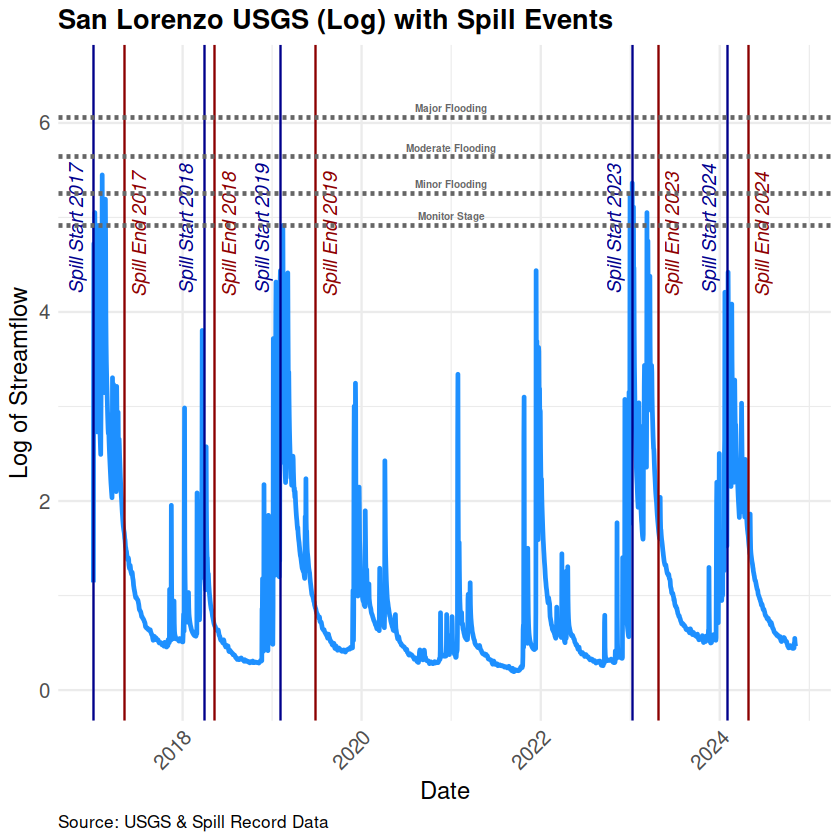

In [198]:
# Step 1: Load Required Libraries
if (!require("dataRetrieval")) install.packages("dataRetrieval", repos = "https://cran.rstudio.com/")
if (!require("ggplot2")) install.packages("ggplot2", repos = "https://cran.rstudio.com/")
if (!require("lubridate")) install.packages("lubridate", repos = "https://cran.rstudio.com/")
if (!require("dplyr")) install.packages("dplyr", repos = "https://cran.rstudio.com/")
if (!require("readr")) install.packages("readr", repos = "https://cran.rstudio.com/")
library(dataRetrieval)
library(ggplot2)
library(lubridate)
library(dplyr)
library(readr)

# Define conversion factor from cubic feet per second (cfs) to cubic meters per second (cms)
CFSToCMS_CONVERSION_FACTOR <- 0.0283168466

# Step 2: Read and Process USGS Data
site_code <- "11160500"  # Replace with your desired site code
data_usgs_r <- readNWISdv(siteNumbers = site_code, parameterCd = "00060", statCd = "00003")

# Step 3: Transform the data and create new columns
San_Lorenzo_Daily_USGS_R <- data_usgs_r %>%
  mutate(
    timestamp = as.Date(Date),
    data0 = log((X_00060_00003 * CFSToCMS_CONVERSION_FACTOR + 1))  # Double log transformation
  ) %>%
  filter(timestamp > as.Date("2017-01-01"))  # Filter data starting from 1979

# Add a 'time' column for easier plotting
San_Lorenzo_Daily_USGS_R$time <- San_Lorenzo_Daily_USGS_R$timestamp

# Step 4: Read the spill record data from the CSV file
spill_record_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/Loch_Lomond_spill_record.csv"
spill_record <- read_csv(spill_record_path, show_col_types = FALSE)

# Step 5: Clean and transform the spill record data
spill_record <- spill_record %>%
  mutate(
    Spill = as.Date(Spill, format = "%Y-%m-%d"),
    End.of.Spill = as.Date(End.of.Spill, format = "%Y-%m-%d"),
    Second.Spill = as.Date(Second.Spill, format = "%Y-%m-%d"),
    Second.End.of.Spill = as.Date(Second.End.of.Spill, format = "%Y-%m-%d")
  ) %>%
  filter(Year >= 2017)  # Filter spill records to include only those after 2015

# Step 6: Plot the transformed USGS streamflow data
usgs_plot <- ggplot(San_Lorenzo_Daily_USGS_R, aes(x = time, y = data0)) +
  geom_line(color = "#1E90FF", size = 1) +  # Blue line for streamflow data
  theme_minimal() +
  labs(
    title = "San Lorenzo USGS (Log) with Spill Events",
    x = "Date",
    y = "Log of Streamflow",
    caption = "Source: USGS & Spill Record Data"
  ) +
  ylim(0, 6.5) +  # Set y-axis limits for better visibility
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title.x = element_text(size = 14),
    axis.title.y = element_text(size = 14),
    plot.title = element_text(size = 16, face = "bold"),
    plot.caption = element_text(size = 10, hjust = 0),
    legend.position = "none"
  )

# Step 7: Overlay Vertical Spill Lines
for (i in 1:nrow(spill_record)) {
  # Add primary spill start and end lines
  if (!is.na(spill_record$Spill[i])) {
    usgs_plot <- usgs_plot +
      geom_vline(xintercept = as.numeric(spill_record$Spill[i]), color = "#00008B", linetype = "solid", size = 0.5) +
      annotate("text", x = spill_record$Spill[i], y = 3.5, 
               label = paste("Spill Start", spill_record$Year[i]), angle = 90, vjust = -.8, hjust = -0.5, 
               color = "#00008B", size = 4, fontface = "italic")
  }
  if (!is.na(spill_record$End.of.Spill[i])) {
    usgs_plot <- usgs_plot +
      geom_vline(xintercept = as.numeric(spill_record$End.of.Spill[i]), color = "#8B0000", linetype = "solid", size = 0.5) +
      annotate("text", x = spill_record$End.of.Spill[i], y = 3.5, 
               label = paste("Spill End", spill_record$Year[i]), angle = 90, vjust = 1.5, hjust = -0.5, 
               color = "#8B0000", size = 4, fontface = "italic")
  }
}

flood_levels <- data.frame(
  Flood_Level = c("Major Flooding", "Moderate Flooding", "Minor Flooding", "Monitor Stage"),
  Feet = c(21.76, 19.5, 16.5, 14),
  cfs = c(15000, 9900, 6750, 4770)  # Corresponding cfs values for each level
)

# Convert cfs values to cms
flood_levels$cms <- flood_levels$cfs * CFSToCMS_CONVERSION_FACTOR
flood_levels$log_log_value <- log((flood_levels$cms + 1))

for (i in 1:nrow(flood_levels)) {
  usgs_plot <- usgs_plot +
    geom_hline(yintercept = flood_levels$log_log_value[i], color = "gray40", linetype = "dashed", size = 1) +
    annotate("text", x = as.Date("2021-01-01"), y = flood_levels$log_log_value[i] + 0.1, 
             label = flood_levels$Flood_Level[i], color = "gray40", size =2, fontface = "bold")
}

# Step 8: Display the final plot
print(usgs_plot)


In [199]:
# t <- 1
# y_post_t <- cbind(exp_y_post_5[,t],exp_y_post_50[,t],exp_y_post_95[,t],
#                 exp_y_post_20[,t],exp_y_post_35[,t],exp_y_post_80[,t],exp_y_post_65[,t])
# dim(y_post_t)

In [200]:
# Define mix_syth function (same for both versions)
mix_syth <- function(t, wt) {
    set.seed(777)
    y_post_t <- cbind(exp_y_post_5[,t],exp_y_post_50[,t],exp_y_post_95[,t],
                  exp_y_post_20[,t],exp_y_post_35[,t],exp_y_post_80[,t],exp_y_post_65[,t])
    mix <- sapply(1:n.samp, function(i) {
        sample(y_post_t[i,], size = 1, prob = wt)
    })
    return(mix)
}

# Refactored loss_w function (with sapply over quantiles) and normalization
loss_w <- function(w1) {
    # Ensure weights sum to 1
    w1 <- w1 / sum(w1)
    
    quantiles <- c(0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 0.95)
    
    y_total_loss <- sum(sapply(quantiles, function(p0) {
        y_quantile <- quantile(mix_syth(1, w1), p0)
        CheckLossFn(p0, y_quantile - exp(Y[1, 1]))
    }))
    
    return(y_total_loss)
}



In [201]:
# # Load necessary package
# if (!requireNamespace("nloptr", quietly = TRUE)) {
#   install.packages("nloptr")
# }
# library(nloptr)

# # Define mix_syth function (same for both versions)
# mix_syth <- function(t, wt) {
#     set.seed(777)
#     # y_post_t <- cbind(exp_y_post_5[,t],exp_y_post_50[,t],exp_y_post_95[,t],
#     #               exp_y_post_20[,t],exp_y_post_35[,t],exp_y_post_80[,t],exp_y_post_65[,t])
#     # mix <- sapply(1:n.samp, function(i) {
#     #     sample(y_post_t[i,], size = 1, prob = wt)
#     # })
#     mix <- rowSums(y_post_t * wt)
#     return(mix)
# }

# # Define loss function with weight normalization
# loss_w <- function(w1) {
#     set.seed(777)
#     w1 <- w1 / sum(w1)
#     quantiles <- c(0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 0.95)
#     y_total_loss <- sum(sapply(quantiles, function(p0) {
#       t<-TT
#         y_quantile <- quantile(mix_syth(t, w1), p0)
#         CheckLossFn(p0, y_quantile - exp(Y[1, t]))
#     }))
    
#     return(y_total_loss)
# }

# # Set initial weights and bounds for optimization
# initial_w <- rep(1/7, 7)
# lb <- rep(0, 7)  # Lower bound (weights >= 0)
# ub <- rep(1e100, 7)  

# # Set optimization options
# opts <- list(
#   algorithm = "NLOPT_LN_COBYLA",  # Algorithm suitable for box-constrained optimization
#   xtol_rel = 1e-30,                # Tolerance for relative change
#   xtol_abs = 1e-30,               # Absolute tolerance
#   maxeval = 10000                 # Maximum evaluations
# )

# # Run optimization
# result <- nloptr(
#   x0 = initial_w,
#   eval_f = loss_w,
#   lb = lb,
#   ub = ub,
#   opts = opts
# )

# # Extract the optimal weights and minimum loss
# optimal_w <- result$solution / sum(result$solution)  # Ensure final weights sum to 1
# minimum_loss <- result$objective

# # Display the results
# cat("Optimal weights:", optimal_w, "\n")
# cat("Minimum loss:", minimum_loss, "\n")


In [202]:
# # Define different initial weights for sensitivity testing
# initial_weights_list <- list(
#   equal_weights = rep(1/7, 7),
#   random_weights = c(0.01, 0.2, 0.05, 0.025, 0.1, 0.15, 0.015),
#   skewed_weights = c(0.01, 0.2, 0.05, 0.025, 0.1, 0.15, 0.015),
#   uniform_low = rep(0.001, 7),
#   uniform_high = c(0.01, 1, 0.05, 1, 1, 1, 0.035)  # Removed trailing comma here
# )

# # Initialize a data frame to store results
# results <- data.frame(
#   Initialization = character(),
#   Optimal_Weights = I(list()),
#   Minimum_Loss = numeric(),
#   stringsAsFactors = FALSE
# )

# # Run optimization for each initial weight setting
# for (init_name in names(initial_weights_list)) {
#   initial_w <- initial_weights_list[[init_name]]
  
#   # Run optimization
#   result <- nloptr(
#     x0 = initial_w,
#     eval_f = loss_w,
#     lb = lb,
#     ub = ub,
#     opts = opts
#   )
  
#   # Normalize the solution to sum to 1 and store the results
#   optimal_w <- result$solution / sum(result$solution)
#   minimum_loss <- result$objective
  
#   # Append results to data frame
#   results <- rbind(results, data.frame(
#     Initialization = init_name,
#     Optimal_Weights = I(list(optimal_w)),
#     Minimum_Loss = minimum_loss
#   ))
# }

# # Display the results
# print(results)


In [203]:
# library(GA)
# # Define mix_syth function (updated with matrix multiplication for each weight)
# mix_syth <- function(t, wt) {
#     set.seed(777)
#     y_post_t <- cbind(exp_y_post_5[,t],exp_y_post_50[,t],exp_y_post_95[,t],
#                   exp_y_post_20[,t],exp_y_post_35[,t],exp_y_post_80[,t],exp_y_post_65[,t])
#     mix <- rowSums(y_post_t * wt)  # Weighted sum without sampling
#     return(mix)
# }

# # Define loss function with weight normalization
# loss_w <- function(w) {
#     # Normalize weights to ensure they sum to 1
#     w <- w / sum(w)
#     quantiles <- c(0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 0.95)
    
#     # Total loss calculated across quantiles
#     y_total_loss <- sum(sapply(quantiles, function(p0) {
#         t <- TT  # Specify t as appropriate
#         y_quantile <- quantile(mix_syth(t, w), p0)
#         CheckLossFn(p0, y_quantile - exp(Y[1, t]))
#     }))
    
#     return(y_total_loss)
# }

# # Run Genetic Algorithm Optimization
# ga_result <- ga(
#   type = "real-valued",
#   fitness = function(w) -loss_w(w),  # GA maximizes, so minimize by negating the loss
#   lower = rep(0, 7),                # Lower bound of weights
#   upper = rep(10, 7),                # Set an upper bound on weights for stability
#   popSize = 50,                      # Population size
#   maxiter = 1000,                    # Maximum number of iterations
#   run = 100,                         # Max generations without improvement to stop
#   parallel = TRUE                    # Run in parallel if available
# )

# # Extract results
# optimal_w <- ga_result@solution / sum(ga_result@solution)  # Normalize to sum to 1
# minimum_loss <- -ga_result@fitnessValue  # Flip sign back for minimum loss

# # Display the results
# cat("Optimal weights:", optimal_w, "\n")
# cat("Minimum loss:", minimum_loss, "\n")


In [153]:
y_reps <- array(NA, dim = c(7, dim(exp_y_post_5)[1], dim(exp_y_post_5)[2]))
y_reps[1,,] <- exp_y_post_5[,]
y_reps[4,,] <- exp_y_post_50[,]
y_reps[7,,] <- exp_y_post_95[,]
y_reps[2,,] <- exp_y_post_20[,]
y_reps[3,,] <- exp_y_post_35[,]
y_reps[5,,] <- exp_y_post_80[,]
y_reps[6,,] <- exp_y_post_65[,]
saveRDS(y_reps, file = "y_reps.rds")
print("Array y_reps saved as y_reps.rds in the current directory.")

[1] "Array y_reps saved as y_reps.rds in the current directory."


In [204]:
y_reps <- readRDS("y_reps.rds")
print(dim(y_reps))
n.samp <- dim(y_reps)[2]  
TT <- dim(y_reps)[3]

y_reps_f <- readRDS("y_reps_f.rds")
print(dim(y_reps_f))
n.samp_f <- dim(y_reps_f)[2]  
TT_f <- dim(y_reps_f)[3]

[1]     7  2000 12986
[1]    7 2000   28


In [205]:
# # Load necessary package
# if (!requireNamespace("GA", quietly = TRUE)) {
#   install.packages("GA")
# }
# library(GA)

# # mix_syth <- function(t, wt) {
# #     set.seed(777)
# #     y_post_t <- cbind(exp_y_post_5[,t],exp_y_post_50[,t],exp_y_post_95[,t],
# #                   exp_y_post_20[,t],exp_y_post_35[,t],exp_y_post_80[,t],exp_y_post_65[,t])
# #     mix <- rowSums(y_post_t * wt)  # Weighted sum without sampling
# #     return(mix)
# # }

# mix_syth <- function(t, wt) {
#     set.seed(777)
#     y_post_t <- cbind(y_reps[1,,],y_reps[5,,],y_reps[7,,],
#                   y_reps[2,,],y_reps[3,,],y_reps[5,,],y_reps[6,,])
#     mix <- rowSums(y_post_t * wt)  # Weighted sum without sampling
#     return(mix)
# }

# loss_w <- function(w) {
#     # Normalize weights to ensure they sum to 1
#     w <- w / sum(w)
#     quantiles <- c(0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 0.95)
    
#     # Total loss calculated across quantiles
#     y_total_loss <- sum(sapply(quantiles, function(p0) {
#         t <- TT  # Specify t as appropriate
#         y_quantile <- quantile(mix_syth(t, w), p0)
#         CheckLossFn(p0, y_quantile - exp(Y[1, t]))
#     }))
    
#     return(y_total_loss)
# }

# time_steps <- TT:(TT - 50)

# results <- data.frame(
#   Time_Step = integer(),
#   Optimal_Weights = I(list()),
#   Minimum_Loss = numeric(),
#   stringsAsFactors = FALSE
# )

# for (t in time_steps) {
#   ga_result <- ga(
#     type = "real-valued",
#     fitness = function(w) -loss_w(w),  # GA maximizes, so minimize by negating the loss
#     lower = rep(0, 7),                 # Lower bound of weights
#     upper = rep(10, 7),                # Set upper bound on weights
#     popSize = 50,                      # Population size
#     maxiter = 1000,                    # Maximum iterations
#     run = 100,                         # Max generations without improvement
#     parallel = TRUE                    # Run in parallel if available
#   )
  
#   # Extract the optimal weights and minimum loss for this time step
#   optimal_w <- ga_result@solution / sum(ga_result@solution)  # Normalize to sum to 1
#   minimum_loss <- -ga_result@fitnessValue  # Flip sign back for minimum loss
  
#   # Append results to the data frame
#   results <- rbind(results, data.frame(
#     Time_Step = t,
#     Optimal_Weights = I(list(optimal_w)),
#     Minimum_Loss = minimum_loss
#   ))
# }

# print(results)


In [206]:
# t <- 20
# mix <- mix_syth(TT-t+1, c(results$Optimal_Weights[[t]]))
# hist(mix,breaks = 30, xlim = c(0.4,1.5))
# abline(v=quantile(mix, c(0.05,0.2,0.35,0.5,0.65,0.8,0.95)), col='red')
# abline(v=quantile(r_exp_synth_q[,TT-t+1],c(0.05,0.2,0.35,0.5,0.65,0.8,0.95)), col='blue')
# abline(v=exp(Y[1,TT-t+1]), col='green')


In [207]:
# idx <- (TT -50+1):(TT)
# n.samp <- dim(samp.theta_5_exAL_synth_PCA$samp_theta)[3]
# ylim_range <- c(0, 7)

# mix_opt   <- matrix(NA_real_, nrow = n.samp, ncol = length(idx))
# mix_r <- matrix(NA_real_, nrow = n.samp, ncol = length(idx))
# for(i in 1:length(idx)){
#   wt <- c(results$Optimal_Weights[[i]])
#   mix <- mix_syth(TT-i+1, wt)
#   mix_opt[,length(idx)-i+1] <- mix

#   t <- TT-i+1
#   y_post_t <- cbind(exp_y_post_5[,t],exp_y_post_50[,t],exp_y_post_95[,t],
#                   exp_y_post_20[,t],exp_y_post_35[,t],exp_y_post_80[,t],exp_y_post_65[,t])
#   selected_values <- sapply(1:n.samp, function(i) {
#     sample(y_post_t[i, ], size = 1, prob = wt)
#   })
#   mix_r[,length(idx)-i+1] <- selected_values
# } 

# plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
#     col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)")



# for (s in 1:n.samp) {
# lines(timestamps[idx], (mix_r[s, ]), lwd = 0.1, col = 'pink')
# }

# for (s in 1:n.samp) {
# lines(timestamps[idx], (mix_opt[s, ]), lwd = 0.1, col = 'darkslategray3')
# }

# lines(timestamps[idx],exp(new.theta.out_5_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkred')
# lines(timestamps[idx],exp(new.theta.out_50_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='forestgreen')
# lines(timestamps[idx],exp(new.theta.out_95_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='darkblue')
# lines(timestamps[idx],exp(new.theta.out_20_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
# lines(timestamps[idx],exp(new.theta.out_35_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
# lines(timestamps[idx],exp(new.theta.out_65_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')
# lines(timestamps[idx],exp(new.theta.out_80_exAL_synth_PCA$exps[1,idx]), lwd = .8, col='purple')

# q_s <- apply(mix_r, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5, 0.65, 0.80, 0.95))
# lines(timestamps[idx],q_s[1,], lwd = 0.6, col='darkred')
# lines(timestamps[idx],q_s[2,], lwd = 0.6, col='purple')
# lines(timestamps[idx],q_s[3,], lwd = 0.6, col='purple')
# lines(timestamps[idx],q_s[4,], lwd = 0.6, col='forestgreen')
# lines(timestamps[idx],q_s[5,], lwd = 0.6, col='purple')
# lines(timestamps[idx],q_s[6,], lwd = 0.6, col='purple')
# lines(timestamps[idx],q_s[7,], lwd = 0.6, col='darkblue')

# lines(timestamps[idx], exp(Y[1, idx]))

## Score computation

## GDPCA 

In [208]:
# Load necessary libraries
library(ggplot2)
library(scales)     # For better date formatting
library(readr)

# Load dynamic component results and indices
gdpc_result <- readRDS("/data/muscat_data/jaguir26/project1_ucsc_phd/gdpc_auto_result_full.rds")
input_file <- "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily.csv"
data <- read_csv(input_file)

# Convert data to matrix form and standardize (excluding the Date column)
data_matrix <- as.matrix(data[,-1])  # Exclude Date column
data_standardized <- scale(data_matrix)

# Generate timestamps for x-axis (assuming daily data starting from 1980-01-01)
timestamps <- as.Date("1980-01-01") + 0:(nrow(data_standardized) - 1)

# Directory to store plots
output_dir <- "/data/muscat_data/jaguir26/project1_ucsc_phd/gdpc_plots"
dir.create(output_dir, showWarnings = FALSE)

# Perform standard PCA using prcomp on the standardized data
pca_result <- prcomp(data_standardized)
pca_components <- pca_result$x  # Extract principal components
pca_variance <- summary(pca_result)$importance[2, ] * 100  # Variance explained by each PCA component as a percentage

# Extract cumulative explained variance for dynamic components and calculate individual variances
cumulative_variances <- sapply(gdpc_result, function(comp) comp$expart) * 100  # Convert to percentage
dynamic_variances <- c(cumulative_variances[1], diff(cumulative_variances))  # Calculate individual variances

# Determine the minimum number of components
num_components <- min(length(gdpc_result), ncol(pca_components))

# Loop through each dynamic component to generate and save plots
for (i in 1:num_components) {
  
  # Extract dynamic component details
  component <- gdpc_result[[i]]
  time_series <- component$f
  loadings <- component$beta
  lag_length <- component$k
  dyn_variance <- round(dynamic_variances[i], 2)   # Individual explained variance for dynamic component
  pca_variance_comp <- round(pca_variance[i], 2)  # Explained variance for PCA component
  
  # Dynamic Component Time Series Plot
  dynamic_df <- data.frame(Time = timestamps, Dynamic_Component = time_series)
  dynamic_plot <- ggplot(dynamic_df, aes(x = Time, y = Dynamic_Component)) +
    geom_line(color = "blue", size = 0.7) +
    labs(title = paste("Dynamic Component", i, "Time Series"),
         subtitle = paste("Lag Length:", lag_length, "| Explained Variance:", dyn_variance, "%"),
         x = "Date", y = "Component Value") +
    theme_minimal(base_size = 14) +
    scale_x_date(labels = date_format("%Y")) +
    theme(plot.title = element_text(face = "bold"),
          axis.text.x = element_text(angle = 45, hjust = 1))
  
  # Save Dynamic Component Time Series Plot
  ggsave(filename = file.path(output_dir, paste0("gdpc_component_", i, "_dynamic_timeseries.png")),
         plot = dynamic_plot, dpi = 300, width = 10, height = 6)

  # Static PCA Component Time Series Plot
  pca_series <- pca_components[, i]
  static_df <- data.frame(Time = timestamps, Static_Component = pca_series)
  static_plot <- ggplot(static_df, aes(x = Time, y = Static_Component)) +
    geom_line(color = "red", size = 0.7) +
    labs(title = paste("Static PCA Component", i, "Time Series"),
         subtitle = paste("Explained Variance:", pca_variance_comp, "%"),
         x = "Date", y = "PCA Component Value") +
    theme_minimal(base_size = 14) +
    scale_x_date(labels = date_format("%Y")) +
    theme(plot.title = element_text(face = "bold"),
          axis.text.x = element_text(angle = 45, hjust = 1))
  
  # Save Static PCA Component Time Series Plot
  ggsave(filename = file.path(output_dir, paste0("pca_component_", i, "_static_timeseries.png")),
         plot = static_plot, dpi = 300, width = 10, height = 6)

  # Combined Dynamic vs Static Plot
  combined_df <- data.frame(Time = timestamps, 
                            Dynamic_Component = time_series,
                            Static_Component = pca_series)
  combined_plot <- ggplot(combined_df) +
    geom_line(aes(x = Time, y = Dynamic_Component, color = "Dynamic Component"), size = 0.7) +
    geom_line(aes(x = Time, y = Static_Component, color = "Static PCA Component"), size = 0.7) +
    labs(title = paste("Comparison of Dynamic vs Static PCA Time Series (Component", i, ")"),
         subtitle = paste("Dynamic Explained Variance:", dyn_variance, "% | PCA Explained Variance:", pca_variance_comp, "%"),
         x = "Date", y = "Component Value") +
    scale_color_manual("", values = c("Dynamic Component" = "blue", "Static PCA Component" = "red")) +
    theme_minimal(base_size = 14) +
    scale_x_date(labels = date_format("%Y")) +
    theme(plot.title = element_text(face = "bold"),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")
  
  # Save Combined Plot
  ggsave(filename = file.path(output_dir, paste0("component_", i, "_dynamic_vs_static.png")),
         plot = combined_plot, dpi = 300, width = 12, height = 7)

  # Loadings Plot for the First Lag of Component
  if (ncol(loadings) > 1) {
    loadings_df <- data.frame(Variable = rownames(loadings), Loading = loadings[, 1])
    loadings_plot <- ggplot(loadings_df, aes(x = Variable, y = Loading)) +
      geom_bar(stat = "identity", fill = "darkgreen") +
      labs(title = paste("Loadings for Dynamic Component", i),
           subtitle = paste("First Lag Loadings of Component", i),
           x = "Variable", y = "Loading Value") +
      theme_minimal(base_size = 14) +
      theme(axis.text.x = element_text(angle = 90, hjust = 1),
            plot.title = element_text(face = "bold"))
    
    # Save Loadings Plot
    ggsave(filename = file.path(output_dir, paste0("gdpc_component_", i, "_loadings.png")),
           plot = loadings_plot, dpi = 300, width = 10, height = 6)
  }
}

print(paste("Plots saved in:", output_dir))


Rows: 15706 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (17): Niño 3, NAO, Niño 1+2, WHWP, GMT, ONI, PNA, NOI, WP, Niño 3.4, So...
date  (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Plots saved in: /data/muscat_data/jaguir26/project1_ucsc_phd/gdpc_plots"


In [4]:
#!/usr/bin/env Rscript
library(parallel)
library(dlm)
library(exdqlm)
library(mvtnorm)
library(jmuOutlier)
library(sn)
library(Matrix)
library(future)
library(future.apply)
library(numDeriv)
library(foreach)
library(doParallel)
library(dataRetrieval)
library(dplyr)
library(zoo)
library(tseries)
library(tidyverse)
library(patchwork)
library(rvest)
library(expint)
library(nimble)
library(nloptr)
library(expm)
library(numDeriv)
library(Rcpp)
library(RcppArmadillo)
library(RcppEigen)
library(ks)
library(MASS)
library(FNN)
# library(prism)

n.samp <- 2000
cut <- 1
m <- 2
lam <- 0.4
n.samp < 2000

p0 <-  0.95
harmonics = c(1, 2, 1/6.8333333)    


use_covariates = TRUE
delta = c(0.9993, 0.99, 0.9993, 0.94, 0.9993, 0.9993, 0.6)

df_t    <- delta[1] 
df_s    <-  delta[2]
df_s67  <- delta[3]
df.discrep <- delta[4]
df_trans <- delta[5]
df_covs <-  delta[6]
lambda <- delta[7]

# Function to check if a matrix is positive definite
is.positive.definite <- function(x) {
  eigenvalues <- eigen(x)$values
  return(all(eigenvalues > 0))
}

# Function to compute inverse or square root of inverse using Cholesky Decomposition
compute_cholesky <- function(q, compute_sqrt_inverse = FALSE) {
  if (!is.positive.definite(q)) {
    stop("The matrix is not positive definite.")
  }
  
  # Compute Cholesky decomposition
  chol_decomp <- chol(as.matrix(q))
  
  # Convert to Matrix class to use with chol2inv
  U <- Matrix(chol_decomp, sparse = TRUE)
  
  # Compute inverse using Cholesky decomposition
  inv_q <- chol2inv(U)
  
  if (!compute_sqrt_inverse) {
    return(list(inverse = inv_q))
  } else {
    # Compute square root of the inverse
    # The square root of the inverse in this context is the inverse of the upper triangular matrix U
    sqrt_inv_q <- solve(U)
    
    # Check if the square root of the inverse times itself results in the inverse
    sqrt_inv_q_product <- sqrt_inv_q %*% t(sqrt_inv_q)
    is_correct <- all.equal(sqrt_inv_q_product, inv_q, tolerance = 1e-10)
    
    return(list(inverse = inv_q, sqrt_inverse = sqrt_inv_q, check = is_correct))
  }
}
#
log.g<-function(gam){	log(2)+stats::pnorm(-abs(gam),log=T)+0.5*gam^2 }
L.fn<-function(p0){ stats::uniroot(function(gam) exp(log.g(gam))-(1-p0), c(-1000,0))$root }
U.fn<-function(p0){ stats::uniroot(function(gam) exp(log.g(gam))-p0, c(0,1000))$root }
p.fn<-function(p0,gam){ (p0-as.numeric(gam<0))/exp(log.g(gam))+as.numeric(gam<0)}
A.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((1-2*temp.p)/(temp.p*(1-temp.p))) }
B.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((2)/(temp.p*(1-temp.p))) }
C.fn<-function(p0,gam){ temp.p = p.fn(p0,gam); return((as.numeric(gam>0)-temp.p)^(-1)) }
#
CheckLossFn = function(p0,diff){diff*p0 - diff*as.numeric(diff<0)}
#
dlm_df = function(y, model, df, dim.df, s.priors = list(l0=1,S0=10), just.lik=FALSE){
  ### Gets the Time Series Length / Replicate number
  y = check_ts(y)
  TT = nrow(y)
  ### Gets the State Parameter dimension and Prior Distribution Parameters
  m0 = model$m0
  C0 = model$C0
  l0 = s.priors$l0
  S0 = s.priors$S0
  n = length(m0)
  ### Constructs F and G
  FF = model$FF
  GG = model$GG
  ### Variable Saving
  ### Posterior Distribution
  m = matrix(0,TT,n)
  C = array(0,c(TT,n,n))
  ### Predictive State Distribution
  a = matrix(0,TT,n)
  R = array(0,dim = c(TT,n,n))
  P = array(0,dim = c(TT,n,n))
  W = array(0,dim = c(TT,n,n))
  ### One-Step Ahead Forecast
  f = matrix(0,TT,1)
  Q = array(0,c(TT,1,1))
  inv.Q = array(0,c(TT,1,1))
  ### Regression Variables
  e = matrix(0,TT,1)
  A = array(0,c(TT,n,1))
  ### Sample Variance
  S = vector("numeric",TT)
  l = vector("numeric",TT)

  # Prior Dim Check
  m0 = matrix(m0,n,1)
  C0 = matrix(C0,n,n)
  ### Discount Factor Blocking
  df.mat = make_df_mat(df,dim.df,n)

  ### First Update
  ### One-step state forecast
  a[1,]  = GG[,,1] %*% m0
  P[1,,] = GG[,,1] %*% C0 %*% t(GG[,,1])
  W[1,,] = df.mat * P[1,,]
  R[1,,] = P[1,,] + W[1,,]
  ### One-step ahead forecast
  f[1,] = t(FF[,1]) %*% a[1,]
  Q[1,,] = as.matrix(1 + t(FF[,1]) %*% R[1,,] %*% FF[,1],1,1)
  inv.Q[1,,] = chol2inv(chol(Q[1,,]))
  ### Auxilary Variables
  e[1,]  = as.matrix(y[1,] - f[1,],1,1)
  A[1,,] = R[1,,] %*% FF[,1] %*% inv.Q[1,,]
  ### Variance update
  l[1] = l0 + 1
  S[1] = l0 * S0 / l[1] + (t(e[1,]) %*% inv.Q[1,,] %*% e[1,] / l[1])
  ### Posterior Distribution
  m[1,]  = a[1,] + as.matrix(A[1,,],n,1) %*% e[1,]
  C[1,,] = R[1,,] - as.matrix(A[1,,],n,1) %*% Q[1,,] %*% t(A[1,,])
  C[1,,] = (C[1,,] + t(C[1,,]))/2

  for(i in 2:TT){
    ### One-step state forecast
    a[i,]  = GG[,,i] %*% m[i-1,]
    P[i,,] = GG[,,i] %*% C[i-1,,] %*% t(GG[,,i])
    W[i,,] = df.mat * P[i,,]
    R[i,,] = P[i,,] + W[i,,]
    ### One-step ahead forecast
    f[i,] = t(FF[,i]) %*% a[i,]
    Q[i,,] = matrix(1 + t(FF[,i])%*% R[i,,]%*% FF[,i],1,1)
    inv.Q[i,,] = chol2inv(chol(Q[i,,]))
    ### Auxilary Variables
    e[i,]  = as.matrix(y[i,] - f[i,],1,1)
    A[i,,] = as.matrix(R[i,,] %*% FF[,i] %*% inv.Q[i,,],n,1)
    ### Variance update
    l[i] = l[i-1] + 1
    S[i] = l[i-1] * S[i-1] / l[i] + (t(e[i,]) %*% inv.Q[i,,] %*% e[i,] / l[i])
    ### Posterior Distribution
    m[i,]  = a[i,] + as.matrix(A[i,,],n,1) %*% e[i,]
    C[i,,] = R[i,,] - as.matrix(A[i,,],n,1) %*% Q[i,,] %*% t(as.matrix(A[i,,],n,1))
    C[i,,] = (C[i,,] + t(C[i,,]))/2
  }

  ### Adjust By Variance
  R[1,,] = S0 * R[1,,]
  Q[1,,]   = S0 * Q[1,,]
  C[1,,]   = S[1] * C[1,,]
  for(i in 2:TT){
    R[i,,] = S[i-1] * R[i,,]
    Q[i,,]   = S[i-1] * Q[i,,]
    C[i,,]   = S[i] * C[i,,]
  }

  # Calculate Log-Likelihood
  det.Q = log(abs(Q[1,,])) ; llik = lgamma((l0+1)/2)-lgamma(l0/2)-log(pi*l0)/2-det.Q/2-(l0+1)*log(1+t(e[1,])%*%inv.Q[1,,]%*%e[1,]/l0)/2
  for(t in 2:TT){
    det.Q = log(abs(Q[t,,]))
    llik = llik + lgamma((l[t-1]+1)/2)-lgamma(l[t-1]/2)-log(pi*l[t-1])/2-det.Q/2-(l[t-1]+1)*log(1+t(e[t,])%*%inv.Q[t,,]%*%e[t,]/l[t-1])/2
  }
  if(just.lik){
    return(list(llik = llik))
  }

  ## SMOOTHING
  ### Initializes recursive relations
  sa = matrix(0,TT,n)
  sR = array(0, dim = c(TT,n,n))
  ### Runs the recursive equations
  sa[TT,]  = m[TT,]
  sR[TT,,] = C[TT,,]
  for(k in 1:(TT-1)){
  ### Computes the Auxilary recursion Variable B
    B = C[TT-k,,] %*% t(GG[,,i]) %*% solve(R[TT-k+1,,])
    sa[TT-k,] = m[TT-k,] + B %*% (sa[TT-k+1,] - a[TT-k+1,])
    sR[TT-k,,] = C[TT-k,,] + B %*% (sR[TT-k+1,,] - R[TT-k+1,,]) %*% t(B)
  }
  ### Adjusts the variance update
  for(k in 1:TT){
    sR[TT-k,,] = S[TT] * sR[TT-k,,] / S[TT-k]
  }
  return(list(fm = m, fC = C, m = sa, C = sR,model = model, s = S, n = l))
}
#
make_df_mat = function(df,dim.df,n){
  if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
  if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
  dfs = rep(df,dim.df)
  n.dfs = length(dim.df)
  ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
  df.mat = matrix(0,n,n)
  for(j in 1:n.dfs){
    df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]])/dfs[ind.dfs[(j+1)]]
  }
  return(df.mat)
}
#
check_mod = function(model){
  if(dlm::is.dlm(model)){
    model = dlmMod(model)
  }
  if(!is.vector(model$m0)){
    if(ncol(model$m0) != 1){
      stop("m0 must be a vector or a matrix with 1 column")
      }
    }
  p = length(model$m0)
  model$C0 = as.matrix(model$C0)
  if(p != dim(model$C0)[1] & p != dim(model$C0)[2]){
    stop("C0 must be a square matrix matching the dimension of m0")
    }
  if(!all.equal(model$C0, t(model$C0)) | !all(eigen(model$C0)$values >= 0)){
    stop("C0 must be a covariance matrix")
  }
  if(!is.vector(model$FF)){
    if(nrow(model$FF) != p){
      stop("FF must be a vector of length matching the dimension of m0, or a matrix with number of rows matching the dimension of m0")
    }
  }else{
    if(length(model$FF) != p){
      stop("FF must be a vector of length matching the dimension of m0, or a matrix with number of rows matching the dimension of m0")
    }
  }
  if(is.null(dim(model$GG)[3])){
    model$GG = as.matrix(model$GG)
  }else{
    if(is.na(dim(model$GG)[3])){
      model$GG = as.matrix(model$GG)
    }else{
      model$GG = as.array(model$GG)
    }
  }
  if(p != dim(model$GG)[1] & p != dim(model$GG)[2]){
    stop("GG must be a square matrix matching the dimension of m0, or an array with first two dimensions matching the dimension of m0")
  }
  model$m0 = as.matrix(model$m0)
  model$FF = as.matrix(model$FF)
  return(model)
}
#
check_logics = function(gam.init,sig.init,fix.gamma,fix.sigma,dqlm.ind){
  retval <- NULL
  retval$gam.init = gam.init
  retval$fix.gamma = fix.gamma
  retval$dqlm.ind = dqlm.ind
  if(dqlm.ind){
    if(gam.init!=0 | !fix.gamma){
      retval$gam.init <- gam.init <- 0
      retval$fix.gamma <- fix.gamma <- TRUE
    }
  }else{
    if(gam.init==0 && fix.gamma==TRUE){
      retval$dqlm.ind = TRUE
    }
  }
  if(fix.gamma & is.na(gam.init)){ stop("when fix.gamma = TRUE, gam.init must be specified") }
  if(fix.sigma & is.na(sig.init)){ stop("when fix.sigma = TRUE, sig.init must be specified") }
  return(retval)
}
#
check_ts = function(dat){
  dat = as.matrix(dat)
  if(all(dim(dat)>1)){
    stop("data must be univariate time-series")
  }
  if(dim(dat)[1]<dim(dat)[2]){
    dat = t(dat)
  }
  return(invisible(dat))
}
#
is.exdqlm = function(m){ return(inherits(m,"exdqlm")) }

parameters_path <- "/data/muscat_data/jaguir26/projects/Project/Input/exAL/parameters/parameters.txt"

# Check if the file exists
if (!file.exists(parameters_path)) {
  stop("The parameters file does not exist at the specified path: ", parameters_path)
}

lines <- readLines(parameters_path)

# Check if the lines variable is empty or not as expected
if (length(lines) == 0) {
  stop("No content found in the parameters file: ", parameters_path)
}

# Process each line and assign variables
for (line in lines) {
  # Remove leading and trailing whitespaces
  line <- trimws(line)
  
  # Skip empty lines and comments
  if (nchar(line) == 0 || grepl("^#", line)) next
  
  # Evaluate and assign
  eval(parse(text = line))
}
#
dlm_df = function(y, model, df, dim.df, s.priors = list(l0=1,S0=10), just.lik=FALSE){
  
  ### Gets the Time Series Length / Replicate number
  TT = length(y)
  ### Gets the State Parameter dimension and Prior Distribution Parameters
  m0 = model$m0
  C0 = model$C0
  l0 = s.priors$l0
  S0 = s.priors$S0
  n = length(m0)
  ### Constructs F and G
  FF = model$FF
  GG = model$GG
  ### Variable Saving
  ### Posterior Distribution
  m = matrix(0,TT,n)
  C = array(0,c(TT,n,n))
  ### Predictive State Distribution
  a = matrix(0,TT,n)
  R = array(0,dim = c(TT,n,n))
  P = array(0,dim = c(TT,n,n))
  W = array(0,dim = c(TT,n,n))
  ### One-Step Ahead Forecast
  f = matrix(0,TT,1)
  Q = array(0,c(TT,1,1))
  inv.Q = array(0,c(TT,1,1))
  ### Regression Variables
  e = matrix(0,TT,1)
  A = array(0,c(TT,n,1))
  ### Sample Variance
  S = vector("numeric",TT)
  l = vector("numeric",TT)
  
  # Prior Dim Check
  m0 = matrix(m0,n,1)
  C0 = matrix(C0,n,n)
  ### Discount Factor Blocking
  df.mat = make_df_mat(df,dim.df,n)
  
  ### First Update
  ### One-step state forecast
  a[1,]  = GG[,,1] %*% m0
  P[1,,] = GG[,,1] %*% C0 %*% t(GG[,,1])
  W[1,,] = df.mat * P[1,,]
  R[1,,] = P[1,,] + W[1,,]
  ### One-step ahead forecast
  f[1,] = t(FF[,,1]) %*% a[1,]
  Q[1,,] = as.matrix(1 + t(FF[,,1]) %*% R[1,,] %*% FF[,,1],1,1)
  inv.Q[1,,] = chol2inv(chol(Q[1,,]))
  ### Auxilary Variables
  e[1,]  = as.matrix(y[1] - f[1,],1,1)
  A[1,,] = R[1,,] %*% FF[,,1] %*% inv.Q[1,,]
  ### Variance update
  l[1] = l0 + 1
  S[1] = l0 * S0 / l[1] + (t(e[1,]) %*% inv.Q[1,,] %*% e[1,] / l[1])
  ### Posterior Distribution
  m[1,]  = a[1,] + as.matrix(A[1,,],n,1) %*% e[1,]
  C[1,,] = R[1,,] - as.matrix(A[1,,],n,1) %*% Q[1,,] %*% t(A[1,,])
  C[1,,] = (C[1,,] + t(C[1,,]))/2
  
  for(i in 2:TT){
    ### One-step state forecast
    a[i,]  = GG[,,i] %*% m[i-1,]
    P[i,,] = GG[,,i] %*% C[i-1,,] %*% t(GG[,,i])
    W[i,,] = df.mat * P[i,,]
    R[i,,] = P[i,,] + W[i,,]
    ### One-step ahead forecast
    f[i,] = t(FF[,,i]) %*% a[i,]
    Q[i,,] = matrix(1 + t(FF[,,i])%*% R[i,,]%*% FF[,,i],1,1)
    inv.Q[i,,] = chol2inv(chol(Q[i,,]))
    ### Auxilary Variables
    e[i,]  = as.matrix(y[i] - f[i,],1,1)
    A[i,,] = as.matrix(R[i,,] %*% FF[,,i] %*% inv.Q[i,,],n,1)
    ### Variance update
    l[i] = l[i-1] + 1
    S[i] = l[i-1] * S[i-1] / l[i] + (t(e[i,]) %*% inv.Q[i,,] %*% e[i,] / l[i])
    ### Posterior Distribution
    m[i,]  = a[i,] + as.matrix(A[i,,],n,1) %*% e[i,]
    C[i,,] = R[i,,] - as.matrix(A[i,,],n,1) %*% Q[i,,] %*% t(as.matrix(A[i,,],n,1))
    C[i,,] = (C[i,,] + t(C[i,,]))/2
  }
  
  ### Adjust By Variance
  R[1,,] = S0 * R[1,,]
  Q[1,,]   = S0 * Q[1,,]
  C[1,,]   = S[1] * C[1,,]
  for(i in 2:TT){
    R[i,,] = S[i-1] * R[i,,]
    Q[i,,]   = S[i-1] * Q[i,,]
    C[i,,]   = S[i] * C[i,,]
  }
  
  # Calculate Log-Likelihood
  det.Q = log(abs(Q[1,,])) ; llik = lgamma((l0+1)/2)-lgamma(l0/2)-log(pi*l0)/2-det.Q/2-(l0+1)*log(1+t(e[1,])%*%inv.Q[1,,]%*%e[1,]/l0)/2
  for(t in 2:TT){
    det.Q = log(abs(Q[t,,]))
    llik = llik + lgamma((l[t-1]+1)/2)-lgamma(l[t-1]/2)-log(pi*l[t-1])/2-det.Q/2-(l[t-1]+1)*log(1+t(e[t,])%*%inv.Q[t,,]%*%e[t,]/l[t-1])/2
  }
  if(just.lik){
    return(list(llik = llik))
  }
  
  ## SMOOTHING
  ### Initializes recursive relations
  sa = matrix(0,TT,n)
  sR = array(0, dim = c(TT,n,n))
  ### Runs the recursive equations
  sa[TT,]  = m[TT,]
  sR[TT,,] = C[TT,,]
  for(k in 1:(TT-1)){
    ### Computes the Auxilary recursion Variable B
    B = C[TT-k,,] %*% t(GG[,,i]) %*% solve(R[TT-k+1,,])
    sa[TT-k,] = m[TT-k,] + B %*% (sa[TT-k+1,] - a[TT-k+1,])
    sR[TT-k,,] = C[TT-k,,] + B %*% (sR[TT-k+1,,] - R[TT-k+1,,]) %*% t(B)
  }
  ### Adjusts the variance update
  for(k in 1:TT){
    sR[TT-k,,] = S[TT] * sR[TT-k,,] / S[TT-k]
  }
  return(list(fm = m, fC = C, m = sa, C = sR,model = model, s = S, n = l))
}
#
make_df_mat = function(df,dim.df,n){
  if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
  if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
  dfs = rep(df,dim.df)
  n.dfs = length(dim.df)
  ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
  df.mat = matrix(0,n,n)
  for(j in 1:n.dfs){
    df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]])/dfs[ind.dfs[(j+1)]]
  }
  return(df.mat)
}
#
make_df_mat_k = function(df,dim.df,n,k){
  if(sum(dim.df)!=n){ stop("sum of component dimensions given in dim.df does not match m0") }
  if(length(df)!=length(dim.df)){ stop("length of component discount factors does not match length of component dimensions") }
  dfs = rep(df,dim.df)
  n.dfs = length(dim.df)
  ind.dfs = c(0,sapply(1:length(dim.df),function(x){sum(dim.df[1:x])}),n)
  df.mat = matrix(0,n,n)
  for(j in 1:n.dfs){
    df.mat[(ind.dfs[j]+1):ind.dfs[(j+1)],(ind.dfs[j]+1):ind.dfs[(j+1)]] = (1-dfs[ind.dfs[(j+1)]]^k)/dfs[ind.dfs[(j+1)]]^k
  }
  return(df.mat)
}
#
H_t_k_r <- function(GG, t, k, r){
  n <- dim(GG)[1]
  I <- diag(n)
  for (s in (t+k-r):(t+k)) {
    I <- GG[,,s] %*% I   
  }
  return(I)
}
#
# Function to estimate log density using KDE for univariate data
estimate_log_density_kde_univariate <- function(data, points) {
  kde_result <- kde(data)
  density_estimates <- predict(kde_result, x = points)
  log_density <- log(density_estimates + .Machine$double.eps*100)  # Add small value to avoid log(0)
  return(log_density)
}
#
# Function to estimate the expectation term for univariate data
estimate_expectation_term_univariate <- function(sample_from_p, sample_size) {
  # Generate a sample from the standard normal distribution
  sample_from_normal <- rnorm(sample_size)
  
  # Estimate log density of p at points sampled from the standard normal distribution
  log_density_estimates <- estimate_log_density_kde_univariate(sample_from_p, sample_from_normal)
  
  # Compute the Monte Carlo estimate of the expectation
  expectation_estimate <- mean(log_density_estimates)
  
  return(expectation_estimate)
}
#
# Function to estimate the KL divergence D_KL(N(0, 1) || p) for univariate data
estimate_kl_divergence_univariate_normal_to_p <- function(sample_from_p, sample_size) {
  # Estimate the expectation term
  expectation_term <- estimate_expectation_term_univariate(sample_from_p, sample_size)
  
  # Compute the KL divergence
  kl_divergence <- -0.5 * log(2 * pi) - 0.5 - expectation_term
  
  return(kl_divergence)
}
#
# Function to estimate KL divergence using k-NN with entropy package for multivariate data
estimate_kl_divergence_knn_entropy <- function(sample_from_p, sample_size, k = 200) {
  # Generate a sample from the multivariate standard normal distribution
  sample_from_normal <- matrix(rnorm(sample_size * ncol(sample_from_p)), ncol = ncol(sample_from_p))
  
  # Estimate KL divergence using entropy package's KL.div function
  kl_divergence <- KL.divergence(sample_from_p, sample_from_normal, k = 5)
  
  # Return only the final estimate
  return(tail(kl_divergence, n = 1))
}
#
# Unified function to estimate KL divergence based on the input sample
estimate_kl_divergence <- function(sample, sample_size = 10000) {
  # Check if the sample is univariate or multivariate
  if (is.vector(sample) || ncol(sample) == 1) {
    # Univariate case
    if (is.vector(sample)) {
      sample_from_p <- sample
    } else {
      sample_from_p <- sample[, 1]
    }
    
    # Estimate the KL divergence using the KDE-based method
    estimated_kl_divergence <- estimate_kl_divergence_univariate_normal_to_p(sample_from_p, sample_size)
    
  } else {
    # Multivariate case
    sample_from_p <- sample
    
    # Estimate the KL divergence using the k-NN based method with entropy package
    estimated_kl_divergence <- estimate_kl_divergence_knn_entropy(sample_from_p, sample_size, k = 5 )
  }
  
  # Return the estimate
  return(estimated_kl_divergence)
}
#
# Function to estimate differential entropy using KDE for univariate data
estimate_differential_entropy_kde_univariate <- function(data) {
  kde_result <- kde(data)
  estimates <- kde_result$estimate
  estimates[estimates <= 0] <- .Machine$double.eps*100 # Prevent log(0) issues
  log_estimates <- log(estimates)
  log_estimates[!is.finite(log_estimates)] <- 0 # Handle non-finite values
  entropy_estimate <- -sum(estimates * log_estimates) * diff(kde_result$eval.points)[1]
  return(entropy_estimate)
}
#
# Function to estimate differential entropy using KDE for multivariate data
estimate_differential_entropy_kde_multivariate <- function(data) {
  kde_result <- kde(data)
  estimates <- kde_result$estimate
  estimates[estimates <= 0] <- .Machine$double.eps*100 # Prevent log(0) issues
  log_estimates <- log(estimates)
  log_estimates[!is.finite(log_estimates)] <- 0 # Handle non-finite values
  entropy_estimate <- -sum(estimates * log_estimates) * prod(diff(kde_result$eval.points[[1]]))
  return(entropy_estimate)
}
#
# Function to estimate the KL divergence D_KL(p || N(0, I)) for univariate data
estimate_kl_divergence_univariate <- function(data) {
  # Estimate the differential entropy H(p)
  H_p <- estimate_differential_entropy_kde_univariate(data)
  
  # Compute the expected value of the squared norm of the vectors
  E_p_x2 <- mean(data^2)
  
  # Dimensionality is 1 for univariate data
  k <- 1
  
  # Compute the KL divergence
  kl_divergence <- -H_p + (k / 2) * log(2 * pi) + (1 / 2) * E_p_x2
  
  return(kl_divergence)
}
#
# Function to estimate the KL divergence D_KL(p || N(0, I)) for multivariate data
estimate_kl_divergence_multivariate <- function(data) {
  # Estimate the differential entropy H(p)
  H_p <- estimate_differential_entropy_kde_multivariate(data)
  
  # Dimensionality of the vectors
  k <- ncol(data)
  
  # Compute the expected value of the squared norm of the vectors
  E_p_xTx <- mean(rowSums(data^2))
  
  # Compute the KL divergence
  kl_divergence <- -H_p + (k / 2) * log(2 * pi) + (1 / 2) * E_p_xTx
  
  return(kl_divergence)
}
#

# Wrapper function for any sample
compute_kl_divergence <- function(sample) {
  # Ensure the input sample is a matrix
  sample <- as.matrix(sample)
  
  # Determine if the sample is univariate or multivariate
  if (ncol(sample) == 1) {
    kl_divergence <- estimate_kl_divergence_univariate(sample)
  } else {
    kl_divergence <- estimate_kl_divergence_multivariate(sample)
  }
  
  return(kl_divergence)
}


# Wrapper function for any sample
compute_kl_divergence <- function(sample) {
  # Ensure the input sample is a matrix
  sample <- as.matrix(sample)
  
  # Determine if the sample is univariate or multivariate
  if (ncol(sample) == 1) {
    kl_divergence <- estimate_kl_divergence_univariate(sample)
  } else {
    kl_divergence <- estimate_kl_divergence_multivariate(sample)
  }
  
  return(kl_divergence)
}

#
concatenate_matrix_columns <- function(matrix_input) {
  # Concatenate the columns of the matrix
  concatenated_vector <- c(matrix_input)
  return(concatenated_vector)
}
#
preallocate_matrix_list <- function(column_counts, num_rows) {
  # Initialize an empty list
  matrix_list <- vector("list", length(column_counts))
  
  # Loop through the column counts and create matrices
  for (i in seq_along(column_counts)) {
    num_cols <- column_counts[i]
    matrix_list[[i]] <- matrix(NA, nrow = num_rows[i], ncol = num_cols)
  }
  
  return(matrix_list)
}


# Read and process ELI_lon data
ELI_lon <- read.csv("/data/muscat_data/jaguir26/projects/Project/Input/exAL/covariates/cov_1_ELI.csv")
merged_sst_data <- read.csv("/data/muscat_data/jaguir26/projects/Project/Input/exAL/covariates/cov_2_ONI.csv")
ELI_lon$time <- as.Date(ELI_lon$time)
adjustment_years <- 170
ELI_lon$time <- ELI_lon$time - years(adjustment_years)
#
CFSToCMS_CONVERSION_FACTOR = 0.0283168466
# Read and process USGS data
data_usgs_r <- readNWISdv(siteNumbers = site_code[1], parameterCd = "00060", statCd = "00003")
San_Lorenzo_Daily_USGS_R <- data_usgs_r %>%
  mutate(timestamp = as.Date(Date),
         data0 = log(X_00060_00003*CFSToCMS_CONVERSION_FACTOR + 1)) %>%
  filter(timestamp > as.Date("1979-01-01"))
San_Lorenzo_Daily_USGS_R$time <- San_Lorenzo_Daily_USGS_R$timestamp
#
# SOIL
csv_file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/soil_moisture_daily_avg.csv"
soil_moisture_data <- read.csv(csv_file_path)
soil_moisture_data$time <- as.Date(soil_moisture_data$time)
colnames(soil_moisture_data) <- c('time','soil')
#
# Merge datasets based on 'time'
merged_data <- merge(ELI_lon, merged_sst_data, by = "time")
merged_data <- merge(merged_data, San_Lorenzo_Daily_USGS_R, by = "time")
merged_data <- merged_data[, c(1:6, 10)]
colnames(merged_data) <- c("time", "eli", "nino12", "nino3", "nino34", "nino4", "flow")
merged_data$eli_smooth <- rollmean(merged_data$eli, k = KK, align = "right", fill = NA)
merged_data$oni <- rollmean(merged_data$nino34, k = KK, align = "right", fill = NA)
merged_data$eli_smooth[1:(KK-1)] <- merged_data$eli[1:(KK-1)]#
merged_data$oni[1:(KK-1)] <- merged_data$nino34[1:(KK-1)]
merged_data$flow_log <- log(merged_data$flow + 1)
#
# Adding soil
merged_data <- merge(merged_data, soil_moisture_data, by = "time")
#
# Standardize specified columns
standardize <- function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
}
columns_to_standardize <- c("eli_smooth", "oni", "flow_log", "soil")
merged_data[columns_to_standardize] <- lapply(merged_data[columns_to_standardize], standardize)
#
# Read streamflow data and merge with covariates
data_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/retros_2022-12-25.csv"
streamflow_data <- read_csv(data_path, show_col_types = FALSE)
timestamps <- as.Date(streamflow_data$Date)
time_series_matrix <- as.matrix(streamflow_data[, c('USGS', 'GloFAS', 'NWS3.0')])
Y_usgs <- data.frame(time = timestamps, time_series_matrix)
#
plot_data <- merge(merged_data, Y_usgs, by = "time")
ppt_data <- read.csv("PPT.csv")
ppt_data$time <- as.Date(ppt_data$time)
plot_data <- merge(plot_data, ppt_data, by = "time")
########################################################
# INDECES
file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily_standardized.csv"
combined_indices <- read_csv(file_path, show_col_types = FALSE)
combined_indices['time']  <- as.Date(combined_indices$Date )
plot_data <- merge(plot_data, combined_indices, by = "time")
#
plot_data <- plot_data[cut:nrow(plot_data),]

###########################################
###########################################

covs <- c('ppt', 
          'soil')

indices <- c('Solar Flux',
              'ONI',
              'WHWP',
              'GMT',
              'AMO',
              'TSA',
              'TNA',
              'SOI')

components_file_path <- "/data/muscat_data/jaguir26/project1_ucsc_phd/dynamic_components_with_timestamps.csv"
principal_components_df <- read_csv(components_file_path, show_col_types = FALSE)
principal_components_df$Date <- as.Date(principal_components_df$Date)
plot_data$time <- as.Date(plot_data$time)
merged_data <- merge(plot_data, principal_components_df, by.x = "time", by.y = "Date", all.x = TRUE)

covariates <- plot_data[, covs]
covariates <- apply(covariates, 2, standardize)
for(i in 1:dim(covariates)[2] ){
    covariates[,i] <- covariates[,i]-min(covariates[,i])+1
}
#LOG###########################################
covariates <- log(log(covariates+1))

X <- cbind(covariates, merged_data[,'Component_1']) 
X <- apply(X, 2, standardize)

#LOG#######################################################
# Set up Y and X matrices
Y <- t(as.matrix(plot_data[, c('USGS', 'GloFAS', 'NWS3.0')]))
Y <- log(Y)
TT <- dim(Y)[2]
J <- dim(Y)[1] - 1
#
timestamps <- plot_data[, 'time']

#######################################################
#######################################################

nws_forecast <- read.csv('/data/muscat_data/jaguir26/project1_ucsc_phd/nws_forecast.csv')
nws_forecast[,-1] <- log(nws_forecast[,-1])
num_ens_nws <- dim(nws_forecast)[2]-1

glofas_forecast <- read.csv('/data/muscat_data/jaguir26/project1_ucsc_phd/weighted_time_series.csv')
glofas_forecast$target_date <- as.Date(glofas_forecast$target_date)
specific_date <- as.Date("2022-12-26")
glofas_forecast <- glofas_forecast[glofas_forecast$target_date >= specific_date, ]
glofas_forecast[,-1] <- log(glofas_forecast[,-1])

num_ens_glofas <- dim(glofas_forecast)[2]-1

ensembles <- list(glofas_forecast[,-c(1)], nws_forecast[,-c(1)])
J <- length(ensembles)
num_mem <- rep(NA_real_, J)
ranges <- rep(NA_real_, J)
for(j in 1:J){
  num_mem[j] <- dim(ensembles[[j]])[2]
  ranges[j] <- dim(ensembles[[j]])[1]
}
###########################################################################################
###########################################################################################
################
row_means_list <- vector("list", J + 1)
row_means_list[[1]] <- rep(NA_real_, ranges[1])
for (j in 1:J) {
  row_means_list[[j + 1]] <- rep(NA_real_, ranges[1])
  row_means_list[[j + 1]][1:ranges[j]] <- rowMeans(ensembles[[j]])
}
mean_forecast <- do.call(rbind, row_means_list)


[1] FALSE

In [5]:
num_mem

[1] 51  7

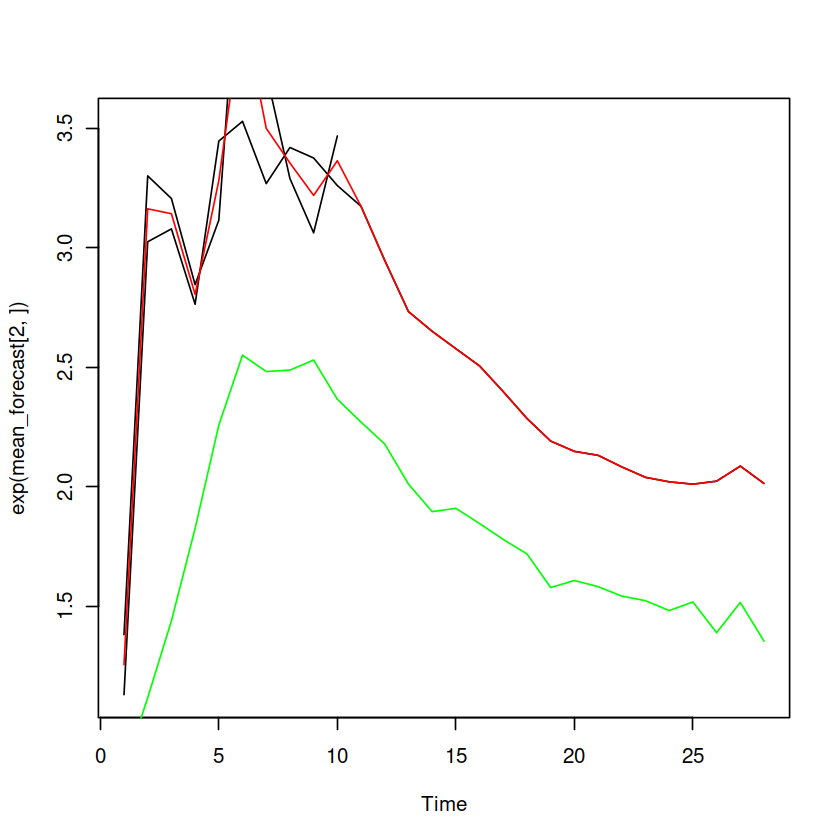

In [210]:
plot.ts(exp(mean_forecast[2,]))
lines(exp(mean_forecast[3,]))
lines(colMeans(exp(mean_forecast), na.rm = TRUE), col = 'red')
lines(colMeans(y_reps_f[4,,]), col = 'green')



In [211]:
y_reps <- readRDS("y_reps.rds")
print(dim(y_reps))
n.samp <- dim(y_reps)[2]  
TT <- dim(y_reps)[3]

y_reps_f <- readRDS("y_reps_f.rds")
print(dim(y_reps_f))
n.samp_f <- dim(y_reps_f)[2]  
TT_f <- dim(y_reps_f)[3]

[1]     7  2000 12986
[1]    7 2000   28


In [214]:
if (!requireNamespace("GA", quietly = TRUE)) {
  install.packages("GA")
}
if (!requireNamespace("parallel", quietly = TRUE)) {
  install.packages("parallel")
}

library(GA)
library(parallel)

mix_syth <- function(t, wt) {
  set.seed(777)
  y_reps_numeric <- as.numeric(y_reps[,,t]) 
  dim(y_reps_numeric) <- dim(y_reps[,,t])   
  wt_numeric <- as.numeric(wt)
  result <- sweep(y_reps_numeric, 1, wt_numeric, `*`)
  mix <- colSums(result)
  return(mix)
}

mix_syth_f <- function(t, wt) {
  set.seed(777)
  y_reps_numeric <- as.numeric(y_reps_f[,,t]) 
  dim(y_reps_numeric) <- dim(y_reps_f[,,t])   
  wt_numeric <- as.numeric(wt)
  result <- sweep(y_reps_numeric, 1, wt_numeric, `*`)
  mix <- colSums(result)
  return(mix)
}

loss_w <- function(w, t) {
  w <- w / sum(w)  # Normalize weights
  quantiles <- c(0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 0.95)
  y_total_loss <- sum(sapply(quantiles, function(p0) {
      y_quantile <- quantile(mix_syth_f(t, w), p0)
      CheckLossFn(p0, exp(Y[1, t] ) - y_quantile )
  }))
  
  return(y_total_loss)
}

loss_w_f <- function(w, t) {
  w <- w / sum(w)  # Normalize weights
  forecasts <- colMeans(exp(mean_forecast), na.rm = TRUE)
  quantiles <- c(0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 0.95)
  y_total_loss <- sum(sapply(quantiles, function(p0) {
      y_quantile <- quantile(mix_syth_f(t, w), p0)
      CheckLossFn(p0, forecasts[t] - y_quantile)
  }))
  
  return(y_total_loss)
}

optimize_weights <- function(t) {
  ga_result <- ga(
    type = "real-valued",
    fitness = function(w) -loss_w(w, t),  # Minimize loss by negating
    lower = rep(0, 7),
    upper = rep(100, 7),
    popSize = 500,
    maxiter = 1000,
    run = 100,
    parallel = FALSE  # Disable internal parallel processing in GA
  )
  
  optimal_w <- ga_result@solution / sum(ga_result@solution)
  minimum_loss <- -ga_result@fitnessValue
  
  list(Time_Step = t, Optimal_Weights = optimal_w, Minimum_Loss = minimum_loss)
}

optimize_weights_f <- function(t) {
  ga_result <- ga(
    type = "real-valued",
    fitness = function(w) -loss_w_f(w, t),  # Minimize loss by negating
    lower = rep(0, 7),
    upper = rep(100, 7),
    popSize = 200,
    maxiter = 1000,
    run = 100,
    parallel = FALSE  # Disable internal parallel processing in GA
  )
  
  optimal_w <- ga_result@solution / sum(ga_result@solution)
  minimum_loss <- -ga_result@fitnessValue
  
  list(Time_Step = t, Optimal_Weights = optimal_w, Minimum_Loss = minimum_loss)
}

time_steps <- (TT - 50):TT

time_steps_f <- 1:ranges[1]

In [215]:
results <- mclapply(time_steps, optimize_weights, mc.cores = parallel::detectCores() - 1)
results_df <- do.call(rbind, lapply(results, as.data.frame))
print(results_df)
saveRDS(results_df, file = "results_df.rds")

results_f <- mclapply(time_steps_f, optimize_weights_f, mc.cores = parallel::detectCores() - 1)
results_df_f <- do.call(rbind, lapply(results_f, as.data.frame))
print(results_df_f)
saveRDS(results_df_f, file = "results_df_f.rds")

Warning message in mclapply(time_steps, optimize_weights, mc.cores = parallel::detectCores() - :
“all scheduled cores encountered errors in user code”


                                                      x
1  Error in y_reps_f[, , t] : subscript out of bounds\n
2  Error in y_reps_f[, , t] : subscript out of bounds\n
3  Error in y_reps_f[, , t] : subscript out of bounds\n
4  Error in y_reps_f[, , t] : subscript out of bounds\n
5  Error in y_reps_f[, , t] : subscript out of bounds\n
6  Error in y_reps_f[, , t] : subscript out of bounds\n
7  Error in y_reps_f[, , t] : subscript out of bounds\n
8  Error in y_reps_f[, , t] : subscript out of bounds\n
9  Error in y_reps_f[, , t] : subscript out of bounds\n
10 Error in y_reps_f[, , t] : subscript out of bounds\n
11 Error in y_reps_f[, , t] : subscript out of bounds\n
12 Error in y_reps_f[, , t] : subscript out of bounds\n
13 Error in y_reps_f[, , t] : subscript out of bounds\n
14 Error in y_reps_f[, , t] : subscript out of bounds\n
15 Error in y_reps_f[, , t] : subscript out of bounds\n
16 Error in y_reps_f[, , t] : subscript out of bounds\n
17 Error in y_reps_f[, , t] : subscript out of b

In [ ]:
results_df <- readRDS("results_df.rds")
results_df_f <- readRDS("results_df_f.rds")

In [ ]:
idx <- results_df[,1]
n.samp <- dim(y_reps)[2]
ylim_range <- c(0, 7)

mix_opt   <- matrix(NA_real_, nrow = n.samp, ncol = length(idx))
mix_r <- matrix(NA_real_, nrow = n.samp, ncol = length(idx))
for(i in 1:length(idx)){
  t <- results_df[i,1]
  wt <- results_df[i,1+(1:7)]  
  mix <- mix_syth(t, wt)
  mix_opt[,i] <- mix
  y_post_t <- t(y_reps[,,t])
  selected_values <- sapply(1:n.samp, function(i) {
    sample(y_post_t[i, ], size = 1, prob = wt)
  })
  mix_r[,i] <- selected_values
} 


ERROR: Error in `[.data.frame`(results_df, i, 1 + (1:7)): undefined columns selected


In [ ]:
idx <- results_df_f[,1]
n.samp <- dim(y_reps_f)[2]
ylim_range <- c(0, 7)

mix_opt_f   <- matrix(NA_real_, nrow = n.samp, ncol = length(idx))
mix_r_f <- matrix(NA_real_, nrow = n.samp, ncol = length(idx))
for(i in 1:length(idx)){
  t <- results_df_f[i,1]
  wt <- results_df_f[i,1+(1:7)]  
  mix <- mix_syth_f(t, wt)
  mix_opt_f[,i] <- mix
  y_post_t <- t(y_reps_f[,,t])
  selected_values <- sapply(1:n.samp, function(i) {
    sample(y_post_t[i, ], size = 1, prob = wt)
  })
  mix_r_f[,i] <- selected_values
} 

In [ ]:
truth<- San_Lorenzo_Daily_USGS_R$data0[San_Lorenzo_Daily_USGS_R$Date>=as.Date('2022-12-26')]
truth <- (truth[1:ranges[1]])

In [ ]:
# plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
#     col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)")

# for (s in 1:n.samp) {
# lines(timestamps[idx], (mix_r[s, ]), lwd = 0.1, col = 'pink')
# }

# for (s in 1:n.samp) {
# lines(timestamps[idx], (mix_opt[s, ]), lwd = 0.1, col = 'darkslategray3')
# }

# q_s <- apply(mix_r, 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5, 0.65, 0.80, 0.95))
# lines(timestamps[idx],q_s[1,], lwd = 0.6, col='darkred')
# lines(timestamps[idx],q_s[2,], lwd = 0.6, col='purple')
# lines(timestamps[idx],q_s[3,], lwd = 0.6, col='purple')
# lines(timestamps[idx],q_s[4,], lwd = 0.6, col='forestgreen')
# lines(timestamps[idx],q_s[5,], lwd = 0.6, col='purple')
# lines(timestamps[idx],q_s[6,], lwd = 0.6, col='purple')
# lines(timestamps[idx],q_s[7,], lwd = 0.6, col='darkblue')

# lines(timestamps[idx], exp(Y[1, idx]), lwd = 0.5)

In [ ]:
idx <- results_df[,1]
TT_idx <- length(idx)
iii <- (TT_idx-500):TT_idx
idx <- results_df[iii,1]

png(filename = paste0(output_dir, "plot_opt_synth1.png"), width = 2000, height = 1200, res = 300)

plot(timestamps[idx], exp(Y[1, idx]), type = "l", ylim = ylim_range, 
    col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)")

for (s in 1:n.samp) {
    lines(timestamps[idx], (mix_r[s, iii]), lwd = 0.1, col = 'pink')
}

for (s in 1:n.samp) {
    lines(timestamps[idx], (mix_opt[s, iii]), lwd = 0.1, col = 'darkslategray3')
}

q_s <- apply(mix_r[,iii], 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5, 0.65, 0.80, 0.95))
lines(timestamps[idx],q_s[1,], lwd = 0.6, col='darkred')
lines(timestamps[idx],q_s[2,], lwd = 0.6, col='purple')
lines(timestamps[idx],q_s[3,], lwd = 0.6, col='purple')
lines(timestamps[idx],q_s[4,], lwd = 0.6, col='forestgreen')
lines(timestamps[idx],q_s[5,], lwd = 0.6, col='purple')
lines(timestamps[idx],q_s[6,], lwd = 0.6, col='purple')
lines(timestamps[idx],q_s[7,], lwd = 0.6, col='darkblue')

lines(timestamps[idx], exp(Y[1, idx]), lwd = 0.5)

dev.off()
#######################################################################3
#######################################################################3

idx <- results_df_f[,1]
TT_idx <- length(idx)
iii <- 1:TT_idx
idx <- results_df_f[iii,1]

start_date <- as.Date("2022-12-26")
timestamps_f <- seq.Date(from = start_date, by = "day", length.out = 28)

png(filename = paste0(output_dir, "plot_opt_synth2.png"), width = 2000, height = 1200, res = 300)

plot(timestamps_f[idx], truth*0, type = "l", ylim = ylim_range, 
    col = 'black', lwd = 1.5, xlab = "Date", ylab = "log(Streamflow)")

for (s in 1:n.samp) {
    lines(timestamps_f[idx], (mix_r_f[s, iii]), lwd = 0.1, col = 'pink')
}

for (s in 1:n.samp) {
    lines(timestamps_f[idx], (mix_opt_f[s, iii]), lwd = 0.1, col = 'darkslategray3')
}

q_s <- apply(mix_r_f[,iii], 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5, 0.65, 0.80, 0.95))
lines(timestamps_f[idx],q_s[1,], lwd = 0.6, col='darkred')
lines(timestamps_f[idx],q_s[2,], lwd = 0.6, col='purple')
lines(timestamps_f[idx],q_s[3,], lwd = 0.6, col='purple')
lines(timestamps_f[idx],q_s[4,], lwd = 0.6, col='forestgreen')
lines(timestamps_f[idx],q_s[5,], lwd = 0.6, col='purple')
lines(timestamps_f[idx],q_s[6,], lwd = 0.6, col='purple')
lines(timestamps_f[idx],q_s[7,], lwd = 0.6, col='darkblue')

points(timestamps_f[idx], truth)

dev.off()
#######################################################################3
#######################################################################3


ERROR: Error in xj[i]: only 0's may be mixed with negative subscripts


In [ ]:
idx1 <- results_df[,1]
idx2 <- results_df_f[,1]

TT_idx1 <- length(idx1)
iii1 <- (TT_idx1 - 30):TT_idx1
idx1 <- results_df[iii1, 1]

TT_idx2 <- length(idx2)
iii2 <- 1:(TT_idx2)
idx2 <- results_df_f[,1]

png(filename = paste0(output_dir, "plot_opt_synth3.png"), width = 2000, height = 1200, res = 300)
plot(
  c(timestamps[idx1], timestamps_f[idx2]),
  c(exp(Y[1, idx1]), truth)*0,
  type = "l",
  ylim = ylim_range,
  col = "black",
  lwd = 1.5,
  xlab = "Date",
  ylab = "log(Streamflow)",
  main = "Streamflow Forecast with Confidence Intervals"
)

for (s in 1:n.samp) {
    lines(timestamps[idx1], mix_r[s, iii1], lwd = 0.3, col = adjustcolor('pink', alpha.f = 0.4))
}

for (s in 1:n.samp) {
    lines(timestamps[idx1], mix_opt[s, iii1], lwd = 0.3, col = adjustcolor('darkslategray3', alpha.f = 0.4))
}

q_s <- apply(mix_r[, iii1], 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5, 0.65, 0.80, 0.95))

quantile_colors <- c("darkred", "purple", "purple", "forestgreen", "purple", "purple", "darkblue")

for (i in seq_along(quantile_colors)) {
    lines(timestamps[idx1], q_s[i, ], lwd = 0.8, col = quantile_colors[i])
}

lines(timestamps[idx1], exp(Y[1, idx1]), lwd = 1, col = "black")

for (s in 1:n.samp) {
    lines(timestamps_f[idx2], mix_r_f[s, iii2], lwd = 0.3, col = adjustcolor('pink', alpha.f = 0.4))
}

for (s in 1:n.samp) {
    lines(timestamps_f[idx2], mix_opt_f[s, iii2], lwd = 0.3, col = adjustcolor('darkslategray3', alpha.f = 0.4))
}

q_s_f <- apply(mix_r_f[, iii2], 2, quantile, probs = c(0.05, 0.2, 0.35, 0.5, 0.65, 0.80, 0.95))

for (i in seq_along(quantile_colors)) {
    lines(timestamps_f[idx2], q_s_f[i, ], lwd = 0.8, col = quantile_colors[i])
}

points(timestamps_f[idx2], truth, col = 'darkred', pch = 4)
points(timestamps[idx1], exp(Y[1, idx1]), col = "black", pch = 16)
legend("topleft", legend = c("Observed", "Forecasted Quantiles (5%-95%)", "Optimal Synth", "Av. Optimal Synth"),
       col = c("black", "darkred", "pink", "darkslategray3"), lwd = c(1.5, 1.5, 1.5, 1.5), 
       pch = c(16, 4, NA, NA), bty = "n")


dev.off()

In [ ]:
saveRDS(Y, file = "Y.rds")